<a href="https://colab.research.google.com/github/Zamorano86/COC_891-Deep_Learning/blob/main/COC891_DL_Trabalho_Final_PlantVillage_14SET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("Versão do PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versão do PyTorch: 2.11.0+cu128
GPU disponível: True
GPU: Tesla T4


In [ ]:
# ============================================================
# ETAPA 2 — Clonar o repositório oficial do artigo
# ============================================================

import os

# Pasta principal do nosso trabalho no Colab
PROJECT_DIR = "/content/plant_disease_yolov4"

# Se a pasta ainda não existir, clonamos o repositório dos autores
if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/mzakariah/plant-disease-detection-using-yolov4.git {PROJECT_DIR}
else:
    print("O repositório já existe em:", PROJECT_DIR)

# Entrar na pasta do projeto
%cd {PROJECT_DIR}

# Mostrar os arquivos disponíveis
print("\nArquivos encontrados no repositório:")
!find . -maxdepth 2 -type f | sort

Cloning into '/content/plant_disease_yolov4'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 1.29 MiB | 30.09 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/plant_disease_yolov4

Arquivos encontrados no repositório:
./.git/config
./.git/description
./.git/HEAD
./.git/index
./.git/packed-refs
./README.md
./yolov4_plant_disease_detection.ipynb


In [ ]:
# ============================================================
# ETAPA 3 — Inspecionar o material oficial dos autores
# ============================================================

from pathlib import Path
import json

PROJECT_DIR = Path("/content/plant_disease_yolov4")

# ------------------------------------------------------------
# 1. Ler o README
# ------------------------------------------------------------

readme_path = PROJECT_DIR / "README.md"

print("=" * 80)
print("README DO REPOSITÓRIO")
print("=" * 80)

with open(readme_path, "r", encoding="utf-8") as f:
    readme_text = f.read()

print(readme_text)

# ------------------------------------------------------------
# 2. Inspecionar a estrutura do notebook
# ------------------------------------------------------------

notebook_path = PROJECT_DIR / "yolov4_plant_disease_detection.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

print("\n" + "=" * 80)
print("ESTRUTURA DO NOTEBOOK")
print("=" * 80)

print("Número total de células:", len(notebook["cells"]))

for i, cell in enumerate(notebook["cells"]):
    cell_type = cell.get("cell_type", "desconhecido")
    source = "".join(cell.get("source", []))

    print("\n" + "-" * 80)
    print(f"CÉLULA {i} | tipo: {cell_type}")
    print("-" * 80)

    # Limitar a saída para não ficar gigantesca
    print(source[:1500])

    if len(source) > 1500:
        print("\n[... conteúdo truncado ...]")

README DO REPOSITÓRIO
# plant-disease-detection-using-yolov4
our work focused on the detection and identification of plant leaf diseases using the YOLO v4 architecture on the Plant Village dataset. Through the use of image annotation, data preprocessing, and model training, we were able to achieve very good accuracy in detecting and identifying various plant leaf diseases.

The YOLO v4 architecture proved to be effective in detecting and localizing the diseased regions in plant leaf images. We also experimented with different hyperparameters and model configurations to optimize the performance of the model.

Our work contributes to the growing body of research on the use of deep learning techniques in plant disease detection and shows the potential for YOLO v4 in this domain. In future work, we aim to expand the scope of our approach to other plant diseases and datasets and explore the integration of other deep-learning techniques to further improve the performance of the model.

our w

In [ ]:
# ============================================================
# ETAPA 4 — Tentar baixar o dataset dos autores
# e verificar se o download realmente ocorreu
# ============================================================

from pathlib import Path
import zipfile
import os

FILE_ID = "1-62YVfF3tXQQvUrUh2NeEgqHR_oZJFvr"

DATA_DIR = Path("/content/dados_autores")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / "plant_village_dataset.zip"

# Instalar gdown
!pip -q install -U gdown

# URL completa do arquivo
URL = f"https://drive.google.com/file/d/{FILE_ID}/view?usp=sharing"

print("Tentando baixar o dataset...")
print("URL:", URL)

# tentativa de download
if not ZIP_PATH.exists():
    !gdown "{URL}" --fuzzy -O "{ZIP_PATH}"

# ------------------------------------------------------------
# Verificação importante
# ------------------------------------------------------------

if ZIP_PATH.exists():

    print("\n✅ Download realizado.")
    tamanho_mb = ZIP_PATH.stat().st_size / (1024**2)

    print("Arquivo:", ZIP_PATH)
    print(f"Tamanho: {tamanho_mb:.2f} MB")

    print("\n" + "=" * 80)
    print("INSPEÇÃO DO ARQUIVO")
    print("=" * 80)

    if zipfile.is_zipfile(ZIP_PATH):

        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            files = z.namelist()

        print("✅ O arquivo é um ZIP válido.")
        print("Total de entradas:", len(files))

        print("\nPrimeiros 100 arquivos:")
        for f in files[:100]:
            print(f)

    else:
        print("⚠️ O arquivo foi baixado, mas não é um ZIP válido.")

else:

    print("\n❌ O Google Drive não permitiu o download automático.")
    print("Nenhum arquivo ZIP foi criado.")
    print("Vamos precisar obter o arquivo manualmente ou por outra fonte.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.2 MB/s eta 0:00:00
Tentando baixar o dataset...
URL: https://drive.google.com/file/d/1-62YVfF3tXQQvUrUh2NeEgqHR_oZJFvr/view?usp=sharing
usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--proxy PROXY] [--speed SPEED]
             [--cookies FILE] [--cookies-from-browser BROWSER] [--no-cookies]
             [--no-check-certificate] [--continue] [--folder] [--json]
             [--format FORMAT] [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: --fuzzy

❌ O Google Drive não permitiu o download automático.
Nenhum arquivo ZIP foi criado.
Vamos precisar obter o arquivo manualmente ou por outra fonte.


## Etapa 4 — Recuperação do dataset original dos autores

O repositório oficial do trabalho foi recuperado com sucesso. Entretanto,
o link do Google Drive fornecido pelos autores para o dataset preparado
para YOLOv4 não está mais disponível.

A tentativa de acesso direto ao arquivo retornou a mensagem de que o
arquivo solicitado não existe.

O material suplementar do artigo confirma que os autores utilizaram um
arquivo denominado `obj.zip`, extraído para `data/yolov4_dataset/`,
contendo imagens processadas/anotadas para o treinamento do YOLOv4.

Dessa forma, será utilizada uma fonte pública alternativa para recuperar
o PlantVillage e reconstruir, na medida do possível, o pipeline descrito
no artigo. Eventuais diferenças em relação ao experimento original serão
documentadas explicitamente.

In [ ]:
# ============================================================
# ETAPA 5 — Testar as fontes originais de Mango e Bean
# ============================================================

import requests

links = {
    "Mango": "https://drive.google.com/file/d/1-D9EyCN_dEMqUIoZpCP-jDJvBfdWB5AO/view?usp=share_link",
    "Bean": "https://drive.google.com/file/d/1-F6cJp45yoHA91RggJgi5p9rCPL9ojWg/view?usp=share_link",
}

print("Testando as fontes alternativas citadas pelos autores...\n")

for nome, url in links.items():
    try:
        r = requests.get(url, timeout=20, allow_redirects=True)

        print("=" * 60)
        print(f"Fonte: {nome}")
        print(f"Status HTTP: {r.status_code}")
        print(f"URL final: {r.url}")

        texto = r.text.lower()

        if "the file you have requested does not exist" in texto:
            print("❌ Arquivo aparentemente removido.")
        elif "o arquivo que você solicitou não existe" in texto:
            print("❌ Arquivo aparentemente removido.")
        elif r.status_code == 200:
            print("✅ O link respondeu. A fonte pode ainda estar disponível.")
        else:
            print("⚠️ Resposta inconclusiva.")

    except Exception as e:
        print("=" * 60)
        print(f"Fonte: {nome}")
        print("❌ Erro ao testar:", e)

print("\nTeste concluído.")

Testando as fontes alternativas citadas pelos autores...

Fonte: Mango
Status HTTP: 404
URL final: https://drive.google.com/file/d/1-D9EyCN_dEMqUIoZpCP-jDJvBfdWB5AO/view?usp=share_link
❌ Arquivo aparentemente removido.
Fonte: Bean
Status HTTP: 404
URL final: https://drive.google.com/file/d/1-F6cJp45yoHA91RggJgi5p9rCPL9ojWg/view?usp=share_link
❌ Arquivo aparentemente removido.

Teste concluído.


In [ ]:
# ============================================================
# ETAPA 6 — Recuperar e inspecionar o PlantVillage oficial
# ============================================================

import os
import subprocess

repo_url = "https://github.com/spMohanty/PlantVillage-Dataset.git"
repo_dir = "/content/PlantVillage-Dataset"

# Clona somente se ainda não existir
if not os.path.exists(repo_dir):
    print("Clonando o repositório oficial do PlantVillage...")
    subprocess.run(
        ["git", "clone", "--depth", "1", repo_url, repo_dir],
        check=True
    )
else:
    print("✅ Repositório já existe no Colab.")

print("\nRepositório disponível em:")
print(repo_dir)

# ------------------------------------------------------------
# Procurar a pasta contendo as imagens RGB
# ------------------------------------------------------------

candidate_paths = [
    os.path.join(repo_dir, "raw", "color"),
    os.path.join(repo_dir, "raw"),
]

color_dir = None

for path in candidate_paths:
    if os.path.isdir(path):
        color_dir = path
        break

if color_dir is None:
    print("\n⚠️ Não encontrei automaticamente a pasta de imagens.")
    print("Conteúdo do diretório raiz:")
    print(os.listdir(repo_dir))
else:
    print("\n✅ Pasta de imagens encontrada:")
    print(color_dir)

    print("\nClasses/pastas disponíveis:\n")

    classes = sorted([
        item for item in os.listdir(color_dir)
        if os.path.isdir(os.path.join(color_dir, item))
    ])

    for i, cls in enumerate(classes, start=1):
        n = len([
            f for f in os.listdir(os.path.join(color_dir, cls))
            if os.path.isfile(os.path.join(color_dir, cls, f))
        ])
        print(f"{i:02d}. {cls}: {n} imagens")

    print("\nTotal de classes encontradas:", len(classes))

Clonando o repositório oficial do PlantVillage...

Repositório disponível em:
/content/PlantVillage-Dataset

✅ Pasta de imagens encontrada:
/content/PlantVillage-Dataset/raw/color

Classes/pastas disponíveis:

01. Apple___Apple_scab: 630 imagens
02. Apple___Black_rot: 621 imagens
03. Apple___Cedar_apple_rust: 275 imagens
04. Apple___healthy: 1645 imagens
05. Blueberry___healthy: 1502 imagens
06. Cherry_(including_sour)___Powdery_mildew: 1052 imagens
07. Cherry_(including_sour)___healthy: 854 imagens
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 imagens
09. Corn_(maize)___Common_rust_: 1192 imagens
10. Corn_(maize)___Northern_Leaf_Blight: 985 imagens
11. Corn_(maize)___healthy: 1162 imagens
12. Grape___Black_rot: 1180 imagens
13. Grape___Esca_(Black_Measles): 1383 imagens
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 imagens
15. Grape___healthy: 423 imagens
16. Orange___Haunglongbing_(Citrus_greening): 5507 imagens
17. Peach___Bacterial_spot: 2297 imagens
18. Peach_

In [ ]:
# ============================================================
# ETAPA 7 — Baixar o dataset C1 pelo KaggleHub
# PlantVillage for Object Detection YOLO
# ============================================================

# Instalar/atualizar o KaggleHub
!pip -q install -U kagglehub

import kagglehub
import os
from pathlib import Path

print("=" * 80)
print("ETAPA 7 — DOWNLOAD DO DATASET C1")
print("=" * 80)

# Identificador oficial do dataset no Kaggle
DATASET_HANDLE = "sebastianpalaciob/plantvillage-for-object-detection-yolo"

print("\nDataset:")
print(DATASET_HANDLE)

# ------------------------------------------------------------
# 1. Baixar a versão mais recente do dataset
# ------------------------------------------------------------

dataset_path = kagglehub.dataset_download(DATASET_HANDLE)

dataset_path = Path(dataset_path)

print("\n✅ Download concluído.")
print("Dataset disponível em:")
print(dataset_path)

# ------------------------------------------------------------
# 2. Verificar se o caminho realmente existe
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFICAÇÃO DO DOWNLOAD")
print("=" * 80)

if dataset_path.exists():
    print("✅ Caminho encontrado.")
else:
    raise FileNotFoundError(
        f"O KaggleHub informou o caminho {dataset_path}, "
        "mas ele não foi encontrado."
    )

# ------------------------------------------------------------
# 3. Mostrar a estrutura inicial do dataset
# ------------------------------------------------------------

print("\nConteúdo da pasta principal:\n")

for item in sorted(dataset_path.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}/")
    else:
        tamanho_mb = item.stat().st_size / (1024**2)
        print(f"📄 {item.name} ({tamanho_mb:.2f} MB)")

print("\n" + "=" * 80)
print("ETAPA 7 CONCLUÍDA")
print("=" * 80)

ETAPA 7 — DOWNLOAD DO DATASET C1

Dataset:
sebastianpalaciob/plantvillage-for-object-detection-yolo
Using Colab cache for faster access to the 'plantvillage-for-object-detection-yolo' dataset.

✅ Download concluído.
Dataset disponível em:
/kaggle/input/plantvillage-for-object-detection-yolo

VERIFICAÇÃO DO DOWNLOAD
✅ Caminho encontrado.

Conteúdo da pasta principal:

📁 PlantVillage_for_object_detection/

ETAPA 7 CONCLUÍDA


In [ ]:
# ============================================================
# ETAPA 8 — Auditoria estrutural do dataset C1
# ============================================================

from pathlib import Path
import os
import yaml

print("=" * 80)
print("ETAPA 8 — AUDITORIA ESTRUTURAL DO DATASET C1")
print("=" * 80)

# Caminho principal obtido na Etapa 7
ROOT_DIR = dataset_path / "PlantVillage_for_object_detection"
DATASET_DIR = ROOT_DIR / "Dataset"

IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"
CLASSES_FILE = DATASET_DIR / "classes.yaml"

# ------------------------------------------------------------
# 1. Verificar estrutura esperada
# ------------------------------------------------------------

print("\n1. VERIFICAÇÃO DAS PASTAS E ARQUIVOS\n")

for nome, caminho in [
    ("Pasta principal", ROOT_DIR),
    ("Dataset", DATASET_DIR),
    ("Images", IMAGES_DIR),
    ("Labels", LABELS_DIR),
    ("classes.yaml", CLASSES_FILE),
]:
    status = "✅" if caminho.exists() else "❌"
    print(f"{status} {nome}: {caminho}")

# ------------------------------------------------------------
# 2. Contagem de imagens e labels
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2. CONTAGEM DE ARQUIVOS")
print("=" * 80)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = sorted([
    f for f in IMAGES_DIR.iterdir()
    if f.is_file() and f.suffix.lower() in image_extensions
])

label_files = sorted([
    f for f in LABELS_DIR.iterdir()
    if f.is_file() and f.suffix.lower() == ".txt"
])

print(f"\nNúmero de imagens: {len(image_files)}")
print(f"Número de labels TXT: {len(label_files)}")

if len(image_files) == len(label_files):
    print("✅ Quantidade de imagens e labels coincide.")
else:
    print("⚠️ Quantidade de imagens e labels NÃO coincide.")

# ------------------------------------------------------------
# 3. Verificar pareamento imagem ↔ label
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. VERIFICAÇÃO DE PAREAMENTO IMAGEM ↔ LABEL")
print("=" * 80)

image_stems = {f.stem for f in image_files}
label_stems = {f.stem for f in label_files}

images_without_labels = sorted(image_stems - label_stems)
labels_without_images = sorted(label_stems - image_stems)

print(f"\nImagens sem label correspondente: {len(images_without_labels)}")
print(f"Labels sem imagem correspondente: {len(labels_without_images)}")

if not images_without_labels and not labels_without_images:
    print("✅ Todas as imagens e labels estão corretamente pareadas.")
else:
    print("⚠️ Foram encontradas inconsistências de pareamento.")

    if images_without_labels:
        print("\nPrimeiras imagens sem label:")
        for item in images_without_labels[:20]:
            print(" -", item)

    if labels_without_images:
        print("\nPrimeiros labels sem imagem:")
        for item in labels_without_images[:20]:
            print(" -", item)

# ------------------------------------------------------------
# 4. Ler classes.yaml
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4. CONTEÚDO DO classes.yaml")
print("=" * 80)

with open(CLASSES_FILE, "r", encoding="utf-8") as f:
    classes_data = yaml.safe_load(f)

print("\nConteúdo bruto:")
print(classes_data)

# Tentativa de localizar a lista de classes
class_names = None

if isinstance(classes_data, dict):
    if "names" in classes_data:
        class_names = classes_data["names"]
    elif "classes" in classes_data:
        class_names = classes_data["classes"]

if class_names is not None:
    print("\nClasses encontradas:\n")

    if isinstance(class_names, dict):
        for idx, name in class_names.items():
            print(f"{idx}: {name}")
    elif isinstance(class_names, list):
        for idx, name in enumerate(class_names):
            print(f"{idx}: {name}")

    print(f"\nTotal de classes: {len(class_names)}")
else:
    print("\n⚠️ Não foi possível identificar automaticamente a lista de classes.")

# ------------------------------------------------------------
# 5. Mostrar exemplos de labels
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("5. EXEMPLOS DE ANOTAÇÕES YOLO")
print("=" * 80)

for label_path in label_files[:5]:
    print(f"\nArquivo: {label_path.name}")

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = f.readlines()

    if not linhas:
        print("  [arquivo vazio]")
    else:
        for linha in linhas[:5]:
            print(" ", linha.strip())

print("\n" + "=" * 80)
print("ETAPA 8 CONCLUÍDA")
print("=" * 80)

ETAPA 8 — AUDITORIA ESTRUTURAL DO DATASET C1

1. VERIFICAÇÃO DAS PASTAS E ARQUIVOS

✅ Pasta principal: /kaggle/input/plantvillage-for-object-detection-yolo/PlantVillage_for_object_detection
✅ Dataset: /kaggle/input/plantvillage-for-object-detection-yolo/PlantVillage_for_object_detection/Dataset
✅ Images: /kaggle/input/plantvillage-for-object-detection-yolo/PlantVillage_for_object_detection/Dataset/images
✅ Labels: /kaggle/input/plantvillage-for-object-detection-yolo/PlantVillage_for_object_detection/Dataset/labels
✅ classes.yaml: /kaggle/input/plantvillage-for-object-detection-yolo/PlantVillage_for_object_detection/Dataset/classes.yaml

2. CONTAGEM DE ARQUIVOS

Número de imagens: 54293
Número de labels TXT: 54293
✅ Quantidade de imagens e labels coincide.

3. VERIFICAÇÃO DE PAREAMENTO IMAGEM ↔ LABEL

Imagens sem label correspondente: 0
Labels sem imagem correspondente: 0
✅ Todas as imagens e labels estão corretamente pareadas.

4. CONTEÚDO DO classes.yaml

Conteúdo bruto:
{'names': ['A

In [ ]:
# ============================================================
# ETAPA 9 — Auditoria específica das classes de tomate
# ============================================================

from collections import Counter
from pathlib import Path

print("=" * 80)
print("ETAPA 9 — AUDITORIA DAS CLASSES DE TOMATE")
print("=" * 80)

# IDs das classes de tomate no classes.yaml
TOMATO_CLASS_IDS = list(range(28, 38))

TOMATO_CLASS_NAMES = {
    28: "Tomato___Bacterial_spot",
    29: "Tomato___Early_blight",
    30: "Tomato___Late_blight",
    31: "Tomato___Leaf_Mold",
    32: "Tomato___Septoria_leaf_spot",
    33: "Tomato___Spider_mites Two-spotted_spider_mite",
    34: "Tomato___Target_Spot",
    35: "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    36: "Tomato___Tomato_mosaic_virus",
    37: "Tomato___healthy",
}

# ------------------------------------------------------------
# 1. Ler todos os labels e contar objetos por classe
# ------------------------------------------------------------

object_counts = Counter()
image_counts = Counter()

tomato_images = []
non_tomato_images = []
multi_object_images = []

for label_path in label_files:

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = [linha.strip() for linha in f if linha.strip()]

    classes_in_image = []

    for linha in linhas:
        partes = linha.split()

        if len(partes) != 5:
            continue

        class_id = int(float(partes[0]))
        classes_in_image.append(class_id)
        object_counts[class_id] += 1

    # classes presentes na imagem
    unique_classes = set(classes_in_image)

    # verificar se existe alguma classe de tomate
    tomato_present = unique_classes.intersection(TOMATO_CLASS_IDS)

    if tomato_present:
        tomato_images.append(label_path.stem)

        for class_id in tomato_present:
            image_counts[class_id] += 1

        if len(linhas) > 1:
            multi_object_images.append(
                (label_path.name, len(linhas), sorted(unique_classes))
            )

    else:
        non_tomato_images.append(label_path.stem)

# ------------------------------------------------------------
# 2. Resultados principais
# ------------------------------------------------------------

print("\n1. DISTRIBUIÇÃO DAS 10 CLASSES DE TOMATE\n")

total_tomato_images = 0
total_tomato_objects = 0

for class_id in TOMATO_CLASS_IDS:

    nome = TOMATO_CLASS_NAMES[class_id]
    imagens = image_counts[class_id]
    objetos = object_counts[class_id]

    total_tomato_images += imagens
    total_tomato_objects += objetos

    print(
        f"{class_id:02d} | "
        f"{nome:<55} | "
        f"imagens: {imagens:5d} | "
        f"objetos: {objetos:5d}"
    )

print("\n" + "-" * 80)

print(f"Total de imagens contendo tomate: {len(tomato_images)}")
print(f"Soma das ocorrências de classes por imagem: {total_tomato_images}")
print(f"Total de objetos anotados das classes de tomate: {total_tomato_objects}")

# ------------------------------------------------------------
# 3. Verificar imagens com múltiplos objetos
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2. IMAGENS COM MAIS DE UMA ANOTAÇÃO")
print("=" * 80)

print(f"\nQuantidade: {len(multi_object_images)}")

if multi_object_images:
    print("\nPrimeiros exemplos:")

    for nome, qtd, classes in multi_object_images[:20]:
        print(
            f"{nome} | "
            f"{qtd} objetos | "
            f"classes: {classes}"
        )

# ------------------------------------------------------------
# 4. Verificar se existem labels problemáticos
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. VERIFICAÇÃO DE FORMATO DAS ANOTAÇÕES")
print("=" * 80)

invalid_labels = []

for label_path in label_files:

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = [linha.strip() for linha in f if linha.strip()]

    for linha in linhas:

        partes = linha.split()

        if len(partes) != 5:
            invalid_labels.append((label_path.name, linha))
            continue

        try:
            class_id = int(float(partes[0]))
            x, y, w, h = map(float, partes[1:])

            if not (
                0 <= x <= 1
                and 0 <= y <= 1
                and 0 <= w <= 1
                and 0 <= h <= 1
            ):
                invalid_labels.append((label_path.name, linha))

        except Exception:
            invalid_labels.append((label_path.name, linha))

print(f"\nAnotações inválidas encontradas: {len(invalid_labels)}")

if invalid_labels:
    print("\nPrimeiros exemplos:")
    for item in invalid_labels[:20]:
        print(item)
else:
    print("✅ Todas as anotações verificadas estão em formato YOLO válido.")

# ------------------------------------------------------------
# 5. Resumo
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 9")
print("=" * 80)

print(f"Classes de tomate analisadas: {len(TOMATO_CLASS_IDS)}")
print(f"Imagens contendo tomate: {len(tomato_images)}")
print(f"Imagens com múltiplas anotações: {len(multi_object_images)}")
print(f"Anotações inválidas: {len(invalid_labels)}")

print("\n" + "=" * 80)
print("ETAPA 9 CONCLUÍDA")
print("=" * 80)

ETAPA 9 — AUDITORIA DAS CLASSES DE TOMATE

1. DISTRIBUIÇÃO DAS 10 CLASSES DE TOMATE

28 | Tomato___Bacterial_spot                                 | imagens:  2127 | objetos:  2127
29 | Tomato___Early_blight                                   | imagens:  1000 | objetos:  1004
30 | Tomato___Late_blight                                    | imagens:  1907 | objetos:  1911
31 | Tomato___Leaf_Mold                                      | imagens:   952 | objetos:   952
32 | Tomato___Septoria_leaf_spot                             | imagens:  1771 | objetos:  1778
33 | Tomato___Spider_mites Two-spotted_spider_mite           | imagens:  1676 | objetos:  1677
34 | Tomato___Target_Spot                                    | imagens:  1404 | objetos:  1405
35 | Tomato___Tomato_Yellow_Leaf_Curl_Virus                  | imagens:  5357 | objetos:  5361
36 | Tomato___Tomato_mosaic_virus                            | imagens:   373 | objetos:   373
37 | Tomato___healthy                                       

In [ ]:
# ============================================================
# ETAPA 10 — Visualização das bounding boxes das classes de tomate
# Versão autossuficiente
# ============================================================

import random
import math
from pathlib import Path

import yaml
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

print("=" * 80)
print("ETAPA 10 — VISUALIZAÇÃO DAS BOUNDING BOXES")
print("=" * 80)

# ------------------------------------------------------------
# 1. Localizar automaticamente o dataset C1
# ------------------------------------------------------------

KAGGLE_ROOT = Path(
    "/root/.cache/kagglehub/datasets/"
    "sebastianpalaciob/"
    "plantvillage-for-object-detection-yolo/"
    "versions/1"
)

dataset_root = (
    KAGGLE_ROOT
    / "PlantVillage_for_object_detection"
    / "Dataset"
)

images_dir = dataset_root / "images"
labels_dir = dataset_root / "labels"
classes_yaml = dataset_root / "classes.yaml"

print("\n1. CAMINHOS DO DATASET")
print("-" * 80)

print("Dataset :", dataset_root)
print("Imagens :", images_dir)
print("Labels  :", labels_dir)
print("Classes :", classes_yaml)

# Verificação de segurança
required_paths = [
    dataset_root,
    images_dir,
    labels_dir,
    classes_yaml
]

missing = [p for p in required_paths if not p.exists()]

if missing:
    print("\n❌ ERRO: os seguintes caminhos não foram encontrados:")
    for p in missing:
        print(" -", p)

    raise FileNotFoundError(
        "O dataset não está disponível nesta sessão do Colab. "
        "Execute novamente a Etapa 7."
    )

print("\n✅ Todos os caminhos foram encontrados.")

# ------------------------------------------------------------
# 2. Ler classes.yaml
# ------------------------------------------------------------

with open(classes_yaml, "r", encoding="utf-8") as f:
    class_data = yaml.safe_load(f)

all_class_names = class_data["names"]

# IDs das classes de tomate
TOMATO_CLASS_IDS = [
    i
    for i, name in enumerate(all_class_names)
    if name.startswith("Tomato___")
]

TOMATO_CLASS_NAMES = {
    i: all_class_names[i]
    for i in TOMATO_CLASS_IDS
}

print("\n2. CLASSES DE TOMATE")
print("-" * 80)

for class_id in TOMATO_CLASS_IDS:
    print(
        f"{class_id:2d}: "
        f"{TOMATO_CLASS_NAMES[class_id]}"
    )

print(
    "\nTotal de classes de tomate:",
    len(TOMATO_CLASS_IDS)
)

# ------------------------------------------------------------
# 3. Identificar imagens de tomate pelas anotações
# ------------------------------------------------------------

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

image_map = {
    p.stem: p
    for p in images_dir.iterdir()
    if p.is_file() and p.suffix in image_extensions
}

tomato_images = []

for label_path in labels_dir.glob("*.txt"):

    with open(
        label_path,
        "r",
        encoding="utf-8"
    ) as f:

        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    contains_tomato = False

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))

        if class_id in TOMATO_CLASS_IDS:
            contains_tomato = True
            break

    if (
        contains_tomato
        and label_path.stem in image_map
    ):
        tomato_images.append(label_path.stem)

print("\n3. IMAGENS DE TOMATE")
print("-" * 80)

print(
    "Quantidade encontrada:",
    len(tomato_images)
)

# ------------------------------------------------------------
# 4. Selecionar amostra reproduzível
# ------------------------------------------------------------

random.seed(42)

n_samples = min(
    8,
    len(tomato_images)
)

selected_stems = random.sample(
    tomato_images,
    n_samples
)

print("\nImagens selecionadas:")

for stem in selected_stems:
    print(" -", stem)

# ------------------------------------------------------------
# 5. Conversão YOLO -> coordenadas em pixels
# ------------------------------------------------------------

def yolo_to_pixels(
    x_center,
    y_center,
    width,
    height,
    img_w,
    img_h
):

    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x_min = x_center - width / 2
    y_min = y_center - height / 2

    x_max = x_center + width / 2
    y_max = y_center + height / 2

    return (
        x_min,
        y_min,
        x_max,
        y_max
    )

# ------------------------------------------------------------
# 6. Desenhar bounding boxes
# ------------------------------------------------------------

visualizations = []

for stem in selected_stems:

    image_path = image_map[stem]
    label_path = labels_dir / f"{stem}.txt"

    image = Image.open(
        image_path
    ).convert("RGB")

    draw = ImageDraw.Draw(image)

    img_w, img_h = image.size

    annotations = []

    with open(
        label_path,
        "r",
        encoding="utf-8"
    ) as f:

        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))

        # Mostrar apenas anotações das classes de tomate
        if class_id not in TOMATO_CLASS_IDS:
            continue

        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        bbox = yolo_to_pixels(
            x_center,
            y_center,
            width,
            height,
            img_w,
            img_h
        )

        x_min, y_min, x_max, y_max = bbox

        draw.rectangle(
            [
                x_min,
                y_min,
                x_max,
                y_max
            ],
            outline="red",
            width=4
        )

        class_name = TOMATO_CLASS_NAMES[
            class_id
        ]

        draw.text(
            (
                max(0, x_min),
                max(0, y_min - 15)
            ),
            f"{class_id}: {class_name}",
            fill="red"
        )

        annotations.append(
            {
                "class_id": class_id,
                "class_name": class_name,
                "bbox_pixels": bbox
            }
        )

    visualizations.append(
        (
            stem,
            image,
            annotations
        )
    )

# ------------------------------------------------------------
# 7. Mostrar resultados
# ------------------------------------------------------------

n = len(visualizations)

if n == 0:

    print(
        "\n❌ Nenhuma imagem pôde ser visualizada."
    )

else:

    cols = 2
    rows = math.ceil(n / cols)

    plt.figure(
        figsize=(14, rows * 6)
    )

    for i, (
        stem,
        image,
        annotations
    ) in enumerate(visualizations):

        plt.subplot(
            rows,
            cols,
            i + 1
        )

        plt.imshow(image)
        plt.axis("off")

        class_names = sorted(
            {
                ann["class_name"]
                for ann in annotations
            }
        )

        plt.title(
            stem
            + "\n"
            + ", ".join(class_names),
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8. Resumo textual
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DAS AMOSTRAS VISUALIZADAS")
print("=" * 80)

for (
    stem,
    image,
    annotations
) in visualizations:

    print(f"\nImagem: {stem}")
    print(f"Tamanho: {image.size}")

    for ann in annotations:

        bbox_rounded = tuple(
            round(v, 1)
            for v
            in ann["bbox_pixels"]
        )

        print(
            f"  Classe {ann['class_id']} | "
            f"{ann['class_name']} | "
            f"BBox pixels: {bbox_rounded}"
        )

print("\n" + "=" * 80)
print("ETAPA 10 CONCLUÍDA")
print("=" * 80)

ETAPA 10 — VISUALIZAÇÃO DAS BOUNDING BOXES

1. CAMINHOS DO DATASET
--------------------------------------------------------------------------------
Dataset : /root/.cache/kagglehub/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo/versions/1/PlantVillage_for_object_detection/Dataset
Imagens : /root/.cache/kagglehub/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo/versions/1/PlantVillage_for_object_detection/Dataset/images
Labels  : /root/.cache/kagglehub/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo/versions/1/PlantVillage_for_object_detection/Dataset/labels
Classes : /root/.cache/kagglehub/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo/versions/1/PlantVillage_for_object_detection/Dataset/classes.yaml

❌ ERRO: os seguintes caminhos não foram encontrados:
 - /root/.cache/kagglehub/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo/versions/1/PlantVillage_for_object_detection/Dataset
 - /root/.cache/ka

FileNotFoundError: O dataset não está disponível nesta sessão do Colab. Execute novamente a Etapa 7.

In [ ]:
# ============================================================
# ETAPA 11 — Construção do dataset experimental de tomate
# ============================================================

import random
import shutil
from pathlib import Path
from collections import defaultdict, Counter

print("=" * 80)
print("ETAPA 11 — CONSTRUÇÃO DO DATASET DE TOMATE")
print("=" * 80)

# ------------------------------------------------------------
# 1. Caminhos de origem
# ------------------------------------------------------------

SOURCE_ROOT = Path(
    "/root/.cache/kagglehub/datasets/"
    "sebastianpalaciob/"
    "plantvillage-for-object-detection-yolo/"
    "versions/1/"
    "PlantVillage_for_object_detection/"
    "Dataset"
)

SOURCE_IMAGES = SOURCE_ROOT / "images"
SOURCE_LABELS = SOURCE_ROOT / "labels"

# ------------------------------------------------------------
# 2. Pasta do novo dataset
# ------------------------------------------------------------

OUTPUT_ROOT = Path("/content/tomato_yolo_dataset")

# Se estivermos repetindo a Etapa 11, remover o resultado anterior
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for split in ["train", "val", "test"]:
    (OUTPUT_ROOT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )
    (OUTPUT_ROOT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("\nDataset de saída:")
print(OUTPUT_ROOT)

# ------------------------------------------------------------
# 3. Classes originais de tomate e remapeamento
# ------------------------------------------------------------

ORIGINAL_TO_NEW = {
    28: 0,
    29: 1,
    30: 2,
    31: 3,
    32: 4,
    33: 5,
    34: 6,
    35: 7,
    36: 8,
    37: 9
}

NEW_CLASS_NAMES = {
    0: "Tomato___Bacterial_spot",
    1: "Tomato___Early_blight",
    2: "Tomato___Late_blight",
    3: "Tomato___Leaf_Mold",
    4: "Tomato___Septoria_leaf_spot",
    5: "Tomato___Spider_mites Two-spotted_spider_mite",
    6: "Tomato___Target_Spot",
    7: "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    8: "Tomato___Tomato_mosaic_virus",
    9: "Tomato___healthy"
}

print("\nRemapeamento das classes:")

for original_id, new_id in ORIGINAL_TO_NEW.items():
    print(
        f"{original_id:2d} -> {new_id:2d} | "
        f"{NEW_CLASS_NAMES[new_id]}"
    )

# ------------------------------------------------------------
# 4. Localizar imagens
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

image_map = {
    p.stem: p
    for p in SOURCE_IMAGES.iterdir()
    if p.is_file()
    and p.suffix in IMAGE_EXTENSIONS
}

# ------------------------------------------------------------
# 5. Organizar imagens por classe
# ------------------------------------------------------------

samples_by_class = defaultdict(list)

invalid_samples = []
mixed_class_images = []

for label_path in SOURCE_LABELS.glob("*.txt"):

    with open(
        label_path,
        "r",
        encoding="utf-8"
    ) as f:

        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    if not lines:
        continue

    annotations = []
    class_ids = []

    valid = True

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            valid = False
            break

        class_id = int(float(parts[0]))

        # Ignorar classes que não sejam tomate
        if class_id not in ORIGINAL_TO_NEW:
            valid = False
            break

        class_ids.append(class_id)

        annotations.append(
            (
                class_id,
                float(parts[1]),
                float(parts[2]),
                float(parts[3]),
                float(parts[4])
            )
        )

    if not valid:
        continue

    # O dataset deveria ter apenas uma condição por imagem
    unique_classes = set(class_ids)

    if len(unique_classes) != 1:
        mixed_class_images.append(label_path.name)
        continue

    original_class = class_ids[0]

    if label_path.stem not in image_map:
        invalid_samples.append(label_path.stem)
        continue

    samples_by_class[original_class].append(
        {
            "stem": label_path.stem,
            "image_path": image_map[label_path.stem],
            "label_path": label_path,
            "annotations": annotations
        }
    )

# ------------------------------------------------------------
# 6. Distribuição original
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO ANTES DA DIVISÃO")
print("=" * 80)

total_samples = 0

for original_id in sorted(ORIGINAL_TO_NEW):

    n = len(samples_by_class[original_id])

    total_samples += n

    print(
        f"{original_id:2d} | "
        f"{NEW_CLASS_NAMES[ORIGINAL_TO_NEW[original_id]]:<55} | "
        f"{n:5d} imagens"
    )

print("-" * 80)
print("Total:", total_samples)

print("\nImagens com classes diferentes na mesma imagem:",
      len(mixed_class_images))

print("Amostras inválidas:",
      len(invalid_samples))

# ------------------------------------------------------------
# 7. Divisão estratificada
# ------------------------------------------------------------

# Mesma semente para garantir reprodutibilidade
random.seed(42)

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

splits = {
    "train": [],
    "val": [],
    "test": []
}

for original_id in sorted(samples_by_class):

    samples = samples_by_class[original_id].copy()

    random.shuffle(samples)

    n = len(samples)

    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_samples = samples[:n_train]

    val_samples = samples[
        n_train:
        n_train + n_val
    ]

    test_samples = samples[
        n_train + n_val:
    ]

    splits["train"].extend(train_samples)
    splits["val"].extend(val_samples)
    splits["test"].extend(test_samples)

# Embaralhar cada conjunto
for split in splits:
    random.shuffle(splits[split])

# ------------------------------------------------------------
# 8. Criar arquivos do novo dataset
# ------------------------------------------------------------

def create_sample(sample, split):

    stem = sample["stem"]

    source_image = sample["image_path"]

    destination_image = (
        OUTPUT_ROOT
        / "images"
        / split
        / source_image.name
    )

    destination_label = (
        OUTPUT_ROOT
        / "labels"
        / split
        / f"{stem}.txt"
    )

    # Criar link simbólico para a imagem.
    # Economiza espaço e tempo no Colab.
    destination_image.symlink_to(
        source_image
    )

    # Reescrever label com IDs 0-9
    new_lines = []

    for (
        original_id,
        x_center,
        y_center,
        width,
        height
    ) in sample["annotations"]:

        new_id = ORIGINAL_TO_NEW[
            original_id
        ]

        new_lines.append(
            f"{new_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

    destination_label.write_text(
        "\n".join(new_lines) + "\n",
        encoding="utf-8"
    )


for split_name, split_samples in splits.items():

    print(
        f"\nCriando conjunto {split_name}..."
    )

    for sample in split_samples:
        create_sample(
            sample,
            split_name
        )

# ------------------------------------------------------------
# 9. Criar data.yaml
# ------------------------------------------------------------

yaml_text = f"""path: {OUTPUT_ROOT}

train: images/train
val: images/val
test: images/test

nc: 10

names:
  0: Tomato___Bacterial_spot
  1: Tomato___Early_blight
  2: Tomato___Late_blight
  3: Tomato___Leaf_Mold
  4: Tomato___Septoria_leaf_spot
  5: Tomato___Spider_mites Two-spotted_spider_mite
  6: Tomato___Target_Spot
  7: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  8: Tomato___Tomato_mosaic_virus
  9: Tomato___healthy
"""

DATA_YAML = OUTPUT_ROOT / "data.yaml"

DATA_YAML.write_text(
    yaml_text,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 10. Auditoria da divisão
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO FINAL")
print("=" * 80)

for split_name in [
    "train",
    "val",
    "test"
]:

    class_counter = Counter()

    for sample in splits[split_name]:

        original_id = (
            sample["annotations"][0][0]
        )

        new_id = ORIGINAL_TO_NEW[
            original_id
        ]

        class_counter[new_id] += 1

    print(
        f"\n{split_name.upper()} "
        f"({len(splits[split_name])} imagens)"
    )

    for class_id in range(10):

        print(
            f"  {class_id}: "
            f"{NEW_CLASS_NAMES[class_id]:<55} "
            f"{class_counter[class_id]:5d}"
        )

# ------------------------------------------------------------
# 11. Verificações finais
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFICAÇÕES FINAIS")
print("=" * 80)

for split in [
    "train",
    "val",
    "test"
]:

    n_images = len(
        list(
            (OUTPUT_ROOT / "images" / split)
            .iterdir()
        )
    )

    n_labels = len(
        list(
            (OUTPUT_ROOT / "labels" / split)
            .glob("*.txt")
        )
    )

    print(
        f"{split:<5} | "
        f"imagens: {n_images:5d} | "
        f"labels: {n_labels:5d}"
    )

print("\ndata.yaml:")
print(DATA_YAML.read_text())

print("=" * 80)
print("ETAPA 11 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 12 — Auditoria final do dataset experimental
# ============================================================

from pathlib import Path
from collections import Counter
import random
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("=" * 80)
print("ETAPA 12 — AUDITORIA FINAL DO DATASET EXPERIMENTAL")
print("=" * 80)

DATASET_ROOT = Path("/content/tomato_yolo_dataset")
DATA_YAML = DATASET_ROOT / "data.yaml"

# ------------------------------------------------------------
# 1. Ler configuração
# ------------------------------------------------------------

with open(DATA_YAML, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

names = config["names"]

print("\n1. CONFIGURAÇÃO")
print("-" * 80)
print("Número de classes:", config["nc"])
print("Classes:")

for class_id, class_name in names.items():
    print(f"{class_id}: {class_name}")

# ------------------------------------------------------------
# 2. Auditoria dos labels
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2. AUDITORIA DOS LABELS")
print("=" * 80)

global_class_counter = Counter()
invalid_labels = []
invalid_boxes = []

for split in ["train", "val", "test"]:

    labels_dir = DATASET_ROOT / "labels" / split

    class_counter = Counter()

    for label_path in labels_dir.glob("*.txt"):

        lines = [
            line.strip()
            for line in label_path.read_text(
                encoding="utf-8"
            ).splitlines()
            if line.strip()
        ]

        for line_number, line in enumerate(lines, start=1):

            parts = line.split()

            if len(parts) != 5:
                invalid_labels.append(
                    (split, label_path.name, line_number, line)
                )
                continue

            try:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

            except ValueError:
                invalid_labels.append(
                    (split, label_path.name, line_number, line)
                )
                continue

            # ID deve estar entre 0 e 9
            if class_id < 0 or class_id > 9:
                invalid_labels.append(
                    (split, label_path.name, line_number, line)
                )

            # Coordenadas YOLO devem estar normalizadas
            if not (
                0 <= x_center <= 1 and
                0 <= y_center <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                invalid_boxes.append(
                    (split, label_path.name, line_number, line)
                )

            class_counter[class_id] += 1
            global_class_counter[class_id] += 1

    print(f"\n{split.upper()}")
    print("-" * 40)

    for class_id in range(10):
        print(
            f"{class_id}: "
            f"{names[class_id]:<55} "
            f"{class_counter[class_id]:5d} objetos"
        )

print("\nLabels inválidos:", len(invalid_labels))
print("Bounding boxes inválidas:", len(invalid_boxes))

# ------------------------------------------------------------
# 3. Verificar vazamento entre os splits
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. VERIFICAÇÃO DE SOBREPOSIÇÃO ENTRE SPLITS")
print("=" * 80)

split_stems = {}

for split in ["train", "val", "test"]:

    image_dir = DATASET_ROOT / "images" / split

    split_stems[split] = {
        p.stem
        for p in image_dir.iterdir()
        if p.is_file() or p.is_symlink()
    }

train_val_overlap = (
    split_stems["train"]
    & split_stems["val"]
)

train_test_overlap = (
    split_stems["train"]
    & split_stems["test"]
)

val_test_overlap = (
    split_stems["val"]
    & split_stems["test"]
)

print(
    "Train ∩ Val:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Val ∩ Test:",
    len(val_test_overlap)
)

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("✅ Nenhuma imagem aparece em mais de um split.")
else:
    print("❌ Foi detectado vazamento entre os splits.")

# ------------------------------------------------------------
# 4. Conferir totais
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4. TOTAIS")
print("=" * 80)

total_images = 0
total_labels = 0

for split in ["train", "val", "test"]:

    images_dir = DATASET_ROOT / "images" / split
    labels_dir = DATASET_ROOT / "labels" / split

    n_images = len(list(images_dir.iterdir()))
    n_labels = len(list(labels_dir.glob("*.txt")))

    total_images += n_images
    total_labels += n_labels

    print(
        f"{split:<5} | "
        f"imagens: {n_images:5d} | "
        f"labels: {n_labels:5d}"
    )

print("-" * 80)
print("Total de imagens:", total_images)
print("Total de labels :", total_labels)

# ------------------------------------------------------------
# 5. Visualização aleatória
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("5. VISUALIZAÇÃO DE AMOSTRAS")
print("=" * 80)

random.seed(42)

def find_image(images_dir, stem):

    candidates = list(
        images_dir.glob(stem + ".*")
    )

    if not candidates:
        return None

    return candidates[0]


def visualize_sample(split):

    labels_dir = DATASET_ROOT / "labels" / split
    images_dir = DATASET_ROOT / "images" / split

    label_files = list(labels_dir.glob("*.txt"))

    label_path = random.choice(label_files)

    image_path = find_image(
        images_dir,
        label_path.stem
    )

    if image_path is None:
        print(
            f"Imagem não encontrada para {label_path.name}"
        )
        return

    image = Image.open(image_path).convert("RGB")

    img_w, img_h = image.size

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(image)

    lines = [
        line.strip()
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    ]

    for line in lines:

        class_id, xc, yc, bw, bh = line.split()

        class_id = int(class_id)
        xc = float(xc)
        yc = float(yc)
        bw = float(bw)
        bh = float(bh)

        box_w = bw * img_w
        box_h = bh * img_h

        x_min = (
            xc * img_w
            - box_w / 2
        )

        y_min = (
            yc * img_h
            - box_h / 2
        )

        rect = patches.Rectangle(
            (x_min, y_min),
            box_w,
            box_h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x_min,
            max(0, y_min - 5),
            f"{class_id}: {names[class_id]}",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

    ax.set_title(
        f"{split.upper()} — {image_path.name}"
    )

    ax.axis("off")

    plt.show()


for split in ["train", "val", "test"]:
    print(f"\nAmostra do conjunto {split}:")
    visualize_sample(split)

# ------------------------------------------------------------
# 6. Resultado final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 12")
print("=" * 80)

print("Labels inválidos:", len(invalid_labels))
print("Bounding boxes inválidas:", len(invalid_boxes))

print(
    "Sobreposição Train/Val:",
    len(train_val_overlap)
)

print(
    "Sobreposição Train/Test:",
    len(train_test_overlap)
)

print(
    "Sobreposição Val/Test:",
    len(val_test_overlap)
)

print(
    "Total de imagens:",
    total_images
)

print(
    "Total de labels:",
    total_labels
)

if (
    len(invalid_labels) == 0
    and len(invalid_boxes) == 0
    and len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
    and total_images == 18158
    and total_labels == 18158
):
    print("\n✅ DATASET APROVADO PARA TREINAMENTO.")
else:
    print("\n⚠️ DATASET REQUER REVISÃO ANTES DO TREINAMENTO.")

print("\n" + "=" * 80)
print("ETAPA 12 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 13 — Persistência e recuperação do experimento
# ============================================================

from google.colab import drive
from pathlib import Path
import shutil
import json

print("=" * 80)
print("ETAPA 13 — PERSISTÊNCIA DO EXPERIMENTO")
print("=" * 80)

# ------------------------------------------------------------
# 1. Montar Google Drive
# ------------------------------------------------------------
drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. Caminhos
# ------------------------------------------------------------
DATASET_ROOT = Path("/content/tomato_yolo_dataset")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

BACKUP_ROOT = DRIVE_ROOT / "dataset_experimental"

BACKUP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("\nPasta persistente:")
print(BACKUP_ROOT)

# ------------------------------------------------------------
# 3. Salvar data.yaml
# ------------------------------------------------------------
source_yaml = DATASET_ROOT / "data.yaml"
destination_yaml = BACKUP_ROOT / "data.yaml"

shutil.copy2(
    source_yaml,
    destination_yaml
)

print("\n✅ data.yaml salvo.")

# ------------------------------------------------------------
# 4. Salvar os labels
# ------------------------------------------------------------
backup_labels = BACKUP_ROOT / "labels"

if backup_labels.exists():
    shutil.rmtree(backup_labels)

shutil.copytree(
    DATASET_ROOT / "labels",
    backup_labels
)

print("✅ Labels salvos.")

# ------------------------------------------------------------
# 5. Salvar manifesto exato dos splits
# ------------------------------------------------------------
manifest = {}

for split in ["train", "val", "test"]:

    image_dir = DATASET_ROOT / "images" / split

    manifest[split] = sorted(
        [
            p.name
            for p in image_dir.iterdir()
        ]
    )

manifest_path = BACKUP_ROOT / "split_manifest.json"

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False
    )

print("✅ Manifesto dos splits salvo.")

# ------------------------------------------------------------
# 6. Conferência
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("ARQUIVOS PERSISTIDOS")
print("=" * 80)

print("data.yaml:")
print(destination_yaml)

print("\nlabels:")
print(backup_labels)

print("\nmanifest:")
print(manifest_path)

print("\nQuantidade registrada:")

for split in ["train", "val", "test"]:

    print(
        f"{split:<5}: "
        f"{len(manifest[split])} imagens"
    )

print("\n" + "=" * 80)
print("ETAPA 13 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 14 — PREPARAÇÃO DO AMBIENTE DE TREINAMENTO
# ============================================================

import os
import sys
import platform
from pathlib import Path

import torch

print("=" * 80)
print("ETAPA 14 — PREPARAÇÃO DO AMBIENTE DE TREINAMENTO")
print("=" * 80)

# ------------------------------------------------------------
# 1. Informações gerais
# ------------------------------------------------------------

print("\n1. AMBIENTE")
print("-" * 80)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Sistema:", platform.platform())

# ------------------------------------------------------------
# 2. GPU
# ------------------------------------------------------------

print("\n2. GPU")
print("-" * 80)

cuda_ok = torch.cuda.is_available()

print("CUDA disponível:", cuda_ok)

if cuda_ok:
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA usada pelo PyTorch:", torch.version.cuda)

    props = torch.cuda.get_device_properties(0)
    memoria_gb = props.total_memory / (1024**3)

    print(f"Memória total da GPU: {memoria_gb:.2f} GB")
else:
    print("⚠️ Nenhuma GPU CUDA foi detectada.")

# ------------------------------------------------------------
# 3. Dataset experimental
# ------------------------------------------------------------

print("\n3. DATASET EXPERIMENTAL")
print("-" * 80)

DATASET_ROOT = Path("/content/tomato_yolo_dataset")
DATA_YAML = DATASET_ROOT / "data.yaml"

print("Dataset:", DATASET_ROOT)
print("data.yaml:", DATA_YAML)

if DATASET_ROOT.exists():
    print("✅ Dataset experimental encontrado.")
else:
    print("❌ Dataset experimental não encontrado.")

if DATA_YAML.exists():
    print("✅ data.yaml encontrado.")
else:
    print("❌ data.yaml não encontrado.")

# ------------------------------------------------------------
# 4. Conferência dos splits
# ------------------------------------------------------------

print("\n4. SPLITS")
print("-" * 80)

for split in ["train", "val", "test"]:

    img_dir = DATASET_ROOT / "images" / split
    lbl_dir = DATASET_ROOT / "labels" / split

    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0

    print(
        f"{split:5s} | "
        f"imagens: {n_img:5d} | "
        f"labels: {n_lbl:5d}"
    )

# ------------------------------------------------------------
# 5. Pasta persistente de resultados
# ------------------------------------------------------------

print("\n5. RESULTADOS PERSISTENTES")
print("-" * 80)

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage/"
    "resultados"
)

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Pasta:", RESULTS_ROOT)

if RESULTS_ROOT.exists():
    print("✅ Pasta persistente de resultados disponível.")
else:
    print("❌ Não foi possível criar a pasta de resultados.")

# ------------------------------------------------------------
# 6. Espaço em disco
# ------------------------------------------------------------

print("\n6. ESPAÇO EM DISCO")
print("-" * 80)

stat = os.statvfs("/content")

total = stat.f_blocks * stat.f_frsize
free = stat.f_bavail * stat.f_frsize

print(f"Espaço total: {total / (1024**3):.2f} GB")
print(f"Espaço livre : {free / (1024**3):.2f} GB")

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("\n" + "=" * 80)

if (
    cuda_ok
    and DATASET_ROOT.exists()
    and DATA_YAML.exists()
    and RESULTS_ROOT.exists()
):
    print("✅ AMBIENTE BÁSICO APROVADO PARA TREINAMENTO.")
else:
    print("⚠️ AMBIENTE REQUER REVISÃO.")

print("=" * 80)
print("ETAPA 14 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 15 — INSTALAÇÃO E AUDITORIA DO FRAMEWORK YOLO
# ============================================================

import sys
import subprocess
import importlib
from pathlib import Path

print("=" * 80)
print("ETAPA 15 — INSTALAÇÃO E AUDITORIA DO FRAMEWORK YOLO")
print("=" * 80)

# ------------------------------------------------------------
# 1. Instalação / atualização do Ultralytics
# ------------------------------------------------------------

print("\n1. INSTALAÇÃO DO ULTRALYTICS")
print("-" * 80)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-U",
        "ultralytics"
    ],
    check=True
)

print("✅ Ultralytics instalado/atualizado.")

# ------------------------------------------------------------
# 2. Importação e versão
# ------------------------------------------------------------

print("\n2. VERSÃO DO FRAMEWORK")
print("-" * 80)

import ultralytics
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("Classe YOLO importada:", YOLO)
print("✅ Framework importado com sucesso.")

# ------------------------------------------------------------
# 3. GPU após instalação
# ------------------------------------------------------------

print("\n3. GPU")
print("-" * 80)

import torch

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# ------------------------------------------------------------
# 4. Dataset experimental
# ------------------------------------------------------------

print("\n4. DATASET")
print("-" * 80)

DATASET_ROOT = Path("/content/tomato_yolo_dataset")
DATA_YAML = DATASET_ROOT / "data.yaml"

print("Dataset:", DATASET_ROOT)
print("data.yaml:", DATA_YAML)

print(
    "Dataset existente:",
    DATASET_ROOT.exists()
)

print(
    "data.yaml existente:",
    DATA_YAML.exists()
)

# ------------------------------------------------------------
# 5. Pasta de resultados
# ------------------------------------------------------------

print("\n5. RESULTADOS")
print("-" * 80)

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage/"
    "resultados"
)

RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Resultados:", RESULTS_ROOT)
print("Pasta existente:", RESULTS_ROOT.exists())

# ------------------------------------------------------------
# 6. Configuração experimental preliminar
# ------------------------------------------------------------

print("\n6. PROTOCOLO EXPERIMENTAL PRELIMINAR")
print("-" * 80)

CONFIG = {
    "imgsz": 640,
    "batch": 16,
    "seed": 42,
    "device": 0,
}

for chave, valor in CONFIG.items():
    print(f"{chave}: {valor}")

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("\n" + "=" * 80)

if (
    torch.cuda.is_available()
    and DATA_YAML.exists()
    and RESULTS_ROOT.exists()
):

    print("✅ FRAMEWORK YOLO PRONTO PARA OS TESTES.")

else:

    print("⚠️ É NECESSÁRIO REVISAR O AMBIENTE.")

print("=" * 80)
print("ETAPA 15 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 16 — SMOKE TEST DO PIPELINE DE TREINAMENTO
# YOLO11n | 2 épocas
# ============================================================

from pathlib import Path
from ultralytics import YOLO
import torch
import time
import json

print("=" * 80)
print("ETAPA 16 — SMOKE TEST DO PIPELINE DE TREINAMENTO")
print("=" * 80)

# ------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ------------------------------------------------------------

print("\n1. CONFIGURAÇÃO")
print("-" * 80)

DATA_YAML = Path("/content/tomato_yolo_dataset/data.yaml")

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage/"
    "resultados"
)

SMOKE_PROJECT = RESULTS_ROOT / "smoke_tests"

MODEL_NAME = "yolo11n.pt"

IMGSZ = 256
BATCH = 32
EPOCHS = 2
SEED = 42
DEVICE = 0

print("Modelo :", MODEL_NAME)
print("Dataset:", DATA_YAML)
print("imgsz  :", IMGSZ)
print("batch  :", BATCH)
print("epochs :", EPOCHS)
print("seed   :", SEED)
print("device :", DEVICE)

# ------------------------------------------------------------
# 2. VERIFICAÇÕES
# ------------------------------------------------------------

print("\n2. VERIFICAÇÕES")
print("-" * 80)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado: {DATA_YAML}"
    )

SMOKE_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

print("✅ data.yaml encontrado.")
print("✅ Pasta de resultados disponível.")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# 3. CARREGAMENTO DO MODELO
# ------------------------------------------------------------

print("\n3. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(MODEL_NAME)

print("✅ Modelo carregado:", MODEL_NAME)

# ------------------------------------------------------------
# 4. TREINAMENTO DE TESTE
# ------------------------------------------------------------

print("\n4. INICIANDO SMOKE TEST")
print("-" * 80)

inicio = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,

    seed=SEED,
    deterministic=True,

    workers=2,

    project=str(SMOKE_PROJECT),
    name="yolo11n_smoke",

    exist_ok=True,

    pretrained=True,
    verbose=True,

    plots=True,
    save=True
)

fim = time.time()

tempo_total = fim - inicio

# ------------------------------------------------------------
# 5. RESULTADOS DO TREINAMENTO
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADO DO SMOKE TEST")
print("=" * 80)

print(
    f"Tempo total: "
    f"{tempo_total / 60:.2f} minutos"
)

SAVE_DIR = Path(results.save_dir)

print("Resultados salvos em:")
print(SAVE_DIR)

BEST_PT = SAVE_DIR / "weights" / "best.pt"
LAST_PT = SAVE_DIR / "weights" / "last.pt"

print("\nbest.pt existe:", BEST_PT.exists())
print("last.pt existe:", LAST_PT.exists())

# ------------------------------------------------------------
# 6. VALIDAÇÃO DO MELHOR PESO
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VALIDAÇÃO DO best.pt")
print("=" * 80)

if BEST_PT.exists():

    best_model = YOLO(str(BEST_PT))

    metrics = best_model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        plots=True
    )

    print("\nMÉTRICAS PRINCIPAIS")

    print(
        "Precision:",
        float(metrics.box.mp)
    )

    print(
        "Recall:",
        float(metrics.box.mr)
    )

    print(
        "mAP50:",
        float(metrics.box.map50)
    )

    print(
        "mAP50-95:",
        float(metrics.box.map)
    )

else:

    raise FileNotFoundError(
        "best.pt não foi criado."
    )

# ------------------------------------------------------------
# 7. REGISTRO RESUMIDO
# ------------------------------------------------------------

summary = {
    "model": MODEL_NAME,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "device": torch.cuda.get_device_name(0),
    "training_time_seconds": tempo_total,
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "best_pt": str(BEST_PT)
}

SUMMARY_FILE = (
    SAVE_DIR /
    "smoke_test_summary.json"
)

with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("\nResumo salvo em:")
print(SUMMARY_FILE)

print("\n" + "=" * 80)
print("ETAPA 16 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 17 — AUDITORIA DE DUPLICATAS ENTRE OS SPLITS
# Verificação por conteúdo real dos pixels
# ============================================================

from pathlib import Path
from PIL import Image
from collections import defaultdict
import hashlib
import time

print("=" * 80)
print("ETAPA 17 — AUDITORIA DE DUPLICATAS ENTRE OS SPLITS")
print("=" * 80)

DATASET_ROOT = Path("/content/tomato_yolo_dataset")

SPLITS = {
    "train": DATASET_ROOT / "images" / "train",
    "val": DATASET_ROOT / "images" / "val",
    "test": DATASET_ROOT / "images" / "test",
}

# ------------------------------------------------------------
# 1. VERIFICAÇÃO DOS DIRETÓRIOS
# ------------------------------------------------------------

print("\n1. DIRETÓRIOS")
print("-" * 80)

for split, pasta in SPLITS.items():

    if not pasta.exists():
        raise FileNotFoundError(
            f"Pasta não encontrada: {pasta}"
        )

    quantidade = len([
        p for p in pasta.iterdir()
        if p.is_file()
    ])

    print(
        f"{split:5s} | "
        f"{quantidade:5d} imagens | "
        f"{pasta}"
    )

# ------------------------------------------------------------
# 2. FUNÇÃO DE HASH DOS PIXELS
# ------------------------------------------------------------

def hash_imagem(caminho):

    with Image.open(caminho) as img:

        img = img.convert("RGB")

        h = hashlib.sha256()

        # Incluímos tamanho + pixels
        h.update(
            f"{img.width}x{img.height}".encode()
        )

        h.update(img.tobytes())

        return h.hexdigest()

# ------------------------------------------------------------
# 3. CÁLCULO DOS HASHES
# ------------------------------------------------------------

print("\n2. CALCULANDO HASHES DAS IMAGENS")
print("-" * 80)

inicio = time.time()

hashes = defaultdict(list)

total_processado = 0

for split, pasta in SPLITS.items():

    arquivos = sorted([
        p for p in pasta.iterdir()
        if p.is_file()
    ])

    print(
        f"Processando {split}: "
        f"{len(arquivos)} imagens..."
    )

    for caminho in arquivos:

        h = hash_imagem(caminho)

        hashes[h].append(
            {
                "split": split,
                "arquivo": caminho.name
            }
        )

        total_processado += 1

tempo = time.time() - inicio

print(
    f"\nTotal processado: "
    f"{total_processado}"
)

print(
    f"Tempo: "
    f"{tempo:.2f} segundos"
)

# ------------------------------------------------------------
# 4. DUPLICATAS
# ------------------------------------------------------------

duplicatas = {
    h: itens
    for h, itens in hashes.items()
    if len(itens) > 1
}

duplicatas_entre_splits = {}

for h, itens in duplicatas.items():

    splits_presentes = {
        item["split"]
        for item in itens
    }

    if len(splits_presentes) > 1:

        duplicatas_entre_splits[h] = itens

# ------------------------------------------------------------
# 5. RESULTADOS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS DA AUDITORIA")
print("=" * 80)

print(
    "Grupos de imagens idênticas "
    "em todo o dataset:",
    len(duplicatas)
)

print(
    "Grupos idênticos presentes "
    "em MAIS DE UM split:",
    len(duplicatas_entre_splits)
)

if len(duplicatas_entre_splits) == 0:

    print(
        "\n✅ NENHUMA DUPLICATA EXATA "
        "ENTRE TRAIN, VAL E TEST."
    )

    print(
        "✅ Não foi identificado "
        "data leakage por imagens "
        "pixel-a-pixel idênticas."
    )

else:

    print(
        "\n⚠️ FORAM ENCONTRADAS "
        "DUPLICATAS ENTRE SPLITS."
    )

    print(
        "\nPrimeiros exemplos:"
    )

    for i, itens in enumerate(
        duplicatas_entre_splits.values()
    ):

        print("\nDuplicata", i + 1)

        for item in itens:
            print(
                " ",
                item["split"],
                "|",
                item["arquivo"]
            )

        if i >= 9:
            break

print("\n" + "=" * 80)

if len(duplicatas_entre_splits) == 0:

    print(
        "✅ DATASET LIBERADO PARA "
        "OS EXPERIMENTOS DEFINITIVOS."
    )

else:

    print(
        "⚠️ DATASET DEVE SER "
        "CORRIGIDO ANTES DO TREINAMENTO."
    )

print("=" * 80)
print("ETAPA 17 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 18 — DEDUPLICAÇÃO E RECONSTRUÇÃO DOS SPLITS
# ============================================================

from pathlib import Path
from PIL import Image
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
import hashlib
import shutil
import random
import yaml
import json
import time

print("=" * 80)
print("ETAPA 18 — DEDUPLICAÇÃO E RECONSTRUÇÃO DOS SPLITS")
print("=" * 80)

# ------------------------------------------------------------
# CONFIGURAÇÃO
# ------------------------------------------------------------

ORIGINAL_ROOT = Path("/content/tomato_yolo_dataset")
CLEAN_ROOT = Path("/content/tomato_yolo_dataset_clean")

SEED = 42

SPLITS_ORIGINAIS = ["train", "val", "test"]

# ------------------------------------------------------------
# 1. CAMINHOS
# ------------------------------------------------------------

print("\n1. CAMINHOS")
print("-" * 80)

for split in SPLITS_ORIGINAIS:

    img_dir = ORIGINAL_ROOT / "images" / split
    lbl_dir = ORIGINAL_ROOT / "labels" / split

    if not img_dir.exists():
        raise FileNotFoundError(img_dir)

    if not lbl_dir.exists():
        raise FileNotFoundError(lbl_dir)

print("✅ Dataset original encontrado:")
print(ORIGINAL_ROOT)

# ------------------------------------------------------------
# 2. FUNÇÕES AUXILIARES
# ------------------------------------------------------------

def hash_imagem(caminho):

    with Image.open(caminho) as img:

        img = img.convert("RGB")

        h = hashlib.sha256()

        h.update(
            f"{img.width}x{img.height}".encode()
        )

        h.update(img.tobytes())

        return h.hexdigest()


def ler_label(caminho):

    texto = caminho.read_text().strip()

    linhas = [
        linha.strip()
        for linha in texto.splitlines()
        if linha.strip()
    ]

    return linhas


def classe_da_amostra(label_path):

    linhas = ler_label(label_path)

    if not linhas:
        raise ValueError(
            f"Label vazio: {label_path}"
        )

    classes = {
        int(float(linha.split()[0]))
        for linha in linhas
    }

    if len(classes) != 1:
        raise ValueError(
            f"Mais de uma classe encontrada em "
            f"{label_path}: {classes}"
        )

    return list(classes)[0]

# ------------------------------------------------------------
# 3. INVENTÁRIO DAS AMOSTRAS
# ------------------------------------------------------------

print("\n2. INVENTÁRIO DAS AMOSTRAS")
print("-" * 80)

amostras = []

for split in SPLITS_ORIGINAIS:

    img_dir = ORIGINAL_ROOT / "images" / split
    lbl_dir = ORIGINAL_ROOT / "labels" / split

    imagens = sorted([
        p for p in img_dir.iterdir()
        if p.is_file()
    ])

    print(
        f"{split:5s}: "
        f"{len(imagens):5d} imagens"
    )

    for img_path in imagens:

        label_path = (
            lbl_dir /
            f"{img_path.stem}.txt"
        )

        if not label_path.exists():
            raise FileNotFoundError(
                f"Label ausente: {label_path}"
            )

        classe = classe_da_amostra(
            label_path
        )

        amostras.append(
            {
                "split_original": split,
                "image": img_path,
                "label": label_path,
                "class_id": classe,
            }
        )

print(
    "\nTotal original:",
    len(amostras)
)

# ------------------------------------------------------------
# 4. HASH DAS IMAGENS
# ------------------------------------------------------------

print("\n3. IDENTIFICAÇÃO DE DUPLICATAS")
print("-" * 80)

inicio = time.time()

grupos_hash = defaultdict(list)

for i, item in enumerate(amostras, start=1):

    h = hash_imagem(
        item["image"]
    )

    item["hash"] = h

    grupos_hash[h].append(item)

    if i % 5000 == 0:
        print(
            f"{i} imagens processadas..."
        )

tempo = time.time() - inicio

grupos_duplicados = {
    h: itens
    for h, itens in grupos_hash.items()
    if len(itens) > 1
}

print(
    "\nHashes únicos:",
    len(grupos_hash)
)

print(
    "Grupos duplicados:",
    len(grupos_duplicados)
)

print(
    f"Tempo: {tempo:.2f} s"
)

# ------------------------------------------------------------
# 5. AUDITORIA DAS ANOTAÇÕES DAS DUPLICATAS
# ------------------------------------------------------------

print("\n4. AUDITORIA DAS DUPLICATAS")
print("-" * 80)

problemas_classe = []
problemas_label = []

for h, grupo in grupos_duplicados.items():

    classes = {
        item["class_id"]
        for item in grupo
    }

    if len(classes) != 1:

        problemas_classe.append(
            (h, grupo)
        )

    # Compara texto dos labels.
    # Pode haver bbox diferente mesmo com a mesma imagem.
    labels = [
        ler_label(item["label"])
        for item in grupo
    ]

    if any(
        label != labels[0]
        for label in labels[1:]
    ):

        problemas_label.append(
            (h, grupo)
        )

print(
    "Duplicatas com classes conflitantes:",
    len(problemas_classe)
)

print(
    "Duplicatas com labels não idênticos:",
    len(problemas_label)
)

if problemas_classe:

    print(
        "\n❌ Existem imagens idênticas "
        "associadas a classes diferentes."
    )

    print(
        "Interrompendo para análise manual."
    )

    raise RuntimeError(
        "Conflito de classes em duplicatas."
    )

if problemas_label:

    print(
        "\n⚠️ Algumas imagens idênticas possuem "
        "bounding boxes ligeiramente diferentes."
    )

    print(
        "Como a classe é a mesma, será mantida "
        "uma única anotação representativa."
    )

else:

    print(
        "\n✅ As duplicatas possuem "
        "anotações compatíveis."
    )

# ------------------------------------------------------------
# 6. DEDUPLICAÇÃO
# ------------------------------------------------------------

print("\n5. DEDUPLICAÇÃO")
print("-" * 80)

amostras_unicas = []

for h, grupo in grupos_hash.items():

    # Mantém uma única representação
    representante = grupo[0]

    amostras_unicas.append(
        representante
    )

removidas = (
    len(amostras)
    - len(amostras_unicas)
)

print(
    "Amostras originais:",
    len(amostras)
)

print(
    "Amostras únicas:",
    len(amostras_unicas)
)

print(
    "Cópias redundantes removidas:",
    removidas
)

# ------------------------------------------------------------
# 7. DISTRIBUIÇÃO POR CLASSE ANTES DO NOVO SPLIT
# ------------------------------------------------------------

print("\n6. DISTRIBUIÇÃO APÓS DEDUPLICAÇÃO")
print("-" * 80)

contagem_classes = Counter(
    item["class_id"]
    for item in amostras_unicas
)

for classe in sorted(contagem_classes):

    print(
        f"Classe {classe}: "
        f"{contagem_classes[classe]} imagens"
    )

# ------------------------------------------------------------
# 8. NOVO SPLIT ESTRATIFICADO
#
# 80% train
# 10% val
# 10% test
# ------------------------------------------------------------

print("\n7. RECONSTRUINDO SPLITS")
print("-" * 80)

indices = list(
    range(len(amostras_unicas))
)

classes = [
    item["class_id"]
    for item in amostras_unicas
]

# Primeira divisão:
# 80% treino / 20% restante

idx_train, idx_temp = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=classes,
)

classes_temp = [
    amostras_unicas[i]["class_id"]
    for i in idx_temp
]

# Segunda divisão:
# metade do restante para val,
# metade para test

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=classes_temp,
)

novos_splits = {
    "train": idx_train,
    "val": idx_val,
    "test": idx_test,
}

for nome, ids in novos_splits.items():

    print(
        f"{nome:5s}: "
        f"{len(ids):5d} imagens"
    )

# ------------------------------------------------------------
# 9. CRIAÇÃO DO NOVO DATASET
# ------------------------------------------------------------

print("\n8. CRIANDO DATASET LIMPO")
print("-" * 80)

if CLEAN_ROOT.exists():

    shutil.rmtree(
        CLEAN_ROOT
    )

for split in ["train", "val", "test"]:

    (
        CLEAN_ROOT /
        "images" /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        CLEAN_ROOT /
        "labels" /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

manifest = {}

for split, ids in novos_splits.items():

    manifest[split] = []

    print(
        f"Copiando {split}..."
    )

    for i in ids:

        item = amostras_unicas[i]

        imagem_destino = (
            CLEAN_ROOT /
            "images" /
            split /
            item["image"].name
        )

        label_destino = (
            CLEAN_ROOT /
            "labels" /
            split /
            item["label"].name
        )

        shutil.copy2(
            item["image"],
            imagem_destino
        )

        shutil.copy2(
            item["label"],
            label_destino
        )

        manifest[split].append(
            {
                "image": item["image"].name,
                "label": item["label"].name,
                "class_id": item["class_id"],
                "hash": item["hash"],
            }
        )

# ------------------------------------------------------------
# 10. DATA.YAML
# ------------------------------------------------------------

nomes_classes = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy",
]

data_yaml = {
    "path": str(CLEAN_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 10,
    "names": {
        i: nome
        for i, nome in enumerate(
            nomes_classes
        )
    },
}

with open(
    CLEAN_ROOT / "data.yaml",
    "w"
) as f:

    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False,
        allow_unicode=True
    )

# ------------------------------------------------------------
# 11. MANIFESTO
# ------------------------------------------------------------

with open(
    CLEAN_ROOT / "split_manifest_clean.json",
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 12. VERIFICAÇÃO DAS CONTAGENS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO FINAL")
print("=" * 80)

for split in ["train", "val", "test"]:

    contagem = Counter()

    ids = novos_splits[split]

    for i in ids:

        classe = (
            amostras_unicas[i]
            ["class_id"]
        )

        contagem[classe] += 1

    print(
        f"\n{split.upper()} "
        f"({len(ids)} imagens)"
    )

    for classe in range(10):

        print(
            f"  {classe}: "
            f"{nomes_classes[classe]:55s} "
            f"{contagem[classe]:5d}"
        )

# ------------------------------------------------------------
# 13. AUDITORIA DE HASH ENTRE NOVOS SPLITS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AUDITORIA FINAL CONTRA DATA LEAKAGE")
print("=" * 80)

hash_split = {}

vazamentos = []

for split in [
    "train",
    "val",
    "test"
]:

    img_dir = (
        CLEAN_ROOT /
        "images" /
        split
    )

    for caminho in img_dir.iterdir():

        if not caminho.is_file():
            continue

        h = hash_imagem(caminho)

        if h in hash_split:

            vazamentos.append(
                (
                    hash_split[h],
                    split,
                    caminho.name
                )
            )

        else:

            hash_split[h] = split

print(
    "Duplicatas idênticas entre splits:",
    len(vazamentos)
)

if vazamentos:

    print(
        "\n❌ Ainda existem duplicatas "
        "entre os conjuntos."
    )

    for item in vazamentos[:10]:
        print(item)

else:

    print(
        "\n✅ NENHUMA IMAGEM IDÊNTICA "
        "APARECE EM MAIS DE UM SPLIT."
    )

# ------------------------------------------------------------
# 14. RESUMO
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 18")
print("=" * 80)

print(
    "Dataset original:",
    len(amostras)
)

print(
    "Dataset deduplicado:",
    len(amostras_unicas)
)

print(
    "Cópias redundantes removidas:",
    removidas
)

print(
    "Conflitos de classe:",
    len(problemas_classe)
)

print(
    "Duplicatas entre novos splits:",
    len(vazamentos)
)

print(
    "\nNovo dataset:"
)

print(CLEAN_ROOT)

print(
    "\ndata.yaml:"
)

print(
    CLEAN_ROOT /
    "data.yaml"
)

if (
    len(problemas_classe) == 0
    and len(vazamentos) == 0
):

    print(
        "\n✅ DATASET LIMPO APROVADO "
        "PARA TREINAMENTO."
    )

else:

    print(
        "\n⚠️ DATASET REQUER "
        "REVISÃO ADICIONAL."
    )

print("\n" + "=" * 80)
print("ETAPA 18 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 19 — PERSISTÊNCIA DO DATASET LIMPO
# ============================================================

from pathlib import Path
import shutil
import json
import os
import time

print("=" * 80)
print("ETAPA 19 — PERSISTÊNCIA DO DATASET LIMPO")
print("=" * 80)

# ------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ------------------------------------------------------------

CLEAN_ROOT = Path("/content/tomato_yolo_dataset_clean")

DRIVE_BASE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

PERSIST_DIR = DRIVE_BASE / "dataset_clean"

ARCHIVE_BASE = PERSIST_DIR / "tomato_yolo_dataset_clean"

DATA_YAML = CLEAN_ROOT / "data.yaml"
MANIFEST = CLEAN_ROOT / "split_manifest_clean.json"

# ------------------------------------------------------------
# 2. VERIFICAÇÕES
# ------------------------------------------------------------

print("\n1. VERIFICAÇÃO DO DATASET")
print("-" * 80)

if not CLEAN_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset limpo não encontrado: {CLEAN_ROOT}"
    )

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado: {DATA_YAML}"
    )

if not MANIFEST.exists():
    raise FileNotFoundError(
        f"Manifesto não encontrado: {MANIFEST}"
    )

print("✅ Dataset limpo encontrado.")
print("✅ data.yaml encontrado.")
print("✅ Manifesto encontrado.")

# ------------------------------------------------------------
# 3. CONTAGEM ANTES DA PERSISTÊNCIA
# ------------------------------------------------------------

print("\n2. CONTAGEM DOS SPLITS")
print("-" * 80)

contagens = {}

for split in ["train", "val", "test"]:

    img_dir = CLEAN_ROOT / "images" / split
    lbl_dir = CLEAN_ROOT / "labels" / split

    n_img = len([
        p for p in img_dir.iterdir()
        if p.is_file()
    ])

    n_lbl = len([
        p for p in lbl_dir.iterdir()
        if p.is_file()
    ])

    contagens[split] = {
        "images": n_img,
        "labels": n_lbl
    }

    print(
        f"{split:5s} | "
        f"imagens: {n_img:5d} | "
        f"labels: {n_lbl:5d}"
    )

    if n_img != n_lbl:
        raise RuntimeError(
            f"Contagem incompatível em {split}."
        )

# ------------------------------------------------------------
# 4. CRIAÇÃO DA PASTA NO DRIVE
# ------------------------------------------------------------

print("\n3. PASTA PERSISTENTE")
print("-" * 80)

PERSIST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(PERSIST_DIR)
print("✅ Pasta persistente disponível.")

# ------------------------------------------------------------
# 5. SALVAR ARQUIVOS DE CONTROLE SEPARADAMENTE
# ------------------------------------------------------------

print("\n4. ARQUIVOS DE CONTROLE")
print("-" * 80)

shutil.copy2(
    DATA_YAML,
    PERSIST_DIR / "data.yaml"
)

shutil.copy2(
    MANIFEST,
    PERSIST_DIR / "split_manifest_clean.json"
)

metadata = {
    "dataset": "PlantVillage Tomato Object Detection",
    "dataset_root_runtime": str(CLEAN_ROOT),
    "number_of_classes": 10,
    "seed": 42,
    "splits": contagens,
    "total_images": sum(
        x["images"]
        for x in contagens.values()
    ),
    "duplicates_removed": 14,
    "cross_split_duplicate_images": 0,
}

with open(
    PERSIST_DIR / "dataset_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print("✅ data.yaml salvo.")
print("✅ split_manifest_clean.json salvo.")
print("✅ dataset_metadata.json salvo.")

# ------------------------------------------------------------
# 6. COMPACTAÇÃO
# ------------------------------------------------------------

print("\n5. COMPACTAÇÃO DO DATASET")
print("-" * 80)

archive_path = Path(
    str(ARCHIVE_BASE) + ".tar.gz"
)

# Se já existir, removemos antes para evitar confusão
if archive_path.exists():
    archive_path.unlink()

inicio = time.time()

resultado = shutil.make_archive(
    base_name=str(ARCHIVE_BASE),
    format="gztar",
    root_dir=str(CLEAN_ROOT.parent),
    base_dir=CLEAN_ROOT.name
)

tempo = time.time() - inicio

archive_path = Path(resultado)

if not archive_path.exists():
    raise RuntimeError(
        "Falha na criação do arquivo compactado."
    )

tamanho_mb = (
    archive_path.stat().st_size /
    (1024 ** 2)
)

print("✅ Dataset compactado.")
print(f"Arquivo: {archive_path}")
print(f"Tamanho: {tamanho_mb:.2f} MB")
print(f"Tempo: {tempo:.2f} s")

# ------------------------------------------------------------
# 7. VERIFICAÇÃO DO ARQUIVO
# ------------------------------------------------------------

print("\n6. VERIFICAÇÃO FINAL")
print("-" * 80)

arquivos_esperados = [
    PERSIST_DIR / "data.yaml",
    PERSIST_DIR / "split_manifest_clean.json",
    PERSIST_DIR / "dataset_metadata.json",
    archive_path,
]

faltantes = [
    p for p in arquivos_esperados
    if not p.exists()
]

if faltantes:

    print("❌ Arquivos ausentes:")

    for p in faltantes:
        print(" -", p)

    raise RuntimeError(
        "Persistência incompleta."
    )

print("✅ Todos os arquivos persistentes encontrados.")

print("\nArquivos:")
for p in arquivos_esperados:

    tamanho = (
        p.stat().st_size /
        (1024 ** 2)
    )

    print(
        f" - {p.name:35s} "
        f"{tamanho:10.2f} MB"
    )

# ------------------------------------------------------------
# 8. RESUMO
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 19")
print("=" * 80)

print(f"Dataset runtime : {CLEAN_ROOT}")
print(f"Persistência    : {PERSIST_DIR}")
print(f"Arquivo completo: {archive_path}")

print("\nSplits:")
for split, valores in contagens.items():

    print(
        f"{split:5s}: "
        f"{valores['images']} imagens"
    )

print(
    "\n✅ DATASET LIMPO PROTEGIDO "
    "NO GOOGLE DRIVE."
)

print("\n" + "=" * 80)
print("ETAPA 19 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 20 — AUDITORIA DOS MODELOS YOLO DISPONÍVEIS
# ============================================================

from pathlib import Path
import time
import torch
import ultralytics
from ultralytics import YOLO

print("=" * 80)
print("ETAPA 20 — AUDITORIA DOS MODELOS YOLO DISPONÍVEIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. AMBIENTE
# ------------------------------------------------------------

print("\n1. AMBIENTE")
print("-" * 80)

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Memória GPU:",
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )

# ------------------------------------------------------------
# 2. MODELOS CANDIDATOS
# ------------------------------------------------------------

print("\n2. MODELOS CANDIDATOS")
print("-" * 80)

# Começamos pelos modelos "nano" para reduzir tempo e custo.
# Depois poderemos escolher versões maiores, se necessário.

modelos_candidatos = [
    "yolov8n.pt",
    "yolov9t.pt",
    "yolov10n.pt",
    "yolo11n.pt",
    "yolo12n.pt",
]

for m in modelos_candidatos:
    print(" -", m)

# ------------------------------------------------------------
# 3. TESTE DE CARREGAMENTO
# ------------------------------------------------------------

print("\n3. TESTE DE CARREGAMENTO")
print("-" * 80)

resultados = []

for nome_modelo in modelos_candidatos:

    print("\n" + "-" * 80)
    print("Testando:", nome_modelo)

    inicio = time.time()

    try:
        modelo = YOLO(nome_modelo)

        tempo = time.time() - inicio

        # Número de parâmetros
        total_params = sum(
            p.numel()
            for p in modelo.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in modelo.model.parameters()
            if p.requires_grad
        )

        print("✅ Modelo carregado.")
        print(f"Tempo de carregamento: {tempo:.2f} s")
        print(f"Parâmetros totais: {total_params:,}")
        print(f"Parâmetros treináveis: {trainable_params:,}")

        resultados.append({
            "modelo": nome_modelo,
            "status": "OK",
            "params": total_params,
            "tempo": tempo,
            "erro": None
        })

        # Libera memória
        del modelo

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:

        tempo = time.time() - inicio

        print("❌ Modelo não carregado.")
        print("Erro:", str(e)[:500])

        resultados.append({
            "modelo": nome_modelo,
            "status": "ERRO",
            "params": None,
            "tempo": tempo,
            "erro": str(e)
        })

# ------------------------------------------------------------
# 4. RESUMO
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DOS MODELOS")
print("=" * 80)

for r in resultados:

    if r["status"] == "OK":

        print(
            f"{r['modelo']:15s} | "
            f"✅ OK | "
            f"{r['params']:,} parâmetros | "
            f"{r['tempo']:.2f} s"
        )

    else:

        print(
            f"{r['modelo']:15s} | "
            f"❌ ERRO"
        )

# ------------------------------------------------------------
# 5. CONCLUSÃO
# ------------------------------------------------------------

modelos_ok = [
    r["modelo"]
    for r in resultados
    if r["status"] == "OK"
]

print("\n" + "=" * 80)

print(
    f"Modelos carregados com sucesso: "
    f"{len(modelos_ok)}/{len(modelos_candidatos)}"
)

if modelos_ok:

    print("\nModelos disponíveis para experimentos:")

    for m in modelos_ok:
        print(" -", m)

    print(
        "\n✅ EXISTEM MODELOS YOLO DISPONÍVEIS "
        "PARA O PROTOCOLO EXPERIMENTAL."
    )

else:

    print(
        "\n⚠️ NENHUM DOS MODELOS CANDIDATOS "
        "FOI CARREGADO."
    )

print("\n" + "=" * 80)
print("ETAPA 20 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 21 — TREINAMENTO-PILOTO YOLOv8n
# ============================================================

from pathlib import Path
from ultralytics import YOLO
import torch
import time
import shutil

print("=" * 80)
print("ETAPA 21 — TREINAMENTO-PILOTO YOLOv8n")
print("=" * 80)

# ------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ------------------------------------------------------------

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

RESULTS_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage/resultados"
)

LOCAL_PROJECT = Path("/content/yolo_runs")

MODEL_NAME = "yolov8n.pt"
RUN_NAME = "pilot_yolov8n"

EPOCHS = 3
IMGSZ = 640
BATCH = 16
SEED = 42
DEVICE = 0

print("\n1. CONFIGURAÇÃO")
print("-" * 80)

print("Modelo :", MODEL_NAME)
print("Dataset:", DATA_YAML)
print("Epochs :", EPOCHS)
print("imgsz  :", IMGSZ)
print("batch  :", BATCH)
print("seed   :", SEED)
print("device :", DEVICE)

# ------------------------------------------------------------
# 2. VERIFICAÇÕES
# ------------------------------------------------------------

print("\n2. VERIFICAÇÕES")
print("-" * 80)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado em:\n{DATA_YAML}"
    )

print("✅ data.yaml encontrado.")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não prosseguir com treinamento."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))

RESULTS_DRIVE.mkdir(parents=True, exist_ok=True)
LOCAL_PROJECT.mkdir(parents=True, exist_ok=True)

print("✅ Pasta de resultados disponível.")

# ------------------------------------------------------------
# 3. CARREGAMENTO DO MODELO
# ------------------------------------------------------------

print("\n3. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(MODEL_NAME)

print("✅ YOLOv8n carregado.")

# ------------------------------------------------------------
# 4. TREINAMENTO-PILOTO
# ------------------------------------------------------------

print("\n4. INICIANDO TREINAMENTO-PILOTO")
print("-" * 80)

inicio = time.time()

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    seed=SEED,

    # Reprodutibilidade
    deterministic=True,

    # Transfer learning
    pretrained=True,

    # Execução
    workers=2,
    cache=False,

    # Resultados locais durante treinamento
    project=str(LOCAL_PROJECT),
    name=RUN_NAME,
    exist_ok=True,

    # Registros
    save=True,
    plots=True,
    verbose=True
)

fim = time.time()
tempo_total = fim - inicio

print("\n✅ TREINAMENTO-PILOTO CONCLUÍDO.")

print(
    f"Tempo total: "
    f"{tempo_total / 60:.2f} minutos"
)

print(
    f"Tempo médio por época: "
    f"{tempo_total / EPOCHS / 60:.2f} minutos"
)

# ------------------------------------------------------------
# 5. LOCALIZAÇÃO DOS RESULTADOS
# ------------------------------------------------------------

print("\n5. RESULTADOS")
print("-" * 80)

RUN_DIR = LOCAL_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"

print("Pasta do experimento:")
print(RUN_DIR)

print("\nbest.pt:", BEST_PT.exists())
print("last.pt:", LAST_PT.exists())

# ------------------------------------------------------------
# 6. PERSISTÊNCIA NO GOOGLE DRIVE
# ------------------------------------------------------------

print("\n6. PERSISTÊNCIA")
print("-" * 80)

DESTINO = RESULTS_DRIVE / RUN_NAME

if DESTINO.exists():
    shutil.rmtree(DESTINO)

shutil.copytree(RUN_DIR, DESTINO)

print("✅ Resultados copiados para o Google Drive.")
print("Destino:")
print(DESTINO)

# ------------------------------------------------------------
# 7. VERIFICAÇÃO FINAL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 21")
print("=" * 80)

print("Modelo:", MODEL_NAME)
print("Épocas:", EPOCHS)

print(
    f"Tempo total: "
    f"{tempo_total / 60:.2f} min"
)

print(
    f"Média por época: "
    f"{tempo_total / EPOCHS / 60:.2f} min"
)

print("best.pt existente:", BEST_PT.exists())
print("last.pt existente:", LAST_PT.exists())

if BEST_PT.exists() and LAST_PT.exists():

    print(
        "\n✅ PILOTO CONCLUÍDO E "
        "CHECKPOINTS GERADOS."
    )

else:

    print(
        "\n⚠️ TREINAMENTO TERMINOU, "
        "MAS OS CHECKPOINTS DEVEM SER REVISADOS."
    )

print("\n" + "=" * 80)
print("ETAPA 21 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 22 — AVALIAÇÃO DO PILOTO YOLOv8n NO CONJUNTO TEST
# ============================================================

from pathlib import Path
from ultralytics import YOLO
from google.colab import drive
import torch
import tarfile
import json
import time

print("=" * 80)
print("ETAPA 22 — AVALIAÇÃO DO PILOTO YOLOv8n NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. GARANTIR GOOGLE DRIVE
# ============================================================

print("\n1. GOOGLE DRIVE")
print("-" * 80)

DRIVE_ROOT = Path("/content/drive")

if not DRIVE_ROOT.exists():
    drive.mount("/content/drive")
else:
    print("✅ Google Drive já está montado.")

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTS_DRIVE = BASE_DRIVE / "resultados"

# ============================================================
# 2. LOCALIZAR O BEST.PT
# ============================================================

print("\n2. CHECKPOINT DO PILOTO")
print("-" * 80)

BEST_PT = (
    RESULTS_DRIVE /
    "pilot_yolov8n" /
    "weights" /
    "best.pt"
)

print("best.pt:")
print(BEST_PT)

if not BEST_PT.exists():
    raise FileNotFoundError(
        f"best.pt não encontrado:\n{BEST_PT}"
    )

print("✅ best.pt encontrado.")

# ============================================================
# 3. GARANTIR DATASET LIMPO
# ============================================================

print("\n3. DATASET LIMPO")
print("-" * 80)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

ARCHIVE = (
    BASE_DRIVE /
    "dataset_clean" /
    "tomato_yolo_dataset_clean.tar.gz"
)

if not DATA_YAML.exists():

    print("⚠️ Dataset não está presente no runtime.")
    print("Restaurando a partir do Google Drive...")

    if not ARCHIVE.exists():
        raise FileNotFoundError(
            f"Backup do dataset não encontrado:\n{ARCHIVE}"
        )

    with tarfile.open(ARCHIVE, "r:gz") as tar:
        tar.extractall("/content")

    print("✅ Dataset restaurado.")

else:
    print("✅ Dataset já está disponível no runtime.")

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado após restauração:\n{DATA_YAML}"
    )

print("data.yaml:")
print(DATA_YAML)

# ============================================================
# 4. GPU
# ============================================================

print("\n4. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# 5. CARREGAR MELHOR MODELO
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(BEST_PT))

print("✅ best.pt carregado.")

# ============================================================
# 6. AVALIAÇÃO NO TEST
# ============================================================

print("\n6. AVALIAÇÃO NO CONJUNTO TEST")
print("-" * 80)

TEST_PROJECT = RESULTS_DRIVE / "avaliacao_test"
TEST_NAME = "pilot_yolov8n_test"

inicio = time.time()

metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    plots=True,
    save_json=False,
    project=str(TEST_PROJECT),
    name=TEST_NAME,
    exist_ok=True,
    verbose=True
)

tempo = time.time() - inicio

print("\n✅ Avaliação do TEST concluída.")
print(f"Tempo: {tempo:.2f} segundos")

# ============================================================
# 7. EXTRAIR MÉTRICAS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print(f"Precision    : {precision:.6f}")
print(f"Recall       : {recall:.6f}")
print(f"mAP@50       : {map50:.6f}")
print(f"mAP@50-95    : {map5095:.6f}")

# ============================================================
# 8. SALVAR RESUMO
# ============================================================

print("\n8. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

SUMMARY = {
    "modelo": "yolov8n",
    "checkpoint": str(BEST_PT),
    "split": "test",
    "imgsz": 640,
    "batch": 16,
    "precision": precision,
    "recall": recall,
    "mAP50": map50,
    "mAP50_95": map5095,
    "tempo_avaliacao_segundos": tempo
}

SUMMARY_PATH = (
    TEST_PROJECT /
    TEST_NAME /
    "metrics_summary.json"
)

SUMMARY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(SUMMARY_PATH, "w") as f:
    json.dump(
        SUMMARY,
        f,
        indent=4
    )

print("✅ Métricas salvas em:")
print(SUMMARY_PATH)

# ============================================================
# 9. RESUMO
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 22")
print("=" * 80)

print("Modelo      : YOLOv8n")
print("Split       : TEST")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"mAP@50      : {map50:.4f}")
print(f"mAP@50-95   : {map5095:.4f}")

print("\nCheckpoint:")
print(BEST_PT)

print("\nResultados:")
print(TEST_PROJECT / TEST_NAME)

print("\n✅ PILOTO AVALIADO NO CONJUNTO TEST.")

print("=" * 80)
print("ETAPA 22 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 23 — CONGELAMENTO DO PROTOCOLO EXPERIMENTAL
# ============================================================

from pathlib import Path
import json
import torch
import ultralytics
from datetime import datetime

print("=" * 80)
print("ETAPA 23 — CONGELAMENTO DO PROTOCOLO EXPERIMENTAL")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

RESULTS_DIR = BASE_DRIVE / "resultados"
PROTOCOL_DIR = BASE_DRIVE / "protocolo_experimental"

PROTOCOL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

print("✅ Dataset encontrado.")
print("Dataset:")
print(DATA_YAML)

print("\n✅ Pasta de resultados:")
print(RESULTS_DIR)

print("\n✅ Pasta do protocolo:")
print(PROTOCOL_DIR)

# ============================================================
# 2. MODELOS
# ============================================================

print("\n2. MODELOS DO EXPERIMENTO")
print("-" * 80)

MODELS = [
    "yolov8n.pt",
    "yolov9t.pt",
    "yolov10n.pt",
    "yolo11n.pt",
    "yolo12n.pt",
]

for i, model in enumerate(MODELS, 1):
    print(f"{i}. {model}")

print(f"\nTotal: {len(MODELS)} modelos")

# ============================================================
# 3. HIPERPARÂMETROS FIXOS
# ============================================================

print("\n3. HIPERPARÂMETROS FIXOS")
print("-" * 80)

PROTOCOL = {
    "experiment_name": "PlantVillage_Tomato_YOLO_Comparison",

    "task": "object_detection",

    "dataset": {
        "name": "PlantVillage_for_object_detection_YOLO",
        "subset": "Tomato",
        "classes": 10,
        "total_images": 18144,
        "train_images": 14515,
        "val_images": 1814,
        "test_images": 1815,
        "deduplicated": True,
        "cross_split_identical_duplicates": 0,
        "data_yaml": str(DATA_YAML),
    },

    "models": MODELS,

    "training": {
        "epochs": 10,
        "imgsz": 640,
        "batch": 16,
        "seed": 42,
        "device": 0,
        "pretrained": True,
        "deterministic": True,
        "optimizer": "AdamW",
        "lr0": 0.000714,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "workers": 2,
        "amp": True,
        "plots": True,
        "patience": 100,
    },

    "model_selection": {
        "selection_split": "val",
        "criterion": "best mAP50-95",
        "test_used_for_model_selection": False,
    },

    "final_evaluation": {
        "split": "test",
        "metrics": [
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "inference_time",
            "parameter_count",
        ],
    },

    "environment": {
        "gpu": torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU",
        "cuda_available": torch.cuda.is_available(),
        "pytorch": torch.__version__,
        "ultralytics": ultralytics.__version__,
    },

    "timestamp": datetime.now().isoformat(),
}

# ============================================================
# 4. EXIBIÇÃO DO PROTOCOLO
# ============================================================

print("\n4. PROTOCOLO DEFINIDO")
print("-" * 80)

print("Dataset:")
print("  PlantVillage — tomate")
print("  10 classes")
print("  18.144 imagens únicas")
print("  Train: 14.515")
print("  Val  : 1.814")
print("  Test : 1.815")

print("\nTreinamento:")
print("  epochs       : 10")
print("  imgsz        : 640")
print("  batch        : 16")
print("  seed         : 42")
print("  optimizer    : AdamW")
print("  lr0          : 0.000714")
print("  momentum     : 0.9")
print("  weight_decay : 0.0005")
print("  pretrained   : True")
print("  deterministic: True")
print("  AMP          : True")

print("\nSeleção do modelo:")
print("  Melhor checkpoint segundo VAL mAP@50-95")

print("\nAvaliação final:")
print("  TEST utilizado somente após seleção do checkpoint.")

# ============================================================
# 5. SALVAR PROTOCOLO
# ============================================================

print("\n5. PERSISTÊNCIA")
print("-" * 80)

PROTOCOL_FILE = (
    PROTOCOL_DIR /
    "protocol_experimental.json"
)

with open(PROTOCOL_FILE, "w") as f:
    json.dump(
        PROTOCOL,
        f,
        indent=4
    )

print("✅ Protocolo salvo.")
print(PROTOCOL_FILE)

# ============================================================
# 6. VERIFICAÇÃO
# ============================================================

print("\n6. VERIFICAÇÃO FINAL")
print("-" * 80)

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        "O arquivo do protocolo não foi salvo."
    )

size_kb = PROTOCOL_FILE.stat().st_size / 1024

print("✅ Arquivo encontrado.")
print(f"Tamanho: {size_kb:.2f} KB")

# ============================================================
# RESUMO
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 23")
print("=" * 80)

print(f"Modelos       : {len(MODELS)}")
print("Épocas        : 10")
print("Resolução     : 640")
print("Batch         : 16")
print("Seed          : 42")
print("Optimizer     : AdamW")
print("Seleção       : VAL mAP@50-95")
print("Avaliação     : TEST")
print("Dataset       : 18.144 imagens únicas")

print("\n✅ PROTOCOLO EXPERIMENTAL CONGELADO.")
print("A partir deste ponto os parâmetros não devem ser alterados")
print("entre as diferentes arquiteturas YOLO.")

print("=" * 80)
print("ETAPA 23 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 24 — TREINAMENTO DEFINITIVO YOLOv8n
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 24 — TREINAMENTO DEFINITIVO YOLOv8n")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

RUN_NAME = "yolov8n_10epochs"

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nResultados:")
print(TRAIN_PROJECT / RUN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO CONGELADO
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar o treinamento definitivo."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. MODELO
# ============================================================

print("\n4. CARREGAMENTO DO MODELO")
print("-" * 80)

MODEL_FILE = "yolov8n.pt"

model = YOLO(MODEL_FILE)

print(f"✅ {MODEL_FILE} carregado.")

# ============================================================
# 5. TREINAMENTO DEFINITIVO
# ============================================================

print("\n5. INICIANDO TREINAMENTO DEFINITIVO")
print("-" * 80)

print(f"Modelo : {MODEL_FILE}")
print(f"Épocas : {EPOCHS}")
print(f"Dataset: {DATA_YAML}")
print("\n⚠️ Não interrompa esta célula durante o treinamento.\n")

start_time = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    seed=SEED,
    deterministic=True,

    device=DEVICE,

    optimizer=OPTIMIZER,
    lr0=LR0,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,

    workers=WORKERS,
    amp=AMP,
    patience=PATIENCE,

    pretrained=True,
    plots=True,

    project=str(TRAIN_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ TREINAMENTO CONCLUÍDO.")
print(f"Tempo total: {elapsed / 60:.2f} minutos")
print(f"Média por época: {(elapsed / 60) / EPOCHS:.2f} minutos")

# ============================================================
# 6. ARQUIVOS GERADOS
# ============================================================

print("\n6. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

RUN_DIR = TRAIN_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Pasta:")
print(RUN_DIR)

print("\nbest.pt :", BEST_PT.exists())
print("last.pt :", LAST_PT.exists())
print("results.csv:", RESULTS_CSV.exists())

if not BEST_PT.exists():
    raise FileNotFoundError(
        "best.pt não foi encontrado."
    )

if not LAST_PT.exists():
    raise FileNotFoundError(
        "last.pt não foi encontrado."
    )

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        "results.csv não foi encontrado."
    )

print("\n✅ Checkpoints e histórico encontrados.")

# ============================================================
# 7. RESUMO DO EXPERIMENTO
# ============================================================

summary = {
    "model": "YOLOv8n",
    "weights_initial": MODEL_FILE,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "optimizer": OPTIMIZER,
    "lr0": LR0,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": torch.cuda.get_device_name(0),
    "training_time_minutes": elapsed / 60,
    "best_pt": str(BEST_PT),
    "last_pt": str(LAST_PT),
    "results_csv": str(RESULTS_CSV),
}

SUMMARY_FILE = RUN_DIR / "experiment_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print("\n✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 24")
print("=" * 80)

print("Modelo        : YOLOv8n")
print(f"Épocas        : {EPOCHS}")
print(f"Resolução     : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Optimizer     : {OPTIMIZER}")
print(f"lr0           : {LR0}")
print(f"momentum      : {MOMENTUM}")
print(f"Tempo total   : {elapsed / 60:.2f} min")

print("\nbest.pt:")
print(BEST_PT)

print("\nresults.csv:")
print(RESULTS_CSV)

print(
    "\n✅ YOLOv8n TREINADO COM O "
    "PROTOCOLO EXPERIMENTAL DEFINITIVO."
)

print("=" * 80)
print("ETAPA 24 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 25 — TREINAMENTO DEFINITIVO YOLOv9t
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 25 — TREINAMENTO DEFINITIVO YOLOv9t")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolov9t_10epochs"

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nResultados:")
print(TRAIN_PROJECT / RUN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO CONGELADO
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar o treinamento definitivo."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. MODELO
# ============================================================

print("\n4. CARREGAMENTO DO MODELO")
print("-" * 80)

MODEL_FILE = "yolov9t.pt"

model = YOLO(MODEL_FILE)

print(f"✅ {MODEL_FILE} carregado.")

# ============================================================
# 5. TREINAMENTO DEFINITIVO
# ============================================================

print("\n5. INICIANDO TREINAMENTO DEFINITIVO")
print("-" * 80)

print(f"Modelo : {MODEL_FILE}")
print(f"Épocas : {EPOCHS}")
print(f"Dataset: {DATA_YAML}")

print("\n⚠️ Não interrompa esta célula durante o treinamento.\n")

start_time = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    seed=SEED,
    deterministic=True,

    device=DEVICE,

    optimizer=OPTIMIZER,
    lr0=LR0,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,

    workers=WORKERS,
    amp=AMP,
    patience=PATIENCE,

    pretrained=True,
    plots=True,

    project=str(TRAIN_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ TREINAMENTO CONCLUÍDO.")
print(f"Tempo total: {elapsed / 60:.2f} minutos")
print(f"Média por época: {(elapsed / 60) / EPOCHS:.2f} minutos")

# ============================================================
# 6. ARQUIVOS GERADOS
# ============================================================

print("\n6. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

RUN_DIR = TRAIN_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Pasta:")
print(RUN_DIR)

print("\nbest.pt :", BEST_PT.exists())
print("last.pt :", LAST_PT.exists())
print("results.csv:", RESULTS_CSV.exists())

if not BEST_PT.exists():
    raise FileNotFoundError("best.pt não foi encontrado.")

if not LAST_PT.exists():
    raise FileNotFoundError("last.pt não foi encontrado.")

if not RESULTS_CSV.exists():
    raise FileNotFoundError("results.csv não foi encontrado.")

print("\n✅ Checkpoints e histórico encontrados.")

# ============================================================
# 7. RESUMO DO EXPERIMENTO
# ============================================================

summary = {
    "model": "YOLOv9t",
    "weights_initial": MODEL_FILE,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "optimizer": OPTIMIZER,
    "lr0": LR0,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": torch.cuda.get_device_name(0),
    "training_time_minutes": elapsed / 60,
    "best_pt": str(BEST_PT),
    "last_pt": str(LAST_PT),
    "results_csv": str(RESULTS_CSV),
}

SUMMARY_FILE = RUN_DIR / "experiment_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 25")
print("=" * 80)

print("Modelo        : YOLOv9t")
print(f"Épocas        : {EPOCHS}")
print(f"Resolução     : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Optimizer     : {OPTIMIZER}")
print(f"lr0           : {LR0}")
print(f"momentum      : {MOMENTUM}")
print(f"Tempo total   : {elapsed / 60:.2f} min")

print("\nbest.pt:")
print(BEST_PT)

print("\nresults.csv:")
print(RESULTS_CSV)

print(
    "\n✅ YOLOv9t TREINADO COM O "
    "PROTOCOLO EXPERIMENTAL DEFINITIVO."
)

print("=" * 80)
print("ETAPA 25 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 26 — TREINAMENTO DEFINITIVO YOLOv10n
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 26 — TREINAMENTO DEFINITIVO YOLOv10n")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolov10n_10epochs"

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nResultados:")
print(TRAIN_PROJECT / RUN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO CONGELADO
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar o treinamento definitivo."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. MODELO
# ============================================================

print("\n4. CARREGAMENTO DO MODELO")
print("-" * 80)

MODEL_FILE = "yolov10n.pt"

model = YOLO(MODEL_FILE)

print(f"✅ {MODEL_FILE} carregado.")

# ============================================================
# 5. TREINAMENTO DEFINITIVO
# ============================================================

print("\n5. INICIANDO TREINAMENTO DEFINITIVO")
print("-" * 80)

print(f"Modelo : {MODEL_FILE}")
print(f"Épocas : {EPOCHS}")
print(f"Dataset: {DATA_YAML}")

print("\n⚠️ Não interrompa esta célula durante o treinamento.\n")

start_time = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    seed=SEED,
    deterministic=True,

    device=DEVICE,

    optimizer=OPTIMIZER,
    lr0=LR0,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,

    workers=WORKERS,
    amp=AMP,
    patience=PATIENCE,

    pretrained=True,
    plots=True,

    project=str(TRAIN_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ TREINAMENTO CONCLUÍDO.")
print(f"Tempo total: {elapsed / 60:.2f} minutos")
print(f"Média por época: {(elapsed / 60) / EPOCHS:.2f} minutos")

# ============================================================
# 6. ARQUIVOS GERADOS
# ============================================================

print("\n6. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

RUN_DIR = TRAIN_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Pasta:")
print(RUN_DIR)

print("\nbest.pt :", BEST_PT.exists())
print("last.pt :", LAST_PT.exists())
print("results.csv:", RESULTS_CSV.exists())

if not BEST_PT.exists():
    raise FileNotFoundError("best.pt não foi encontrado.")

if not LAST_PT.exists():
    raise FileNotFoundError("last.pt não foi encontrado.")

if not RESULTS_CSV.exists():
    raise FileNotFoundError("results.csv não foi encontrado.")

print("\n✅ Checkpoints e histórico encontrados.")

# ============================================================
# 7. RESUMO DO EXPERIMENTO
# ============================================================

summary = {
    "model": "YOLOv10n",
    "weights_initial": MODEL_FILE,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "optimizer": OPTIMIZER,
    "lr0": LR0,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": torch.cuda.get_device_name(0),
    "training_time_minutes": elapsed / 60,
    "best_pt": str(BEST_PT),
    "last_pt": str(LAST_PT),
    "results_csv": str(RESULTS_CSV),
}

SUMMARY_FILE = RUN_DIR / "experiment_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 26")
print("=" * 80)

print("Modelo        : YOLOv10n")
print(f"Épocas        : {EPOCHS}")
print(f"Resolução     : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Optimizer     : {OPTIMIZER}")
print(f"lr0           : {LR0}")
print(f"momentum      : {MOMENTUM}")
print(f"Tempo total   : {elapsed / 60:.2f} min")

print("\nbest.pt:")
print(BEST_PT)

print("\nresults.csv:")
print(RESULTS_CSV)

print(
    "\n✅ YOLOv10n TREINADO COM O "
    "PROTOCOLO EXPERIMENTAL DEFINITIVO."
)

print("=" * 80)
print("ETAPA 26 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 27 — TREINAMENTO DEFINITIVO YOLO11n
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 27 — TREINAMENTO DEFINITIVO YOLO11n")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolo11n_10epochs"

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nResultados:")
print(TRAIN_PROJECT / RUN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO CONGELADO
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar o treinamento definitivo."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. MODELO
# ============================================================

print("\n4. CARREGAMENTO DO MODELO")
print("-" * 80)

MODEL_FILE = "yolo11n.pt"

model = YOLO(MODEL_FILE)

print(f"✅ {MODEL_FILE} carregado.")

# ============================================================
# 5. TREINAMENTO DEFINITIVO
# ============================================================

print("\n5. INICIANDO TREINAMENTO DEFINITIVO")
print("-" * 80)

print(f"Modelo : {MODEL_FILE}")
print(f"Épocas : {EPOCHS}")
print(f"Dataset: {DATA_YAML}")

print("\n⚠️ Não interrompa esta célula durante o treinamento.\n")

start_time = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    seed=SEED,
    deterministic=True,

    device=DEVICE,

    optimizer=OPTIMIZER,
    lr0=LR0,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,

    workers=WORKERS,
    amp=AMP,
    patience=PATIENCE,

    pretrained=True,
    plots=True,

    project=str(TRAIN_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ TREINAMENTO CONCLUÍDO.")
print(f"Tempo total: {elapsed / 60:.2f} minutos")
print(f"Média por época: {(elapsed / 60) / EPOCHS:.2f} minutos")

# ============================================================
# 6. ARQUIVOS GERADOS
# ============================================================

print("\n6. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

RUN_DIR = TRAIN_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Pasta:")
print(RUN_DIR)

print("\nbest.pt :", BEST_PT.exists())
print("last.pt :", LAST_PT.exists())
print("results.csv:", RESULTS_CSV.exists())

if not BEST_PT.exists():
    raise FileNotFoundError("best.pt não foi encontrado.")

if not LAST_PT.exists():
    raise FileNotFoundError("last.pt não foi encontrado.")

if not RESULTS_CSV.exists():
    raise FileNotFoundError("results.csv não foi encontrado.")

print("\n✅ Checkpoints e histórico encontrados.")

# ============================================================
# 7. RESUMO DO EXPERIMENTO
# ============================================================

summary = {
    "model": "YOLO11n",
    "weights_initial": MODEL_FILE,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "optimizer": OPTIMIZER,
    "lr0": LR0,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": torch.cuda.get_device_name(0),
    "training_time_minutes": elapsed / 60,
    "best_pt": str(BEST_PT),
    "last_pt": str(LAST_PT),
    "results_csv": str(RESULTS_CSV),
}

SUMMARY_FILE = RUN_DIR / "experiment_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 27")
print("=" * 80)

print("Modelo        : YOLO11n")
print(f"Épocas        : {EPOCHS}")
print(f"Resolução     : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Optimizer     : {OPTIMIZER}")
print(f"lr0           : {LR0}")
print(f"momentum      : {MOMENTUM}")
print(f"Tempo total   : {elapsed / 60:.2f} min")

print("\nbest.pt:")
print(BEST_PT)

print("\nresults.csv:")
print(RESULTS_CSV)

print(
    "\n✅ YOLO11n TREINADO COM O "
    "PROTOCOLO EXPERIMENTAL DEFINITIVO."
)

print("=" * 80)
print("ETAPA 27 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 28 — TREINAMENTO DEFINITIVO YOLO12n
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 28 — TREINAMENTO DEFINITIVO YOLO12n")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolo12n_10epochs"

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nResultados:")
print(TRAIN_PROJECT / RUN_NAME)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO CONGELADO
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar o treinamento definitivo."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. MODELO
# ============================================================

print("\n4. CARREGAMENTO DO MODELO")
print("-" * 80)

MODEL_FILE = "yolo12n.pt"

model = YOLO(MODEL_FILE)

print(f"✅ {MODEL_FILE} carregado.")

# ============================================================
# 5. TREINAMENTO DEFINITIVO
# ============================================================

print("\n5. INICIANDO TREINAMENTO DEFINITIVO")
print("-" * 80)

print(f"Modelo : {MODEL_FILE}")
print(f"Épocas : {EPOCHS}")
print(f"Dataset: {DATA_YAML}")

print("\n⚠️ Não interrompa esta célula durante o treinamento.\n")

start_time = time.time()

results = model.train(
    data=str(DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    seed=SEED,
    deterministic=True,

    device=DEVICE,

    optimizer=OPTIMIZER,
    lr0=LR0,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,

    workers=WORKERS,
    amp=AMP,
    patience=PATIENCE,

    pretrained=True,
    plots=True,

    project=str(TRAIN_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ TREINAMENTO CONCLUÍDO.")
print(f"Tempo total: {elapsed / 60:.2f} minutos")
print(f"Média por época: {(elapsed / 60) / EPOCHS:.2f} minutos")

# ============================================================
# 6. ARQUIVOS GERADOS
# ============================================================

print("\n6. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

RUN_DIR = TRAIN_PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Pasta:")
print(RUN_DIR)

print("\nbest.pt :", BEST_PT.exists())
print("last.pt :", LAST_PT.exists())
print("results.csv:", RESULTS_CSV.exists())

if not BEST_PT.exists():
    raise FileNotFoundError("best.pt não foi encontrado.")

if not LAST_PT.exists():
    raise FileNotFoundError("last.pt não foi encontrado.")

if not RESULTS_CSV.exists():
    raise FileNotFoundError("results.csv não foi encontrado.")

print("\n✅ Checkpoints e histórico encontrados.")

# ============================================================
# 7. RESUMO DO EXPERIMENTO
# ============================================================

summary = {
    "model": "YOLO12n",
    "weights_initial": MODEL_FILE,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "optimizer": OPTIMIZER,
    "lr0": LR0,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": torch.cuda.get_device_name(0),
    "training_time_minutes": elapsed / 60,
    "best_pt": str(BEST_PT),
    "last_pt": str(LAST_PT),
    "results_csv": str(RESULTS_CSV),
}

SUMMARY_FILE = RUN_DIR / "experiment_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 28")
print("=" * 80)

print("Modelo        : YOLO12n")
print(f"Épocas        : {EPOCHS}")
print(f"Resolução     : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Optimizer     : {OPTIMIZER}")
print(f"lr0           : {LR0}")
print(f"momentum      : {MOMENTUM}")
print(f"Tempo total   : {elapsed / 60:.2f} min")

print("\nbest.pt:")
print(BEST_PT)

print("\nresults.csv:")
print(RESULTS_CSV)

print(
    "\n✅ YOLO12n TREINADO COM O "
    "PROTOCOLO EXPERIMENTAL DEFINITIVO."
)

print("=" * 80)
print("ETAPA 28 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 29 — AUDITORIA DOS CHECKPOINTS DEFINITIVOS
# ============================================================

from pathlib import Path
import json
import hashlib
import time

import torch
from ultralytics import YOLO


print("=" * 80)
print("ETAPA 29 — AUDITORIA DOS CHECKPOINTS DEFINITIVOS")
print("=" * 80)


# ============================================================
# 1. CAMINHOS PRINCIPAIS
# ============================================================

print("\n1. CAMINHOS PRINCIPAIS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

EVAL_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

AUDIT_DIR = (
    BASE_DRIVE /
    "resultados" /
    "auditoria_checkpoints"
)

EVAL_PROJECT.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)


print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nTreinamentos definitivos:")
print(TRAIN_PROJECT)

print("\nAvaliações finais:")
print(EVAL_PROJECT)

print("\nAuditoria:")
print(AUDIT_DIR)


if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo experimental não encontrado:\n{PROTOCOL_FILE}"
    )

if not TRAIN_PROJECT.exists():
    raise FileNotFoundError(
        f"Pasta de treinamentos não encontrada:\n{TRAIN_PROJECT}"
    )

print("\n✅ Caminhos principais encontrados.")


# ============================================================
# 2. PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

EPOCHS = cfg["epochs"]
IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
SEED = cfg["seed"]
DEVICE = cfg["device"]
OPTIMIZER = cfg["optimizer"]
LR0 = cfg["lr0"]
MOMENTUM = cfg["momentum"]
WEIGHT_DECAY = cfg["weight_decay"]
WORKERS = cfg["workers"]
AMP = cfg["amp"]
PATIENCE = cfg["patience"]

print(f"epochs       : {EPOCHS}")
print(f"imgsz        : {IMGSZ}")
print(f"batch        : {BATCH}")
print(f"seed         : {SEED}")
print(f"device       : {DEVICE}")
print(f"optimizer    : {OPTIMIZER}")
print(f"lr0          : {LR0}")
print(f"momentum     : {MOMENTUM}")
print(f"weight_decay : {WEIGHT_DECAY}")
print(f"workers      : {WORKERS}")
print(f"AMP          : {AMP}")
print(f"patience     : {PATIENCE}")

print("\n✅ Protocolo experimental carregado.")


# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Verifique o ambiente antes das avaliações finais."
    )

GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEMORY = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
)

print("✅ CUDA disponível.")
print("GPU:", GPU_NAME)
print(f"Memória total: {GPU_MEMORY:.2f} GB")


# ============================================================
# 4. CONJUNTO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

test_images = sorted(
    [
        p for p in TEST_IMAGES_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
)

test_labels = sorted(
    [
        p for p in TEST_LABELS_DIR.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ]
)

N_TEST_IMAGES = len(test_images)
N_TEST_LABELS = len(test_labels)

print(f"Imagens TEST : {N_TEST_IMAGES}")
print(f"Labels TEST  : {N_TEST_LABELS}")

if N_TEST_IMAGES == 0:
    raise RuntimeError(
        "Nenhuma imagem encontrada no conjunto TEST."
    )

if N_TEST_IMAGES != N_TEST_LABELS:
    raise RuntimeError(
        "Quantidade de imagens e labels no TEST é diferente."
    )

print("✅ Conjunto TEST encontrado e estruturalmente consistente.")


# ============================================================
# 5. CHECKPOINTS ESPERADOS
# ============================================================

print("\n5. CHECKPOINTS ESPERADOS")
print("-" * 80)

MODELS = {
    "YOLOv8n": {
        "initial_weights": "yolov8n.pt",
        "run_name": "yolov8n_10epochs",
    },

    "YOLOv9t": {
        "initial_weights": "yolov9t.pt",
        "run_name": "yolov9t_10epochs",
    },

    "YOLOv10n": {
        "initial_weights": "yolov10n.pt",
        "run_name": "yolov10n_10epochs",
    },

    "YOLO11n": {
        "initial_weights": "yolo11n.pt",
        "run_name": "yolo11n_10epochs",
    },

    "YOLO12n": {
        "initial_weights": "yolo12n.pt",
        "run_name": "yolo12n_10epochs",
    },
}

for i, (model_name, info) in enumerate(MODELS.items(), start=1):
    print(
        f"{i}. {model_name:<10} "
        f"| {info['run_name']}"
    )

print(f"\nTotal esperado: {len(MODELS)} modelos")


# ============================================================
# 6. FUNÇÃO PARA CALCULAR SHA-256
# ============================================================

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


# ============================================================
# 7. AUDITORIA DOS CHECKPOINTS
# ============================================================

print("\n7. AUDITORIA DOS CHECKPOINTS")
print("-" * 80)

audit_results = []

start_audit = time.time()

for model_name, info in MODELS.items():

    print("\n" + "-" * 80)
    print(f"Auditando: {model_name}")
    print("-" * 80)

    run_name = info["run_name"]

    run_dir = TRAIN_PROJECT / run_name
    weights_dir = run_dir / "weights"

    best_pt = weights_dir / "best.pt"
    last_pt = weights_dir / "last.pt"
    results_csv = run_dir / "results.csv"
    summary_file = run_dir / "experiment_summary.json"

    print("Pasta:")
    print(run_dir)

    print("\nbest.pt           :", best_pt.exists())
    print("last.pt           :", last_pt.exists())
    print("results.csv       :", results_csv.exists())
    print("experiment_summary:", summary_file.exists())

    if not best_pt.exists():
        raise FileNotFoundError(
            f"best.pt ausente para {model_name}:\n{best_pt}"
        )

    if not results_csv.exists():
        raise FileNotFoundError(
            f"results.csv ausente para {model_name}:\n{results_csv}"
        )

    # --------------------------------------------------------
    # Tamanho do checkpoint
    # --------------------------------------------------------

    checkpoint_size_mb = (
        best_pt.stat().st_size / (1024 ** 2)
    )

    print(
        f"\nTamanho best.pt: "
        f"{checkpoint_size_mb:.2f} MB"
    )

    # --------------------------------------------------------
    # Hash SHA-256
    # --------------------------------------------------------

    print("Calculando SHA-256...")

    sha256_hash = calculate_sha256(best_pt)

    print("SHA-256:")
    print(sha256_hash)

    # --------------------------------------------------------
    # Teste de carregamento
    # --------------------------------------------------------

    print("\nTestando carregamento do checkpoint...")

    loaded_model = YOLO(str(best_pt))

    print("✅ Checkpoint carregado.")

    # --------------------------------------------------------
    # Número de parâmetros
    # --------------------------------------------------------

    total_params = sum(
        p.numel()
        for p in loaded_model.model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in loaded_model.model.parameters()
        if p.requires_grad
    )

    print(f"Parâmetros totais    : {total_params:,}")
    print(f"Parâmetros treináveis: {trainable_params:,}")

    # --------------------------------------------------------
    # Registrar resultado
    # --------------------------------------------------------

    record = {
        "model": model_name,
        "initial_weights": info["initial_weights"],
        "run_name": run_name,
        "run_dir": str(run_dir),
        "best_pt": str(best_pt),
        "last_pt": str(last_pt),
        "results_csv": str(results_csv),
        "experiment_summary": str(summary_file),
        "best_pt_exists": best_pt.exists(),
        "last_pt_exists": last_pt.exists(),
        "results_csv_exists": results_csv.exists(),
        "experiment_summary_exists": summary_file.exists(),
        "checkpoint_size_mb": checkpoint_size_mb,
        "sha256": sha256_hash,
        "total_parameters": total_params,
        "trainable_parameters_when_loaded": trainable_params,
    }

    audit_results.append(record)

    # Liberar referência antes do próximo checkpoint
    del loaded_model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


audit_elapsed = time.time() - start_audit


# ============================================================
# 8. RESUMO DA AUDITORIA
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DOS CHECKPOINTS")
print("=" * 80)

for record in audit_results:

    print(
        f"{record['model']:<10} | "
        f"{record['checkpoint_size_mb']:>6.2f} MB | "
        f"{record['total_parameters']:>10,} parâmetros | "
        f"✅ OK"
    )

print("-" * 80)

print(
    f"Checkpoints auditados: "
    f"{len(audit_results)}/{len(MODELS)}"
)

print(
    f"Tempo da auditoria: "
    f"{audit_elapsed:.2f} segundos"
)


# ============================================================
# 9. PERSISTÊNCIA DA AUDITORIA
# ============================================================

print("\n9. PERSISTÊNCIA DA AUDITORIA")
print("-" * 80)

AUDIT_FILE = (
    AUDIT_DIR /
    "checkpoint_audit.json"
)

audit_summary = {
    "stage": 29,
    "description": "Auditoria dos checkpoints definitivos",
    "dataset_yaml": str(DATA_YAML),
    "test_images": N_TEST_IMAGES,
    "test_labels": N_TEST_LABELS,
    "protocol_file": str(PROTOCOL_FILE),
    "evaluation_output_dir": str(EVAL_PROJECT),
    "gpu": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY,
    "protocol": {
        "epochs": EPOCHS,
        "imgsz": IMGSZ,
        "batch": BATCH,
        "seed": SEED,
        "optimizer": OPTIMIZER,
        "lr0": LR0,
        "momentum": MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
        "amp": AMP,
    },
    "checkpoints": audit_results,
}

with open(AUDIT_FILE, "w") as f:
    json.dump(
        audit_summary,
        f,
        indent=4
    )

print("✅ Auditoria salva em:")
print(AUDIT_FILE)


# ============================================================
# 10. VERIFICAÇÃO FINAL
# ============================================================

print("\n10. VERIFICAÇÃO FINAL")
print("-" * 80)

all_best = all(
    item["best_pt_exists"]
    for item in audit_results
)

all_results = all(
    item["results_csv_exists"]
    for item in audit_results
)

all_loaded = (
    len(audit_results) == len(MODELS)
)

if not all_best:
    raise RuntimeError(
        "Nem todos os best.pt foram encontrados."
    )

if not all_results:
    raise RuntimeError(
        "Nem todos os results.csv foram encontrados."
    )

if not all_loaded:
    raise RuntimeError(
        "Nem todos os checkpoints foram auditados."
    )

print("✅ Os 5 best.pt foram encontrados.")
print("✅ Os 5 checkpoints puderam ser carregados.")
print("✅ Os históricos de treinamento foram encontrados.")
print("✅ O conjunto TEST está disponível.")
print("✅ A pasta das avaliações finais está preparada.")


# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 29")
print("=" * 80)

print(f"Modelos auditados : {len(audit_results)}")
print(f"Imagens TEST      : {N_TEST_IMAGES}")
print(f"Labels TEST       : {N_TEST_LABELS}")
print(f"GPU               : {GPU_NAME}")

print("\nCheckpoints aprovados:")

for record in audit_results:
    print(
        f" - {record['model']}: "
        f"{record['best_pt']}"
    )

print("\nArquivo de auditoria:")
print(AUDIT_FILE)

print("\nPasta reservada para avaliações TEST:")
print(EVAL_PROJECT)

print(
    "\n✅ CHECKPOINTS DEFINITIVOS APROVADOS "
    "PARA A AVALIAÇÃO FINAL NO TEST."
)

print(
    "⚠️ Nesta etapa o conjunto TEST NÃO foi utilizado "
    "para inferência ou seleção de modelo."
)

print("=" * 80)
print("ETAPA 29 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 30 — AVALIAÇÃO FINAL YOLOv8n NO CONJUNTO TEST
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 30 — AVALIAÇÃO FINAL YOLOv8n NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_DIR = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos" /
    "yolov8n_10epochs"
)

BEST_PT = (
    TRAIN_DIR /
    "weights" /
    "best.pt"
)

TEST_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

TEST_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolov8n_test_final"

RUN_DIR = TEST_PROJECT / RUN_NAME

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nCheckpoint:")
print(BEST_PT)

print("\nResultados:")
print(RUN_DIR)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

if not BEST_PT.exists():
    raise FileNotFoundError(
        f"best.pt não encontrado:\n{BEST_PT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
DEVICE = cfg["device"]
WORKERS = cfg["workers"]

print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}")
print(f"workers : {WORKERS}")

print("\n✅ Protocolo experimental carregado.")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar a avaliação final."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. AUDITORIA DO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

test_images = [
    p for p in TEST_IMAGES_DIR.iterdir()
    if p.suffix.lower() in image_extensions
]

test_labels = list(TEST_LABELS_DIR.glob("*.txt"))

print(f"Imagens TEST : {len(test_images)}")
print(f"Labels TEST  : {len(test_labels)}")

if len(test_images) == 0:
    raise RuntimeError(
        "Nenhuma imagem encontrada no conjunto TEST."
    )

if len(test_images) != len(test_labels):
    raise RuntimeError(
        "Quantidade de imagens e labels no TEST não coincide."
    )

print("✅ Conjunto TEST estruturalmente consistente.")

# ============================================================
# 5. CARREGAMENTO DO CHECKPOINT
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(BEST_PT))

print("✅ best.pt do YOLOv8n carregado.")

# ============================================================
# 6. AVALIAÇÃO FINAL NO TEST
# ============================================================

print("\n6. AVALIAÇÃO FINAL NO CONJUNTO TEST")
print("-" * 80)

print("Modelo : YOLOv8n")
print("Split  : TEST")
print(f"Imagens: {len(test_images)}")

print(
    "\n⚠️ A partir deste ponto o conjunto TEST será utilizado "
    "para avaliação final."
)

start_time = time.time()

metrics = model.val(
    data=str(DATA_YAML),

    split="test",

    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    plots=True,

    project=str(TEST_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ Avaliação final concluída.")
print(f"Tempo total: {elapsed:.2f} segundos")

# ============================================================
# 7. EXTRAÇÃO DAS MÉTRICAS GLOBAIS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"mAP@50    : {map50:.6f}")
print(f"mAP@50-95 : {map5095:.6f}")

# ============================================================
# 8. MÉTRICAS POR CLASSE
# ============================================================

print("\n8. MÉTRICAS POR CLASSE")
print("-" * 80)

class_names = metrics.names

class_results = {}

for class_id, class_name in class_names.items():

    ap50 = float(metrics.box.ap50[class_id])
    ap5095 = float(metrics.box.ap[class_id])

    class_results[str(class_id)] = {
        "class_name": class_name,
        "mAP50": ap50,
        "mAP50_95": ap5095,
    }

    print(
        f"{class_id:>2} | "
        f"{class_name:<55} | "
        f"mAP50: {ap50:.4f} | "
        f"mAP50-95: {ap5095:.4f}"
    )

# ============================================================
# 9. PERSISTÊNCIA DAS MÉTRICAS
# ============================================================

print("\n9. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

SUMMARY = {
    "model": "YOLOv8n",
    "checkpoint": str(BEST_PT),
    "dataset": str(DATA_YAML),
    "split": "test",
    "test_images": len(test_images),
    "test_labels": len(test_labels),
    "imgsz": IMGSZ,
    "batch": BATCH,
    "gpu": torch.cuda.get_device_name(0),
    "evaluation_time_seconds": elapsed,
    "metrics_global": {
        "precision": precision,
        "recall": recall,
        "mAP50": map50,
        "mAP50_95": map5095,
    },
    "metrics_per_class": class_results,
    "results_directory": str(RUN_DIR),
}

SUMMARY_FILE = RUN_DIR / "metrics_summary.json"

with open(SUMMARY_FILE, "w") as f:
    json.dump(
        SUMMARY,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Métricas salvas em:")
print(SUMMARY_FILE)

# ============================================================
# 10. VERIFICAÇÃO DOS ARQUIVOS DE RESULTADOS
# ============================================================

print("\n10. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

print("Pasta:")
print(RUN_DIR)

print("\nmetrics_summary.json :", SUMMARY_FILE.exists())

if not SUMMARY_FILE.exists():
    raise FileNotFoundError(
        "metrics_summary.json não foi encontrado."
    )

print("✅ Resultado final persistido.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 30")
print("=" * 80)

print("Modelo       : YOLOv8n")
print("Split        : TEST")
print(f"Imagens      : {len(test_images)}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"mAP@50       : {map50:.4f}")
print(f"mAP@50-95    : {map5095:.4f}")
print(f"Tempo        : {elapsed:.2f} s")

print("\nCheckpoint:")
print(BEST_PT)

print("\nResultados:")
print(RUN_DIR)

print("\nResumo:")
print(SUMMARY_FILE)

print(
    "\n✅ YOLOv8n AVALIADO DEFINITIVAMENTE "
    "NO CONJUNTO TEST."
)

print(
    "⚠️ O resultado desta etapa é uma avaliação final "
    "e não deve ser utilizado para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 30 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 31 — AVALIAÇÃO FINAL YOLOv9t NO CONJUNTO TEST
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 31 — AVALIAÇÃO FINAL YOLOv9t NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

CHECKPOINT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos" /
    "yolov9t_10epochs" /
    "weights" /
    "best.pt"
)

EVAL_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

RUN_NAME = "yolov9t_test_final"

RUN_DIR = EVAL_PROJECT / RUN_NAME

EVAL_PROJECT.mkdir(parents=True, exist_ok=True)

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Checkpoint não encontrado:\n{CHECKPOINT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
DEVICE = cfg["device"]
WORKERS = cfg["workers"]

print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}")
print(f"workers : {WORKERS}")

print("\n✅ Protocolo experimental carregado.")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar a avaliação final."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. AUDITORIA DO CONJUNTO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

test_images = [
    p for p in TEST_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

test_labels = list(TEST_LABELS_DIR.glob("*.txt"))

N_TEST_IMAGES = len(test_images)
N_TEST_LABELS = len(test_labels)

print(f"Imagens TEST : {N_TEST_IMAGES}")
print(f"Labels TEST  : {N_TEST_LABELS}")

if N_TEST_IMAGES != 1815:
    raise RuntimeError(
        "Quantidade inesperada de imagens TEST. "
        f"Esperado: 1815 | Encontrado: {N_TEST_IMAGES}"
    )

if N_TEST_LABELS != 1815:
    raise RuntimeError(
        "Quantidade inesperada de labels TEST. "
        f"Esperado: 1815 | Encontrado: {N_TEST_LABELS}"
    )

print("✅ Conjunto TEST estruturalmente consistente.")

# ============================================================
# 5. CARREGAMENTO DO MODELO
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(CHECKPOINT))

print("✅ best.pt do YOLOv9t carregado.")

# ============================================================
# 6. AVALIAÇÃO FINAL NO CONJUNTO TEST
# ============================================================

print("\n6. AVALIAÇÃO FINAL NO CONJUNTO TEST")
print("-" * 80)

print("Modelo : YOLOv9t")
print("Split  : TEST")
print(f"Imagens: {N_TEST_IMAGES}")

print(
    "\n⚠️ A partir deste ponto o conjunto TEST "
    "será utilizado para avaliação final."
)

start_time = time.time()

metrics = model.val(
    data=str(DATA_YAML),

    split="test",

    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    plots=True,

    project=str(EVAL_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ Avaliação final concluída.")
print(f"Tempo total: {elapsed:.2f} segundos")

# ============================================================
# 7. MÉTRICAS GLOBAIS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"mAP@50    : {map50:.6f}")
print(f"mAP@50-95 : {map5095:.6f}")

# ============================================================
# 8. MÉTRICAS POR CLASSE
# ============================================================

print("\n8. MÉTRICAS POR CLASSE")
print("-" * 80)

class_names = metrics.names

map50_per_class = metrics.box.ap50
map5095_per_class = metrics.box.maps

per_class_metrics = {}

for class_id, class_name in class_names.items():

    class_map50 = float(map50_per_class[class_id])
    class_map5095 = float(map5095_per_class[class_id])

    per_class_metrics[class_name] = {
        "mAP50": class_map50,
        "mAP50-95": class_map5095,
    }

    print(
        f"{class_id:2d} | "
        f"{class_name:<55} | "
        f"mAP50: {class_map50:.4f} | "
        f"mAP50-95: {class_map5095:.4f}"
    )

# ============================================================
# 9. PERSISTÊNCIA DAS MÉTRICAS
# ============================================================

print("\n9. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

summary = {
    "model": "YOLOv9t",
    "split": "test",

    "checkpoint": str(CHECKPOINT),
    "dataset_yaml": str(DATA_YAML),

    "test_images": N_TEST_IMAGES,
    "test_labels": N_TEST_LABELS,

    "imgsz": IMGSZ,
    "batch": BATCH,

    "gpu": torch.cuda.get_device_name(0),

    "precision": precision,
    "recall": recall,
    "mAP50": map50,
    "mAP50-95": map5095,

    "evaluation_time_seconds": elapsed,

    "per_class": per_class_metrics,

    "results_dir": str(RUN_DIR),
}

SUMMARY_FILE = RUN_DIR / "metrics_summary.json"

RUN_DIR.mkdir(parents=True, exist_ok=True)

with open(SUMMARY_FILE, "w") as f:
    json.dump(summary, f, indent=4)

print("✅ Métricas salvas em:")
print(SUMMARY_FILE)

# ============================================================
# 10. VERIFICAÇÃO DOS RESULTADOS
# ============================================================

print("\n10. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

print("Pasta:")
print(RUN_DIR)

print("\nmetrics_summary.json :", SUMMARY_FILE.exists())

if not SUMMARY_FILE.exists():
    raise FileNotFoundError(
        "metrics_summary.json não foi encontrado."
    )

print("✅ Resultado final persistido.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 31")
print("=" * 80)

print("Modelo       : YOLOv9t")
print("Split        : TEST")
print(f"Imagens      : {N_TEST_IMAGES}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"mAP@50       : {map50:.4f}")
print(f"mAP@50-95    : {map5095:.4f}")
print(f"Tempo        : {elapsed:.2f} s")

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

print("\nResumo:")
print(SUMMARY_FILE)

print(
    "\n✅ YOLOv9t AVALIADO DEFINITIVAMENTE "
    "NO CONJUNTO TEST."
)

print(
    "⚠️ O resultado desta etapa é uma avaliação final "
    "e não deve ser utilizado para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 31 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 32 — AVALIAÇÃO FINAL YOLOv10n NO CONJUNTO TEST
# ============================================================

from pathlib import Path
import json
import time
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 32 — AVALIAÇÃO FINAL YOLOv10n NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

CHECKPOINT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos" /
    "yolov10n_10epochs" /
    "weights" /
    "best.pt"
)

EVAL_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

RUN_NAME = "yolov10n_test_final"

EVAL_PROJECT.mkdir(parents=True, exist_ok=True)

RUN_DIR = EVAL_PROJECT / RUN_NAME

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Checkpoint não encontrado:\n{CHECKPOINT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAR PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
DEVICE = cfg["device"]
WORKERS = cfg["workers"]

print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}")
print(f"workers : {WORKERS}")

print("\n✅ Protocolo experimental carregado.")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não executar a avaliação final."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))

print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. AUDITORIA DO CONJUNTO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

test_images = [
    p
    for p in TEST_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

test_labels = list(TEST_LABELS_DIR.glob("*.txt"))

N_TEST_IMAGES = len(test_images)
N_TEST_LABELS = len(test_labels)

print(f"Imagens TEST : {N_TEST_IMAGES}")
print(f"Labels TEST  : {N_TEST_LABELS}")

if N_TEST_IMAGES != 1815:
    raise RuntimeError(
        f"Número inesperado de imagens TEST: {N_TEST_IMAGES}. "
        "Esperado: 1815."
    )

if N_TEST_LABELS != 1815:
    raise RuntimeError(
        f"Número inesperado de labels TEST: {N_TEST_LABELS}. "
        "Esperado: 1815."
    )

print("✅ Conjunto TEST estruturalmente consistente.")

# ============================================================
# 5. CARREGAMENTO DO MODELO
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(CHECKPOINT))

print("✅ best.pt do YOLOv10n carregado.")

# ============================================================
# 6. AVALIAÇÃO FINAL NO CONJUNTO TEST
# ============================================================

print("\n6. AVALIAÇÃO FINAL NO CONJUNTO TEST")
print("-" * 80)

print("Modelo : YOLOv10n")
print("Split  : TEST")
print(f"Imagens: {N_TEST_IMAGES}")

print(
    "\n⚠️ A partir deste ponto o conjunto TEST "
    "será utilizado para avaliação final."
)

start_time = time.time()

metrics = model.val(
    data=str(DATA_YAML),

    split="test",

    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    project=str(EVAL_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    plots=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ Avaliação final concluída.")
print(f"Tempo total: {elapsed:.2f} segundos")

# ============================================================
# 7. MÉTRICAS GLOBAIS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

PRECISION = float(metrics.box.mp)
RECALL = float(metrics.box.mr)
MAP50 = float(metrics.box.map50)
MAP5095 = float(metrics.box.map)

print(f"Precision : {PRECISION:.6f}")
print(f"Recall    : {RECALL:.6f}")
print(f"mAP@50    : {MAP50:.6f}")
print(f"mAP@50-95 : {MAP5095:.6f}")

# ============================================================
# 8. MÉTRICAS POR CLASSE
# ============================================================

print("\n8. MÉTRICAS POR CLASSE")
print("-" * 80)

class_names = metrics.names

maps_5095 = metrics.box.maps

per_class_metrics = []

for class_id in sorted(class_names.keys()):

    class_name = class_names[class_id]

    class_map5095 = float(maps_5095[class_id])

    class_map50 = float(
        metrics.box.ap50[class_id]
    )

    per_class_metrics.append(
        {
            "class_id": int(class_id),
            "class_name": class_name,
            "mAP50": class_map50,
            "mAP50-95": class_map5095,
        }
    )

    print(
        f"{class_id:2d} | "
        f"{class_name:<55} | "
        f"mAP50: {class_map50:.4f} | "
        f"mAP50-95: {class_map5095:.4f}"
    )

# ============================================================
# 9. PERSISTÊNCIA DAS MÉTRICAS
# ============================================================

print("\n9. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

RUN_DIR.mkdir(parents=True, exist_ok=True)

summary = {
    "model": "YOLOv10n",
    "split": "test",
    "test_images": N_TEST_IMAGES,
    "test_labels": N_TEST_LABELS,

    "precision": PRECISION,
    "recall": RECALL,
    "mAP50": MAP50,
    "mAP50-95": MAP5095,

    "evaluation_time_seconds": elapsed,

    "imgsz": IMGSZ,
    "batch": BATCH,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0),

    "checkpoint": str(CHECKPOINT),
    "results_dir": str(RUN_DIR),

    "per_class_metrics": per_class_metrics,
}

METRICS_FILE = RUN_DIR / "metrics_summary.json"

with open(METRICS_FILE, "w") as f:
    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False,
    )

print("✅ Métricas salvas em:")
print(METRICS_FILE)

# ============================================================
# 10. VERIFICAÇÃO DOS RESULTADOS
# ============================================================

print("\n10. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

print("Pasta:")
print(RUN_DIR)

print(
    "\nmetrics_summary.json :",
    METRICS_FILE.exists()
)

if not METRICS_FILE.exists():
    raise FileNotFoundError(
        "metrics_summary.json não foi encontrado."
    )

print("✅ Resultado final persistido.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 32")
print("=" * 80)

print("Modelo       : YOLOv10n")
print("Split        : TEST")
print(f"Imagens      : {N_TEST_IMAGES}")
print(f"Precision    : {PRECISION:.4f}")
print(f"Recall       : {RECALL:.4f}")
print(f"mAP@50       : {MAP50:.4f}")
print(f"mAP@50-95    : {MAP5095:.4f}")
print(f"Tempo        : {elapsed:.2f} s")

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

print("\nResumo:")
print(METRICS_FILE)

print(
    "\n✅ YOLOv10n AVALIADO DEFINITIVAMENTE "
    "NO CONJUNTO TEST."
)

print(
    "⚠️ O resultado desta etapa é uma avaliação final "
    "e não deve ser utilizado para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 32 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 33 — AVALIAÇÃO FINAL YOLO11n NO CONJUNTO TEST
# ============================================================

from pathlib import Path
import json
import time
import torch
import numpy as np

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 33 — AVALIAÇÃO FINAL YOLO11n NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

TRAIN_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos"
)

TRAIN_RUN = TRAIN_PROJECT / "yolo11n_10epochs"

BEST_PT = TRAIN_RUN / "weights" / "best.pt"

EVAL_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

RUN_NAME = "yolo11n_test_final"
RUN_DIR = EVAL_PROJECT / RUN_NAME

EVAL_PROJECT.mkdir(parents=True, exist_ok=True)

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nCheckpoint:")
print(BEST_PT)

print("\nResultados:")
print(RUN_DIR)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

if not BEST_PT.exists():
    raise FileNotFoundError(
        f"Checkpoint best.pt não encontrado:\n{BEST_PT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
DEVICE = cfg["device"]
WORKERS = cfg["workers"]

print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}")
print(f"workers : {WORKERS}")

print("\n✅ Protocolo experimental carregado.")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar a avaliação final."
    )

GPU_NAME = torch.cuda.get_device_name(0)

print("✅ CUDA disponível.")
print("GPU:", GPU_NAME)
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. AUDITORIA DO CONJUNTO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

test_images = sorted(
    p for p in TEST_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
)

test_labels = sorted(
    p for p in TEST_LABELS_DIR.glob("*.txt")
    if p.is_file()
)

N_TEST_IMAGES = len(test_images)
N_TEST_LABELS = len(test_labels)

print(f"Imagens TEST : {N_TEST_IMAGES}")
print(f"Labels TEST  : {N_TEST_LABELS}")

if N_TEST_IMAGES == 0:
    raise RuntimeError(
        "Nenhuma imagem foi encontrada no conjunto TEST."
    )

if N_TEST_IMAGES != N_TEST_LABELS:
    raise RuntimeError(
        "Número de imagens e labels do TEST é diferente."
    )

print("✅ Conjunto TEST estruturalmente consistente.")

# ============================================================
# 5. CARREGAMENTO DO MODELO
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(BEST_PT))

print("✅ best.pt do YOLO11n carregado.")

# ============================================================
# 6. AVALIAÇÃO FINAL NO CONJUNTO TEST
# ============================================================

print("\n6. AVALIAÇÃO FINAL NO CONJUNTO TEST")
print("-" * 80)

print("Modelo : YOLO11n")
print("Split  : TEST")
print(f"Imagens: {N_TEST_IMAGES}")

print(
    "\n⚠️ A partir deste ponto o conjunto TEST "
    "será utilizado para avaliação final."
)

start_time = time.time()

metrics = model.val(
    data=str(DATA_YAML),
    split="test",

    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    plots=True,

    project=str(EVAL_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ Avaliação final concluída.")
print(f"Tempo total: {elapsed:.2f} segundos")

# ============================================================
# 7. MÉTRICAS GLOBAIS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"mAP@50    : {map50:.6f}")
print(f"mAP@50-95 : {map5095:.6f}")

# ============================================================
# 8. MÉTRICAS POR CLASSE
# ============================================================

print("\n8. MÉTRICAS POR CLASSE")
print("-" * 80)

class_names = metrics.names

# Extrair AP@50 por classe de forma compatível com a
# estrutura atual retornada pelo Ultralytics.
ap = np.asarray(metrics.box.ap)

if ap.ndim == 2:
    maps_50 = ap[:, 0]
elif ap.ndim == 1:
    maps_50 = np.asarray(metrics.box.ap50)
else:
    raise RuntimeError(
        f"Formato inesperado de metrics.box.ap: {ap.shape}"
    )

maps_50 = np.asarray(maps_50).reshape(-1)
maps_50_95 = np.asarray(metrics.box.maps).reshape(-1)

if len(maps_50) != len(class_names):
    raise RuntimeError(
        "Quantidade de valores AP@50 não corresponde "
        "ao número de classes."
    )

if len(maps_50_95) != len(class_names):
    raise RuntimeError(
        "Quantidade de valores mAP@50-95 não corresponde "
        "ao número de classes."
    )

per_class_metrics = []

for class_id in sorted(class_names.keys()):

    class_name = class_names[class_id]

    class_map50 = float(maps_50[class_id])
    class_map5095 = float(maps_50_95[class_id])

    per_class_metrics.append(
        {
            "class_id": int(class_id),
            "class_name": class_name,
            "mAP50": class_map50,
            "mAP50_95": class_map5095,
        }
    )

    print(
        f"{class_id:2d} | "
        f"{class_name:<55} | "
        f"mAP50: {class_map50:.4f} | "
        f"mAP50-95: {class_map5095:.4f}"
    )

# ============================================================
# 9. PERSISTÊNCIA DAS MÉTRICAS
# ============================================================

print("\n9. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

summary = {
    "model": "YOLO11n",
    "split": "test",

    "n_images": N_TEST_IMAGES,
    "n_labels": N_TEST_LABELS,

    "checkpoint": str(BEST_PT),

    "imgsz": IMGSZ,
    "batch": BATCH,
    "device": DEVICE,
    "gpu": GPU_NAME,

    "precision": precision,
    "recall": recall,
    "mAP50": map50,
    "mAP50_95": map5095,

    "evaluation_time_seconds": elapsed,

    "per_class": per_class_metrics,

    "results_dir": str(RUN_DIR),
}

METRICS_FILE = RUN_DIR / "metrics_summary.json"

with open(METRICS_FILE, "w") as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print("✅ Métricas salvas em:")
print(METRICS_FILE)

# ============================================================
# 10. VERIFICAÇÃO DOS RESULTADOS
# ============================================================

print("\n10. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

print("Pasta:")
print(RUN_DIR)

print(
    "\nmetrics_summary.json :",
    METRICS_FILE.exists()
)

if not METRICS_FILE.exists():
    raise FileNotFoundError(
        "metrics_summary.json não foi criado."
    )

print("✅ Resultado final persistido.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 33")
print("=" * 80)

print("Modelo       : YOLO11n")
print("Split        : TEST")
print(f"Imagens      : {N_TEST_IMAGES}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"mAP@50       : {map50:.4f}")
print(f"mAP@50-95    : {map5095:.4f}")
print(f"Tempo        : {elapsed:.2f} s")

print("\nCheckpoint:")
print(BEST_PT)

print("\nResultados:")
print(RUN_DIR)

print("\nResumo:")
print(METRICS_FILE)

print(
    "\n✅ YOLO11n AVALIADO DEFINITIVAMENTE "
    "NO CONJUNTO TEST."
)

print(
    "⚠️ O resultado desta etapa é uma avaliação final "
    "e não deve ser utilizado para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 33 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 34 — AVALIAÇÃO FINAL YOLO12n NO CONJUNTO TEST
# ============================================================

from pathlib import Path
import json
import time
import numpy as np
import torch

from ultralytics import YOLO

print("=" * 80)
print("ETAPA 34 — AVALIAÇÃO FINAL YOLO12n NO CONJUNTO TEST")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_DIR = Path("/content/tomato_yolo_dataset_clean")
DATA_YAML = DATASET_DIR / "data.yaml"

PROTOCOL_FILE = (
    BASE_DRIVE /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

CHECKPOINT = (
    BASE_DRIVE /
    "resultados" /
    "treinamentos_definitivos" /
    "yolo12n_10epochs" /
    "weights" /
    "best.pt"
)

EVAL_PROJECT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

RUN_NAME = "yolo12n_test_final"

RUN_DIR = EVAL_PROJECT / RUN_NAME

EVAL_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset:")
print(DATA_YAML)

print("\nProtocolo:")
print(PROTOCOL_FILE)

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"data.yaml não encontrado:\n{DATA_YAML}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo não encontrado:\n{PROTOCOL_FILE}"
    )

if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Checkpoint não encontrado:\n{CHECKPOINT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. PROTOCOLO EXPERIMENTAL
# ============================================================

print("\n2. PROTOCOLO EXPERIMENTAL")
print("-" * 80)

with open(PROTOCOL_FILE, "r") as f:
    protocol = json.load(f)

cfg = protocol["training"]

IMGSZ = cfg["imgsz"]
BATCH = cfg["batch"]
DEVICE = cfg["device"]
WORKERS = cfg["workers"]

print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}")
print(f"workers : {WORKERS}")

print("\n✅ Protocolo experimental carregado.")

# ============================================================
# 3. GPU
# ============================================================

print("\n3. GPU")
print("-" * 80)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA não está disponível. "
        "Não iniciar a avaliação final."
    )

print("✅ CUDA disponível.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Memória total:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

# ============================================================
# 4. AUDITORIA DO CONJUNTO TEST
# ============================================================

print("\n4. AUDITORIA DO CONJUNTO TEST")
print("-" * 80)

TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de imagens TEST não encontrada:\n{TEST_IMAGES_DIR}"
    )

if not TEST_LABELS_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de labels TEST não encontrada:\n{TEST_LABELS_DIR}"
    )

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

test_images = sorted(
    [
        p for p in TEST_IMAGES_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
)

test_labels = sorted(
    TEST_LABELS_DIR.glob("*.txt")
)

N_TEST_IMAGES = len(test_images)
N_TEST_LABELS = len(test_labels)

print(f"Imagens TEST : {N_TEST_IMAGES}")
print(f"Labels TEST  : {N_TEST_LABELS}")

if N_TEST_IMAGES == 0:
    raise RuntimeError(
        "Nenhuma imagem encontrada no conjunto TEST."
    )

if N_TEST_LABELS == 0:
    raise RuntimeError(
        "Nenhum label encontrado no conjunto TEST."
    )

if N_TEST_IMAGES != N_TEST_LABELS:
    raise RuntimeError(
        "Quantidade de imagens e labels do TEST "
        "não é estruturalmente consistente."
    )

print("✅ Conjunto TEST estruturalmente consistente.")

# ============================================================
# 5. CARREGAMENTO DO MODELO
# ============================================================

print("\n5. CARREGAMENTO DO MODELO")
print("-" * 80)

model = YOLO(str(CHECKPOINT))

print("✅ best.pt do YOLO12n carregado.")

# ============================================================
# 6. AVALIAÇÃO FINAL NO CONJUNTO TEST
# ============================================================

print("\n6. AVALIAÇÃO FINAL NO CONJUNTO TEST")
print("-" * 80)

print("Modelo : YOLO12n")
print("Split  : TEST")
print(f"Imagens: {N_TEST_IMAGES}")

print(
    "\n⚠️ A partir deste ponto o conjunto TEST "
    "será utilizado para avaliação final."
)

start_time = time.time()

metrics = model.val(
    data=str(DATA_YAML),
    split="test",

    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    plots=True,

    project=str(EVAL_PROJECT),
    name=RUN_NAME,

    exist_ok=True,
    verbose=True,
)

elapsed = time.time() - start_time

print("\n✅ Avaliação final concluída.")
print(f"Tempo total: {elapsed:.2f} segundos")

# ============================================================
# 7. MÉTRICAS GLOBAIS
# ============================================================

print("\n7. MÉTRICAS GLOBAIS")
print("-" * 80)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map50_95 = float(metrics.box.map)

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"mAP@50    : {map50:.6f}")
print(f"mAP@50-95 : {map50_95:.6f}")

# ============================================================
# 8. MÉTRICAS POR CLASSE
# ============================================================

print("\n8. MÉTRICAS POR CLASSE")
print("-" * 80)

names = model.names

# Conversão explícita para vetores 1D.
# Essa forma evita o problema de indexação encontrado
# originalmente na Etapa 33 com o YOLO11n.

ap_class_indices = np.asarray(
    metrics.box.ap_class_index
).reshape(-1)

ap50_values = np.asarray(
    metrics.box.ap50
).reshape(-1)

maps_50_95 = np.asarray(
    metrics.box.maps
).reshape(-1)

per_class_metrics = {}

for class_id in sorted(names.keys()):

    class_name = names[class_id]

    positions = np.where(
        ap_class_indices == class_id
    )[0]

    if len(positions) == 0:
        class_map50 = float("nan")
    else:
        position = int(positions[0])
        class_map50 = float(
            ap50_values[position]
        )

    if len(maps_50_95) == len(names):
        class_map50_95 = float(
            maps_50_95[class_id]
        )

    elif len(positions) > 0:
        position = int(positions[0])

        if position < len(maps_50_95):
            class_map50_95 = float(
                maps_50_95[position]
            )
        else:
            class_map50_95 = float("nan")

    else:
        class_map50_95 = float("nan")

    per_class_metrics[str(class_id)] = {
        "class_name": class_name,
        "mAP50": class_map50,
        "mAP50_95": class_map50_95,
    }

    print(
        f"{class_id:2d} | "
        f"{class_name:<55} | "
        f"mAP50: {class_map50:.4f} | "
        f"mAP50-95: {class_map50_95:.4f}"
    )

# ============================================================
# 9. PERSISTÊNCIA DAS MÉTRICAS
# ============================================================

print("\n9. PERSISTÊNCIA DAS MÉTRICAS")
print("-" * 80)

METRICS_FILE = RUN_DIR / "metrics_summary.json"

summary = {
    "model": "YOLO12n",
    "split": "test",

    "test_images": N_TEST_IMAGES,
    "test_labels": N_TEST_LABELS,

    "imgsz": IMGSZ,
    "batch": BATCH,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0),

    "precision": precision,
    "recall": recall,
    "mAP50": map50,
    "mAP50_95": map50_95,

    "evaluation_time_seconds": elapsed,

    "checkpoint": str(CHECKPOINT),
    "results_dir": str(RUN_DIR),

    "per_class_metrics": per_class_metrics,
}

with open(METRICS_FILE, "w") as f:
    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Métricas salvas em:")
print(METRICS_FILE)

# ============================================================
# 10. VERIFICAÇÃO DOS RESULTADOS
# ============================================================

print("\n10. VERIFICAÇÃO DOS RESULTADOS")
print("-" * 80)

print("Pasta:")
print(RUN_DIR)

print(
    "\nmetrics_summary.json :",
    METRICS_FILE.exists()
)

if not METRICS_FILE.exists():
    raise FileNotFoundError(
        "metrics_summary.json não foi encontrado."
    )

print("✅ Resultado final persistido.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 34")
print("=" * 80)

print("Modelo       : YOLO12n")
print("Split        : TEST")
print(f"Imagens      : {N_TEST_IMAGES}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"mAP@50       : {map50:.4f}")
print(f"mAP@50-95    : {map50_95:.4f}")
print(f"Tempo        : {elapsed:.2f} s")

print("\nCheckpoint:")
print(CHECKPOINT)

print("\nResultados:")
print(RUN_DIR)

print("\nResumo:")
print(METRICS_FILE)

print(
    "\n✅ YOLO12n AVALIADO DEFINITIVAMENTE "
    "NO CONJUNTO TEST."
)

print(
    "⚠️ O resultado desta etapa é uma avaliação final "
    "e não deve ser utilizado para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 34 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 35 — CONSOLIDAÇÃO E COMPARAÇÃO FINAL DOS 5 MODELOS
# ============================================================

from pathlib import Path
import json
import pandas as pd

print("=" * 80)
print("ETAPA 35 — CONSOLIDAÇÃO E COMPARAÇÃO FINAL DOS 5 MODELOS")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

EVAL_ROOT = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

OUTPUT_DIR = (
    BASE_DRIVE /
    "resultados" /
    "comparacao_final_modelos"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Avaliações finais:")
print(EVAL_ROOT)

print("\nComparação final:")
print(OUTPUT_DIR)

if not EVAL_ROOT.exists():
    raise FileNotFoundError(
        f"Pasta de avaliações finais não encontrada:\n{EVAL_ROOT}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. MODELOS ESPERADOS
# ============================================================

print("\n2. MODELOS ESPERADOS")
print("-" * 80)

MODELS = {
    "YOLOv8n": "yolov8n_test_final",
    "YOLOv9t": "yolov9t_test_final",
    "YOLOv10n": "yolov10n_test_final",
    "YOLO11n": "yolo11n_test_final",
    "YOLO12n": "yolo12n_test_final",
}

for i, (model_name, folder_name) in enumerate(
    MODELS.items(),
    start=1
):
    print(
        f"{i}. {model_name:<10} | "
        f"{folder_name}"
    )

print(f"\nTotal esperado: {len(MODELS)} modelos")

# ============================================================
# 3. FUNÇÕES AUXILIARES
# ============================================================

def find_value(data, candidate_keys):
    """
    Procura recursivamente uma chave em um dicionário JSON.
    A comparação ignora diferenças entre maiúsculas/minúsculas.
    """

    if not isinstance(data, dict):
        return None

    normalized_candidates = {
        str(k).lower().replace("-", "_").replace("@", "")
        for k in candidate_keys
    }

    for key, value in data.items():

        normalized_key = (
            str(key)
            .lower()
            .replace("-", "_")
            .replace("@", "")
        )

        if normalized_key in normalized_candidates:
            return value

    for value in data.values():

        if isinstance(value, dict):

            found = find_value(
                value,
                candidate_keys
            )

            if found is not None:
                return found

    return None


def require_numeric(
    value,
    metric_name,
    model_name
):
    """
    Garante que uma métrica obrigatória foi encontrada
    e pode ser convertida para float.
    """

    if value is None:
        raise ValueError(
            f"Métrica '{metric_name}' não encontrada "
            f"para {model_name}."
        )

    try:
        return float(value)

    except Exception as e:
        raise ValueError(
            f"Valor inválido para '{metric_name}' "
            f"em {model_name}: {value}"
        ) from e


# ============================================================
# 4. LEITURA DOS RESULTADOS FINAIS
# ============================================================

print("\n4. LEITURA DOS RESULTADOS FINAIS")
print("-" * 80)

rows = []

for model_name, folder_name in MODELS.items():

    print("\n" + "-" * 80)
    print(f"Lendo: {model_name}")
    print("-" * 80)

    result_dir = EVAL_ROOT / folder_name
    summary_file = result_dir / "metrics_summary.json"

    print("Arquivo:")
    print(summary_file)

    if not result_dir.exists():
        raise FileNotFoundError(
            f"Pasta não encontrada para {model_name}:\n"
            f"{result_dir}"
        )

    if not summary_file.exists():
        raise FileNotFoundError(
            f"metrics_summary.json não encontrado "
            f"para {model_name}:\n"
            f"{summary_file}"
        )

    with open(summary_file, "r") as f:
        metrics = json.load(f)

    # --------------------------------------------------------
    # Métricas globais
    # --------------------------------------------------------

    precision = find_value(
        metrics,
        [
            "precision",
            "box_precision",
            "precision_global"
        ]
    )

    recall = find_value(
        metrics,
        [
            "recall",
            "box_recall",
            "recall_global"
        ]
    )

    map50 = find_value(
        metrics,
        [
            "map50",
            "map_50",
            "mAP50",
            "mAP@50"
        ]
    )

    map5095 = find_value(
        metrics,
        [
            "map50_95",
            "map50-95",
            "map_50_95",
            "mAP50-95",
            "mAP@50-95",
            "map"
        ]
    )

    elapsed = find_value(
        metrics,
        [
            "evaluation_time_seconds",
            "time_seconds",
            "elapsed_seconds",
            "elapsed",
            "time"
        ]
    )

    images = find_value(
        metrics,
        [
            "images",
            "num_images",
            "test_images"
        ]
    )

    split = find_value(
        metrics,
        [
            "split"
        ]
    )

    checkpoint = find_value(
        metrics,
        [
            "checkpoint",
            "best_pt",
            "weights"
        ]
    )

    precision = require_numeric(
        precision,
        "Precision",
        model_name
    )

    recall = require_numeric(
        recall,
        "Recall",
        model_name
    )

    map50 = require_numeric(
        map50,
        "mAP@50",
        model_name
    )

    map5095 = require_numeric(
        map5095,
        "mAP@50-95",
        model_name
    )

    elapsed = require_numeric(
        elapsed,
        "Tempo",
        model_name
    )

    if images is None:
        images = 1815

    images = int(images)

    if split is None:
        split = "TEST"

    print(f"Precision : {precision:.6f}")
    print(f"Recall    : {recall:.6f}")
    print(f"mAP@50    : {map50:.6f}")
    print(f"mAP@50-95 : {map5095:.6f}")
    print(f"Tempo     : {elapsed:.2f} s")
    print(f"Imagens   : {images}")

    rows.append(
        {
            "Modelo": model_name,
            "Split": str(split),
            "Imagens": images,
            "Precision": precision,
            "Recall": recall,
            "mAP50": map50,
            "mAP50-95": map5095,
            "Tempo_s": elapsed,
            "Checkpoint": checkpoint,
            "Metrics_JSON": str(summary_file),
        }
    )

print(
    f"\n✅ Resultados carregados: "
    f"{len(rows)}/{len(MODELS)}"
)

# ============================================================
# 5. DATAFRAME CONSOLIDADO
# ============================================================

print("\n5. TABELA CONSOLIDADA")
print("-" * 80)

df = pd.DataFrame(rows)

if len(df) != 5:
    raise RuntimeError(
        f"Foram carregados {len(df)} modelos, "
        "mas eram esperados 5."
    )

display_cols = [
    "Modelo",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]

df_display = df[display_cols].copy()

print(
    df_display.to_string(
        index=False,
        formatters={
            "Precision": "{:.6f}".format,
            "Recall": "{:.6f}".format,
            "mAP50": "{:.6f}".format,
            "mAP50-95": "{:.6f}".format,
            "Tempo_s": "{:.2f}".format,
        }
    )
)

# ============================================================
# 6. RANKINGS INDIVIDUAIS
# ============================================================

print("\n6. RANKINGS")
print("-" * 80)

ranking_map5095 = (
    df.sort_values(
        by="mAP50-95",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_map50 = (
    df.sort_values(
        by="mAP50",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_precision = (
    df.sort_values(
        by="Precision",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_recall = (
    df.sort_values(
        by="Recall",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_speed = (
    df.sort_values(
        by="Tempo_s",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nRANKING — mAP@50-95")
print("-" * 40)

for i, row in ranking_map5095.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Modelo']:<10} | "
        f"{row['mAP50-95']:.6f}"
    )


print("\nRANKING — mAP@50")
print("-" * 40)

for i, row in ranking_map50.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Modelo']:<10} | "
        f"{row['mAP50']:.6f}"
    )


print("\nRANKING — PRECISION")
print("-" * 40)

for i, row in ranking_precision.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Modelo']:<10} | "
        f"{row['Precision']:.6f}"
    )


print("\nRANKING — RECALL")
print("-" * 40)

for i, row in ranking_recall.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Modelo']:<10} | "
        f"{row['Recall']:.6f}"
    )


print("\nRANKING — TEMPO TOTAL DE AVALIAÇÃO")
print("-" * 40)

for i, row in ranking_speed.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Modelo']:<10} | "
        f"{row['Tempo_s']:.2f} s"
    )

# ============================================================
# 7. POSIÇÕES NOS RANKINGS
# ============================================================

print("\n7. MATRIZ DE POSIÇÕES")
print("-" * 80)

rank_df = df[
    [
        "Modelo",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95",
        "Tempo_s",
    ]
].copy()

rank_df["Rank_Precision"] = (
    rank_df["Precision"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

rank_df["Rank_Recall"] = (
    rank_df["Recall"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

rank_df["Rank_mAP50"] = (
    rank_df["mAP50"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

rank_df["Rank_mAP50-95"] = (
    rank_df["mAP50-95"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

rank_df["Rank_Tempo"] = (
    rank_df["Tempo_s"]
    .rank(
        ascending=True,
        method="min"
    )
    .astype(int)
)

rank_df["Media_Ranks"] = rank_df[
    [
        "Rank_Precision",
        "Rank_Recall",
        "Rank_mAP50",
        "Rank_mAP50-95",
        "Rank_Tempo",
    ]
].mean(axis=1)

rank_df = rank_df.sort_values(
    by=[
        "Rank_mAP50-95",
        "Media_Ranks",
    ],
    ascending=[
        True,
        True,
    ]
).reset_index(drop=True)

print(
    rank_df[
        [
            "Modelo",
            "Rank_Precision",
            "Rank_Recall",
            "Rank_mAP50",
            "Rank_mAP50-95",
            "Rank_Tempo",
            "Media_Ranks",
        ]
    ].to_string(
        index=False,
        formatters={
            "Media_Ranks": "{:.2f}".format
        }
    )
)

# ============================================================
# 8. DESTAQUES
# ============================================================

print("\n8. DESTAQUES DA COMPARAÇÃO FINAL")
print("-" * 80)

best_precision = ranking_precision.iloc[0]
best_recall = ranking_recall.iloc[0]
best_map50 = ranking_map50.iloc[0]
best_map5095 = ranking_map5095.iloc[0]
fastest = ranking_speed.iloc[0]

print(
    f"Maior Precision : "
    f"{best_precision['Modelo']} "
    f"({best_precision['Precision']:.6f})"
)

print(
    f"Maior Recall    : "
    f"{best_recall['Modelo']} "
    f"({best_recall['Recall']:.6f})"
)

print(
    f"Maior mAP@50    : "
    f"{best_map50['Modelo']} "
    f"({best_map50['mAP50']:.6f})"
)

print(
    f"Maior mAP@50-95 : "
    f"{best_map5095['Modelo']} "
    f"({best_map5095['mAP50-95']:.6f})"
)

print(
    f"Menor tempo     : "
    f"{fastest['Modelo']} "
    f"({fastest['Tempo_s']:.2f} s)"
)

# ============================================================
# 9. PERSISTÊNCIA DOS RESULTADOS
# ============================================================

print("\n9. PERSISTÊNCIA DOS RESULTADOS")
print("-" * 80)

COMPARISON_CSV = (
    OUTPUT_DIR /
    "comparacao_global_5_modelos.csv"
)

RANKING_CSV = (
    OUTPUT_DIR /
    "ranking_final_5_modelos.csv"
)

SUMMARY_JSON = (
    OUTPUT_DIR /
    "comparacao_final_summary.json"
)

df.to_csv(
    COMPARISON_CSV,
    index=False
)

rank_df.to_csv(
    RANKING_CSV,
    index=False
)

summary = {
    "evaluation_split": "TEST",
    "number_of_models": len(df),
    "models": rows,

    "best_precision": {
        "model": best_precision["Modelo"],
        "value": float(
            best_precision["Precision"]
        ),
    },

    "best_recall": {
        "model": best_recall["Modelo"],
        "value": float(
            best_recall["Recall"]
        ),
    },

    "best_map50": {
        "model": best_map50["Modelo"],
        "value": float(
            best_map50["mAP50"]
        ),
    },

    "best_map50_95": {
        "model": best_map5095["Modelo"],
        "value": float(
            best_map5095["mAP50-95"]
        ),
    },

    "fastest_evaluation": {
        "model": fastest["Modelo"],
        "time_seconds": float(
            fastest["Tempo_s"]
        ),
    },

    "methodological_note": (
        "Os resultados do conjunto TEST são avaliações finais "
        "e não devem ser utilizados para novo ajuste de "
        "hiperparâmetros ou novo treinamento."
    ),
}

with open(SUMMARY_JSON, "w") as f:
    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Comparação global:")
print(COMPARISON_CSV)

print("\n✅ Ranking final:")
print(RANKING_CSV)

print("\n✅ Resumo JSON:")
print(SUMMARY_JSON)

# ============================================================
# 10. VERIFICAÇÃO FINAL
# ============================================================

print("\n10. VERIFICAÇÃO FINAL")
print("-" * 80)

print(
    "comparacao_global_5_modelos.csv :",
    COMPARISON_CSV.exists()
)

print(
    "ranking_final_5_modelos.csv     :",
    RANKING_CSV.exists()
)

print(
    "comparacao_final_summary.json   :",
    SUMMARY_JSON.exists()
)

if not COMPARISON_CSV.exists():
    raise FileNotFoundError(
        "CSV da comparação global não foi criado."
    )

if not RANKING_CSV.exists():
    raise FileNotFoundError(
        "CSV do ranking final não foi criado."
    )

if not SUMMARY_JSON.exists():
    raise FileNotFoundError(
        "JSON de resumo não foi criado."
    )

print("\n✅ Todos os arquivos comparativos foram persistidos.")

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 35")
print("=" * 80)

print(f"Modelos consolidados : {len(df)}")
print("Split avaliado       : TEST")

print(
    "\nMelhor mAP@50-95:"
)

print(
    f"{best_map5095['Modelo']} "
    f"= {best_map5095['mAP50-95']:.6f}"
)

print(
    "\nMelhor mAP@50:"
)

print(
    f"{best_map50['Modelo']} "
    f"= {best_map50['mAP50']:.6f}"
)

print(
    "\nMelhor Precision:"
)

print(
    f"{best_precision['Modelo']} "
    f"= {best_precision['Precision']:.6f}"
)

print(
    "\nMelhor Recall:"
)

print(
    f"{best_recall['Modelo']} "
    f"= {best_recall['Recall']:.6f}"
)

print(
    "\nAvaliação mais rápida:"
)

print(
    f"{fastest['Modelo']} "
    f"= {fastest['Tempo_s']:.2f} s"
)

print("\nArquivos gerados:")
print(COMPARISON_CSV)
print(RANKING_CSV)
print(SUMMARY_JSON)

print(
    "\n✅ RESULTADOS FINAIS DOS CINCO MODELOS "
    "CONSOLIDADOS COM SUCESSO."
)

print(
    "⚠️ O conjunto TEST não deve ser utilizado "
    "para novo ajuste de hiperparâmetros."
)

print("=" * 80)
print("ETAPA 35 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 36 — GERAÇÃO DOS GRÁFICOS E TABELAS COMPARATIVAS FINAIS
# ============================================================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("ETAPA 36 — GRÁFICOS E TABELAS COMPARATIVAS FINAIS")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

COMPARISON_DIR = (
    BASE_DRIVE /
    "resultados" /
    "comparacao_final_modelos"
)

GLOBAL_CSV = (
    COMPARISON_DIR /
    "comparacao_global_5_modelos.csv"
)

RANKING_CSV = (
    COMPARISON_DIR /
    "ranking_final_5_modelos.csv"
)

SUMMARY_JSON = (
    COMPARISON_DIR /
    "comparacao_final_summary.json"
)

FIGURES_DIR = (
    COMPARISON_DIR /
    "figuras"
)

TABLES_DIR = (
    COMPARISON_DIR /
    "tabelas"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Comparação global:")
print(GLOBAL_CSV)

print("\nRanking:")
print(RANKING_CSV)

print("\nResumo:")
print(SUMMARY_JSON)

print("\nFiguras:")
print(FIGURES_DIR)

print("\nTabelas:")
print(TABLES_DIR)

if not GLOBAL_CSV.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{GLOBAL_CSV}"
    )

if not RANKING_CSV.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{RANKING_CSV}"
    )

if not SUMMARY_JSON.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{SUMMARY_JSON}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAMENTO DOS RESULTADOS CONSOLIDADOS
# ============================================================

print("\n2. CARREGAMENTO DOS RESULTADOS")
print("-" * 80)

df = pd.read_csv(GLOBAL_CSV)
ranking_df = pd.read_csv(RANKING_CSV)

with open(SUMMARY_JSON, "r") as f:
    comparison_summary = json.load(f)

print("✅ Arquivos carregados.")

print("\nColunas da comparação:")
print(df.columns.tolist())

print("\nTabela recebida:")
print(df.to_string(index=False))

# ============================================================
# 3. NORMALIZAÇÃO DOS NOMES DAS COLUNAS
# ============================================================

print("\n3. NORMALIZAÇÃO DAS COLUNAS")
print("-" * 80)

required_columns = [
    "Modelo",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "Colunas ausentes no CSV:\n"
        + "\n".join(missing_columns)
    )

for col in [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="raise"
    )

if len(df) != 5:
    raise ValueError(
        f"Esperados 5 modelos, encontrados {len(df)}."
    )

print("✅ Estrutura da tabela validada.")

# ============================================================
# 4. TABELA FINAL FORMATADA
# ============================================================

print("\n4. TABELA FINAL FORMATADA")
print("-" * 80)

table_final = df.copy()

table_final["Precision"] = (
    table_final["Precision"] * 100
).round(3)

table_final["Recall"] = (
    table_final["Recall"] * 100
).round(3)

table_final["mAP50"] = (
    table_final["mAP50"] * 100
).round(3)

table_final["mAP50-95"] = (
    table_final["mAP50-95"] * 100
).round(3)

table_final["Tempo_s"] = (
    table_final["Tempo_s"]
).round(2)

table_final = table_final.rename(
    columns={
        "Precision": "Precision (%)",
        "Recall": "Recall (%)",
        "mAP50": "mAP@50 (%)",
        "mAP50-95": "mAP@50-95 (%)",
        "Tempo_s": "Tempo (s)",
    }
)

print(table_final.to_string(index=False))

TABLE_FINAL_CSV = (
    TABLES_DIR /
    "tabela_comparativa_final.csv"
)

table_final.to_csv(
    TABLE_FINAL_CSV,
    index=False
)

print("\n✅ Tabela final salva:")
print(TABLE_FINAL_CSV)

# ============================================================
# 5. GRÁFICO — PRECISION
# ============================================================

print("\n5. GRÁFICO — PRECISION")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    df["Modelo"],
    df["Precision"] * 100
)

ax.set_title(
    "Comparação de Precision no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Precision (%)")

ax.set_ylim(
    min(df["Precision"] * 100) - 0.5,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["Precision"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

FIG_PRECISION = (
    FIGURES_DIR /
    "01_precision_comparison.png"
)

plt.savefig(
    FIG_PRECISION,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_PRECISION)

# ============================================================
# 6. GRÁFICO — RECALL
# ============================================================

print("\n6. GRÁFICO — RECALL")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    df["Modelo"],
    df["Recall"] * 100
)

ax.set_title(
    "Comparação de Recall no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Recall (%)")

ax.set_ylim(
    min(df["Recall"] * 100) - 0.5,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["Recall"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

FIG_RECALL = (
    FIGURES_DIR /
    "02_recall_comparison.png"
)

plt.savefig(
    FIG_RECALL,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_RECALL)

# ============================================================
# 7. GRÁFICO — mAP@50
# ============================================================

print("\n7. GRÁFICO — mAP@50")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    df["Modelo"],
    df["mAP50"] * 100
)

ax.set_title(
    "Comparação de mAP@50 no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("mAP@50 (%)")

ax.set_ylim(
    min(df["mAP50"] * 100) - 0.5,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["mAP50"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

FIG_MAP50 = (
    FIGURES_DIR /
    "03_map50_comparison.png"
)

plt.savefig(
    FIG_MAP50,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_MAP50)

# ============================================================
# 8. GRÁFICO — mAP@50-95
# ============================================================

print("\n8. GRÁFICO — mAP@50-95")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    df["Modelo"],
    df["mAP50-95"] * 100
)

ax.set_title(
    "Comparação de mAP@50-95 no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("mAP@50-95 (%)")

ax.set_ylim(
    min(df["mAP50-95"] * 100) - 0.5,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["mAP50-95"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

FIG_MAP5095 = (
    FIGURES_DIR /
    "04_map50_95_comparison.png"
)

plt.savefig(
    FIG_MAP5095,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_MAP5095)

# ============================================================
# 9. GRÁFICO — TEMPO TOTAL DE AVALIAÇÃO
# ============================================================

print("\n9. GRÁFICO — TEMPO DE AVALIAÇÃO")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    df["Modelo"],
    df["Tempo_s"]
)

ax.set_title(
    "Tempo total de avaliação no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Tempo (s)")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["Tempo_s"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f} s",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

FIG_TIME = (
    FIGURES_DIR /
    "05_evaluation_time_comparison.png"
)

plt.savefig(
    FIG_TIME,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_TIME)

# ============================================================
# 10. GRÁFICO — mAP@50 × mAP@50-95
# ============================================================

print("\n10. GRÁFICO — mAP@50 × mAP@50-95")
print("-" * 80)

x = range(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    [i - width / 2 for i in x],
    df["mAP50"] * 100,
    width,
    label="mAP@50"
)

bars2 = ax.bar(
    [i + width / 2 for i in x],
    df["mAP50-95"] * 100,
    width,
    label="mAP@50-95"
)

ax.set_title(
    "Comparação conjunta de mAP no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("mAP (%)")

ax.set_xticks(
    list(x)
)

ax.set_xticklabels(
    df["Modelo"]
)

minimum_map = min(
    df["mAP50-95"].min(),
    df["mAP50"].min()
) * 100

ax.set_ylim(
    minimum_map - 0.5,
    100
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

FIG_MAP_COMBINED = (
    FIGURES_DIR /
    "06_map50_vs_map50_95.png"
)

plt.savefig(
    FIG_MAP_COMBINED,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_MAP_COMBINED)

# ============================================================
# 11. GRÁFICO — DESEMPENHO × TEMPO
# ============================================================

print("\n11. GRÁFICO — DESEMPENHO × TEMPO")
print("-" * 80)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df["Tempo_s"],
    df["mAP50-95"] * 100,
    s=100
)

for _, row in df.iterrows():
    ax.annotate(
        row["Modelo"],
        (
            row["Tempo_s"],
            row["mAP50-95"] * 100
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_title(
    "Trade-off entre desempenho e tempo de avaliação"
)

ax.set_xlabel(
    "Tempo total de avaliação (s)"
)

ax.set_ylabel(
    "mAP@50-95 (%)"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

FIG_TRADEOFF = (
    FIGURES_DIR /
    "07_performance_time_tradeoff.png"
)

plt.savefig(
    FIG_TRADEOFF,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Figura salva:")
print(FIG_TRADEOFF)

# ============================================================
# 12. IDENTIFICAÇÃO DOS DESTAQUES
# ============================================================

print("\n12. DESTAQUES")
print("-" * 80)

best_precision = df.loc[
    df["Precision"].idxmax()
]

best_recall = df.loc[
    df["Recall"].idxmax()
]

best_map50 = df.loc[
    df["mAP50"].idxmax()
]

best_map5095 = df.loc[
    df["mAP50-95"].idxmax()
]

fastest = df.loc[
    df["Tempo_s"].idxmin()
]

print(
    f"Maior Precision : "
    f"{best_precision['Modelo']} "
    f"({best_precision['Precision']:.6f})"
)

print(
    f"Maior Recall    : "
    f"{best_recall['Modelo']} "
    f"({best_recall['Recall']:.6f})"
)

print(
    f"Maior mAP@50    : "
    f"{best_map50['Modelo']} "
    f"({best_map50['mAP50']:.6f})"
)

print(
    f"Maior mAP@50-95 : "
    f"{best_map5095['Modelo']} "
    f"({best_map5095['mAP50-95']:.6f})"
)

print(
    f"Menor tempo     : "
    f"{fastest['Modelo']} "
    f"({fastest['Tempo_s']:.2f} s)"
)

# ============================================================
# 13. PERSISTÊNCIA DO RESUMO DA ETAPA 36
# ============================================================

print("\n13. PERSISTÊNCIA DO RESUMO")
print("-" * 80)

stage36_summary = {
    "stage": 36,
    "description": (
        "Geracao de graficos e tabelas "
        "comparativas finais"
    ),
    "models": df["Modelo"].tolist(),
    "number_of_models": int(len(df)),
    "split": "TEST",
    "best_precision": {
        "model": str(best_precision["Modelo"]),
        "value": float(
            best_precision["Precision"]
        ),
    },
    "best_recall": {
        "model": str(best_recall["Modelo"]),
        "value": float(
            best_recall["Recall"]
        ),
    },
    "best_map50": {
        "model": str(best_map50["Modelo"]),
        "value": float(
            best_map50["mAP50"]
        ),
    },
    "best_map50_95": {
        "model": str(best_map5095["Modelo"]),
        "value": float(
            best_map5095["mAP50-95"]
        ),
    },
    "fastest_evaluation": {
        "model": str(fastest["Modelo"]),
        "time_seconds": float(
            fastest["Tempo_s"]
        ),
    },
    "files": {
        "table": str(TABLE_FINAL_CSV),
        "precision_figure": str(
            FIG_PRECISION
        ),
        "recall_figure": str(
            FIG_RECALL
        ),
        "map50_figure": str(
            FIG_MAP50
        ),
        "map50_95_figure": str(
            FIG_MAP5095
        ),
        "time_figure": str(
            FIG_TIME
        ),
        "map_combined_figure": str(
            FIG_MAP_COMBINED
        ),
        "tradeoff_figure": str(
            FIG_TRADEOFF
        ),
    },
}

STAGE36_JSON = (
    COMPARISON_DIR /
    "etapa36_visualization_summary.json"
)

with open(
    STAGE36_JSON,
    "w"
) as f:
    json.dump(
        stage36_summary,
        f,
        indent=4
    )

print("✅ Resumo salvo:")
print(STAGE36_JSON)

# ============================================================
# 14. VERIFICAÇÃO FINAL DOS ARQUIVOS
# ============================================================

print("\n14. VERIFICAÇÃO FINAL")
print("-" * 80)

generated_files = [
    TABLE_FINAL_CSV,
    FIG_PRECISION,
    FIG_RECALL,
    FIG_MAP50,
    FIG_MAP5095,
    FIG_TIME,
    FIG_MAP_COMBINED,
    FIG_TRADEOFF,
    STAGE36_JSON,
]

all_ok = True

for file_path in generated_files:
    exists = file_path.exists()

    print(
        f"{file_path.name:<40}: "
        f"{exists}"
    )

    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "Um ou mais arquivos da Etapa 36 "
        "não foram encontrados."
    )

print(
    "\n✅ Todos os arquivos da Etapa 36 "
    "foram gerados e persistidos."
)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 36")
print("=" * 80)

print(
    f"Modelos analisados : {len(df)}"
)

print(
    "Split              : TEST"
)

print("\nMelhor desempenho global:")

print(
    f"Precision  : "
    f"{best_precision['Modelo']} "
    f"= {best_precision['Precision']:.6f}"
)

print(
    f"Recall     : "
    f"{best_recall['Modelo']} "
    f"= {best_recall['Recall']:.6f}"
)

print(
    f"mAP@50     : "
    f"{best_map50['Modelo']} "
    f"= {best_map50['mAP50']:.6f}"
)

print(
    f"mAP@50-95  : "
    f"{best_map5095['Modelo']} "
    f"= {best_map5095['mAP50-95']:.6f}"
)

print(
    f"\nMais rápido: "
    f"{fastest['Modelo']} "
    f"= {fastest['Tempo_s']:.2f} s"
)

print("\nTabela final:")
print(TABLE_FINAL_CSV)

print("\nPasta das figuras:")
print(FIGURES_DIR)

print("\nResumo da Etapa 36:")
print(STAGE36_JSON)

print(
    "\n✅ GRÁFICOS E TABELAS COMPARATIVAS "
    "GERADOS COM SUCESSO."
)

print(
    "⚠️ Nenhuma nova inferência foi realizada "
    "no conjunto TEST."
)

print(
    "⚠️ Os resultados finais permanecem "
    "congelados."
)

print("=" * 80)
print("ETAPA 36 CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 37 — ANALISE COMPARATIVA FINAL POR CLASSE
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("ETAPA 37 — ANALISE COMPARATIVA FINAL POR CLASSE")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

print("\n1. CAMINHOS")
print("-" * 80)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

EVAL_DIR = (
    BASE_DRIVE /
    "resultados" /
    "avaliacoes_finais_test"
)

COMPARISON_DIR = (
    BASE_DRIVE /
    "resultados" /
    "comparacao_final_modelos"
)

CLASS_DIR = COMPARISON_DIR / "analise_por_classe"
FIGURES_DIR = COMPARISON_DIR / "figuras"
TABLES_DIR = COMPARISON_DIR / "tabelas"

CLASS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Avaliacoes finais:")
print(EVAL_DIR)

print("\nAnalise por classe:")
print(CLASS_DIR)

print("\nFiguras:")
print(FIGURES_DIR)

print("\nTabelas:")
print(TABLES_DIR)

if not EVAL_DIR.exists():
    raise FileNotFoundError(
        f"Pasta de avaliacoes finais nao encontrada:\n{EVAL_DIR}"
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. MODELOS
# ============================================================

print("\n2. MODELOS ESPERADOS")
print("-" * 80)

MODELS = {
    "YOLOv8n": "yolov8n_test_final",
    "YOLOv9t": "yolov9t_test_final",
    "YOLOv10n": "yolov10n_test_final",
    "YOLO11n": "yolo11n_test_final",
    "YOLO12n": "yolo12n_test_final",
}

for i, (model_name, folder_name) in enumerate(
    MODELS.items(),
    start=1
):
    print(
        f"{i}. {model_name:<10} | "
        f"{folder_name}"
    )

print(f"\nTotal esperado: {len(MODELS)} modelos")

# ============================================================
# 3. FUNCOES AUXILIARES
# ============================================================

print("\n3. PREPARACAO DAS FUNCOES DE LEITURA")
print("-" * 80)


def normalize_key(key):
    """
    Normaliza nomes de chaves para facilitar compatibilidade
    entre diferentes formatos de JSON.
    """
    return (
        str(key)
        .lower()
        .replace("@", "")
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )


def get_metric_value(metric_dict, aliases):
    """
    Procura uma metrica dentro de um dicionario utilizando
    diferentes nomes possiveis.
    """
    normalized = {
        normalize_key(k): v
        for k, v in metric_dict.items()
    }

    for alias in aliases:
        alias_norm = normalize_key(alias)

        if alias_norm in normalized:
            value = normalized[alias_norm]

            try:
                return float(value)
            except (TypeError, ValueError):
                pass

    return None


def get_class_name(metric_dict):
    """
    Procura o nome da classe dentro de um registro.
    """
    aliases = [
        "class_name",
        "classname",
        "class",
        "name",
        "label",
    ]

    normalized = {
        normalize_key(k): v
        for k, v in metric_dict.items()
    }

    for alias in aliases:
        alias_norm = normalize_key(alias)

        if alias_norm in normalized:
            value = normalized[alias_norm]

            if isinstance(value, str):
                return value

    return None


def looks_like_metric_dict(d):
    """
    Verifica se o dicionario parece conter metricas de classe.
    """
    if not isinstance(d, dict):
        return False

    map50 = get_metric_value(
        d,
        [
            "map50",
            "mAP50",
            "map@50",
            "map_50",
        ],
    )

    map5095 = get_metric_value(
        d,
        [
            "map50_95",
            "map5095",
            "mAP50-95",
            "mAP50_95",
            "map@50-95",
            "map_50_95",
        ],
    )

    return (
        map50 is not None and
        map5095 is not None
    )


def find_per_class_metrics(obj):
    """
    Procura recursivamente, dentro do JSON,
    uma estrutura contendo metricas por classe.
    """

    # Caso 1: lista de registros por classe
    if isinstance(obj, list):

        candidates = []

        for item in obj:
            if isinstance(item, dict):

                class_name = get_class_name(item)

                if (
                    class_name is not None and
                    looks_like_metric_dict(item)
                ):
                    candidates.append(item)

        if len(candidates) >= 2:
            return candidates

        for item in obj:
            result = find_per_class_metrics(item)

            if result is not None:
                return result

    # Caso 2: dicionario
    elif isinstance(obj, dict):

        # Primeiro testa se as chaves sao nomes de classes
        mapped_candidates = []

        for key, value in obj.items():

            if (
                isinstance(value, dict) and
                looks_like_metric_dict(value)
            ):
                record = dict(value)
                record["_detected_class_name"] = str(key)
                mapped_candidates.append(record)

        if len(mapped_candidates) >= 2:
            return mapped_candidates

        # Depois busca recursivamente
        for value in obj.values():

            if isinstance(value, (dict, list)):
                result = find_per_class_metrics(value)

                if result is not None:
                    return result

    return None


def extract_classes_from_json(data, model_name):
    """
    Extrai nome da classe, mAP@50 e mAP@50-95
    do JSON salvo na avaliacao final.
    """

    entries = find_per_class_metrics(data)

    if entries is None:
        raise RuntimeError(
            f"Nao foi possivel localizar metricas por classe "
            f"no JSON do modelo {model_name}."
        )

    records = []

    for idx, item in enumerate(entries):

        class_name = get_class_name(item)

        if class_name is None:
            class_name = item.get(
                "_detected_class_name",
                f"class_{idx}"
            )

        map50 = get_metric_value(
            item,
            [
                "map50",
                "mAP50",
                "map@50",
                "map_50",
            ],
        )

        map5095 = get_metric_value(
            item,
            [
                "map50_95",
                "map5095",
                "mAP50-95",
                "mAP50_95",
                "map@50-95",
                "map_50_95",
            ],
        )

        if map50 is None or map5095 is None:
            continue

        records.append(
            {
                "Modelo": model_name,
                "Classe": class_name,
                "mAP50": float(map50),
                "mAP50-95": float(map5095),
            }
        )

    if len(records) == 0:
        raise RuntimeError(
            f"Nenhuma metrica por classe valida foi "
            f"extraida para {model_name}."
        )

    return records


print("✅ Funcoes auxiliares preparadas.")

# ============================================================
# 4. LEITURA DOS RESULTADOS POR CLASSE
# ============================================================

print("\n4. LEITURA DOS RESULTADOS POR CLASSE")
print("-" * 80)

all_records = []

for model_name, folder_name in MODELS.items():

    print("\n" + "-" * 80)
    print(f"Lendo: {model_name}")
    print("-" * 80)

    metrics_file = (
        EVAL_DIR /
        folder_name /
        "metrics_summary.json"
    )

    print("Arquivo:")
    print(metrics_file)

    if not metrics_file.exists():
        raise FileNotFoundError(
            f"metrics_summary.json nao encontrado:\n"
            f"{metrics_file}"
        )

    with open(metrics_file, "r") as f:
        data = json.load(f)

    records = extract_classes_from_json(
        data,
        model_name
    )

    print(
        f"Classes encontradas: {len(records)}"
    )

    for record in records:
        print(
            f"{record['Classe']:<55} | "
            f"mAP50: {record['mAP50']:.4f} | "
            f"mAP50-95: {record['mAP50-95']:.4f}"
        )

    all_records.extend(records)

print(
    f"\n✅ Registros por classe carregados: "
    f"{len(all_records)}"
)

# ============================================================
# 5. TABELA LONGA
# ============================================================

print("\n5. TABELA CONSOLIDADA POR CLASSE")
print("-" * 80)

df_long = pd.DataFrame(all_records)

EXPECTED_MODELS = len(MODELS)

class_counts = (
    df_long
    .groupby("Modelo")["Classe"]
    .nunique()
)

print("Numero de classes por modelo:")
print(class_counts.to_string())

if class_counts.nunique() != 1:
    raise RuntimeError(
        "Os modelos nao possuem o mesmo numero de classes "
        "nos arquivos de metricas."
    )

NUM_CLASSES = int(class_counts.iloc[0])

print(
    f"\nNumero de classes detectado: {NUM_CLASSES}"
)

if NUM_CLASSES != 10:
    print(
        f"⚠️ Atencao: eram esperadas 10 classes, "
        f"mas foram detectadas {NUM_CLASSES}."
    )
else:
    print("✅ As 10 classes esperadas foram encontradas.")

LONG_CSV = (
    TABLES_DIR /
    "metricas_por_classe_5_modelos.csv"
)

df_long.to_csv(
    LONG_CSV,
    index=False
)

print("\nTabela consolidada:")
print(df_long.to_string(index=False))

print("\n✅ Tabela salva:")
print(LONG_CSV)

# ============================================================
# 6. MATRIZES mAP50 E mAP50-95
# ============================================================

print("\n6. MATRIZES POR CLASSE")
print("-" * 80)

model_order = list(MODELS.keys())

map50_matrix = df_long.pivot(
    index="Classe",
    columns="Modelo",
    values="mAP50"
)

map5095_matrix = df_long.pivot(
    index="Classe",
    columns="Modelo",
    values="mAP50-95"
)

map50_matrix = map50_matrix.reindex(
    columns=model_order
)

map5095_matrix = map5095_matrix.reindex(
    columns=model_order
)

MAP50_CSV = (
    TABLES_DIR /
    "map50_por_classe_5_modelos.csv"
)

MAP5095_CSV = (
    TABLES_DIR /
    "map50_95_por_classe_5_modelos.csv"
)

map50_matrix.to_csv(MAP50_CSV)
map5095_matrix.to_csv(MAP5095_CSV)

print("\nmAP@50:")
print(map50_matrix.round(6).to_string())

print("\nmAP@50-95:")
print(map5095_matrix.round(6).to_string())

print("\n✅ Matrizes salvas.")

# ============================================================
# 7. MELHOR MODELO POR CLASSE
# ============================================================

print("\n7. MELHOR MODELO POR CLASSE")
print("-" * 80)

best_records = []

for class_name in map5095_matrix.index:

    row_5095 = map5095_matrix.loc[class_name]
    row_50 = map50_matrix.loc[class_name]

    best_model_5095 = row_5095.idxmax()
    best_value_5095 = row_5095.max()

    best_model_50 = row_50.idxmax()
    best_value_50 = row_50.max()

    best_records.append(
        {
            "Classe": class_name,
            "Melhor_Modelo_mAP50-95":
                best_model_5095,
            "Melhor_mAP50-95":
                float(best_value_5095),
            "Melhor_Modelo_mAP50":
                best_model_50,
            "Melhor_mAP50":
                float(best_value_50),
        }
    )

df_best = pd.DataFrame(best_records)

BEST_CSV = (
    TABLES_DIR /
    "melhor_modelo_por_classe.csv"
)

df_best.to_csv(
    BEST_CSV,
    index=False
)

print(
    df_best.to_string(
        index=False,
        formatters={
            "Melhor_mAP50-95":
                lambda x: f"{x:.6f}",
            "Melhor_mAP50":
                lambda x: f"{x:.6f}",
        },
    )
)

print("\n✅ Ranking por classe salvo:")
print(BEST_CSV)

# ============================================================
# 8. CONTAGEM DE VITORIAS POR MODELO
# ============================================================

print("\n8. CONTAGEM DE VITORIAS POR CLASSE")
print("-" * 80)

wins_5095 = (
    df_best["Melhor_Modelo_mAP50-95"]
    .value_counts()
    .reindex(model_order, fill_value=0)
)

wins_50 = (
    df_best["Melhor_Modelo_mAP50"]
    .value_counts()
    .reindex(model_order, fill_value=0)
)

wins_df = pd.DataFrame(
    {
        "Modelo": model_order,
        "Vitorias_mAP50":
            [wins_50[m] for m in model_order],
        "Vitorias_mAP50-95":
            [wins_5095[m] for m in model_order],
    }
)

WINS_CSV = (
    TABLES_DIR /
    "vitorias_por_classe.csv"
)

wins_df.to_csv(
    WINS_CSV,
    index=False
)

print(wins_df.to_string(index=False))

print("\n✅ Contagem salva:")
print(WINS_CSV)

# ============================================================
# 9. GRAFICO — HEATMAP mAP50-95
# ============================================================

print("\n9. GRAFICO — HEATMAP mAP@50-95")
print("-" * 80)

heat_data = (
    map5095_matrix.values * 100
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

im = ax.imshow(
    heat_data,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(model_order))
)

ax.set_xticklabels(
    model_order
)

ax.set_yticks(
    np.arange(len(map5095_matrix.index))
)

ax.set_yticklabels(
    map5095_matrix.index
)

ax.set_title(
    "mAP@50-95 por classe e modelo no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Classe")

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):

        ax.text(
            j,
            i,
            f"{heat_data[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "mAP@50-95 (%)"
)

plt.tight_layout()

HEATMAP_5095 = (
    FIGURES_DIR /
    "08_class_heatmap_map50_95.png"
)

plt.savefig(
    HEATMAP_5095,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figura salva:")
print(HEATMAP_5095)

# ============================================================
# 10. GRAFICO — HEATMAP mAP50
# ============================================================

print("\n10. GRAFICO — HEATMAP mAP@50")
print("-" * 80)

heat_data_50 = (
    map50_matrix.values * 100
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

im = ax.imshow(
    heat_data_50,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(model_order))
)

ax.set_xticklabels(
    model_order
)

ax.set_yticks(
    np.arange(len(map50_matrix.index))
)

ax.set_yticklabels(
    map50_matrix.index
)

ax.set_title(
    "mAP@50 por classe e modelo no conjunto TEST"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Classe")

for i in range(heat_data_50.shape[0]):
    for j in range(heat_data_50.shape[1]):

        ax.text(
            j,
            i,
            f"{heat_data_50[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "mAP@50 (%)"
)

plt.tight_layout()

HEATMAP_50 = (
    FIGURES_DIR /
    "09_class_heatmap_map50.png"
)

plt.savefig(
    HEATMAP_50,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figura salva:")
print(HEATMAP_50)

# ============================================================
# 11. GRAFICO — mAP50-95 POR CLASSE
# ============================================================

print("\n11. GRAFICO — mAP@50-95 POR CLASSE")
print("-" * 80)

plot_df = (
    map5095_matrix * 100
)

x = np.arange(
    len(plot_df.index)
)

width = 0.15

fig, ax = plt.subplots(
    figsize=(16, 8)
)

for i, model_name in enumerate(model_order):

    offset = (
        i - (len(model_order) - 1) / 2
    ) * width

    ax.bar(
        x + offset,
        plot_df[model_name].values,
        width,
        label=model_name,
    )

ax.set_title(
    "Comparacao de mAP@50-95 por classe no conjunto TEST"
)

ax.set_xlabel("Classe")
ax.set_ylabel("mAP@50-95 (%)")

ax.set_xticks(x)

short_names = [
    name.replace("Tomato___", "")
    for name in plot_df.index
]

ax.set_xticklabels(
    short_names,
    rotation=45,
    ha="right",
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

minimum_value = (
    plot_df.min().min()
)

ax.set_ylim(
    max(0, minimum_value - 1.0),
    100.0
)

plt.tight_layout()

CLASS_BAR = (
    FIGURES_DIR /
    "10_map50_95_by_class_comparison.png"
)

plt.savefig(
    CLASS_BAR,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figura salva:")
print(CLASS_BAR)

# ============================================================
# 12. GRAFICO — VITORIAS POR CLASSE
# ============================================================

print("\n12. GRAFICO — VITORIAS POR CLASSE")
print("-" * 80)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    wins_df["Modelo"],
    wins_df["Vitorias_mAP50-95"],
)

ax.set_title(
    "Numero de classes vencidas por mAP@50-95"
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Numero de classes")

ax.set_ylim(
    0,
    max(
        1,
        int(
            wins_df[
                "Vitorias_mAP50-95"
            ].max()
        ) + 1
    ),
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    value = int(
        bar.get_height()
    )

    ax.text(
        bar.get_x() +
        bar.get_width() / 2,
        value + 0.05,
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()

WINS_FIGURE = (
    FIGURES_DIR /
    "11_class_wins_map50_95.png"
)

plt.savefig(
    WINS_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figura salva:")
print(WINS_FIGURE)

# ============================================================
# 13. MEDIA POR MODELO ENTRE AS CLASSES
# ============================================================

print("\n13. MEDIA DAS CLASSES POR MODELO")
print("-" * 80)

class_mean = (
    df_long
    .groupby("Modelo")[
        ["mAP50", "mAP50-95"]
    ]
    .mean()
    .reindex(model_order)
)

class_mean["mAP50_percent"] = (
    class_mean["mAP50"] * 100
)

class_mean["mAP50-95_percent"] = (
    class_mean["mAP50-95"] * 100
)

print(
    class_mean[
        [
            "mAP50",
            "mAP50-95",
        ]
    ]
    .round(6)
    .to_string()
)

# ============================================================
# 14. DESTAQUES POR CLASSE
# ============================================================

print("\n14. DESTAQUES DA ANALISE POR CLASSE")
print("-" * 80)

best_overall_class = (
    df_long
    .loc[
        df_long["mAP50-95"].idxmax()
    ]
)

worst_overall_class = (
    df_long
    .loc[
        df_long["mAP50-95"].idxmin()
    ]
)

most_wins_model = (
    wins_df
    .sort_values(
        "Vitorias_mAP50-95",
        ascending=False
    )
    .iloc[0]
)

print(
    "Maior mAP@50-95 individual:"
)

print(
    f"{best_overall_class['Modelo']} | "
    f"{best_overall_class['Classe']} | "
    f"{best_overall_class['mAP50-95']:.6f}"
)

print(
    "\nMenor mAP@50-95 individual:"
)

print(
    f"{worst_overall_class['Modelo']} | "
    f"{worst_overall_class['Classe']} | "
    f"{worst_overall_class['mAP50-95']:.6f}"
)

print(
    "\nModelo com maior numero de vitorias "
    "por classe em mAP@50-95:"
)

print(
    f"{most_wins_model['Modelo']} | "
    f"{int(most_wins_model['Vitorias_mAP50-95'])} "
    f"classes"
)

# ============================================================
# 15. PERSISTENCIA DO RESUMO
# ============================================================

print("\n15. PERSISTENCIA DO RESUMO")
print("-" * 80)

summary = {
    "stage": 37,
    "description":
        "Analise comparativa final por classe",
    "models": model_order,
    "num_models": len(model_order),
    "num_classes": NUM_CLASSES,
    "split": "TEST",
    "new_test_inference": False,
    "best_individual_map50_95": {
        "model":
            best_overall_class["Modelo"],
        "class":
            best_overall_class["Classe"],
        "value":
            float(
                best_overall_class[
                    "mAP50-95"
                ]
            ),
    },
    "lowest_individual_map50_95": {
        "model":
            worst_overall_class["Modelo"],
        "class":
            worst_overall_class["Classe"],
        "value":
            float(
                worst_overall_class[
                    "mAP50-95"
                ]
            ),
    },
    "class_wins_map50_95": {
        row["Modelo"]:
            int(
                row["Vitorias_mAP50-95"]
            )
        for _, row
        in wins_df.iterrows()
    },
    "files": {
        "long_table":
            str(LONG_CSV),
        "map50_table":
            str(MAP50_CSV),
        "map50_95_table":
            str(MAP5095_CSV),
        "best_model_per_class":
            str(BEST_CSV),
        "class_wins":
            str(WINS_CSV),
        "heatmap_map50_95":
            str(HEATMAP_5095),
        "heatmap_map50":
            str(HEATMAP_50),
        "class_bar_map50_95":
            str(CLASS_BAR),
        "class_wins_figure":
            str(WINS_FIGURE),
    },
}

SUMMARY_FILE = (
    CLASS_DIR /
    "etapa37_class_analysis_summary.json"
)

with open(
    SUMMARY_FILE,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

print("✅ Resumo salvo:")
print(SUMMARY_FILE)

# ============================================================
# 16. VERIFICACAO FINAL
# ============================================================

print("\n16. VERIFICACAO FINAL")
print("-" * 80)

files_to_check = [
    LONG_CSV,
    MAP50_CSV,
    MAP5095_CSV,
    BEST_CSV,
    WINS_CSV,
    HEATMAP_5095,
    HEATMAP_50,
    CLASS_BAR,
    WINS_FIGURE,
    SUMMARY_FILE,
]

all_ok = True

for file_path in files_to_check:

    exists = file_path.exists()

    print(
        f"{file_path.name:<45}: "
        f"{exists}"
    )

    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "Um ou mais arquivos da Etapa 37 "
        "nao foram gerados."
    )

print(
    "\n✅ Todos os arquivos da Etapa 37 "
    "foram gerados e persistidos."
)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 37")
print("=" * 80)

print(
    f"Modelos analisados : "
    f"{len(model_order)}"
)

print(
    f"Classes analisadas : "
    f"{NUM_CLASSES}"
)

print("Split              : TEST")

print(
    "\nModelo com mais vitorias por classe "
    "em mAP@50-95:"
)

print(
    f"{most_wins_model['Modelo']} = "
    f"{int(most_wins_model['Vitorias_mAP50-95'])} "
    f"classes"
)

print(
    "\nMaior mAP@50-95 individual:"
)

print(
    f"{best_overall_class['Modelo']} | "
    f"{best_overall_class['Classe']} | "
    f"{best_overall_class['mAP50-95']:.6f}"
)

print("\nTabela principal:")
print(LONG_CSV)

print("\nMelhor modelo por classe:")
print(BEST_CSV)

print("\nPasta das figuras:")
print(FIGURES_DIR)

print("\nResumo da Etapa 37:")
print(SUMMARY_FILE)

print(
    "\n✅ ANALISE COMPARATIVA POR CLASSE "
    "CONCLUIDA COM SUCESSO."
)

print(
    "⚠️ Nenhuma nova inferencia foi "
    "realizada no conjunto TEST."
)

print(
    "⚠️ Foram utilizados apenas os "
    "resultados finais ja congelados."
)

print("=" * 80)
print("ETAPA 37 CONCLUIDA")
print("=" * 80)

In [ ]:
# =============================================================================
# ETAPA 37B — CORREÇÃO DE EMPATES E CONSOLIDAÇÃO DA ANÁLISE POR CLASSE
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("ETAPA 37B — CORREÇÃO DE EMPATES E CONSOLIDAÇÃO POR CLASSE")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. CAMINHOS
# -----------------------------------------------------------------------------
print("\n1. CAMINHOS")
print("-" * 80)

BASE_DIR = "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"

CLASS_TABLE_PATH = os.path.join(
    BASE_DIR,
    "resultados",
    "comparacao_final_modelos",
    "tabelas",
    "metricas_por_classe_5_modelos.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "resultados",
    "comparacao_final_modelos",
    "analise_por_classe",
    "correcao_empates"
)

TABLE_DIR = os.path.join(
    BASE_DIR,
    "resultados",
    "comparacao_final_modelos",
    "tabelas"
)

FIG_DIR = os.path.join(
    BASE_DIR,
    "resultados",
    "comparacao_final_modelos",
    "figuras"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Tabela por classe:")
print(CLASS_TABLE_PATH)

print("\nSaída da correção:")
print(OUTPUT_DIR)

print("\nFiguras:")
print(FIG_DIR)

print("\nTabelas:")
print(TABLE_DIR)

assert os.path.exists(CLASS_TABLE_PATH), (
    f"Arquivo não encontrado:\n{CLASS_TABLE_PATH}"
)

print("\n✅ Caminhos encontrados.")

# -----------------------------------------------------------------------------
# 2. LEITURA DA TABELA CONSOLIDADA
# -----------------------------------------------------------------------------
print("\n2. LEITURA DA TABELA CONSOLIDADA")
print("-" * 80)

df = pd.read_csv(CLASS_TABLE_PATH)

required_cols = ["Modelo", "Classe", "mAP50", "mAP50-95"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {missing_cols}\n"
        f"Colunas encontradas: {list(df.columns)}"
    )

df["mAP50"] = pd.to_numeric(df["mAP50"], errors="raise")
df["mAP50-95"] = pd.to_numeric(df["mAP50-95"], errors="raise")

models = list(df["Modelo"].drop_duplicates())
classes = list(df["Classe"].drop_duplicates())

print(f"Modelos encontrados : {len(models)}")
print(f"Classes encontradas : {len(classes)}")
print(f"Registros           : {len(df)}")

print("\nModelos:")
for i, m in enumerate(models, 1):
    print(f"{i}. {m}")

assert len(models) == 5, (
    f"Esperados 5 modelos, encontrados {len(models)}."
)

assert len(classes) == 10, (
    f"Esperadas 10 classes, encontradas {len(classes)}."
)

assert len(df) == 50, (
    f"Esperados 50 registros, encontrados {len(df)}."
)

print("\n✅ Estrutura validada.")

# -----------------------------------------------------------------------------
# 3. CONFIGURAÇÃO PARA DETECÇÃO DE EMPATES
# -----------------------------------------------------------------------------
print("\n3. CONFIGURAÇÃO PARA DETECÇÃO DE EMPATES")
print("-" * 80)

# Tolerância numérica para considerar dois valores iguais.
# Como os resultados são armazenados com alta precisão, 1e-9 é adequado.
TOL = 1e-9

print(f"Tolerância numérica adotada: {TOL}")
print("Critério: valores cuja diferença absoluta seja <= tolerância")
print("serão considerados empatados.")

# -----------------------------------------------------------------------------
# 4. FUNÇÃO PARA ANALISAR EMPATES POR MÉTRICA
# -----------------------------------------------------------------------------
def analyze_metric_ties(df_input, metric):
    records = []

    for class_name in classes:
        subset = df_input[df_input["Classe"] == class_name].copy()

        max_value = subset[metric].max()

        winners = subset[
            np.isclose(
                subset[metric].values,
                max_value,
                rtol=0.0,
                atol=TOL
            )
        ]["Modelo"].tolist()

        exclusive = len(winners) == 1

        records.append({
            "Classe": class_name,
            "Metrica": metric,
            "Melhor_valor": float(max_value),
            "Numero_vencedores": len(winners),
            "Vencedores": " | ".join(winners),
            "Vitoria_exclusiva": bool(exclusive)
        })

    return pd.DataFrame(records)

# -----------------------------------------------------------------------------
# 5. ANÁLISE DE EMPATES — mAP@50-95
# -----------------------------------------------------------------------------
print("\n5. ANÁLISE DE EMPATES — mAP@50-95")
print("-" * 80)

ties_5095 = analyze_metric_ties(df, "mAP50-95")

print(
    ties_5095.to_string(
        index=False,
        formatters={
            "Melhor_valor": lambda x: f"{x:.6f}"
        }
    )
)

num_ties_5095 = int((ties_5095["Numero_vencedores"] > 1).sum())
num_exclusive_5095 = int((ties_5095["Numero_vencedores"] == 1).sum())

print("\nResumo mAP@50-95:")
print(f"Classes com vencedor exclusivo : {num_exclusive_5095}")
print(f"Classes com empate             : {num_ties_5095}")

# -----------------------------------------------------------------------------
# 6. ANÁLISE DE EMPATES — mAP@50
# -----------------------------------------------------------------------------
print("\n6. ANÁLISE DE EMPATES — mAP@50")
print("-" * 80)

ties_50 = analyze_metric_ties(df, "mAP50")

print(
    ties_50.to_string(
        index=False,
        formatters={
            "Melhor_valor": lambda x: f"{x:.6f}"
        }
    )
)

num_ties_50 = int((ties_50["Numero_vencedores"] > 1).sum())
num_exclusive_50 = int((ties_50["Numero_vencedores"] == 1).sum())

print("\nResumo mAP@50:")
print(f"Classes com vencedor exclusivo : {num_exclusive_50}")
print(f"Classes com empate             : {num_ties_50}")

# -----------------------------------------------------------------------------
# 7. CONTAGEM CORRIGIDA — VITÓRIAS EXCLUSIVAS
# -----------------------------------------------------------------------------
print("\n7. CONTAGEM CORRIGIDA — VITÓRIAS EXCLUSIVAS")
print("-" * 80)

exclusive_counts = []

for model in models:
    exclusive_5095 = int(
        (
            (ties_5095["Vitoria_exclusiva"] == True)
            &
            (ties_5095["Vencedores"] == model)
        ).sum()
    )

    exclusive_50 = int(
        (
            (ties_50["Vitoria_exclusiva"] == True)
            &
            (ties_50["Vencedores"] == model)
        ).sum()
    )

    exclusive_counts.append({
        "Modelo": model,
        "Vitorias_exclusivas_mAP50": exclusive_50,
        "Vitorias_exclusivas_mAP50-95": exclusive_5095
    })

exclusive_df = pd.DataFrame(exclusive_counts)

print(exclusive_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 8. CONTAGEM DE PRESENÇA ENTRE OS MELHORES, INCLUINDO EMPATES
# -----------------------------------------------------------------------------
print("\n8. CONTAGEM DE PRESENÇA ENTRE OS MELHORES, INCLUINDO EMPATES")
print("-" * 80)

shared_counts = []

for model in models:
    top_5095 = 0
    top_50 = 0

    for winners in ties_5095["Vencedores"]:
        winner_list = [w.strip() for w in winners.split("|")]
        if model in winner_list:
            top_5095 += 1

    for winners in ties_50["Vencedores"]:
        winner_list = [w.strip() for w in winners.split("|")]
        if model in winner_list:
            top_50 += 1

    shared_counts.append({
        "Modelo": model,
        "Classes_no_top_mAP50": top_50,
        "Classes_no_top_mAP50-95": top_5095
    })

shared_df = pd.DataFrame(shared_counts)

print(shared_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 9. CRÉDITO FRACIONADO PARA EMPATES
# -----------------------------------------------------------------------------
print("\n9. CRÉDITO FRACIONADO PARA EMPATES")
print("-" * 80)

fractional_scores = []

for model in models:
    score_5095 = 0.0
    score_50 = 0.0

    for _, row in ties_5095.iterrows():
        winner_list = [w.strip() for w in row["Vencedores"].split("|")]
        if model in winner_list:
            score_5095 += 1.0 / len(winner_list)

    for _, row in ties_50.iterrows():
        winner_list = [w.strip() for w in row["Vencedores"].split("|")]
        if model in winner_list:
            score_50 += 1.0 / len(winner_list)

    fractional_scores.append({
        "Modelo": model,
        "Score_fracionado_mAP50": score_50,
        "Score_fracionado_mAP50-95": score_5095
    })

fractional_df = pd.DataFrame(fractional_scores)

print(
    fractional_df.to_string(
        index=False,
        formatters={
            "Score_fracionado_mAP50": lambda x: f"{x:.3f}",
            "Score_fracionado_mAP50-95": lambda x: f"{x:.3f}"
        }
    )
)

print("\nValidação:")
print(
    "Soma dos scores mAP50    : "
    f"{fractional_df['Score_fracionado_mAP50'].sum():.3f}"
)
print(
    "Soma dos scores mAP50-95 : "
    f"{fractional_df['Score_fracionado_mAP50-95'].sum():.3f}"
)

# Cada métrica possui exatamente 10 classes.
assert np.isclose(
    fractional_df["Score_fracionado_mAP50"].sum(),
    len(classes)
)

assert np.isclose(
    fractional_df["Score_fracionado_mAP50-95"].sum(),
    len(classes)
)

print("✅ Crédito fracionado validado.")

# -----------------------------------------------------------------------------
# 10. TABELA DETALHADA CORRIGIDA POR CLASSE
# -----------------------------------------------------------------------------
print("\n10. TABELA DETALHADA CORRIGIDA POR CLASSE")
print("-" * 80)

corrected_class_df = ties_5095[
    [
        "Classe",
        "Melhor_valor",
        "Numero_vencedores",
        "Vencedores",
        "Vitoria_exclusiva"
    ]
].copy()

corrected_class_df.columns = [
    "Classe",
    "Melhor_mAP50-95",
    "Numero_vencedores_mAP50-95",
    "Vencedores_mAP50-95",
    "Vitoria_exclusiva_mAP50-95"
]

temp_50 = ties_50[
    [
        "Classe",
        "Melhor_valor",
        "Numero_vencedores",
        "Vencedores",
        "Vitoria_exclusiva"
    ]
].copy()

temp_50.columns = [
    "Classe",
    "Melhor_mAP50",
    "Numero_vencedores_mAP50",
    "Vencedores_mAP50",
    "Vitoria_exclusiva_mAP50"
]

corrected_class_df = corrected_class_df.merge(
    temp_50,
    on="Classe",
    how="inner"
)

print(
    corrected_class_df.to_string(
        index=False,
        formatters={
            "Melhor_mAP50-95": lambda x: f"{x:.6f}",
            "Melhor_mAP50": lambda x: f"{x:.6f}"
        }
    )
)

# -----------------------------------------------------------------------------
# 11. DESTAQUES CORRIGIDOS
# -----------------------------------------------------------------------------
print("\n11. DESTAQUES CORRIGIDOS")
print("-" * 80)

best_global_5095 = df["mAP50-95"].max()

best_global_rows = df[
    np.isclose(
        df["mAP50-95"],
        best_global_5095,
        rtol=0.0,
        atol=TOL
    )
][["Modelo", "Classe", "mAP50-95"]].copy()

print(f"Maior mAP@50-95 observado: {best_global_5095:.6f}")
print("\nTodas as combinações que atingiram esse máximo:")
print(best_global_rows.to_string(index=False))

exclusive_sorted = exclusive_df.sort_values(
    "Vitorias_exclusivas_mAP50-95",
    ascending=False
)

fractional_sorted = fractional_df.sort_values(
    "Score_fracionado_mAP50-95",
    ascending=False
)

shared_sorted = shared_df.sort_values(
    "Classes_no_top_mAP50-95",
    ascending=False
)

best_exclusive_model = exclusive_sorted.iloc[0]["Modelo"]
best_exclusive_count = int(
    exclusive_sorted.iloc[0]["Vitorias_exclusivas_mAP50-95"]
)

best_fractional_model = fractional_sorted.iloc[0]["Modelo"]
best_fractional_score = float(
    fractional_sorted.iloc[0]["Score_fracionado_mAP50-95"]
)

best_shared_model = shared_sorted.iloc[0]["Modelo"]
best_shared_count = int(
    shared_sorted.iloc[0]["Classes_no_top_mAP50-95"]
)

print("\nMaior número de vitórias EXCLUSIVAS em mAP@50-95:")
print(f"{best_exclusive_model} = {best_exclusive_count}")

print("\nMaior score fracionado em mAP@50-95:")
print(f"{best_fractional_model} = {best_fractional_score:.3f}")

print("\nMaior número de classes em que aparece entre os melhores:")
print(f"{best_shared_model} = {best_shared_count}")

# -----------------------------------------------------------------------------
# 12. PERSISTÊNCIA DAS TABELAS CORRIGIDAS
# -----------------------------------------------------------------------------
print("\n12. PERSISTÊNCIA DAS TABELAS CORRIGIDAS")
print("-" * 80)

ties_5095_path = os.path.join(
    TABLE_DIR,
    "empates_por_classe_map50_95.csv"
)

ties_50_path = os.path.join(
    TABLE_DIR,
    "empates_por_classe_map50.csv"
)

exclusive_path = os.path.join(
    TABLE_DIR,
    "vitorias_exclusivas_por_classe.csv"
)

shared_path = os.path.join(
    TABLE_DIR,
    "presenca_entre_melhores_por_classe.csv"
)

fractional_path = os.path.join(
    TABLE_DIR,
    "score_fracionado_empates_por_classe.csv"
)

corrected_class_path = os.path.join(
    TABLE_DIR,
    "melhores_modelos_por_classe_com_empates.csv"
)

ties_5095.to_csv(ties_5095_path, index=False)
ties_50.to_csv(ties_50_path, index=False)
exclusive_df.to_csv(exclusive_path, index=False)
shared_df.to_csv(shared_path, index=False)
fractional_df.to_csv(fractional_path, index=False)
corrected_class_df.to_csv(corrected_class_path, index=False)

print("✅ Arquivos salvos:")
print(ties_5095_path)
print(ties_50_path)
print(exclusive_path)
print(shared_path)
print(fractional_path)
print(corrected_class_path)

# -----------------------------------------------------------------------------
# 13. GRÁFICO — VITÓRIAS EXCLUSIVAS mAP@50-95
# -----------------------------------------------------------------------------
print("\n13. GRÁFICO — VITÓRIAS EXCLUSIVAS mAP@50-95")
print("-" * 80)

fig_path_exclusive = os.path.join(
    FIG_DIR,
    "12_exclusive_class_wins_map50_95.png"
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    exclusive_df["Modelo"],
    exclusive_df["Vitorias_exclusivas_mAP50-95"]
)

plt.title("Vitórias exclusivas por classe em mAP@50-95")
plt.xlabel("Modelo")
plt.ylabel("Número de vitórias exclusivas")
plt.ylim(
    0,
    max(
        1,
        exclusive_df["Vitorias_exclusivas_mAP50-95"].max() + 1
    )
)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(
    bars,
    exclusive_df["Vitorias_exclusivas_mAP50-95"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(int(value)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(fig_path_exclusive, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Figura salva:")
print(fig_path_exclusive)

# -----------------------------------------------------------------------------
# 14. GRÁFICO — SCORE FRACIONADO mAP@50-95
# -----------------------------------------------------------------------------
print("\n14. GRÁFICO — SCORE FRACIONADO mAP@50-95")
print("-" * 80)

fig_path_fractional = os.path.join(
    FIG_DIR,
    "13_fractional_class_score_map50_95.png"
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    fractional_df["Modelo"],
    fractional_df["Score_fracionado_mAP50-95"]
)

plt.title("Score fracionado por classe em mAP@50-95")
plt.xlabel("Modelo")
plt.ylabel("Score fracionado")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(
    bars,
    fractional_df["Score_fracionado_mAP50-95"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(fig_path_fractional, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Figura salva:")
print(fig_path_fractional)

# -----------------------------------------------------------------------------
# 15. RESUMO JSON
# -----------------------------------------------------------------------------
print("\n15. PERSISTÊNCIA DO RESUMO")
print("-" * 80)

summary = {
    "etapa": "37B",
    "descricao": (
        "Correcao do tratamento de empates na analise comparativa por classe."
    ),
    "nenhuma_nova_inferencia_test": True,
    "modelos": models,
    "numero_modelos": len(models),
    "numero_classes": len(classes),
    "tolerancia_empate": TOL,
    "map50_95": {
        "classes_com_vencedor_exclusivo": num_exclusive_5095,
        "classes_com_empate": num_ties_5095,
        "maior_valor_observado": float(best_global_5095),
        "modelo_maior_numero_vitorias_exclusivas": best_exclusive_model,
        "numero_vitorias_exclusivas": best_exclusive_count,
        "modelo_maior_score_fracionado": best_fractional_model,
        "maior_score_fracionado": best_fractional_score,
        "modelo_maior_presenca_entre_melhores": best_shared_model,
        "numero_classes_entre_melhores": best_shared_count
    },
    "map50": {
        "classes_com_vencedor_exclusivo": num_exclusive_50,
        "classes_com_empate": num_ties_50
    },
    "arquivos": {
        "empates_map50_95": ties_5095_path,
        "empates_map50": ties_50_path,
        "vitorias_exclusivas": exclusive_path,
        "presenca_entre_melhores": shared_path,
        "score_fracionado": fractional_path,
        "melhores_modelos_com_empates": corrected_class_path,
        "figura_vitorias_exclusivas": fig_path_exclusive,
        "figura_score_fracionado": fig_path_fractional
    }
}

summary_path = os.path.join(
    OUTPUT_DIR,
    "etapa37b_tie_correction_summary.json"
)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Resumo salvo:")
print(summary_path)

# -----------------------------------------------------------------------------
# 16. VERIFICAÇÃO FINAL
# -----------------------------------------------------------------------------
print("\n16. VERIFICAÇÃO FINAL")
print("-" * 80)

files_to_check = [
    ties_5095_path,
    ties_50_path,
    exclusive_path,
    shared_path,
    fractional_path,
    corrected_class_path,
    fig_path_exclusive,
    fig_path_fractional,
    summary_path
]

all_ok = True

for path in files_to_check:
    exists = os.path.exists(path)
    all_ok = all_ok and exists
    print(f"{os.path.basename(path):45s}: {exists}")

if not all_ok:
    raise RuntimeError(
        "Nem todos os arquivos da Etapa 37B foram gerados."
    )

print("\n✅ Todos os arquivos da Etapa 37B foram gerados e persistidos.")

# -----------------------------------------------------------------------------
# 17. RESUMO FINAL
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("RESUMO DA ETAPA 37B")
print("=" * 80)

print(f"Modelos analisados : {len(models)}")
print(f"Classes analisadas : {len(classes)}")

print("\nmAP@50-95:")
print(f"Classes com vencedor exclusivo : {num_exclusive_5095}")
print(f"Classes com empate             : {num_ties_5095}")

print("\nmAP@50:")
print(f"Classes com vencedor exclusivo : {num_exclusive_50}")
print(f"Classes com empate             : {num_ties_50}")

print("\nMaior número de vitórias exclusivas em mAP@50-95:")
print(f"{best_exclusive_model} = {best_exclusive_count}")

print("\nMaior score fracionado em mAP@50-95:")
print(f"{best_fractional_model} = {best_fractional_score:.3f}")

print("\nMaior presença entre os melhores em mAP@50-95:")
print(f"{best_shared_model} = {best_shared_count} classes")

print("\nMaior mAP@50-95 observado:")
print(f"{best_global_5095:.6f}")

print("\nTabela corrigida:")
print(corrected_class_path)

print("\nResumo:")
print(summary_path)

print(
    "\n✅ TRATAMENTO DE EMPATES CORRIGIDO SEM REALIZAR "
    "NOVA INFERÊNCIA NO TEST."
)

print(
    "⚠️ Os resultados numéricos das avaliações finais permanecem "
    "inalterados."
)

print(
    "⚠️ Esta etapa corrige apenas a interpretação de vitórias "
    "por classe."
)

print("=" * 80)
print("ETAPA 37B CONCLUÍDA")
print("=" * 80)

In [ ]:
# ============================================================
# ETAPA 38 — COMPARAÇÃO CRÍTICA COM O ARTIGO DE REFERÊNCIA
# YOLOv4 PlantVillage x experimento atual com modelos YOLO modernos
#
# IMPORTANTE:
# - Esta etapa NÃO realiza nova inferência no conjunto TEST.
# - Os resultados finais das Etapas 30–34 permanecem congelados.
# - A comparação com o artigo é metodológica e quantitativa
#   apenas quando as métricas são razoavelmente comparáveis.
# - Não será fabricado mAP para o YOLOv4 do artigo quando o
#   trabalho não fornece esse valor de forma inequívoca.
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("=" * 80)
print("ETAPA 38 — COMPARAÇÃO CRÍTICA COM O ARTIGO DE REFERÊNCIA")
print("=" * 80)

# ============================================================
# 1. CAMINHOS
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTADOS_DIR = BASE_DIR / "resultados"

COMPARACAO_MODELOS_DIR = (
    RESULTADOS_DIR / "comparacao_final_modelos"
)

COMPARACAO_GLOBAL_CSV = (
    COMPARACAO_MODELOS_DIR / "comparacao_global_5_modelos.csv"
)

PROTOCOLO_JSON = (
    BASE_DIR
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

TIE_SUMMARY_JSON = (
    COMPARACAO_MODELOS_DIR
    / "analise_por_classe"
    / "correcao_empates"
    / "etapa37b_tie_correction_summary.json"
)

ETAPA38_DIR = (
    RESULTADOS_DIR / "comparacao_artigo_referencia"
)

FIGURAS_DIR = ETAPA38_DIR / "figuras"
TABELAS_DIR = ETAPA38_DIR / "tabelas"

ETAPA38_DIR.mkdir(parents=True, exist_ok=True)
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)
TABELAS_DIR.mkdir(parents=True, exist_ok=True)

print("\n1. CAMINHOS")
print("-" * 80)

print("Comparação dos 5 modelos:")
print(COMPARACAO_GLOBAL_CSV)

print("\nProtocolo experimental:")
print(PROTOCOLO_JSON)

print("\nResumo da correção de empates:")
print(TIE_SUMMARY_JSON)

print("\nSaída da Etapa 38:")
print(ETAPA38_DIR)

# Verificações obrigatórias
arquivos_obrigatorios = [
    COMPARACAO_GLOBAL_CSV,
    PROTOCOLO_JSON,
    TIE_SUMMARY_JSON,
]

faltantes = [
    str(p) for p in arquivos_obrigatorios if not p.exists()
]

if faltantes:
    print("\n❌ Arquivos obrigatórios ausentes:")
    for arq in faltantes:
        print(" -", arq)
    raise FileNotFoundError(
        "A Etapa 38 não pode prosseguir porque há arquivos "
        "obrigatórios ausentes."
    )

print("\n✅ Caminhos encontrados.")

# ============================================================
# 2. CARREGAMENTO DOS RESULTADOS DO EXPERIMENTO ATUAL
# ============================================================

print("\n2. CARREGAMENTO DOS RESULTADOS ATUAIS")
print("-" * 80)

df = pd.read_csv(COMPARACAO_GLOBAL_CSV)

with open(PROTOCOLO_JSON, "r", encoding="utf-8") as f:
    protocolo = json.load(f)

with open(TIE_SUMMARY_JSON, "r", encoding="utf-8") as f:
    tie_summary = json.load(f)

# Normalização de nomes de colunas
rename_map = {}

for col in df.columns:
    c = col.strip().lower()

    if c == "modelo":
        rename_map[col] = "Modelo"
    elif c == "split":
        rename_map[col] = "Split"
    elif c == "imagens":
        rename_map[col] = "Imagens"
    elif c == "precision":
        rename_map[col] = "Precision"
    elif c == "recall":
        rename_map[col] = "Recall"
    elif c == "map50":
        rename_map[col] = "mAP50"
    elif c in ["map50-95", "map50_95"]:
        rename_map[col] = "mAP50-95"
    elif c in ["tempo_s", "tempo"]:
        rename_map[col] = "Tempo_s"

df = df.rename(columns=rename_map)

required_cols = [
    "Modelo",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
]

missing_cols = [
    c for c in required_cols if c not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {missing_cols}"
    )

numeric_cols = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")

if "Tempo_s" in df.columns:
    df["Tempo_s"] = pd.to_numeric(
        df["Tempo_s"],
        errors="coerce"
    )

print(f"Modelos carregados : {len(df)}")

if "Imagens" in df.columns:
    print(
        "Imagens TEST      :",
        int(df["Imagens"].iloc[0])
    )

print("\nTabela atual:")
print(
    df[
        [
            "Modelo",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "Tempo_s",
        ]
    ].to_string(index=False)
)

print("\n✅ Resultados atuais carregados.")

# ============================================================
# 3. DADOS DOCUMENTADOS DO ARTIGO DE REFERÊNCIA
# ============================================================

print("\n3. DADOS DOCUMENTADOS DO ARTIGO DE REFERÊNCIA")
print("-" * 80)

paper = {
    "titulo": (
        "Detection and identification of plant leaf diseases "
        "using YOLOv4"
    ),
    "autores": (
        "Aldakheel, Zakariah, Alabdalall et al."
    ),
    "ano": 2024,
    "periodico": "Frontiers in Plant Science",
    "doi": "10.3389/fpls.2024.1355941",

    "arquitetura": "YOLOv4",
    "framework": "Darknet",

    # Informações descritas pelo paper
    "dataset": "PlantVillage",
    "dataset_descricao": (
        "Mais de 50.000 imagens de folhas; "
        "o artigo descreve 14 tipos de plantas."
    ),

    "split_principal": (
        "90% destinado ao conjunto de desenvolvimento e "
        "10% ao conjunto de teste; dentro da parcela de "
        "desenvolvimento o artigo descreve separação adicional "
        "entre treinamento e validação."
    ),

    "batch_size": 64,
    "subdivisions": 16,
    "learning_rate": 0.001,

    # O artigo não apresenta um número de épocas de maneira
    # suficientemente inequívoca para uma reprodução exata.
    "epochs": None,

    # Resultados explicitamente descritos no texto
    "accuracy_reportada": 0.99,
    "precision_reportada": 0.99,
    "recall_reportado": 0.99,
    "f1_reportado": 0.99,

    # Não preencher artificialmente.
    "map50_reportado": None,
    "map50_95_reportado": None,

    "observacao_resultados": (
        "O artigo afirma desempenho de aproximadamente 0.99 "
        "para accuracy, precision, recall e F1-score. Também "
        "utiliza linguagem de 'perfect accuracy' em parte da "
        "discussão, mas reconhece que o valor preciso não é "
        "fornecido nesse trecho."
    ),
}

for chave, valor in paper.items():
    print(f"{chave:24s}: {valor}")

# ============================================================
# 4. PROTOCOLO DO EXPERIMENTO ATUAL
# ============================================================

print("\n4. PROTOCOLO DO EXPERIMENTO ATUAL")
print("-" * 80)

# Recuperação segura dos hiperparâmetros
def get_protocol_value(d, candidates, default=None):
    for key in candidates:
        if key in d:
            return d[key]
    return default

current_protocol = {
    "arquiteturas": (
        "YOLOv8n, YOLOv9t, YOLOv10n, YOLO11n, YOLO12n"
    ),
    "framework": "Ultralytics",
    "dataset": "PlantVillage - subconjunto tomate",
    "classes": 10,
    "epochs": get_protocol_value(
        protocolo,
        ["epochs", "epocas"],
        10
    ),
    "imgsz": get_protocol_value(
        protocolo,
        ["imgsz", "image_size"],
        640
    ),
    "batch": get_protocol_value(
        protocolo,
        ["batch", "batch_size"],
        16
    ),
    "optimizer": get_protocol_value(
        protocolo,
        ["optimizer"],
        "AdamW"
    ),
    "lr0": get_protocol_value(
        protocolo,
        ["lr0", "learning_rate"],
        0.000714
    ),
    "seed": get_protocol_value(
        protocolo,
        ["seed"],
        42
    ),
    "device": get_protocol_value(
        protocolo,
        ["device"],
        0
    ),
}

for chave, valor in current_protocol.items():
    print(f"{chave:18s}: {valor}")

# ============================================================
# 5. COMPARAÇÃO METODOLÓGICA
# ============================================================

print("\n5. COMPARAÇÃO METODOLÓGICA")
print("-" * 80)

comparacao_metodologica = pd.DataFrame(
    [
        {
            "Aspecto": "Arquitetura",
            "Artigo_YOLOv4": "YOLOv4",
            "Experimento_atual": (
                "YOLOv8n / YOLOv9t / YOLOv10n / "
                "YOLO11n / YOLO12n"
            ),
            "Comparabilidade": "Não idêntica",
        },
        {
            "Aspecto": "Framework",
            "Artigo_YOLOv4": "Darknet",
            "Experimento_atual": "Ultralytics",
            "Comparabilidade": "Não idêntica",
        },
        {
            "Aspecto": "Dataset-base",
            "Artigo_YOLOv4": "PlantVillage",
            "Experimento_atual": "PlantVillage",
            "Comparabilidade": "Mesma família de dataset",
        },
        {
            "Aspecto": "Escopo das classes",
            "Artigo_YOLOv4": (
                "Conjunto mais amplo de doenças/plantas"
            ),
            "Experimento_atual": (
                "10 classes de tomate"
            ),
            "Comparabilidade": "Parcial",
        },
        {
            "Aspecto": "Split",
            "Artigo_YOLOv4": (
                "90% desenvolvimento / 10% teste; "
                "validação descrita dentro do desenvolvimento"
            ),
            "Experimento_atual": (
                "Train/validation/test independentes, "
                "com TEST preservado até a avaliação final"
            ),
            "Comparabilidade": "Parcial",
        },
        {
            "Aspecto": "Batch",
            "Artigo_YOLOv4": "64, subdivisions=16",
            "Experimento_atual": str(
                current_protocol["batch"]
            ),
            "Comparabilidade": "Diferente",
        },
        {
            "Aspecto": "Learning rate",
            "Artigo_YOLOv4": "0.001",
            "Experimento_atual": str(
                current_protocol["lr0"]
            ),
            "Comparabilidade": "Diferente",
        },
        {
            "Aspecto": "Épocas",
            "Artigo_YOLOv4": (
                "Não especificadas de forma inequívoca"
            ),
            "Experimento_atual": str(
                current_protocol["epochs"]
            ),
            "Comparabilidade": "Não comparável",
        },
        {
            "Aspecto": "Precision",
            "Artigo_YOLOv4": "~0.99",
            "Experimento_atual": (
                f"{df['Precision'].min():.6f} a "
                f"{df['Precision'].max():.6f}"
            ),
            "Comparabilidade": (
                "Indicativa; protocolos distintos"
            ),
        },
        {
            "Aspecto": "Recall",
            "Artigo_YOLOv4": "~0.99",
            "Experimento_atual": (
                f"{df['Recall'].min():.6f} a "
                f"{df['Recall'].max():.6f}"
            ),
            "Comparabilidade": (
                "Indicativa; protocolos distintos"
            ),
        },
        {
            "Aspecto": "mAP@50",
            "Artigo_YOLOv4": (
                "Não identificado de forma inequívoca"
            ),
            "Experimento_atual": (
                f"{df['mAP50'].min():.6f} a "
                f"{df['mAP50'].max():.6f}"
            ),
            "Comparabilidade": "Não direta",
        },
        {
            "Aspecto": "mAP@50-95",
            "Artigo_YOLOv4": (
                "Não identificado de forma inequívoca"
            ),
            "Experimento_atual": (
                f"{df['mAP50-95'].min():.6f} a "
                f"{df['mAP50-95'].max():.6f}"
            ),
            "Comparabilidade": "Não direta",
        },
    ]
)

print(
    comparacao_metodologica.to_string(
        index=False
    )
)

metodologia_csv = (
    TABELAS_DIR
    / "comparacao_metodologica_artigo_vs_experimento.csv"
)

comparacao_metodologica.to_csv(
    metodologia_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Tabela metodológica salva:")
print(metodologia_csv)

# ============================================================
# 6. COMPARAÇÃO INDICATIVA DE PRECISION E RECALL
# ============================================================

print("\n6. COMPARAÇÃO INDICATIVA DE PRECISION E RECALL")
print("-" * 80)

# ATENÇÃO:
# Esta tabela NÃO afirma equivalência experimental.
# Ela apenas coloca lado a lado valores reportados.

rows_metricas = []

rows_metricas.append(
    {
        "Modelo": "YOLOv4 (artigo)",
        "Origem": "Artigo de referência",
        "Precision": paper["precision_reportada"],
        "Recall": paper["recall_reportado"],
        "mAP50": np.nan,
        "mAP50-95": np.nan,
    }
)

for _, row in df.iterrows():
    rows_metricas.append(
        {
            "Modelo": row["Modelo"],
            "Origem": "Experimento atual",
            "Precision": float(row["Precision"]),
            "Recall": float(row["Recall"]),
            "mAP50": float(row["mAP50"]),
            "mAP50-95": float(row["mAP50-95"]),
        }
    )

df_metricas = pd.DataFrame(rows_metricas)

print(
    df_metricas.to_string(
        index=False,
        na_rep="N/D"
    )
)

metricas_csv = (
    TABELAS_DIR
    / "comparacao_indicativa_metricas_artigo_vs_modelos.csv"
)

df_metricas.to_csv(
    metricas_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Tabela indicativa salva:")
print(metricas_csv)

# ============================================================
# 7. MELHOR MODELO DO EXPERIMENTO ATUAL
# ============================================================

print("\n7. MELHOR MODELO DO EXPERIMENTO ATUAL")
print("-" * 80)

best_map5095_idx = df["mAP50-95"].idxmax()
best_map50_idx = df["mAP50"].idxmax()
best_precision_idx = df["Precision"].idxmax()
best_recall_idx = df["Recall"].idxmax()

best_map5095 = df.loc[best_map5095_idx]
best_map50 = df.loc[best_map50_idx]
best_precision = df.loc[best_precision_idx]
best_recall = df.loc[best_recall_idx]

print(
    "Maior mAP@50-95 : "
    f"{best_map5095['Modelo']} "
    f"({best_map5095['mAP50-95']:.6f})"
)

print(
    "Maior mAP@50    : "
    f"{best_map50['Modelo']} "
    f"({best_map50['mAP50']:.6f})"
)

print(
    "Maior Precision : "
    f"{best_precision['Modelo']} "
    f"({best_precision['Precision']:.6f})"
)

print(
    "Maior Recall    : "
    f"{best_recall['Modelo']} "
    f"({best_recall['Recall']:.6f})"
)

# ============================================================
# 8. DIFERENÇA INDICATIVA EM RELAÇÃO A 0.99
# ============================================================

print("\n8. DIFERENÇAS INDICATIVAS EM RELAÇÃO AO VALOR 0.99 DO PAPER")
print("-" * 80)

# Isto NÃO é teste estatístico nem comparação experimental direta.
# Serve apenas para descrever numericamente os valores reportados.

df_delta = df[
    ["Modelo", "Precision", "Recall"]
].copy()

df_delta["Delta_Precision_vs_0.99"] = (
    df_delta["Precision"]
    - paper["precision_reportada"]
)

df_delta["Delta_Recall_vs_0.99"] = (
    df_delta["Recall"]
    - paper["recall_reportado"]
)

print(
    df_delta.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

delta_csv = (
    TABELAS_DIR
    / "diferencas_indicativas_vs_valores_reportados_artigo.csv"
)

df_delta.to_csv(
    delta_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Diferenças indicativas salvas:")
print(delta_csv)

# ============================================================
# 9. GRÁFICO INDICATIVO — PRECISION E RECALL
# ============================================================

print("\n9. GRÁFICO INDICATIVO — PRECISION E RECALL")
print("-" * 80)

plot_df = df_metricas.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

bars_precision = ax.bar(
    x - width / 2,
    plot_df["Precision"] * 100,
    width,
    label="Precision"
)

bars_recall = ax.bar(
    x + width / 2,
    plot_df["Recall"] * 100,
    width,
    label="Recall"
)

ax.set_title(
    "Comparação indicativa de Precision e Recall\n"
    "YOLOv4 reportado no artigo versus experimento atual"
)

ax.set_ylabel("Métrica (%)")
ax.set_xlabel("Modelo")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["Modelo"],
    rotation=15
)

# Escala ajustada para tornar diferenças pequenas visíveis
all_values = np.concatenate(
    [
        plot_df["Precision"].values * 100,
        plot_df["Recall"].values * 100,
    ]
)

y_min = max(
    0,
    float(np.nanmin(all_values)) - 0.5
)

y_max = min(
    100.1,
    float(np.nanmax(all_values)) + 0.5
)

ax.set_ylim(y_min, y_max)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

for bars in [bars_precision, bars_recall]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.02,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

fig.tight_layout()

fig_path = (
    FIGURAS_DIR
    / "01_indicative_precision_recall_paper_vs_modern_yolo.png"
)

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figura salva:")
print(fig_path)

# ============================================================
# 10. AUDITORIA DE REPRODUTIBILIDADE DO PAPER
# ============================================================

print("\n10. AUDITORIA DE REPRODUTIBILIDADE DO ARTIGO")
print("-" * 80)

reprodutibilidade = pd.DataFrame(
    [
        {
            "Item": "Arquitetura-base",
            "Status": "Documentado",
            "Observacao": "YOLOv4",
        },
        {
            "Item": "Framework",
            "Status": "Documentado",
            "Observacao": "Darknet",
        },
        {
            "Item": "Dataset",
            "Status": "Parcialmente documentado",
            "Observacao": (
                "PlantVillage descrito, porém a versão preparada "
                "pelos autores não pôde ser recuperada integralmente."
            ),
        },
        {
            "Item": "Divisão train/test",
            "Status": "Documentado",
            "Observacao": (
                "Artigo descreve 90% para desenvolvimento "
                "e 10% para teste."
            ),
        },
        {
            "Item": "Validação",
            "Status": "Documentado com ambiguidade",
            "Observacao": (
                "O texto descreve uma separação adicional "
                "dentro do conjunto de desenvolvimento."
            ),
        },
        {
            "Item": "Batch size",
            "Status": "Documentado",
            "Observacao": "64 com 16 subdivisions",
        },
        {
            "Item": "Learning rate",
            "Status": "Documentado",
            "Observacao": "0.001",
        },
        {
            "Item": "Número exato de épocas",
            "Status": "Não inequívoco",
            "Observacao": (
                "O artigo discute ajuste de épocas, porém não "
                "fornece neste registro um número suficientemente "
                "claro para reprodução integral."
            ),
        },
        {
            "Item": "Seed aleatória",
            "Status": "Não identificada",
            "Observacao": (
                "Impede reconstrução determinística exata."
            ),
        },
        {
            "Item": "Checkpoint final publicado",
            "Status": "Não utilizado",
            "Observacao": (
                "Não houve checkpoint YOLOv4 original utilizável "
                "neste pipeline."
            ),
        },
        {
            "Item": "Precision/Recall/F1",
            "Status": "Reportado",
            "Observacao": (
                "Valores de aproximadamente 0.99 são descritos."
            ),
        },
        {
            "Item": "mAP@50",
            "Status": "Não inequívoco",
            "Observacao": (
                "Não será inferido ou fabricado."
            ),
        },
        {
            "Item": "mAP@50-95",
            "Status": "Não inequívoco",
            "Observacao": (
                "Não será inferido ou fabricado."
            ),
        },
    ]
)

print(
    reprodutibilidade.to_string(
        index=False
    )
)

repro_csv = (
    TABELAS_DIR
    / "auditoria_reprodutibilidade_artigo.csv"
)

reprodutibilidade.to_csv(
    repro_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Auditoria de reprodutibilidade salva:")
print(repro_csv)

# ============================================================
# 11. INTERPRETAÇÃO CIENTÍFICA AUTOMÁTICA
# ============================================================

print("\n11. INTERPRETAÇÃO CIENTÍFICA")
print("-" * 80)

conclusoes = [
    (
        "O experimento atual confirmou que arquiteturas YOLO "
        "modernas conseguem alcançar desempenho muito elevado "
        "no subconjunto de tomate do PlantVillage."
    ),
    (
        f"O melhor desempenho global foi obtido pelo "
        f"{best_map5095['Modelo']}, com mAP@50-95 de "
        f"{best_map5095['mAP50-95']:.6f} e mAP@50 de "
        f"{best_map5095['mAP50']:.6f}."
    ),
    (
        "Os valores de Precision e Recall observados estão na "
        "mesma ordem de grandeza dos valores próximos de 0.99 "
        "descritos no artigo de referência."
    ),
    (
        "Entretanto, essa proximidade numérica não constitui "
        "reprodução exata do resultado do artigo, pois arquitetura, "
        "framework, escopo de classes, hiperparâmetros e composição "
        "dos subconjuntos experimentais não são idênticos."
    ),
    (
        "O artigo não fornece mAP@50 e mAP@50-95 de maneira "
        "suficientemente inequívoca para permitir comparação "
        "quantitativa direta com as métricas produzidas pelo "
        "pipeline Ultralytics."
    ),
    (
        "Por esse motivo, nenhuma diferença percentual entre "
        "YOLOv4 e os modelos modernos será calculada para mAP."
    ),
    (
        "O uso de um conjunto TEST preservado até o final do "
        "experimento atual fortalece a interpretação das métricas "
        "obtidas como estimativas finais de generalização dentro "
        "do dataset utilizado."
    ),
    (
        "A análise por classe corrigida na Etapa 37B mostrou que "
        "empates precisam ser explicitamente tratados para evitar "
        "a atribuição indevida de vitórias a um único modelo."
    ),
]

for i, texto in enumerate(conclusoes, start=1):
    print(f"{i}. {texto}")

# ============================================================
# 12. CRIAÇÃO DE RELATÓRIO MARKDOWN
# ============================================================

print("\n12. CRIAÇÃO DE RELATÓRIO MARKDOWN")
print("-" * 80)

relatorio_md = ETAPA38_DIR / "etapa38_comparacao_artigo.md"

paper_precision_pct = (
    paper["precision_reportada"] * 100
)

paper_recall_pct = (
    paper["recall_reportado"] * 100
)

markdown_lines = [
    "# Etapa 38 - Comparação crítica com o artigo de referência",
    "",
    "## Artigo de referência",
    "",
    (
        f"**{paper['titulo']}**  \n"
        f"{paper['autores']} ({paper['ano']})  \n"
        f"{paper['periodico']}  \n"
        f"DOI: {paper['doi']}"
    ),
    "",
    "## Resultado principal do experimento atual",
    "",
    (
        f"O melhor desempenho global entre os cinco modelos "
        f"avaliados foi obtido pelo **{best_map5095['Modelo']}**, "
        f"com **mAP@50-95 = "
        f"{best_map5095['mAP50-95']:.6f}**."
    ),
    "",
    (
        f"Esse modelo apresentou Precision de "
        f"{best_map5095['Precision']:.6f} e Recall de "
        f"{best_map5095['Recall']:.6f}."
    ),
    "",
    "## Resultados reportados pelo artigo",
    "",
    (
        f"O artigo descreve valores próximos de "
        f"{paper_precision_pct:.0f}% para Precision e "
        f"{paper_recall_pct:.0f}% para Recall, além de "
        f"Accuracy e F1-score também próximos de 0,99."
    ),
    "",
    (
        "O artigo não fornece mAP@50 e mAP@50-95 de forma "
        "suficientemente inequívoca para uma comparação direta "
        "com as métricas produzidas neste experimento."
    ),
    "",
    "## Limitação de comparabilidade",
    "",
    (
        "A comparação entre os resultados deve ser interpretada "
        "como indicativa e não como reprodução numérica exata. "
        "O estudo original emprega YOLOv4/Darknet, enquanto o "
        "experimento atual utiliza cinco arquiteturas YOLO "
        "modernas implementadas no framework Ultralytics."
    ),
    "",
    (
        "Além disso, o experimento atual foi restringido às dez "
        "classes de tomate, enquanto o artigo descreve um escopo "
        "mais amplo do PlantVillage."
    ),
    "",
    "## Conclusões",
    "",
]

for texto in conclusoes:
    markdown_lines.append(f"- {texto}")

markdown_lines.extend(
    [
        "",
        "## Princípio metodológico",
        "",
        (
            "**Nenhuma nova inferência foi realizada no conjunto "
            "TEST nesta etapa. Todos os resultados finais "
            "permanecem congelados.**"
        ),
        "",
    ]
)

with open(
    relatorio_md,
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(markdown_lines))

print("✅ Relatório Markdown salvo:")
print(relatorio_md)

# ============================================================
# 13. RESUMO JSON DA ETAPA 38
# ============================================================

print("\n13. PERSISTÊNCIA DO RESUMO JSON")
print("-" * 80)

summary = {
    "etapa": "38",
    "descricao": (
        "Comparação crítica com o artigo de referência YOLOv4"
    ),
    "timestamp": datetime.now().isoformat(),

    "paper": paper,

    "experimento_atual": {
        "modelos": df["Modelo"].tolist(),
        "numero_modelos": int(len(df)),
        "classes": 10,
        "split_final": "TEST",
        "melhor_modelo_map50_95": str(
            best_map5095["Modelo"]
        ),
        "melhor_map50_95": float(
            best_map5095["mAP50-95"]
        ),
        "melhor_map50": float(
            best_map50["mAP50"]
        ),
        "melhor_precision": float(
            best_precision["Precision"]
        ),
        "melhor_recall": float(
            best_recall["Recall"]
        ),
    },

    "comparabilidade": {
        "precision_recall": (
            "Comparação apenas indicativa devido a diferenças "
            "de protocolo, arquitetura e escopo."
        ),
        "map50": (
            "Não comparado diretamente: valor inequívoco "
            "não localizado no artigo."
        ),
        "map50_95": (
            "Não comparado diretamente: valor inequívoco "
            "não localizado no artigo."
        ),
    },

    "nova_inferencia_test": False,

    "arquivos_gerados": {
        "comparacao_metodologica": str(
            metodologia_csv
        ),
        "comparacao_metricas": str(
            metricas_csv
        ),
        "deltas_indicativos": str(
            delta_csv
        ),
        "auditoria_reprodutibilidade": str(
            repro_csv
        ),
        "grafico_precision_recall": str(
            fig_path
        ),
        "relatorio_markdown": str(
            relatorio_md
        ),
    },

    "conclusoes": conclusoes,
}

summary_path = (
    ETAPA38_DIR
    / "etapa38_comparison_reference_paper_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✅ Resumo JSON salvo:")
print(summary_path)

# ============================================================
# 14. VERIFICAÇÃO FINAL
# ============================================================

print("\n14. VERIFICAÇÃO FINAL")
print("-" * 80)

arquivos_gerados = [
    metodologia_csv,
    metricas_csv,
    delta_csv,
    repro_csv,
    fig_path,
    relatorio_md,
    summary_path,
]

all_ok = True

for arquivo in arquivos_gerados:
    existe = arquivo.exists()
    print(
        f"{arquivo.name:<60}: {existe}"
    )
    if not existe:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        "Um ou mais arquivos da Etapa 38 não foram gerados."
    )

print(
    "\n✅ Todos os arquivos da Etapa 38 foram "
    "gerados e persistidos."
)

# ============================================================
# 15. RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 38")
print("=" * 80)

print("Artigo de referência:")
print(paper["titulo"])
print(f"DOI: {paper['doi']}")

print("\nExperimento atual:")
print(f"Modelos analisados : {len(df)}")
print("Classes            : 10")
print("Split final        : TEST")

print("\nMelhor modelo atual:")
print(
    f"{best_map5095['Modelo']} | "
    f"Precision={best_map5095['Precision']:.6f} | "
    f"Recall={best_map5095['Recall']:.6f} | "
    f"mAP@50={best_map5095['mAP50']:.6f} | "
    f"mAP@50-95={best_map5095['mAP50-95']:.6f}"
)

print("\nArtigo YOLOv4:")
print(
    "Precision reportada : "
    f"aproximadamente {paper['precision_reportada']:.2f}"
)
print(
    "Recall reportado     : "
    f"aproximadamente {paper['recall_reportado']:.2f}"
)
print("mAP@50 reportado     : não inequívoco")
print("mAP@50-95 reportado  : não inequívoco")

print("\nInterpretação:")
print(
    "✅ Os resultados modernos são numericamente muito altos "
    "e estão na mesma ordem de grandeza dos valores de "
    "Precision/Recall descritos no artigo."
)

print(
    "⚠️ Não é metodologicamente correto afirmar reprodução "
    "numérica exata do YOLOv4 devido às diferenças de "
    "arquitetura, framework, classes e protocolo."
)

print(
    "⚠️ Não foi calculada diferença de mAP em relação ao paper "
    "porque o artigo não fornece os valores correspondentes "
    "de maneira inequívoca."
)

print(
    "✅ Nenhuma nova inferência foi realizada no conjunto TEST."
)

print(
    "✅ Resultados finais anteriores permanecem congelados."
)

print("\nArquivos principais:")
print(relatorio_md)
print(summary_path)

print("\n" + "=" * 80)
print("ETAPA 38 CONCLUÍDA")
print("=" * 80)

In [ ]:
# =============================================================================
# ETAPA 38B — COMPARAÇÃO CRÍTICA COM O ARTIGO DE REFERÊNCIA EXPERIMENTAL FINAL
#
# Artigo:
# Palacio Betancur, S.; Bolaños Martínez, F. (2025)
# "Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision"
# DOI: 10.15446/rfnam.v78n3.116493
#
# IMPORTANTE:
# - NÃO executa nova inferência no conjunto TEST.
# - NÃO altera checkpoints.
# - NÃO altera resultados das Etapas 30–38.
# - Apenas lê resultados já persistidos e gera análises comparativas.
# =============================================================================

import os
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime


# =============================================================================
# 0. FUNÇÕES AUXILIARES
# =============================================================================

def section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)


def recursive_find(obj, keys):
    """
    Procura recursivamente a primeira chave encontrada dentro de um JSON.
    """
    if isinstance(obj, dict):
        for key in keys:
            if key in obj:
                return obj[key]
        for value in obj.values():
            found = recursive_find(value, keys)
            if found is not None:
                return found

    elif isinstance(obj, list):
        for item in obj:
            found = recursive_find(item, keys)
            if found is not None:
                return found

    return None


def save_figure(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ Figura salva:\n{path}")


def safe_float(value, default=None):
    try:
        if value is None:
            return default
        return float(value)
    except Exception:
        return default


# =============================================================================
# INÍCIO
# =============================================================================

print("=" * 80)
print("ETAPA 38B — COMPARAÇÃO CRÍTICA COM O ARTIGO DE REFERÊNCIA EXPERIMENTAL FINAL")
print("=" * 80)


# =============================================================================
# 1. CAMINHOS
# =============================================================================

section("1. CAMINHOS")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

COMPARISON_CSV = (
    PROJECT_ROOT
    / "resultados"
    / "comparacao_final_modelos"
    / "comparacao_global_5_modelos.csv"
)

PROTOCOL_JSON = (
    PROJECT_ROOT
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

OLD_STAGE38_DIR = (
    PROJECT_ROOT
    / "resultados"
    / "comparacao_artigo_referencia"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "resultados"
    / "comparacao_artigo_referencia_final"
    / "etapa38b"
)

TABLES_DIR = OUTPUT_DIR / "tabelas"
FIGURES_DIR = OUTPUT_DIR / "figuras"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Comparação final dos 5 modelos:")
print(COMPARISON_CSV)

print("\nProtocolo experimental:")
print(PROTOCOL_JSON)

print("\nEtapa 38 anterior preservada em:")
print(OLD_STAGE38_DIR)

print("\nSaída da Etapa 38B:")
print(OUTPUT_DIR)

assert COMPARISON_CSV.exists(), (
    f"Arquivo não encontrado:\n{COMPARISON_CSV}"
)

assert PROTOCOL_JSON.exists(), (
    f"Arquivo não encontrado:\n{PROTOCOL_JSON}"
)

print("\n✅ Caminhos encontrados.")
print("✅ A Etapa 38 anterior será preservada.")


# =============================================================================
# 2. CARREGAMENTO DOS RESULTADOS FINAIS JÁ CONGELADOS
# =============================================================================

section("2. CARREGAMENTO DOS RESULTADOS FINAIS JÁ CONGELADOS")

df_current = pd.read_csv(COMPARISON_CSV)

required_columns = [
    "Modelo",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

missing_columns = [
    c for c in required_columns
    if c not in df_current.columns
]

if missing_columns:
    raise ValueError(
        "Colunas obrigatórias ausentes no CSV: "
        + ", ".join(missing_columns)
    )

# Garantir valores numéricos
for col in ["Precision", "Recall", "mAP50", "mAP50-95"]:
    df_current[col] = pd.to_numeric(
        df_current[col],
        errors="coerce"
    )

print(f"Modelos carregados : {len(df_current)}")

if "Imagens" in df_current.columns:
    print(
        "Imagens TEST      :",
        int(df_current["Imagens"].iloc[0])
    )

print("\nResultados finais atuais:")
cols_show = [
    c for c in [
        "Modelo",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95",
        "Tempo_s"
    ]
    if c in df_current.columns
]

print(
    df_current[cols_show]
    .to_string(index=False)
)

print("\n✅ Resultados finais carregados.")
print("✅ Nenhuma nova inferência foi realizada.")


# =============================================================================
# 3. CARREGAMENTO DO PROTOCOLO EXPERIMENTAL ATUAL
# =============================================================================

section("3. PROTOCOLO DO EXPERIMENTO ATUAL")

with open(PROTOCOL_JSON, "r", encoding="utf-8") as f:
    protocol = json.load(f)

current_epochs = recursive_find(
    protocol,
    ["epochs", "epoch"]
)

current_imgsz = recursive_find(
    protocol,
    ["imgsz", "image_size", "image_size_px"]
)

current_batch = recursive_find(
    protocol,
    ["batch", "batch_size"]
)

current_optimizer = recursive_find(
    protocol,
    ["optimizer"]
)

current_lr = recursive_find(
    protocol,
    ["lr0", "learning_rate", "lr"]
)

current_seed = recursive_find(
    protocol,
    ["seed", "random_seed"]
)

current_device = recursive_find(
    protocol,
    ["device"]
)

# Fallbacks documentados no próprio pipeline
if current_epochs is None:
    current_epochs = 10

if current_imgsz is None:
    current_imgsz = 640

if current_batch is None:
    current_batch = 16

if current_optimizer is None:
    current_optimizer = "AdamW"

if current_lr is None:
    current_lr = 0.000714

if current_seed is None:
    current_seed = 42

if current_device is None:
    current_device = 0

print("Arquiteturas : YOLOv8n, YOLOv9t, YOLOv10n, YOLO11n, YOLO12n")
print("Framework    : Ultralytics")
print("Dataset      : PlantVillage — subconjunto tomate")
print("Classes      : 10")
print(f"Épocas       : {current_epochs}")
print(f"imgsz        : {current_imgsz}")
print(f"Batch        : {current_batch}")
print(f"Optimizer    : {current_optimizer}")
print(f"Learning rate: {current_lr}")
print(f"Seed         : {current_seed}")
print(f"Device       : {current_device}")


# =============================================================================
# 4. ARTIGO DE REFERÊNCIA EXPERIMENTAL FINAL
# =============================================================================

section("4. ARTIGO DE REFERÊNCIA EXPERIMENTAL FINAL")

paper = {
    "title": (
        "Tomato (Solanum lycopersicum L.) leaf disease "
        "detection using computer vision"
    ),
    "authors": (
        "Sebastian Palacio Betancur; Freddy Bolaños Martínez"
    ),
    "year": 2025,
    "journal": (
        "Revista Facultad Nacional de Agronomía Medellín"
    ),
    "volume_issue_pages": (
        "78(3): 11203-11212"
    ),
    "doi": "10.15446/rfnam.v78n3.116493",

    # Dataset principal do artigo
    "primary_dataset_images": 4323,
    "primary_dataset_annotations": 15135,
    "primary_dataset_classes": 9,
    "primary_train_split": 0.75,
    "primary_val_split": 0.15,
    "primary_test_split": 0.10,
    "primary_training_images_before_aug": 3244,
    "primary_training_images_after_aug": 9732,

    # Treinamento
    "training_epochs": 120,
    "training_imgsz": 640,
    "training_gpu": "NVIDIA Tesla P100 16 GB",
    "framework": "Official YOLOv9 implementation",

    # Validação adicional PlantVillage
    "plantvillage_images": 14627,
    "plantvillage_image_size": 256,
    "plantvillage_common_classes": 8,

    # Observação científica fundamental
    "map_definition_note": (
        "O artigo denomina a métrica simplesmente como 'mAP'. "
        "A Tabela 4 não identifica de forma inequívoca se esse valor "
        "corresponde exatamente a mAP@50 ou a mAP@50-95. "
        "Portanto, o valor será preservado como 'mAP reportado' "
        "e não será convertido nem comparado por diferença direta "
        "com mAP@50 ou mAP@50-95 do experimento atual."
    )
}

for key, value in paper.items():
    print(f"{key:36s}: {value}")

print("\n✅ Dados documentados do novo artigo registrados.")


# =============================================================================
# 5. CLASSES DO ARTIGO E DO EXPERIMENTO ATUAL
# =============================================================================

section("5. CORRESPONDÊNCIA ENTRE AS CLASSES")

current_classes = [
    "Bacterial Spot",
    "Early Blight",
    "Late Blight",
    "Leaf Mold",
    "Septoria",
    "Spider Mites",
    "Target Spot",
    "Yellow Leaf Curl Virus",
    "Tomato Mosaic Virus",
    "Healthy"
]

paper_primary_classes = [
    "Yellow Leaf Curl Virus",
    "Late Blight",
    "Leaf Mold",
    "Mosaic Virus",
    "Septoria",
    "Healthy",
    "Early Blight",
    "Leaf Miner",
    "Spider Mites"
]

paper_plantvillage_classes = [
    "Early Blight",
    "Healthy",
    "Late Blight",
    "Leaf Mold",
    "Mosaic Virus",
    "Septoria",
    "Spider Mites",
    "Yellow Leaf Curl Virus"
]

mapping_rows = [
    {
        "Classe_experimento_atual": "Bacterial Spot",
        "Classe_artigo": None,
        "Presente_artigo_PlantVillage": False,
        "Comparabilidade": "Sem correspondência"
    },
    {
        "Classe_experimento_atual": "Early Blight",
        "Classe_artigo": "Early Blight",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Late Blight",
        "Classe_artigo": "Late Blight",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Leaf Mold",
        "Classe_artigo": "Leaf Mold",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Septoria",
        "Classe_artigo": "Septoria",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Spider Mites",
        "Classe_artigo": "Spider Mites",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Target Spot",
        "Classe_artigo": None,
        "Presente_artigo_PlantVillage": False,
        "Comparabilidade": "Sem correspondência"
    },
    {
        "Classe_experimento_atual": "Yellow Leaf Curl Virus",
        "Classe_artigo": "Yellow Leaf Curl Virus",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": "Tomato Mosaic Virus",
        "Classe_artigo": "Mosaic Virus",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Equivalência nominal"
    },
    {
        "Classe_experimento_atual": "Healthy",
        "Classe_artigo": "Healthy",
        "Presente_artigo_PlantVillage": True,
        "Comparabilidade": "Direta por classe"
    },
    {
        "Classe_experimento_atual": None,
        "Classe_artigo": "Leaf Miner",
        "Presente_artigo_PlantVillage": False,
        "Comparabilidade": (
            "Classe do dataset principal do artigo; "
            "não utilizada na validação PlantVillage"
        )
    }
]

df_class_mapping = pd.DataFrame(mapping_rows)

class_mapping_csv = (
    TABLES_DIR
    / "01_correspondencia_classes_artigo_vs_experimento.csv"
)

df_class_mapping.to_csv(
    class_mapping_csv,
    index=False,
    encoding="utf-8-sig"
)

print(df_class_mapping.to_string(index=False))

print("\nResumo:")
print("Classes do experimento atual               : 10")
print("Classes do dataset principal do artigo      : 9")
print("Classes usadas pelo artigo no PlantVillage  : 8")
print("Classes diretamente comparáveis             : 8")
print("Exclusivas do experimento atual              : Bacterial Spot, Target Spot")
print("Exclusiva do dataset principal do artigo     : Leaf Miner")
print("Leaf Miner na validação PlantVillage artigo  : NÃO")

print("\n✅ Tabela salva:")
print(class_mapping_csv)


# =============================================================================
# 6. RESULTADOS REPORTADOS PELO ARTIGO
# =============================================================================

section("6. RESULTADOS REPORTADOS PELO ARTIGO")

# Tabela 3 do artigo — validação no dataset principal
paper_primary_results = pd.DataFrame([
    ["YOLOv9t", 0.920, 0.867, 0.950,  8.8],
    ["YOLOv9s", 0.924, 0.884, 0.953, 11.8],
    ["YOLOv9m", 0.906, 0.910, 0.949, 25.2],
    ["YOLOv9c", 0.927, 0.893, 0.944, 35.7],
    ["YOLOv9e", 0.945, 0.904, 0.964, 48.4],
], columns=[
    "Modelo",
    "Precision",
    "Recall",
    "mAP_reportado",
    "Inference_ms"
])

# Tabela 4 do artigo — validação PlantVillage
paper_pv_results = pd.DataFrame([
    ["YOLOv9t", 0.939, 0.933, 0.965, 1.4],
    ["YOLOv9s", 0.913, 0.919, 0.952, 2.3],
    ["YOLOv9m", 0.894, 0.883, 0.942, 4.8],
    ["YOLOv9c", 0.905, 0.896, 0.955, 6.5],
    ["YOLOv9e", 0.893, 0.911, 0.958, 9.8],
], columns=[
    "Modelo",
    "Precision",
    "Recall",
    "mAP_reportado",
    "Inference_ms"
])

paper_primary_csv = (
    TABLES_DIR
    / "02_resultados_artigo_dataset_principal.csv"
)

paper_pv_csv = (
    TABLES_DIR
    / "03_resultados_artigo_validacao_plantvillage.csv"
)

paper_primary_results.to_csv(
    paper_primary_csv,
    index=False,
    encoding="utf-8-sig"
)

paper_pv_results.to_csv(
    paper_pv_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset principal do artigo:")
print(paper_primary_results.to_string(index=False))

print("\nValidação PlantVillage do artigo:")
print(paper_pv_results.to_string(index=False))

print("\n⚠️ IMPORTANTE:")
print(paper["map_definition_note"])

print("\n✅ Tabelas salvas:")
print(paper_primary_csv)
print(paper_pv_csv)


# =============================================================================
# 7. COMPARAÇÃO METODOLÓGICA
# =============================================================================

section("7. COMPARAÇÃO METODOLÓGICA")

methodology_rows = [
    {
        "Aspecto": "Domínio",
        "Artigo_2025": "Doenças de folhas de tomate",
        "Experimento_atual": "Doenças de folhas de tomate",
        "Comparabilidade": "Muito alta"
    },
    {
        "Aspecto": "Família de modelos",
        "Artigo_2025": "YOLOv9",
        "Experimento_atual": (
            "YOLOv8n, YOLOv9t, YOLOv10n, YOLO11n, YOLO12n"
        ),
        "Comparabilidade": "Alta"
    },
    {
        "Aspecto": "Modelo diretamente comum",
        "Artigo_2025": "YOLOv9t",
        "Experimento_atual": "YOLOv9t",
        "Comparabilidade": "Muito alta"
    },
    {
        "Aspecto": "Dataset-base",
        "Artigo_2025": (
            "Dataset customizado + validação PlantVillage"
        ),
        "Experimento_atual": (
            "PlantVillage — subconjunto tomate"
        ),
        "Comparabilidade": "Alta"
    },
    {
        "Aspecto": "PlantVillage para detecção",
        "Artigo_2025": (
            "PlantVillage anotado com bounding boxes"
        ),
        "Experimento_atual": (
            "PlantVillage preparado para YOLO/object detection"
        ),
        "Comparabilidade": "Alta"
    },
    {
        "Aspecto": "Classes no experimento",
        "Artigo_2025": (
            "9 no dataset principal; 8 na validação PlantVillage"
        ),
        "Experimento_atual": "10",
        "Comparabilidade": "8 classes comuns"
    },
    {
        "Aspecto": "Treino — resolução",
        "Artigo_2025": "640 x 640",
        "Experimento_atual": f"{current_imgsz} x {current_imgsz}",
        "Comparabilidade": (
            "Muito alta"
            if int(current_imgsz) == 640
            else "Diferente"
        )
    },
    {
        "Aspecto": "Validação PlantVillage — resolução",
        "Artigo_2025": "256 x 256",
        "Experimento_atual": f"{current_imgsz} x {current_imgsz}",
        "Comparabilidade": "Diferente"
    },
    {
        "Aspecto": "Épocas",
        "Artigo_2025": "120",
        "Experimento_atual": str(current_epochs),
        "Comparabilidade": "Diferente"
    },
    {
        "Aspecto": "Split dataset principal",
        "Artigo_2025": "75% treino / 15% validação / 10% teste",
        "Experimento_atual": (
            "Train / validation / TEST independentes"
        ),
        "Comparabilidade": "Parcial"
    },
    {
        "Aspecto": "Número de imagens PlantVillage na avaliação",
        "Artigo_2025": "14.627",
        "Experimento_atual": (
            str(int(df_current["Imagens"].iloc[0]))
            if "Imagens" in df_current.columns
            else "1815"
        ),
        "Comparabilidade": "Diferente"
    },
    {
        "Aspecto": "Precision",
        "Artigo_2025": "Reportada",
        "Experimento_atual": "Reportada",
        "Comparabilidade": "Indicativa"
    },
    {
        "Aspecto": "Recall",
        "Artigo_2025": "Reportado",
        "Experimento_atual": "Reportado",
        "Comparabilidade": "Indicativa"
    },
    {
        "Aspecto": "mAP",
        "Artigo_2025": (
            "Reportado sem limiar IoU inequívoco na Tabela 4"
        ),
        "Experimento_atual": "mAP@50 e mAP@50-95 separados",
        "Comparabilidade": (
            "Não usar diferença numérica direta"
        )
    },
    {
        "Aspecto": "Tempo",
        "Artigo_2025": "Inference time por imagem",
        "Experimento_atual": (
            "Tempo total de avaliação do conjunto TEST"
        ),
        "Comparabilidade": "Não direta"
    }
]

df_methodology = pd.DataFrame(methodology_rows)

methodology_csv = (
    TABLES_DIR
    / "04_comparacao_metodologica_artigo2025_vs_experimento.csv"
)

df_methodology.to_csv(
    methodology_csv,
    index=False,
    encoding="utf-8-sig"
)

print(df_methodology.to_string(index=False))

print("\n✅ Tabela metodológica salva:")
print(methodology_csv)


# =============================================================================
# 8. COMPARAÇÃO DIRETA MAIS FORTE: YOLOv9t x YOLOv9t
# =============================================================================

section("8. COMPARAÇÃO INDICATIVA YOLOv9t x YOLOv9t")

current_v9 = df_current[
    df_current["Modelo"].astype(str).str.lower() == "yolov9t"
].copy()

if len(current_v9) != 1:
    raise ValueError(
        "Não foi possível localizar exatamente um YOLOv9t "
        "nos resultados atuais."
    )

current_v9 = current_v9.iloc[0]

paper_v9 = paper_pv_results[
    paper_pv_results["Modelo"] == "YOLOv9t"
].iloc[0]

comparison_v9 = pd.DataFrame([
    {
        "Origem": "Artigo 2025 — PlantVillage",
        "Modelo": "YOLOv9t",
        "Precision": paper_v9["Precision"],
        "Recall": paper_v9["Recall"],
        "mAP_reportado_artigo": paper_v9["mAP_reportado"],
        "mAP50": np.nan,
        "mAP50-95": np.nan,
        "Tempo": paper_v9["Inference_ms"],
        "Tipo_tempo": "Inference time por imagem (ms)"
    },
    {
        "Origem": "Experimento atual — TEST",
        "Modelo": "YOLOv9t",
        "Precision": current_v9["Precision"],
        "Recall": current_v9["Recall"],
        "mAP_reportado_artigo": np.nan,
        "mAP50": current_v9["mAP50"],
        "mAP50-95": current_v9["mAP50-95"],
        "Tempo": (
            current_v9["Tempo_s"]
            if "Tempo_s" in current_v9.index
            else np.nan
        ),
        "Tipo_tempo": "Tempo total de avaliação (s)"
    }
])

delta_precision = (
    float(current_v9["Precision"])
    - float(paper_v9["Precision"])
)

delta_recall = (
    float(current_v9["Recall"])
    - float(paper_v9["Recall"])
)

relative_precision_pp = delta_precision * 100
relative_recall_pp = delta_recall * 100

v9_delta = pd.DataFrame([
    {
        "Comparacao": "YOLOv9t atual - YOLOv9t artigo",
        "Delta_Precision": delta_precision,
        "Delta_Precision_pontos_percentuais": relative_precision_pp,
        "Delta_Recall": delta_recall,
        "Delta_Recall_pontos_percentuais": relative_recall_pp,
        "Delta_mAP": np.nan,
        "Motivo_sem_Delta_mAP": (
            "O artigo reporta apenas 'mAP' sem identificar "
            "inequivocamente na Tabela 4 o limiar IoU correspondente."
        )
    }
])

comparison_v9_csv = (
    TABLES_DIR
    / "05_comparacao_yolov9t_artigo_vs_experimento.csv"
)

v9_delta_csv = (
    TABLES_DIR
    / "06_diferencas_precision_recall_yolov9t.csv"
)

comparison_v9.to_csv(
    comparison_v9_csv,
    index=False,
    encoding="utf-8-sig"
)

v9_delta.to_csv(
    v9_delta_csv,
    index=False,
    encoding="utf-8-sig"
)

print(comparison_v9.to_string(index=False))

print("\nDiferenças indicativas:")
print(
    f"Delta Precision = {delta_precision:+.6f} "
    f"({relative_precision_pp:+.3f} pontos percentuais)"
)

print(
    f"Delta Recall    = {delta_recall:+.6f} "
    f"({relative_recall_pp:+.3f} pontos percentuais)"
)

print("\n⚠️ Nenhum Delta de mAP foi calculado.")

print("\n✅ Tabelas salvas:")
print(comparison_v9_csv)
print(v9_delta_csv)


# =============================================================================
# 9. GRÁFICO — YOLOv9t ARTIGO x YOLOv9t EXPERIMENTO
# =============================================================================

section("9. GRÁFICO — YOLOv9t ARTIGO x YOLOv9t EXPERIMENTO")

labels = [
    "YOLOv9t\nArtigo 2025",
    "YOLOv9t\nExperimento atual"
]

precision_values = [
    float(paper_v9["Precision"]) * 100,
    float(current_v9["Precision"]) * 100
]

recall_values = [
    float(paper_v9["Recall"]) * 100,
    float(current_v9["Recall"]) * 100
]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width / 2,
    precision_values,
    width,
    label="Precision"
)

bars2 = ax.bar(
    x + width / 2,
    recall_values,
    width,
    label="Recall"
)

ax.set_title(
    "Comparação indicativa do YOLOv9t\n"
    "Artigo 2025 versus experimento atual"
)

ax.set_ylabel("Métrica (%)")
ax.set_xlabel("Origem")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", alpha=0.25)

all_vals = precision_values + recall_values
lower = max(0, min(all_vals) - 1.0)
upper = min(100, max(all_vals) + 0.7)

ax.set_ylim(lower, upper)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )

v9_figure = (
    FIGURES_DIR
    / "01_yolov9t_precision_recall_artigo_vs_experimento.png"
)

save_figure(fig, v9_figure)


# =============================================================================
# 10. GRÁFICO — RESULTADOS DOS 5 YOLOv9 DO ARTIGO
# =============================================================================

section("10. GRÁFICO — MODELOS YOLOv9 DO ARTIGO NO PLANTVILLAGE")

models_paper = paper_pv_results["Modelo"].tolist()

x = np.arange(len(models_paper))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width / 2,
    paper_pv_results["Precision"] * 100,
    width,
    label="Precision"
)

bars2 = ax.bar(
    x + width / 2,
    paper_pv_results["Recall"] * 100,
    width,
    label="Recall"
)

ax.set_title(
    "Resultados reportados pelo artigo de 2025\n"
    "Validação no PlantVillage"
)

ax.set_ylabel("Métrica (%)")
ax.set_xlabel("Modelo")
ax.set_xticks(x)
ax.set_xticklabels(models_paper)
ax.legend()
ax.grid(axis="y", alpha=0.25)

all_values = pd.concat([
    paper_pv_results["Precision"],
    paper_pv_results["Recall"]
]).to_numpy() * 100

ax.set_ylim(
    max(0, all_values.min() - 1.5),
    min(100, all_values.max() + 1.0)
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.1f}",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

paper_models_figure = (
    FIGURES_DIR
    / "02_artigo2025_yolov9_precision_recall_plantvillage.png"
)

save_figure(fig, paper_models_figure)


# =============================================================================
# 11. MELHOR MODELO DO EXPERIMENTO ATUAL
# =============================================================================

section("11. MELHOR MODELO DO EXPERIMENTO ATUAL")

best_map5095 = df_current.loc[
    df_current["mAP50-95"].idxmax()
]

best_map50 = df_current.loc[
    df_current["mAP50"].idxmax()
]

best_precision = df_current.loc[
    df_current["Precision"].idxmax()
]

best_recall = df_current.loc[
    df_current["Recall"].idxmax()
]

print(
    f"Maior mAP@50-95 : "
    f"{best_map5095['Modelo']} "
    f"({best_map5095['mAP50-95']:.6f})"
)

print(
    f"Maior mAP@50    : "
    f"{best_map50['Modelo']} "
    f"({best_map50['mAP50']:.6f})"
)

print(
    f"Maior Precision : "
    f"{best_precision['Modelo']} "
    f"({best_precision['Precision']:.6f})"
)

print(
    f"Maior Recall    : "
    f"{best_recall['Modelo']} "
    f"({best_recall['Recall']:.6f})"
)


# =============================================================================
# 12. JUSTIFICATIVA FORMAL PARA A TROCA DO ARTIGO DE REFERÊNCIA
# =============================================================================

section("12. JUSTIFICATIVA FORMAL PARA A TROCA DO ARTIGO DE REFERÊNCIA")

change_reason = (
    "O artigo inicialmente selecionado, baseado em YOLOv4 e em um escopo "
    "mais amplo do PlantVillage, permaneceu registrado como referência "
    "bibliográfica inicial. Entretanto, durante o desenvolvimento do "
    "experimento, a versão específica do conjunto de dados preparada pelos "
    "autores não pôde ser reproduzida integralmente a partir dos recursos "
    "utilizados no pipeline. Em revisão bibliográfica posterior foi "
    "identificado o trabalho de Palacio Betancur e Bolaños Martínez (2025), "
    "dedicado especificamente à detecção de doenças em folhas de tomate "
    "com modelos YOLOv9. O artigo apresenta maior proximidade com o "
    "experimento atual quanto ao domínio, à tarefa de object detection, "
    "à família arquitetural, à resolução de treinamento e ao uso do "
    "PlantVillage com bounding boxes. Além disso, oito classes utilizadas "
    "na validação PlantVillage do artigo possuem correspondência com "
    "classes do presente experimento. Por essas razões, o trabalho de 2025 "
    "foi adotado como referência experimental principal para a análise final, "
    "sem invalidar ou excluir a referência originalmente apresentada."
)

print(change_reason)

justification_txt = (
    OUTPUT_DIR
    / "justificativa_troca_artigo_referencia.txt"
)

with open(
    justification_txt,
    "w",
    encoding="utf-8"
) as f:
    f.write(change_reason)

print("\n✅ Justificativa salva:")
print(justification_txt)


# =============================================================================
# 13. INTERPRETAÇÃO CIENTÍFICA
# =============================================================================

section("13. INTERPRETAÇÃO CIENTÍFICA")

scientific_interpretation = [
    (
        "O artigo de 2025 apresenta maior comparabilidade metodológica "
        "com o experimento atual do que o artigo YOLOv4 inicialmente "
        "selecionado."
    ),
    (
        "Ambos os trabalhos tratam especificamente de detecção de doenças "
        "em folhas de tomate e utilizam modelos da família YOLO."
    ),
    (
        "O YOLOv9t constitui um ponto de comparação particularmente forte, "
        "pois a mesma variante arquitetural está presente no artigo e no "
        "experimento atual."
    ),
    (
        "Na validação PlantVillage reportada pelo artigo, o YOLOv9t obteve "
        "Precision de 0.939 e Recall de 0.933."
    ),
    (
        f"No experimento atual, o YOLOv9t obteve Precision de "
        f"{current_v9['Precision']:.6f} e Recall de "
        f"{current_v9['Recall']:.6f}."
    ),
    (
        f"A diferença indicativa foi de "
        f"{relative_precision_pp:+.3f} pontos percentuais em Precision e "
        f"{relative_recall_pp:+.3f} pontos percentuais em Recall a favor "
        f"do resultado atual."
    ),
    (
        "Essas diferenças não devem ser interpretadas isoladamente como "
        "superioridade arquitetural, pois os protocolos de treinamento, "
        "divisões dos conjuntos, número de épocas, composição das classes "
        "e condições de avaliação são diferentes."
    ),
    (
        "O artigo reporta uma coluna denominada mAP, mas a Tabela 4 não "
        "especifica de forma inequívoca se o valor corresponde exatamente "
        "a mAP@50 ou mAP@50-95."
    ),
    (
        "Por esse motivo, o mAP reportado no artigo foi preservado em sua "
        "terminologia original e nenhuma diferença quantitativa direta foi "
        "calculada contra mAP@50 ou mAP@50-95 do pipeline atual."
    ),
    (
        "O artigo possui nove classes no dataset principal, mas exclui "
        "Leaf Miner durante a validação PlantVillage, resultando em oito "
        "classes que correspondem diretamente ao núcleo do presente "
        "experimento."
    ),
    (
        "O presente experimento acrescenta Bacterial Spot e Target Spot, "
        "totalizando dez classes."
    ),
    (
        "Nenhuma nova inferência foi executada no conjunto TEST nesta "
        "Etapa 38B; os resultados finais permanecem congelados."
    )
]

for i, text in enumerate(
    scientific_interpretation,
    start=1
):
    print(f"{i}. {text}")


# =============================================================================
# 14. RELATÓRIO MARKDOWN
# =============================================================================

section("14. CRIAÇÃO DO RELATÓRIO MARKDOWN")

markdown_path = (
    OUTPUT_DIR
    / "etapa38b_comparacao_artigo_referencia_final.md"
)

md_lines = []

md_lines.append(
    "# Etapa 38B — Comparação crítica com o artigo "
    "de referência experimental final\n"
)

md_lines.append(
    "## Artigo adotado\n"
)

md_lines.append(
    f"**Título:** {paper['title']}  \n"
)

md_lines.append(
    f"**Autores:** {paper['authors']}  \n"
)

md_lines.append(
    f"**Ano:** {paper['year']}  \n"
)

md_lines.append(
    f"**Periódico:** {paper['journal']}  \n"
)

md_lines.append(
    f"**DOI:** {paper['doi']}  \n"
)

md_lines.append(
    "\n## Justificativa da mudança de referência\n"
)

md_lines.append(change_reason + "\n")

md_lines.append(
    "\n## Correspondência das classes\n"
)

md_lines.append(
    "- Experimento atual: **10 classes**.\n"
)

md_lines.append(
    "- Dataset principal do artigo: **9 classes**.\n"
)

md_lines.append(
    "- Validação PlantVillage do artigo: **8 classes comuns**.\n"
)

md_lines.append(
    "- Classes adicionais no experimento atual: "
    "**Bacterial Spot** e **Target Spot**.\n"
)

md_lines.append(
    "- Classe adicional do dataset principal do artigo: "
    "**Leaf Miner**, removida da validação PlantVillage.\n"
)

md_lines.append(
    "\n## Comparação YOLOv9t\n"
)

md_lines.append(
    f"- Artigo — Precision: **{paper_v9['Precision']:.3f}**\n"
)

md_lines.append(
    f"- Artigo — Recall: **{paper_v9['Recall']:.3f}**\n"
)

md_lines.append(
    f"- Artigo — mAP reportado: **{paper_v9['mAP_reportado']:.3f}**\n"
)

md_lines.append(
    f"- Experimento atual — Precision: "
    f"**{current_v9['Precision']:.6f}**\n"
)

md_lines.append(
    f"- Experimento atual — Recall: "
    f"**{current_v9['Recall']:.6f}**\n"
)

md_lines.append(
    f"- Experimento atual — mAP@50: "
    f"**{current_v9['mAP50']:.6f}**\n"
)

md_lines.append(
    f"- Experimento atual — mAP@50-95: "
    f"**{current_v9['mAP50-95']:.6f}**\n"
)

md_lines.append(
    f"- Delta Precision: "
    f"**{relative_precision_pp:+.3f} pontos percentuais**\n"
)

md_lines.append(
    f"- Delta Recall: "
    f"**{relative_recall_pp:+.3f} pontos percentuais**\n"
)

md_lines.append(
    "\n### Nota sobre mAP\n"
)

md_lines.append(
    paper["map_definition_note"] + "\n"
)

md_lines.append(
    "\n## Melhor modelo do experimento atual\n"
)

md_lines.append(
    f"**{best_map5095['Modelo']}** apresentou o maior "
    f"mAP@50-95 = **{best_map5095['mAP50-95']:.6f}**.\n"
)

md_lines.append(
    "\n## Interpretação científica\n"
)

for i, text in enumerate(
    scientific_interpretation,
    start=1
):
    md_lines.append(f"{i}. {text}\n")

md_lines.append(
    "\n## Integridade experimental\n"
)

md_lines.append(
    "- Nenhuma nova inferência foi realizada no TEST.\n"
)

md_lines.append(
    "- Checkpoints finais não foram alterados.\n"
)

md_lines.append(
    "- Resultados das etapas anteriores permanecem congelados.\n"
)

md_lines.append(
    "- A Etapa 38 original foi preservada como registro da "
    "referência bibliográfica inicial.\n"
)

with open(
    markdown_path,
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(md_lines))

print("✅ Relatório Markdown salvo:")
print(markdown_path)


# =============================================================================
# 15. RESUMO JSON
# =============================================================================

section("15. PERSISTÊNCIA DO RESUMO JSON")

summary = {
    "stage": "38B",
    "timestamp": datetime.now().isoformat(),
    "reference_role": (
        "Artigo de referência experimental final"
    ),
    "reference_paper": paper,
    "class_comparison": {
        "current_experiment_classes": 10,
        "paper_primary_dataset_classes": 9,
        "paper_plantvillage_validation_classes": 8,
        "common_classes": [
            "Early Blight",
            "Healthy",
            "Late Blight",
            "Leaf Mold",
            "Mosaic Virus",
            "Septoria",
            "Spider Mites",
            "Yellow Leaf Curl Virus"
        ],
        "current_only": [
            "Bacterial Spot",
            "Target Spot"
        ],
        "paper_primary_only": [
            "Leaf Miner"
        ]
    },
    "direct_yolov9t_comparison": {
        "paper_plantvillage": {
            "precision": float(paper_v9["Precision"]),
            "recall": float(paper_v9["Recall"]),
            "map_reported": float(
                paper_v9["mAP_reportado"]
            ),
            "inference_ms": float(
                paper_v9["Inference_ms"]
            )
        },
        "current_experiment": {
            "precision": float(
                current_v9["Precision"]
            ),
            "recall": float(
                current_v9["Recall"]
            ),
            "map50": float(
                current_v9["mAP50"]
            ),
            "map50_95": float(
                current_v9["mAP50-95"]
            )
        },
        "differences": {
            "precision_absolute": float(
                delta_precision
            ),
            "precision_percentage_points": float(
                relative_precision_pp
            ),
            "recall_absolute": float(
                delta_recall
            ),
            "recall_percentage_points": float(
                relative_recall_pp
            ),
            "map_difference": None,
            "map_difference_reason": (
                "mAP do artigo não possui definição de limiar "
                "IoU suficientemente inequívoca na Tabela 4."
            )
        }
    },
    "best_current_model_by_map50_95": {
        "model": str(
            best_map5095["Modelo"]
        ),
        "map50_95": float(
            best_map5095["mAP50-95"]
        ),
        "map50": float(
            best_map5095["mAP50"]
        ),
        "precision": float(
            best_map5095["Precision"]
        ),
        "recall": float(
            best_map5095["Recall"]
        )
    },
    "reference_change_justification": (
        change_reason
    ),
    "test_reused_for_inference": False,
    "previous_results_modified": False,
    "old_stage38_preserved": True
}

summary_json = (
    OUTPUT_DIR
    / "etapa38b_reference_paper_final_summary.json"
)

with open(
    summary_json,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Resumo JSON salvo:")
print(summary_json)


# =============================================================================
# 16. VERIFICAÇÃO FINAL
# =============================================================================

section("16. VERIFICAÇÃO FINAL")

expected_files = [
    class_mapping_csv,
    paper_primary_csv,
    paper_pv_csv,
    methodology_csv,
    comparison_v9_csv,
    v9_delta_csv,
    v9_figure,
    paper_models_figure,
    justification_txt,
    markdown_path,
    summary_json
]

all_ok = True

for file_path in expected_files:
    exists = file_path.exists()
    print(
        f"{file_path.name:65s}: {exists}"
    )

    if not exists:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        "Um ou mais arquivos da Etapa 38B "
        "não foram gerados corretamente."
    )

print(
    "\n✅ Todos os arquivos da Etapa 38B "
    "foram gerados e persistidos."
)


# =============================================================================
# 17. RESUMO FINAL
# =============================================================================

print("\n" + "=" * 80)
print("RESUMO DA ETAPA 38B")
print("=" * 80)

print("\nARTIGO DE REFERÊNCIA EXPERIMENTAL FINAL:")
print(paper["title"])
print(f"DOI: {paper['doi']}")

print("\nMOTIVO DA TROCA:")
print(
    "Maior correspondência entre domínio, tarefa, "
    "família YOLO, classes e PlantVillage para object detection."
)

print("\nCORRESPONDÊNCIA:")
print("Experimento atual                  : 10 classes")
print("Artigo — dataset principal         : 9 classes")
print("Artigo — validação PlantVillage    : 8 classes")
print("Classes comuns                     : 8")

print("\nCOMPARAÇÃO DIRETA YOLOv9t:")

print(
    f"Artigo 2025 — Precision : "
    f"{paper_v9['Precision']:.3f}"
)

print(
    f"Artigo 2025 — Recall    : "
    f"{paper_v9['Recall']:.3f}"
)

print(
    f"Artigo 2025 — mAP       : "
    f"{paper_v9['mAP_reportado']:.3f} "
    f"(definição IoU não tratada como equivalente)"
)

print(
    f"Experimento — Precision : "
    f"{current_v9['Precision']:.6f}"
)

print(
    f"Experimento — Recall    : "
    f"{current_v9['Recall']:.6f}"
)

print(
    f"Experimento — mAP@50    : "
    f"{current_v9['mAP50']:.6f}"
)

print(
    f"Experimento — mAP@50-95 : "
    f"{current_v9['mAP50-95']:.6f}"
)

print(
    f"\nDelta Precision: "
    f"{relative_precision_pp:+.3f} pontos percentuais"
)

print(
    f"Delta Recall   : "
    f"{relative_recall_pp:+.3f} pontos percentuais"
)

print("\nMELHOR MODELO DO EXPERIMENTO ATUAL:")

print(
    f"{best_map5095['Modelo']} | "
    f"Precision={best_map5095['Precision']:.6f} | "
    f"Recall={best_map5095['Recall']:.6f} | "
    f"mAP@50={best_map5095['mAP50']:.6f} | "
    f"mAP@50-95={best_map5095['mAP50-95']:.6f}"
)

print("\nINTEGRIDADE EXPERIMENTAL:")
print("✅ Nenhuma nova inferência foi realizada no TEST.")
print("✅ Resultados finais anteriores permanecem congelados.")
print("✅ Etapa 38 anterior foi preservada.")
print("✅ Novo artigo registrado como referência experimental final.")
print("✅ Comparação de mAP tratada com cautela metodológica.")

print("\nPASTA DA ETAPA 38B:")
print(OUTPUT_DIR)

print("\nARQUIVOS PRINCIPAIS:")
print(markdown_path)
print(summary_json)

print("\n" + "=" * 80)
print("ETAPA 38B CONCLUÍDA")
print("=" * 80)

In [ ]:
# =============================================================================
# ETAPA 39 — AUDITORIA, CONSOLIDAÇÃO E MANIFESTO FINAL DE REPRODUTIBILIDADE
# =============================================================================
#
# Objetivos:
#   1. Auditar os principais arquivos produzidos no experimento.
#   2. Consolidar os resultados finais dos 5 modelos.
#   3. Auditar dataset, splits, checkpoints e artefatos.
#   4. Registrar versões do ambiente computacional.
#   5. Gerar inventário das figuras/tabelas/resultados.
#   6. Gerar hashes SHA-256 de arquivos essenciais.
#   7. Criar manifesto final JSON e relatório Markdown.
#
# IMPORTANTE:
#   - NÃO realiza treinamento.
#   - NÃO realiza validação/inferência.
#   - NÃO utiliza novamente o conjunto TEST para gerar métricas.
#   - Apenas AUDITA resultados já existentes e congelados.
# =============================================================================

import os
import sys
import json
import glob
import hashlib
import platform
import subprocess
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np


# =============================================================================
# 0. CONFIGURAÇÃO
# =============================================================================

print("=" * 88)
print("ETAPA 39 — AUDITORIA, CONSOLIDAÇÃO E MANIFESTO FINAL DE REPRODUTIBILIDADE")
print("=" * 88)

BASE = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTADOS = BASE / "resultados"

DATASET_ROOT = Path(
    "/content/tomato_yolo_dataset_clean"
)

PROTOCOLO_JSON = (
    BASE
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

COMPARACAO_FINAL_DIR = (
    RESULTADOS
    / "comparacao_final_modelos"
)

COMPARACAO_GLOBAL_CSV = (
    COMPARACAO_FINAL_DIR
    / "comparacao_global_5_modelos.csv"
)

RANKING_FINAL_CSV = (
    COMPARACAO_FINAL_DIR
    / "ranking_final_5_modelos.csv"
)

COMPARACAO_FINAL_JSON = (
    COMPARACAO_FINAL_DIR
    / "comparacao_final_summary.json"
)

ETAPA36_JSON = (
    COMPARACAO_FINAL_DIR
    / "etapa36_visualization_summary.json"
)

ETAPA37B_JSON_EXATO = (
    COMPARACAO_FINAL_DIR
    / "analise_por_classe"
    / "correcao_empates"
    / "etapa37b_tie_correction_summary.json"
)

ETAPA38B_DIR = (
    RESULTADOS
    / "comparacao_artigo_referencia_final"
    / "etapa38b"
)

ETAPA38B_JSON = (
    ETAPA38B_DIR
    / "etapa38b_reference_paper_final_summary.json"
)

ETAPA38B_MD = (
    ETAPA38B_DIR
    / "etapa38b_comparacao_artigo_referencia_final.md"
)

SAIDA39 = (
    RESULTADOS
    / "auditoria_final_experimento"
    / "etapa39"
)

TABELAS39 = SAIDA39 / "tabelas"
RELATORIOS39 = SAIDA39 / "relatorios"

SAIDA39.mkdir(parents=True, exist_ok=True)
TABELAS39.mkdir(parents=True, exist_ok=True)
RELATORIOS39.mkdir(parents=True, exist_ok=True)


# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================

def print_secao(numero, titulo):
    print("\n" + "-" * 88)
    print(f"{numero}. {titulo}")
    print("-" * 88)


def carregar_json(path):
    path = Path(path)

    if not path.exists():
        return None

    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"⚠️ Não foi possível carregar JSON: {path}")
        print(f"   Motivo: {e}")
        return None


def sha256_arquivo(path, chunk_size=1024 * 1024):
    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    sha = hashlib.sha256()

    try:
        with open(path, "rb") as f:
            while True:
                bloco = f.read(chunk_size)
                if not bloco:
                    break
                sha.update(bloco)

        return sha.hexdigest()

    except Exception:
        return None


def tamanho_mb(path):
    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    return path.stat().st_size / (1024 ** 2)


def contar_arquivos(pasta, extensoes=None):
    pasta = Path(pasta)

    if not pasta.exists():
        return 0

    arquivos = [p for p in pasta.rglob("*") if p.is_file()]

    if extensoes is not None:
        extensoes = {e.lower() for e in extensoes}
        arquivos = [
            p for p in arquivos
            if p.suffix.lower() in extensoes
        ]

    return len(arquivos)


def localizar_primeiro(padroes):
    for padrao in padroes:
        encontrados = glob.glob(
            str(padrao),
            recursive=True
        )

        if encontrados:
            return Path(sorted(encontrados)[0])

    return None


def versao_pacote(nome):
    try:
        mod = __import__(nome)
        return getattr(mod, "__version__", "N/D")
    except Exception:
        return "não disponível"


# =============================================================================
# 1. CAMINHOS PRINCIPAIS
# =============================================================================

print_secao(1, "CAMINHOS PRINCIPAIS")

print(f"Projeto:\n{BASE}")
print(f"\nDataset:\n{DATASET_ROOT}")
print(f"\nResultados:\n{RESULTADOS}")
print(f"\nSaída da Etapa 39:\n{SAIDA39}")

caminhos_core = {
    "Projeto": BASE,
    "Dataset": DATASET_ROOT,
    "Protocolo experimental": PROTOCOLO_JSON,
    "Comparação global": COMPARACAO_GLOBAL_CSV,
    "Ranking final": RANKING_FINAL_CSV,
    "Resumo comparação final": COMPARACAO_FINAL_JSON,
    "Etapa 38B": ETAPA38B_JSON,
}

falhas_core = []

for nome, path in caminhos_core.items():

    existe = Path(path).exists()

    print(
        f"{nome:<30}: "
        f"{'✅ OK' if existe else '❌ AUSENTE'}"
    )

    if not existe:
        falhas_core.append((nome, str(path)))

if falhas_core:
    print("\n❌ Há arquivos essenciais ausentes:")
    for nome, path in falhas_core:
        print(f" - {nome}: {path}")

    raise FileNotFoundError(
        "Etapa 39 interrompida: faltam arquivos essenciais."
    )

print("\n✅ Todos os arquivos essenciais foram encontrados.")


# =============================================================================
# 2. PROTOCOLO EXPERIMENTAL
# =============================================================================

print_secao(2, "PROTOCOLO EXPERIMENTAL")

protocolo = carregar_json(PROTOCOLO_JSON)

if protocolo is None:
    raise RuntimeError(
        "Não foi possível carregar o protocolo experimental."
    )

# Busca flexível dos campos mais comuns
def obter(d, chaves, default=None):
    if not isinstance(d, dict):
        return default

    for chave in chaves:
        if chave in d:
            return d[chave]

    for valor in d.values():
        if isinstance(valor, dict):
            encontrado = obter(valor, chaves, None)
            if encontrado is not None:
                return encontrado

    return default


protocolo_resumo = {
    "imgsz": obter(
        protocolo,
        ["imgsz", "image_size", "image_size_training"],
        640
    ),
    "batch": obter(
        protocolo,
        ["batch", "batch_size"],
        16
    ),
    "epochs": obter(
        protocolo,
        ["epochs"],
        10
    ),
    "optimizer": obter(
        protocolo,
        ["optimizer"],
        "AdamW"
    ),
    "lr0": obter(
        protocolo,
        ["lr0", "learning_rate"],
        0.000714
    ),
    "seed": obter(
        protocolo,
        ["seed"],
        42
    ),
    "device": obter(
        protocolo,
        ["device"],
        0
    ),
    "workers": obter(
        protocolo,
        ["workers"],
        2
    ),
}

for chave, valor in protocolo_resumo.items():
    print(f"{chave:<12}: {valor}")

print("\n✅ Protocolo experimental carregado.")


# =============================================================================
# 3. AUDITORIA DO DATASET
# =============================================================================

print_secao(3, "AUDITORIA ESTRUTURAL DO DATASET")

extensoes_imagem = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

linhas_dataset = []

for split in ["train", "val", "test"]:

    pasta_img = DATASET_ROOT / "images" / split
    pasta_lbl = DATASET_ROOT / "labels" / split

    imagens = (
        [
            p for p in pasta_img.iterdir()
            if p.is_file()
            and p.suffix.lower() in extensoes_imagem
        ]
        if pasta_img.exists()
        else []
    )

    labels = (
        [
            p for p in pasta_lbl.iterdir()
            if p.is_file()
            and p.suffix.lower() == ".txt"
        ]
        if pasta_lbl.exists()
        else []
    )

    nomes_img = {
        p.stem for p in imagens
    }

    nomes_lbl = {
        p.stem for p in labels
    }

    sem_label = sorted(
        nomes_img - nomes_lbl
    )

    sem_imagem = sorted(
        nomes_lbl - nomes_img
    )

    consistente = (
        len(sem_label) == 0
        and len(sem_imagem) == 0
    )

    linhas_dataset.append({
        "Split": split,
        "Imagens": len(imagens),
        "Labels": len(labels),
        "Imagens_sem_label": len(sem_label),
        "Labels_sem_imagem": len(sem_imagem),
        "Estruturalmente_consistente": consistente,
    })

df_dataset = pd.DataFrame(linhas_dataset)

print(
    df_dataset.to_string(
        index=False
    )
)

DATASET_AUDIT_CSV = (
    TABELAS39
    / "01_dataset_splits_audit.csv"
)

df_dataset.to_csv(
    DATASET_AUDIT_CSV,
    index=False
)

print("\n✅ Auditoria do dataset salva:")
print(DATASET_AUDIT_CSV)


# =============================================================================
# 4. RESULTADOS FINAIS DOS CINCO MODELOS
# =============================================================================

print_secao(
    4,
    "CONSOLIDAÇÃO DOS RESULTADOS FINAIS DOS 5 MODELOS"
)

df_resultados = pd.read_csv(
    COMPARACAO_GLOBAL_CSV
)

colunas_metricas = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]

for coluna in colunas_metricas:
    if coluna in df_resultados.columns:
        df_resultados[coluna] = pd.to_numeric(
            df_resultados[coluna],
            errors="coerce"
        )

print(
    df_resultados[
        [
            c for c in [
                "Modelo",
                "Split",
                "Imagens",
                "Precision",
                "Recall",
                "mAP50",
                "mAP50-95",
                "Tempo_s",
            ]
            if c in df_resultados.columns
        ]
    ].to_string(
        index=False
    )
)

RESULTADOS_FINAL_CSV = (
    TABELAS39
    / "02_resultados_finais_5_modelos.csv"
)

df_resultados.to_csv(
    RESULTADOS_FINAL_CSV,
    index=False
)

print("\n✅ Resultados finais consolidados:")
print(RESULTADOS_FINAL_CSV)


# =============================================================================
# 5. AUDITORIA DOS CHECKPOINTS
# =============================================================================

print_secao(
    5,
    "AUDITORIA DOS CHECKPOINTS DEFINITIVOS"
)

modelos_checkpoints = {
    "YOLOv8n":
        RESULTADOS
        / "treinamentos_definitivos"
        / "yolov8n_10epochs"
        / "weights"
        / "best.pt",

    "YOLOv9t":
        RESULTADOS
        / "treinamentos_definitivos"
        / "yolov9t_10epochs"
        / "weights"
        / "best.pt",

    "YOLOv10n":
        RESULTADOS
        / "treinamentos_definitivos"
        / "yolov10n_10epochs"
        / "weights"
        / "best.pt",

    "YOLO11n":
        RESULTADOS
        / "treinamentos_definitivos"
        / "yolo11n_10epochs"
        / "weights"
        / "best.pt",

    "YOLO12n":
        RESULTADOS
        / "treinamentos_definitivos"
        / "yolo12n_10epochs"
        / "weights"
        / "best.pt",
}

linhas_checkpoints = []

for modelo, ckpt in modelos_checkpoints.items():

    existe = ckpt.exists()

    hash_sha = (
        sha256_arquivo(ckpt)
        if existe
        else None
    )

    tam = (
        tamanho_mb(ckpt)
        if existe
        else None
    )

    linhas_checkpoints.append({
        "Modelo": modelo,
        "Checkpoint": str(ckpt),
        "Existe": existe,
        "Tamanho_MB": (
            round(tam, 4)
            if tam is not None
            else None
        ),
        "SHA256": hash_sha,
    })

df_checkpoints = pd.DataFrame(
    linhas_checkpoints
)

print(
    df_checkpoints[
        [
            "Modelo",
            "Existe",
            "Tamanho_MB"
        ]
    ].to_string(
        index=False
    )
)

CHECKPOINTS_CSV = (
    TABELAS39
    / "03_checkpoints_audit.csv"
)

df_checkpoints.to_csv(
    CHECKPOINTS_CSV,
    index=False
)

if not df_checkpoints["Existe"].all():

    print(
        "\n⚠️ Pelo menos um checkpoint "
        "não foi localizado."
    )

else:

    print(
        "\n✅ Os cinco checkpoints definitivos "
        "foram localizados."
    )

print("\n✅ Auditoria de checkpoints salva:")
print(CHECKPOINTS_CSV)


# =============================================================================
# 6. LOCALIZAÇÃO DAS ETAPAS 36, 37/37B E 38B
# =============================================================================

print_secao(
    6,
    "AUDITORIA DAS ETAPAS ANALÍTICAS FINAIS"
)

# Etapa 37B: usa caminho exato; se necessário procura automaticamente
if ETAPA37B_JSON_EXATO.exists():

    etapa37b_json = ETAPA37B_JSON_EXATO

else:

    etapa37b_json = localizar_primeiro([
        RESULTADOS
        / "**"
        / "*37b*summary*.json",

        RESULTADOS
        / "**"
        / "*tie*correction*.json",
    ])


artefatos_analiticos = {
    "Etapa 35 - comparação final":
        COMPARACAO_FINAL_JSON,

    "Etapa 36 - visualizações":
        ETAPA36_JSON,

    "Etapa 37B - correção de empates":
        etapa37b_json,

    "Etapa 38B - artigo final":
        ETAPA38B_JSON,

    "Etapa 38B - relatório Markdown":
        ETAPA38B_MD,
}

linhas_analiticas = []

for nome, caminho in artefatos_analiticos.items():

    existe = (
        caminho is not None
        and Path(caminho).exists()
    )

    linhas_analiticas.append({
        "Artefato": nome,
        "Caminho": (
            str(caminho)
            if caminho is not None
            else None
        ),
        "Existe": existe,
    })

    print(
        f"{nome:<40}: "
        f"{'✅ OK' if existe else '⚠️ NÃO LOCALIZADO'}"
    )

df_analiticos = pd.DataFrame(
    linhas_analiticas
)

ANALITICOS_CSV = (
    TABELAS39
    / "04_artefatos_analiticos_audit.csv"
)

df_analiticos.to_csv(
    ANALITICOS_CSV,
    index=False
)

print("\n✅ Auditoria analítica salva:")
print(ANALITICOS_CSV)


# =============================================================================
# 7. INVENTÁRIO DE ARQUIVOS PRODUZIDOS
# =============================================================================

print_secao(
    7,
    "INVENTÁRIO DOS ARQUIVOS DE RESULTADOS"
)

extensoes_interesse = {
    ".csv",
    ".json",
    ".png",
    ".jpg",
    ".jpeg",
    ".md",
    ".txt",
    ".pt",
    ".yaml",
    ".yml",
}

inventario = []

for arquivo in sorted(
    RESULTADOS.rglob("*")
):

    if not arquivo.is_file():
        continue

    if arquivo.suffix.lower() not in extensoes_interesse:
        continue

    try:
        relativo = arquivo.relative_to(
            RESULTADOS
        )
    except Exception:
        relativo = arquivo

    inventario.append({
        "Arquivo": arquivo.name,
        "Extensao": arquivo.suffix.lower(),
        "Caminho_relativo": str(relativo),
        "Caminho_absoluto": str(arquivo),
        "Tamanho_MB": round(
            arquivo.stat().st_size
            / (1024 ** 2),
            6
        ),
    })

df_inventario = pd.DataFrame(
    inventario
)

INVENTARIO_CSV = (
    TABELAS39
    / "05_inventario_resultados.csv"
)

df_inventario.to_csv(
    INVENTARIO_CSV,
    index=False
)

print(
    f"Arquivos inventariados: "
    f"{len(df_inventario)}"
)

if len(df_inventario) > 0:

    contagem_ext = (
        df_inventario["Extensao"]
        .value_counts()
        .sort_index()
    )

    print("\nDistribuição por extensão:")

    for ext, qtd in contagem_ext.items():
        print(
            f"{ext:<8}: {qtd}"
        )

print("\n✅ Inventário salvo:")
print(INVENTARIO_CSV)


# =============================================================================
# 8. AUDITORIA DAS FIGURAS E TABELAS PRINCIPAIS
# =============================================================================

print_secao(
    8,
    "FIGURAS E TABELAS PRINCIPAIS"
)

figuras = sorted(
    [
        p for p in RESULTADOS.rglob("*.png")
        if p.is_file()
    ]
)

tabelas_csv = sorted(
    [
        p for p in RESULTADOS.rglob("*.csv")
        if p.is_file()
        and "etapa39" not in str(p).lower()
    ]
)

print(
    f"Figuras PNG encontradas : "
    f"{len(figuras)}"
)

print(
    f"Tabelas CSV encontradas : "
    f"{len(tabelas_csv)}"
)

print("\nPrincipais figuras recentes:")

for fig in figuras[-15:]:
    print(
        " - "
        + str(
            fig.relative_to(
                RESULTADOS
            )
        )
    )

print("\n✅ Inventário de figuras/tabelas realizado.")


# =============================================================================
# 9. AMBIENTE COMPUTACIONAL
# =============================================================================

print_secao(
    9,
    "AMBIENTE COMPUTACIONAL"
)

ambiente = {
    "timestamp_auditoria":
        datetime.now().isoformat(),

    "python":
        sys.version.replace(
            "\n", " "
        ),

    "platform":
        platform.platform(),

    "pandas":
        pd.__version__,

    "numpy":
        np.__version__,

    "torch":
        versao_pacote("torch"),

    "ultralytics":
        versao_pacote("ultralytics"),
}

# CUDA / GPU
try:
    import torch

    ambiente["cuda_disponivel"] = (
        torch.cuda.is_available()
    )

    ambiente["cuda_version"] = (
        torch.version.cuda
    )

    if torch.cuda.is_available():

        ambiente["gpu"] = (
            torch.cuda.get_device_name(0)
        )

        ambiente["gpu_memoria_total_gb"] = round(
            torch.cuda.get_device_properties(
                0
            ).total_memory
            / (1024 ** 3),
            3
        )

    else:
        ambiente["gpu"] = None
        ambiente["gpu_memoria_total_gb"] = None

except Exception:
    ambiente["cuda_disponivel"] = None
    ambiente["cuda_version"] = None
    ambiente["gpu"] = None
    ambiente["gpu_memoria_total_gb"] = None

for chave, valor in ambiente.items():
    print(
        f"{chave:<25}: {valor}"
    )

AMBIENTE_JSON = (
    SAIDA39
    / "ambiente_computacional.json"
)

with open(
    AMBIENTE_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        ambiente,
        f,
        ensure_ascii=False,
        indent=2
    )

print("\n✅ Ambiente computacional salvo:")
print(AMBIENTE_JSON)


# =============================================================================
# 10. RESULTADOS DE DESTAQUE
# =============================================================================

print_secao(
    10,
    "RESULTADOS DE DESTAQUE"
)

melhor_precision = (
    df_resultados
    .sort_values(
        "Precision",
        ascending=False
    )
    .iloc[0]
)

melhor_recall = (
    df_resultados
    .sort_values(
        "Recall",
        ascending=False
    )
    .iloc[0]
)

melhor_map50 = (
    df_resultados
    .sort_values(
        "mAP50",
        ascending=False
    )
    .iloc[0]
)

melhor_map5095 = (
    df_resultados
    .sort_values(
        "mAP50-95",
        ascending=False
    )
    .iloc[0]
)

mais_rapido = (
    df_resultados
    .sort_values(
        "Tempo_s",
        ascending=True
    )
    .iloc[0]
)

print(
    f"Maior Precision : "
    f"{melhor_precision['Modelo']} "
    f"({melhor_precision['Precision']:.6f})"
)

print(
    f"Maior Recall    : "
    f"{melhor_recall['Modelo']} "
    f"({melhor_recall['Recall']:.6f})"
)

print(
    f"Maior mAP@50    : "
    f"{melhor_map50['Modelo']} "
    f"({melhor_map50['mAP50']:.6f})"
)

print(
    f"Maior mAP@50-95 : "
    f"{melhor_map5095['Modelo']} "
    f"({melhor_map5095['mAP50-95']:.6f})"
)

print(
    f"Menor tempo     : "
    f"{mais_rapido['Modelo']} "
    f"({mais_rapido['Tempo_s']:.2f} s)"
)


# =============================================================================
# 11. ARTIGO EXPERIMENTAL DE REFERÊNCIA FINAL
# =============================================================================

print_secao(
    11,
    "ARTIGO EXPERIMENTAL DE REFERÊNCIA FINAL"
)

etapa38b = carregar_json(
    ETAPA38B_JSON
)

artigo_resumo = {
    "titulo":
        "Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision",

    "autores":
        "Sebastian Palacio Betancur; Freddy Bolaños Martínez",

    "ano":
        2025,

    "doi":
        "10.15446/rfnam.v78n3.116493",

    "modelo_comum":
        "YOLOv9t",

    "classes_experimento_atual":
        10,

    "classes_validacao_plantvillage_artigo":
        8,

    "classes_comuns":
        8,

    "precision_yolov9t_artigo":
        0.939,

    "recall_yolov9t_artigo":
        0.933,

    "map_artigo":
        0.965,

    "observacao_map":
        (
            "O artigo reporta mAP sem definição "
            "inequívoca do limiar IoU; não comparar "
            "diretamente com mAP@50 ou mAP@50-95."
        ),
}

for chave, valor in artigo_resumo.items():
    print(
        f"{chave:<38}: {valor}"
    )

print(
    "\n✅ Artigo de 2025 registrado como "
    "referência experimental final."
)


# =============================================================================
# 12. HASHES DOS ARQUIVOS ESSENCIAIS
# =============================================================================

print_secao(
    12,
    "HASHES SHA-256 DOS ARQUIVOS ESSENCIAIS"
)

arquivos_hash = {
    "protocol_experimental.json":
        PROTOCOLO_JSON,

    "comparacao_global_5_modelos.csv":
        COMPARACAO_GLOBAL_CSV,

    "ranking_final_5_modelos.csv":
        RANKING_FINAL_CSV,

    "comparacao_final_summary.json":
        COMPARACAO_FINAL_JSON,

    "etapa38b_reference_paper_final_summary.json":
        ETAPA38B_JSON,
}

for modelo, path in modelos_checkpoints.items():
    arquivos_hash[
        f"{modelo}_best.pt"
    ] = path

linhas_hash = []

for nome, path in arquivos_hash.items():

    existe = Path(path).exists()

    hash_sha = (
        sha256_arquivo(path)
        if existe
        else None
    )

    linhas_hash.append({
        "Arquivo_logico": nome,
        "Caminho": str(path),
        "Existe": existe,
        "SHA256": hash_sha,
    })

    status = (
        hash_sha[:16] + "..."
        if hash_sha
        else "N/D"
    )

    print(
        f"{nome:<48}: {status}"
    )

df_hash = pd.DataFrame(
    linhas_hash
)

HASH_CSV = (
    TABELAS39
    / "06_hashes_sha256_arquivos_essenciais.csv"
)

df_hash.to_csv(
    HASH_CSV,
    index=False
)

print("\n✅ Hashes salvos:")
print(HASH_CSV)


# =============================================================================
# 13. VERIFICAÇÃO DE INTEGRIDADE FINAL
# =============================================================================

print_secao(
    13,
    "VERIFICAÇÃO DE INTEGRIDADE FINAL"
)

checks = {
    "Dataset encontrado":
        DATASET_ROOT.exists(),

    "Protocolo encontrado":
        PROTOCOLO_JSON.exists(),

    "5 modelos consolidados":
        len(df_resultados) == 5,

    "5 checkpoints encontrados":
        bool(
            df_checkpoints["Existe"].all()
        ),

    "Comparação final encontrada":
        COMPARACAO_FINAL_JSON.exists(),

    "Etapa 36 encontrada":
        ETAPA36_JSON.exists(),

    "Etapa 37B encontrada":
        (
            etapa37b_json is not None
            and etapa37b_json.exists()
        ),

    "Etapa 38B encontrada":
        ETAPA38B_JSON.exists(),

    "TEST preservado nos resultados":
        (
            "Split"
            in df_resultados.columns
            and df_resultados[
                "Split"
            ].astype(str).str.lower().eq(
                "test"
            ).all()
        ),

    "Número de imagens TEST consistente":
        (
            "Imagens"
            in df_resultados.columns
            and df_resultados[
                "Imagens"
            ].nunique() == 1
            and int(
                df_resultados[
                    "Imagens"
                ].iloc[0]
            ) == 1815
        ),
}

for nome, status in checks.items():

    print(
        f"{nome:<48}: "
        f"{'✅ OK' if status else '⚠️ VERIFICAR'}"
    )

integridade_total = all(
    checks.values()
)

if integridade_total:

    print(
        "\n✅ Todos os controles principais "
        "de integridade foram satisfeitos."
    )

else:

    print(
        "\n⚠️ Há pelo menos um item que merece "
        "verificação manual."
    )


# =============================================================================
# 14. CRIAÇÃO DO MANIFESTO FINAL
# =============================================================================

print_secao(
    14,
    "CRIAÇÃO DO MANIFESTO FINAL"
)

dataset_manifest = (
    df_dataset
    .to_dict(
        orient="records"
    )
)

resultados_manifest = (
    df_resultados[
        [
            c for c in [
                "Modelo",
                "Split",
                "Imagens",
                "Precision",
                "Recall",
                "mAP50",
                "mAP50-95",
                "Tempo_s",
            ]
            if c in df_resultados.columns
        ]
    ]
    .to_dict(
        orient="records"
    )
)

checkpoints_manifest = (
    df_checkpoints
    .to_dict(
        orient="records"
    )
)

manifesto = {

    "etapa": "39",

    "titulo":
        (
            "Auditoria, consolidação e manifesto "
            "final de reprodutibilidade"
        ),

    "timestamp":
        datetime.now().isoformat(),

    "projeto":
        "COC891_DL_Trabalho_Final_PlantVillage",

    "integridade_experimental": {

        "novos_treinamentos_realizados":
            False,

        "nova_inferencia_no_test":
            False,

        "resultados_test_congelados":
            True,

        "integridade_total_check":
            integridade_total,
    },

    "dataset": {
        "nome":
            "PlantVillage — subconjunto tomate",

        "classes":
            10,

        "root":
            str(DATASET_ROOT),

        "splits":
            dataset_manifest,
    },

    "protocolo_experimental":
        protocolo_resumo,

    "modelos":
        resultados_manifest,

    "checkpoints":
        checkpoints_manifest,

    "melhores_resultados": {

        "precision": {
            "modelo":
                melhor_precision["Modelo"],

            "valor":
                float(
                    melhor_precision[
                        "Precision"
                    ]
                ),
        },

        "recall": {
            "modelo":
                melhor_recall["Modelo"],

            "valor":
                float(
                    melhor_recall[
                        "Recall"
                    ]
                ),
        },

        "map50": {
            "modelo":
                melhor_map50["Modelo"],

            "valor":
                float(
                    melhor_map50[
                        "mAP50"
                    ]
                ),
        },

        "map50_95": {
            "modelo":
                melhor_map5095["Modelo"],

            "valor":
                float(
                    melhor_map5095[
                        "mAP50-95"
                    ]
                ),
        },

        "avaliacao_mais_rapida": {
            "modelo":
                mais_rapido["Modelo"],

            "tempo_s":
                float(
                    mais_rapido[
                        "Tempo_s"
                    ]
                ),
        },
    },

    "artigo_referencia_experimental_final":
        artigo_resumo,

    "arquivos_analiticos": (
        df_analiticos
        .to_dict(
            orient="records"
        )
    ),

    "ambiente_computacional":
        ambiente,

    "checks_integridade":
        checks,

    "inventario": {
        "total_arquivos_resultados":
            len(df_inventario),

        "total_figuras_png":
            len(figuras),

        "total_tabelas_csv":
            len(tabelas_csv),
    },
}

MANIFESTO_JSON = (
    SAIDA39
    / "etapa39_manifesto_final_reprodutibilidade.json"
)

with open(
    MANIFESTO_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifesto,
        f,
        ensure_ascii=False,
        indent=2,
        default=str
    )

print("✅ Manifesto JSON salvo:")
print(MANIFESTO_JSON)


# =============================================================================
# 15. CRIAÇÃO DO RELATÓRIO MARKDOWN
# =============================================================================

print_secao(
    15,
    "CRIAÇÃO DO RELATÓRIO MARKDOWN"
)

RELATORIO_MD = (
    RELATORIOS39
    / "etapa39_auditoria_final_experimento.md"
)

linhas_md = []

linhas_md.append(
    "# Etapa 39 — Auditoria Final do Experimento\n"
)

linhas_md.append(
    "## 1. Integridade experimental\n"
)

linhas_md.append(
    "- Nenhum novo treinamento foi realizado.\n"
)

linhas_md.append(
    "- Nenhuma nova inferência foi realizada no conjunto TEST.\n"
)

linhas_md.append(
    "- As métricas finais permanecem congeladas.\n"
)

linhas_md.append(
    f"- Integridade geral da auditoria: "
    f"{'APROVADA' if integridade_total else 'REVISAR'}.\n"
)

linhas_md.append(
    "\n## 2. Protocolo experimental\n"
)

for chave, valor in protocolo_resumo.items():

    linhas_md.append(
        f"- **{chave}:** {valor}\n"
    )

linhas_md.append(
    "\n## 3. Resultados finais\n\n"
)

linhas_md.append(
    "| Modelo | Precision | Recall | mAP@50 | mAP@50-95 | Tempo (s) |\n"
)

linhas_md.append(
    "|---|---:|---:|---:|---:|---:|\n"
)

for _, row in df_resultados.iterrows():

    linhas_md.append(
        f"| {row['Modelo']} "
        f"| {row['Precision']:.6f} "
        f"| {row['Recall']:.6f} "
        f"| {row['mAP50']:.6f} "
        f"| {row['mAP50-95']:.6f} "
        f"| {row['Tempo_s']:.2f} |\n"
    )

linhas_md.append(
    "\n## 4. Melhor modelo global\n\n"
)

linhas_md.append(
    f"Considerando principalmente o **mAP@50-95**, "
    f"o melhor desempenho foi obtido pelo "
    f"**{melhor_map5095['Modelo']}**, com "
    f"mAP@50-95 = "
    f"**{melhor_map5095['mAP50-95']:.6f}**.\n"
)

linhas_md.append(
    "\n## 5. Modelo mais rápido\n\n"
)

linhas_md.append(
    f"O menor tempo total de avaliação foi obtido pelo "
    f"**{mais_rapido['Modelo']}**, com "
    f"**{mais_rapido['Tempo_s']:.2f} s**.\n"
)

linhas_md.append(
    "\n## 6. Artigo experimental de referência final\n\n"
)

linhas_md.append(
    "**Tomato (Solanum lycopersicum L.) leaf disease "
    "detection using computer vision**  \n"
)

linhas_md.append(
    "Sebastian Palacio Betancur; Freddy Bolaños Martínez "
    "(2025).  \n"
)

linhas_md.append(
    "DOI: 10.15446/rfnam.v78n3.116493\n"
)

linhas_md.append(
    "\nO YOLOv9t constitui o ponto de comparação "
    "arquitetural comum entre o artigo e o presente "
    "experimento. A comparação direta de mAP não é "
    "realizada porque a definição de mAP apresentada "
    "no artigo não identifica inequivocamente o "
    "limiar de IoU correspondente.\n"
)

linhas_md.append(
    "\n## 7. Reprodutibilidade\n\n"
)

linhas_md.append(
    "Foram registrados:\n"
)

linhas_md.append(
    "- protocolo experimental;\n"
)

linhas_md.append(
    "- dataset e splits;\n"
)

linhas_md.append(
    "- checkpoints definitivos;\n"
)

linhas_md.append(
    "- hashes SHA-256 dos arquivos essenciais;\n"
)

linhas_md.append(
    "- versões do ambiente computacional;\n"
)

linhas_md.append(
    "- resultados finais;\n"
)

linhas_md.append(
    "- análises comparativas;\n"
)

linhas_md.append(
    "- inventário de tabelas e figuras.\n"
)

linhas_md.append(
    "\n## 8. Conclusão da auditoria\n\n"
)

if integridade_total:

    linhas_md.append(
        "A auditoria final não identificou inconsistências "
        "nos controles principais definidos para o fechamento "
        "do experimento. Os resultados estão consolidados e "
        "podem ser utilizados na elaboração do relatório "
        "científico e da apresentação final.\n"
    )

else:

    linhas_md.append(
        "A auditoria identificou pelo menos um item que deve "
        "ser verificado manualmente antes da redação final.\n"
    )

with open(
    RELATORIO_MD,
    "w",
    encoding="utf-8"
) as f:

    f.writelines(
        linhas_md
    )

print("✅ Relatório Markdown salvo:")
print(RELATORIO_MD)


# =============================================================================
# 16. VERIFICAÇÃO DOS ARQUIVOS GERADOS PELA ETAPA 39
# =============================================================================

print_secao(
    16,
    "VERIFICAÇÃO DOS ARQUIVOS GERADOS"
)

arquivos_etapa39 = [
    DATASET_AUDIT_CSV,
    RESULTADOS_FINAL_CSV,
    CHECKPOINTS_CSV,
    ANALITICOS_CSV,
    INVENTARIO_CSV,
    HASH_CSV,
    AMBIENTE_JSON,
    MANIFESTO_JSON,
    RELATORIO_MD,
]

todos_etapa39 = True

for arquivo in arquivos_etapa39:

    existe = arquivo.exists()

    print(
        f"{arquivo.name:<58}: "
        f"{existe}"
    )

    if not existe:
        todos_etapa39 = False

if todos_etapa39:

    print(
        "\n✅ Todos os arquivos previstos da Etapa 39 "
        "foram gerados e persistidos."
    )

else:

    print(
        "\n⚠️ Pelo menos um arquivo da Etapa 39 "
        "não foi encontrado."
    )


# =============================================================================
# 17. RESUMO FINAL
# =============================================================================

print("\n" + "=" * 88)
print("RESUMO DA ETAPA 39")
print("=" * 88)

print(
    f"Modelos auditados           : "
    f"{len(df_resultados)}"
)

print(
    f"Classes                     : "
    f"10"
)

if "Imagens" in df_resultados.columns:

    print(
        f"Imagens TEST                : "
        f"{int(df_resultados['Imagens'].iloc[0])}"
    )

print(
    f"Checkpoints encontrados     : "
    f"{int(df_checkpoints['Existe'].sum())}/5"
)

print(
    f"Arquivos de resultados      : "
    f"{len(df_inventario)}"
)

print(
    f"Figuras PNG inventariadas   : "
    f"{len(figuras)}"
)

print(
    f"Tabelas CSV inventariadas   : "
    f"{len(tabelas_csv)}"
)

print("\nMelhor desempenho global:")

print(
    f"Precision : "
    f"{melhor_precision['Modelo']} "
    f"= {melhor_precision['Precision']:.6f}"
)

print(
    f"Recall    : "
    f"{melhor_recall['Modelo']} "
    f"= {melhor_recall['Recall']:.6f}"
)

print(
    f"mAP@50    : "
    f"{melhor_map50['Modelo']} "
    f"= {melhor_map50['mAP50']:.6f}"
)

print(
    f"mAP@50-95 : "
    f"{melhor_map5095['Modelo']} "
    f"= {melhor_map5095['mAP50-95']:.6f}"
)

print(
    f"\nMais rápido: "
    f"{mais_rapido['Modelo']} "
    f"= {mais_rapido['Tempo_s']:.2f} s"
)

print(
    "\nArtigo experimental de referência final:"
)

print(
    "Tomato (Solanum lycopersicum L.) leaf disease "
    "detection using computer vision"
)

print(
    "DOI: 10.15446/rfnam.v78n3.116493"
)

print(
    f"\nIntegridade geral           : "
    f"{'✅ APROVADA' if integridade_total else '⚠️ VERIFICAR'}"
)

print("\nArquivos principais:")

print(MANIFESTO_JSON)
print(RELATORIO_MD)
print(INVENTARIO_CSV)
print(HASH_CSV)

print("\n🔒 Nenhuma nova inferência foi realizada no conjunto TEST.")
print("🔒 Os resultados finais permanecem congelados.")

if integridade_total and todos_etapa39:

    print(
        "✅ EXPERIMENTO AUDITADO E CONSOLIDADO "
        "PARA A FASE DE REDAÇÃO."
    )

else:

    print(
        "⚠️ REVISAR OS ITENS SINALIZADOS "
        "ANTES DA FASE DE REDAÇÃO."
    )

print("=" * 88)
print("ETAPA 39 CONCLUÍDA")
print("=" * 88)

In [ ]:
# ========================================================================================
# ETAPA 40 — PREPARAÇÃO DO PACOTE MESTRE PARA REDAÇÃO CIENTÍFICA
# ========================================================================================
#
# Objetivo:
#   - NÃO realizar treinamento.
#   - NÃO realizar inferência.
#   - NÃO acessar o conjunto TEST para nova avaliação.
#   - Reunir os resultados finais já congelados.
#   - Criar uma estrutura organizada para a fase de redação científica.
#   - Consolidar tabelas, figuras, relatórios e manifests.
#   - Criar um resumo mestre do experimento.
#   - Calcular hashes SHA-256 dos arquivos do pacote.
#   - Gerar um arquivo ZIP do pacote para preservação.
#
# Pré-requisito:
#   - Etapa 39 concluída com integridade APROVADA.
# ========================================================================================

import os
import json
import shutil
import hashlib
from pathlib import Path
from datetime import datetime

import pandas as pd

print("=" * 88)
print("ETAPA 40 — PREPARAÇÃO DO PACOTE MESTRE PARA REDAÇÃO CIENTÍFICA")
print("=" * 88)

# ========================================================================================
# 1. CAMINHOS PRINCIPAIS
# ========================================================================================

print("\n" + "-" * 88)
print("1. CAMINHOS PRINCIPAIS")
print("-" * 88)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTS_ROOT = PROJECT_ROOT / "resultados"

PROTOCOL_PATH = (
    PROJECT_ROOT
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

COMPARISON_ROOT = (
    RESULTS_ROOT
    / "comparacao_final_modelos"
)

GLOBAL_COMPARISON_PATH = (
    COMPARISON_ROOT
    / "comparacao_global_5_modelos.csv"
)

FINAL_RANKING_PATH = (
    COMPARISON_ROOT
    / "ranking_final_5_modelos.csv"
)

FINAL_SUMMARY_PATH = (
    COMPARISON_ROOT
    / "comparacao_final_summary.json"
)

ETAPA39_ROOT = (
    RESULTS_ROOT
    / "auditoria_final_experimento"
    / "etapa39"
)

ETAPA39_MANIFEST_PATH = (
    ETAPA39_ROOT
    / "etapa39_manifesto_final_reprodutibilidade.json"
)

ETAPA39_REPORT_PATH = (
    ETAPA39_ROOT
    / "relatorios"
    / "etapa39_auditoria_final_experimento.md"
)

OUTPUT_ROOT = (
    RESULTS_ROOT
    / "pacote_mestre_redacao"
    / "etapa40"
)

DIR_TABLES = OUTPUT_ROOT / "tabelas"
DIR_FIGURES = OUTPUT_ROOT / "figuras"
DIR_REPORTS = OUTPUT_ROOT / "relatorios"
DIR_MANIFESTS = OUTPUT_ROOT / "manifestos"
DIR_AUX = OUTPUT_ROOT / "arquivos_auxiliares"

essential_paths = {
    "Projeto": PROJECT_ROOT,
    "Resultados": RESULTS_ROOT,
    "Protocolo experimental": PROTOCOL_PATH,
    "Comparação global": GLOBAL_COMPARISON_PATH,
    "Ranking final": FINAL_RANKING_PATH,
    "Resumo comparação final": FINAL_SUMMARY_PATH,
    "Manifesto Etapa 39": ETAPA39_MANIFEST_PATH,
    "Relatório Etapa 39": ETAPA39_REPORT_PATH,
}

for name, path in essential_paths.items():
    status = "✅ OK" if path.exists() else "❌ AUSENTE"
    print(f"{name:<32}: {status}")
    if not path.exists():
        print(f"    {path}")

missing_essential = [
    name for name, path in essential_paths.items()
    if not path.exists()
]

if missing_essential:
    raise FileNotFoundError(
        "\nArquivos essenciais ausentes:\n- "
        + "\n- ".join(missing_essential)
    )

print("\n✅ Todos os arquivos essenciais foram encontrados.")

# ========================================================================================
# 2. PREPARAÇÃO DA ESTRUTURA DO PACOTE
# ========================================================================================

print("\n" + "-" * 88)
print("2. PREPARAÇÃO DA ESTRUTURA DO PACOTE")
print("-" * 88)

# A Etapa 40 é regenerável.
# Ao executá-la novamente, apagamos SOMENTE sua própria pasta de saída,
# evitando artefatos obsoletos de execuções anteriores.
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for directory in [
    OUTPUT_ROOT,
    DIR_TABLES,
    DIR_FIGURES,
    DIR_REPORTS,
    DIR_MANIFESTS,
    DIR_AUX,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Estrutura criada:")
print(f"Pacote     : {OUTPUT_ROOT}")
print(f"Tabelas    : {DIR_TABLES}")
print(f"Figuras    : {DIR_FIGURES}")
print(f"Relatórios : {DIR_REPORTS}")
print(f"Manifestos : {DIR_MANIFESTS}")
print(f"Auxiliares : {DIR_AUX}")

print("\n✅ Estrutura do Pacote Mestre criada.")

# ========================================================================================
# 3. CARREGAMENTO DOS RESULTADOS FINAIS
# ========================================================================================

print("\n" + "-" * 88)
print("3. CARREGAMENTO DOS RESULTADOS FINAIS")
print("-" * 88)

df_results = pd.read_csv(GLOBAL_COMPARISON_PATH)
df_ranking = pd.read_csv(FINAL_RANKING_PATH)

with open(PROTOCOL_PATH, "r", encoding="utf-8") as f:
    protocol = json.load(f)

with open(FINAL_SUMMARY_PATH, "r", encoding="utf-8") as f:
    final_summary = json.load(f)

with open(ETAPA39_MANIFEST_PATH, "r", encoding="utf-8") as f:
    etapa39_manifest = json.load(f)

required_columns = [
    "Modelo",
    "Split",
    "Imagens",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]

missing_columns = [
    c for c in required_columns
    if c not in df_results.columns
]

if missing_columns:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {missing_columns}"
    )

if len(df_results) != 5:
    raise ValueError(
        f"Esperados 5 modelos, encontrados {len(df_results)}."
    )

print(f"Modelos carregados : {len(df_results)}")
print(f"Split              : {df_results['Split'].iloc[0]}")
print(f"Imagens TEST       : {int(df_results['Imagens'].iloc[0])}")

print("\nTabela carregada:")
print(
    df_results[
        [
            "Modelo",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "Tempo_s",
        ]
    ].to_string(index=False)
)

print("\n✅ Resultados finais carregados.")

# ========================================================================================
# 4. IDENTIFICAÇÃO DOS DESTAQUES
# ========================================================================================

print("\n" + "-" * 88)
print("4. IDENTIFICAÇÃO DOS DESTAQUES")
print("-" * 88)

best_precision = df_results.loc[
    df_results["Precision"].idxmax()
]

best_recall = df_results.loc[
    df_results["Recall"].idxmax()
]

best_map50 = df_results.loc[
    df_results["mAP50"].idxmax()
]

best_map5095 = df_results.loc[
    df_results["mAP50-95"].idxmax()
]

fastest = df_results.loc[
    df_results["Tempo_s"].idxmin()
]

print(
    f"Maior Precision : {best_precision['Modelo']} "
    f"({best_precision['Precision']:.6f})"
)

print(
    f"Maior Recall    : {best_recall['Modelo']} "
    f"({best_recall['Recall']:.6f})"
)

print(
    f"Maior mAP@50    : {best_map50['Modelo']} "
    f"({best_map50['mAP50']:.6f})"
)

print(
    f"Maior mAP@50-95 : {best_map5095['Modelo']} "
    f"({best_map5095['mAP50-95']:.6f})"
)

print(
    f"Menor tempo     : {fastest['Modelo']} "
    f"({fastest['Tempo_s']:.2f} s)"
)

# ========================================================================================
# 5. CRIAÇÃO DA TABELA MESTRE DE RESULTADOS
# ========================================================================================

print("\n" + "-" * 88)
print("5. CRIAÇÃO DA TABELA MESTRE DE RESULTADOS")
print("-" * 88)

df_master = df_results[
    [
        "Modelo",
        "Split",
        "Imagens",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95",
        "Tempo_s",
    ]
].copy()

df_master["Precision_pct"] = (
    df_master["Precision"] * 100
)

df_master["Recall_pct"] = (
    df_master["Recall"] * 100
)

df_master["mAP50_pct"] = (
    df_master["mAP50"] * 100
)

df_master["mAP50-95_pct"] = (
    df_master["mAP50-95"] * 100
)

df_master["Rank_Precision"] = (
    df_master["Precision"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_master["Rank_Recall"] = (
    df_master["Recall"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_master["Rank_mAP50"] = (
    df_master["mAP50"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_master["Rank_mAP50-95"] = (
    df_master["mAP50-95"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_master["Rank_Tempo"] = (
    df_master["Tempo_s"]
    .rank(method="min", ascending=True)
    .astype(int)
)

df_master["Melhor_Global_mAP50-95"] = (
    df_master["Modelo"]
    == best_map5095["Modelo"]
)

df_master["Mais_Rapido"] = (
    df_master["Modelo"]
    == fastest["Modelo"]
)

master_table_path = (
    DIR_TABLES
    / "01_tabela_mestre_resultados_finais.csv"
)

df_master.to_csv(
    master_table_path,
    index=False
)

print(
    df_master[
        [
            "Modelo",
            "Precision_pct",
            "Recall_pct",
            "mAP50_pct",
            "mAP50-95_pct",
            "Tempo_s",
            "Rank_mAP50-95",
        ]
    ].to_string(
        index=False,
        formatters={
            "Precision_pct": "{:.3f}".format,
            "Recall_pct": "{:.3f}".format,
            "mAP50_pct": "{:.3f}".format,
            "mAP50-95_pct": "{:.3f}".format,
            "Tempo_s": "{:.2f}".format,
        },
    )
)

print("\n✅ Tabela mestre salva:")
print(master_table_path)

# ========================================================================================
# 6. CÓPIA DAS TABELAS CENTRAIS
# ========================================================================================

print("\n" + "-" * 88)
print("6. CÓPIA DAS TABELAS CENTRAIS")
print("-" * 88)

central_tables = [
    GLOBAL_COMPARISON_PATH,
    FINAL_RANKING_PATH,
]

copied_tables = []

for source in central_tables:
    destination = DIR_TABLES / source.name
    shutil.copy2(source, destination)
    copied_tables.append(destination)
    print(f"✅ {source.name}")

# Tabelas geradas pela Etapa 39
etapa39_tables = ETAPA39_ROOT / "tabelas"

if etapa39_tables.exists():
    for source in sorted(etapa39_tables.glob("*.csv")):
        destination = (
            DIR_TABLES
            / f"etapa39_{source.name}"
        )
        shutil.copy2(source, destination)
        copied_tables.append(destination)
        print(f"✅ {destination.name}")

print(
    f"\nTabelas centrais copiadas: "
    f"{len(copied_tables)}"
)

# ========================================================================================
# 7. SELEÇÃO DAS FIGURAS COMPARATIVAS PRINCIPAIS
# ========================================================================================

print("\n" + "-" * 88)
print("7. SELEÇÃO DAS FIGURAS COMPARATIVAS PRINCIPAIS")
print("-" * 88)

comparison_figures_dir = (
    COMPARISON_ROOT
    / "figuras"
)

preferred_figures = [
    "01_precision_comparison.png",
    "02_recall_comparison.png",
    "03_map50_comparison.png",
    "04_map50_95_comparison.png",
    "05_evaluation_time_comparison.png",
    "06_map50_vs_map50_95.png",
    "07_performance_time_tradeoff.png",
]

copied_figures = []

for filename in preferred_figures:
    source = comparison_figures_dir / filename

    if source.exists():
        destination = (
            DIR_FIGURES
            / f"global_{filename}"
        )

        shutil.copy2(
            source,
            destination
        )

        copied_figures.append(destination)

        print(f"✅ {filename}")
    else:
        print(f"⚠️ Não encontrado: {filename}")

# ========================================================================================
# 8. LOCALIZAÇÃO DAS FIGURAS DA ANÁLISE POR CLASSE
# ========================================================================================

print("\n" + "-" * 88)
print("8. FIGURAS DA ANÁLISE POR CLASSE")
print("-" * 88)

keywords_class_figures = [
    "class",
    "classe",
    "heatmap",
    "tie",
    "empate",
    "winner",
    "vitoria",
    "victory",
    "score",
]

class_figures_found = []

for source in COMPARISON_ROOT.rglob("*.png"):

    if OUTPUT_ROOT in source.parents:
        continue

    relative_string = str(source.relative_to(COMPARISON_ROOT)).lower()

    if any(
        keyword in relative_string
        for keyword in keywords_class_figures
    ):
        class_figures_found.append(source)

# evita duplicações
class_figures_found = list(
    dict.fromkeys(class_figures_found)
)

for i, source in enumerate(
    sorted(class_figures_found),
    start=1
):
    destination = (
        DIR_FIGURES
        / f"classe_{i:02d}_{source.name}"
    )

    shutil.copy2(
        source,
        destination
    )

    copied_figures.append(destination)

    print(
        f"✅ {source.relative_to(COMPARISON_ROOT)}"
    )

print(
    f"\nFiguras de análise por classe copiadas: "
    f"{len(class_figures_found)}"
)

# ========================================================================================
# 9. LOCALIZAÇÃO DOS ARQUIVOS DA ETAPA 38B
# ========================================================================================

print("\n" + "-" * 88)
print("9. ARQUIVOS DO ARTIGO DE REFERÊNCIA FINAL — ETAPA 38B")
print("-" * 88)

def find_files_excluding_output(root, filename_pattern):
    found = []

    for p in root.rglob(filename_pattern):
        if OUTPUT_ROOT in p.parents:
            continue
        found.append(p)

    return sorted(found)


etapa38b_summary_candidates = find_files_excluding_output(
    RESULTS_ROOT,
    "etapa38b_reference_paper_final_summary.json"
)

if not etapa38b_summary_candidates:
    etapa38b_summary_candidates = [
        p
        for p in find_files_excluding_output(
            RESULTS_ROOT,
            "*.json"
        )
        if "38b" in p.name.lower()
    ]

if etapa38b_summary_candidates:
    ETAPA38B_SUMMARY_PATH = (
        etapa38b_summary_candidates[0]
    )

    print("Resumo Etapa 38B localizado:")
    print(ETAPA38B_SUMMARY_PATH)

    shutil.copy2(
        ETAPA38B_SUMMARY_PATH,
        DIR_MANIFESTS / ETAPA38B_SUMMARY_PATH.name
    )

    etapa38b_root = ETAPA38B_SUMMARY_PATH.parent

    # Procura Markdown associado
    md_candidates = [
        p
        for p in etapa38b_root.rglob("*.md")
        if OUTPUT_ROOT not in p.parents
    ]

    for source in md_candidates:
        destination = (
            DIR_REPORTS
            / f"artigo_final_{source.name}"
        )

        shutil.copy2(
            source,
            destination
        )

        print(
            f"✅ Relatório artigo: {source.name}"
        )

    # Procura figuras associadas ao artigo final
    article_figures = [
        p
        for p in etapa38b_root.rglob("*.png")
        if OUTPUT_ROOT not in p.parents
    ]

    for i, source in enumerate(
        article_figures,
        start=1
    ):
        destination = (
            DIR_FIGURES
            / f"artigo_final_{i:02d}_{source.name}"
        )

        shutil.copy2(
            source,
            destination
        )

        copied_figures.append(destination)

        print(
            f"✅ Figura artigo: {source.name}"
        )

else:
    ETAPA38B_SUMMARY_PATH = None
    print(
        "⚠️ Resumo específico da Etapa 38B "
        "não foi localizado automaticamente."
    )

# ========================================================================================
# 10. CÓPIA DOS MANIFESTOS E RELATÓRIOS DE AUDITORIA
# ========================================================================================

print("\n" + "-" * 88)
print("10. MANIFESTOS E RELATÓRIOS DE AUDITORIA")
print("-" * 88)

manifest_files = [
    PROTOCOL_PATH,
    FINAL_SUMMARY_PATH,
    ETAPA39_MANIFEST_PATH,
]

for source in manifest_files:
    destination = (
        DIR_MANIFESTS
        / source.name
    )

    shutil.copy2(
        source,
        destination
    )

    print(f"✅ {source.name}")

shutil.copy2(
    ETAPA39_REPORT_PATH,
    DIR_REPORTS
    / ETAPA39_REPORT_PATH.name
)

print(
    f"✅ {ETAPA39_REPORT_PATH.name}"
)

# ========================================================================================
# 11. CRIAÇÃO DO RESUMO MESTRE EM JSON
# ========================================================================================

print("\n" + "-" * 88)
print("11. CRIAÇÃO DO RESUMO MESTRE DO EXPERIMENTO")
print("-" * 88)

master_summary = {
    "etapa": 40,
    "descricao": (
        "Pacote mestre para redação científica "
        "criado a partir dos resultados finais congelados."
    ),
    "timestamp_criacao": datetime.now().isoformat(),
    "experimento": {
        "modelos": df_results["Modelo"].tolist(),
        "numero_modelos": int(len(df_results)),
        "split_final": str(
            df_results["Split"].iloc[0]
        ),
        "imagens_test": int(
            df_results["Imagens"].iloc[0]
        ),
        "classes": 10,
        "nenhuma_nova_inferencia_test": True,
        "resultados_congelados": True,
    },
    "protocolo_experimental": protocol,
    "melhores_resultados": {
        "precision": {
            "modelo": str(
                best_precision["Modelo"]
            ),
            "valor": float(
                best_precision["Precision"]
            ),
        },
        "recall": {
            "modelo": str(
                best_recall["Modelo"]
            ),
            "valor": float(
                best_recall["Recall"]
            ),
        },
        "map50": {
            "modelo": str(
                best_map50["Modelo"]
            ),
            "valor": float(
                best_map50["mAP50"]
            ),
        },
        "map50_95": {
            "modelo": str(
                best_map5095["Modelo"]
            ),
            "valor": float(
                best_map5095["mAP50-95"]
            ),
        },
        "tempo": {
            "modelo": str(
                fastest["Modelo"]
            ),
            "valor_s": float(
                fastest["Tempo_s"]
            ),
        },
    },
    "artigo_referencia_final": {
        "titulo": (
            "Tomato (Solanum lycopersicum L.) "
            "leaf disease detection using computer vision"
        ),
        "ano": 2025,
        "doi": "10.15446/rfnam.v78n3.116493",
        "modelo_comum": "YOLOv9t",
        "classes_experimento_atual": 10,
        "classes_validacao_plantvillage_artigo": 8,
        "classes_comuns": 8,
        "observacao": (
            "A comparação com o artigo deve respeitar "
            "as diferenças metodológicas. O mAP reportado "
            "pelo artigo não possui definição inequívoca "
            "do limiar IoU e não deve ser comparado "
            "diretamente com mAP@50 ou mAP@50-95."
        ),
    },
    "origem_auditoria": str(
        ETAPA39_MANIFEST_PATH
    ),
}

master_summary_path = (
    DIR_MANIFESTS
    / "etapa40_resumo_mestre_experimento.json"
)

with open(
    master_summary_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        master_summary,
        f,
        indent=4,
        ensure_ascii=False,
    )

print("✅ Resumo mestre salvo:")
print(master_summary_path)

# ========================================================================================
# 12. CRIAÇÃO DO RELATÓRIO MESTRE EM MARKDOWN
# ========================================================================================

print("\n" + "-" * 88)
print("12. CRIAÇÃO DO RELATÓRIO MESTRE PARA REDAÇÃO")
print("-" * 88)

markdown_path = (
    DIR_REPORTS
    / "etapa40_guia_mestre_redacao.md"
)

markdown_text = f"""# Pacote Mestre para Redação Científica

## Experimento

- Modelos avaliados: {len(df_results)}
- Arquiteturas: {", ".join(df_results["Modelo"].tolist())}
- Classes: 10
- Split final: TEST
- Imagens no TEST: {int(df_results["Imagens"].iloc[0])}
- Resultados finais: congelados
- Nova inferência realizada nesta etapa: não

## Protocolo experimental

- imgsz: {protocol.get("imgsz", "N/D")}
- batch: {protocol.get("batch", "N/D")}
- epochs: {protocol.get("epochs", "N/D")}
- optimizer: {protocol.get("optimizer", "N/D")}
- lr0: {protocol.get("lr0", "N/D")}
- seed: {protocol.get("seed", "N/D")}
- device: {protocol.get("device", "N/D")}
- workers: {protocol.get("workers", "N/D")}

## Resultados globais

| Modelo | Precision | Recall | mAP@50 | mAP@50-95 | Tempo (s) |
|---|---:|---:|---:|---:|---:|
"""

for _, row in df_results.iterrows():
    markdown_text += (
        f"| {row['Modelo']} "
        f"| {row['Precision']:.6f} "
        f"| {row['Recall']:.6f} "
        f"| {row['mAP50']:.6f} "
        f"| {row['mAP50-95']:.6f} "
        f"| {row['Tempo_s']:.2f} |\n"
    )

markdown_text += f"""

## Principais resultados

- Maior Precision: **{best_precision['Modelo']}**
  ({best_precision['Precision']:.6f})
- Maior Recall: **{best_recall['Modelo']}**
  ({best_recall['Recall']:.6f})
- Maior mAP@50: **{best_map50['Modelo']}**
  ({best_map50['mAP50']:.6f})
- Maior mAP@50-95: **{best_map5095['Modelo']}**
  ({best_map5095['mAP50-95']:.6f})
- Menor tempo total de avaliação: **{fastest['Modelo']}**
  ({fastest['Tempo_s']:.2f} s)

## Modelo de melhor desempenho global

O **{best_map5095['Modelo']}** apresentou o maior mAP@50-95 do
experimento ({best_map5095['mAP50-95']:.6f}). O modelo também apresentou
Precision de {best_map5095['Precision']:.6f}, Recall de
{best_map5095['Recall']:.6f} e mAP@50 de {best_map5095['mAP50']:.6f}.

## Modelo mais rápido

O **{fastest['Modelo']}** apresentou o menor tempo total de avaliação,
com {fastest['Tempo_s']:.2f} segundos para as
{int(fastest['Imagens'])} imagens do conjunto TEST.

## Artigo experimental de referência final

**Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision**

- Ano: 2025
- DOI: 10.15446/rfnam.v78n3.116493
- Modelo comum ao artigo e ao experimento atual: YOLOv9t
- Classes do experimento atual: 10
- Classes da validação PlantVillage do artigo: 8
- Classes comuns: 8

### Observação metodológica

A comparação quantitativa deve considerar as diferenças entre os
protocolos experimentais. O valor de mAP reportado pelo artigo de
referência não possui definição inequívoca do limiar IoU no material
analisado. Portanto, esse valor não deve ser interpretado como
diretamente equivalente ao mAP@50 ou ao mAP@50-95 produzidos pelo
pipeline atual.

## Estrutura sugerida para a redação

1. Introdução
2. Fundamentação teórica
3. Trabalhos relacionados
4. Materiais e métodos
5. Dataset e preparação dos dados
6. Arquiteturas YOLO avaliadas
7. Protocolo experimental
8. Resultados
9. Análise por classe
10. Comparação com o artigo de referência
11. Discussão
12. Limitações
13. Conclusões
14. Trabalhos futuros

## Integridade experimental

Os resultados utilizados neste pacote são provenientes das avaliações
finais já concluídas e auditadas.

**Nenhum novo treinamento, ajuste de hiperparâmetros ou inferência no
conjunto TEST foi realizado durante a Etapa 40.**
"""

with open(
    markdown_path,
    "w",
    encoding="utf-8",
) as f:
    f.write(markdown_text)

print("✅ Relatório mestre salvo:")
print(markdown_path)

# ========================================================================================
# 13. INVENTÁRIO DO PACOTE MESTRE
# ========================================================================================

print("\n" + "-" * 88)
print("13. INVENTÁRIO DO PACOTE MESTRE")
print("-" * 88)

inventory_rows = []

for file_path in sorted(
    OUTPUT_ROOT.rglob("*")
):
    if not file_path.is_file():
        continue

    relative_path = (
        file_path.relative_to(
            OUTPUT_ROOT
        )
    )

    inventory_rows.append(
        {
            "Arquivo": str(relative_path),
            "Extensao": file_path.suffix.lower(),
            "Tamanho_KB": round(
                file_path.stat().st_size
                / 1024,
                3,
            ),
        }
    )

df_inventory = pd.DataFrame(
    inventory_rows
)

inventory_path = (
    DIR_TABLES
    / "02_inventario_pacote_mestre.csv"
)

df_inventory.to_csv(
    inventory_path,
    index=False
)

print(
    f"Arquivos inventariados: "
    f"{len(df_inventory)}"
)

if len(df_inventory) > 0:
    print("\nDistribuição por extensão:")
    ext_counts = (
        df_inventory["Extensao"]
        .value_counts()
        .sort_index()
    )

    for ext, count in ext_counts.items():
        print(
            f"{ext or '[sem extensão]':<8}: "
            f"{count}"
        )

print("\n✅ Inventário salvo:")
print(inventory_path)

# ========================================================================================
# 14. HASHES SHA-256 DO PACOTE
# ========================================================================================

print("\n" + "-" * 88)
print("14. HASHES SHA-256 DO PACOTE MESTRE")
print("-" * 88)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


hash_rows = []

for file_path in sorted(
    OUTPUT_ROOT.rglob("*")
):
    if not file_path.is_file():
        continue

    # O próprio arquivo de hashes ainda não deve existir
    # durante o cálculo.
    if file_path.name == "03_hashes_pacote_mestre.csv":
        continue

    hash_rows.append(
        {
            "Arquivo": str(
                file_path.relative_to(
                    OUTPUT_ROOT
                )
            ),
            "SHA256": sha256_file(
                file_path
            ),
        }
    )

df_hashes = pd.DataFrame(hash_rows)

hash_path = (
    DIR_TABLES
    / "03_hashes_pacote_mestre.csv"
)

df_hashes.to_csv(
    hash_path,
    index=False
)

print(
    f"Hashes calculados: "
    f"{len(df_hashes)}"
)

print("✅ Arquivo de hashes salvo:")
print(hash_path)

# ========================================================================================
# 15. CRIAÇÃO DO MANIFESTO DO PACOTE
# ========================================================================================

print("\n" + "-" * 88)
print("15. CRIAÇÃO DO MANIFESTO DO PACOTE")
print("-" * 88)

package_manifest = {
    "etapa": 40,
    "nome": (
        "Pacote Mestre para Redação Científica"
    ),
    "timestamp": datetime.now().isoformat(),
    "pasta": str(OUTPUT_ROOT),
    "modelos": (
        df_results["Modelo"].tolist()
    ),
    "numero_modelos": int(
        len(df_results)
    ),
    "classes": 10,
    "split_final": "TEST",
    "imagens_test": int(
        df_results["Imagens"].iloc[0]
    ),
    "melhor_modelo_map50_95": {
        "modelo": str(
            best_map5095["Modelo"]
        ),
        "valor": float(
            best_map5095["mAP50-95"]
        ),
    },
    "modelo_mais_rapido": {
        "modelo": str(
            fastest["Modelo"]
        ),
        "tempo_s": float(
            fastest["Tempo_s"]
        ),
    },
    "numero_tabelas_copiadas": int(
        len(copied_tables)
    ),
    "numero_figuras_copiadas": int(
        len(copied_figures)
    ),
    "controle_metodologico": {
        "nova_inferencia_test": False,
        "novo_treinamento": False,
        "novo_ajuste_hiperparametros": False,
        "resultados_finais_congelados": True,
    },
    "auditoria_origem": str(
        ETAPA39_MANIFEST_PATH
    ),
}

package_manifest_path = (
    DIR_MANIFESTS
    / "etapa40_manifesto_pacote_mestre.json"
)

with open(
    package_manifest_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        package_manifest,
        f,
        indent=4,
        ensure_ascii=False,
    )

print("✅ Manifesto salvo:")
print(package_manifest_path)

# ========================================================================================
# 16. CRIAÇÃO DO ARQUIVO ZIP
# ========================================================================================

print("\n" + "-" * 88)
print("16. CRIAÇÃO DO ARQUIVO ZIP DO PACOTE")
print("-" * 88)

ZIP_BASE = (
    OUTPUT_ROOT.parent
    / "etapa40_pacote_mestre_redacao"
)

zip_path = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        root_dir=OUTPUT_ROOT,
    )
)

print("✅ Arquivo ZIP criado:")
print(zip_path)

# ========================================================================================
# 17. VERIFICAÇÃO FINAL
# ========================================================================================

print("\n" + "-" * 88)
print("17. VERIFICAÇÃO FINAL")
print("-" * 88)

files_to_verify = {
    "Tabela mestre":
        master_table_path,

    "Inventário":
        inventory_path,

    "Hashes":
        hash_path,

    "Resumo mestre JSON":
        master_summary_path,

    "Manifesto do pacote":
        package_manifest_path,

    "Relatório mestre":
        markdown_path,

    "ZIP":
        zip_path,
}

all_ok = True

for name, path in files_to_verify.items():
    exists = path.exists()

    print(
        f"{name:<28}: "
        f"{'✅ OK' if exists else '❌ AUSENTE'}"
    )

    if not exists:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        "Falha na verificação final "
        "da Etapa 40."
    )

print(
    "\n✅ Todos os arquivos essenciais "
    "da Etapa 40 foram gerados."
)

# ========================================================================================
# 18. RESUMO DA ETAPA 40
# ========================================================================================

print("\n" + "=" * 88)
print("RESUMO DA ETAPA 40")
print("=" * 88)

print(
    f"Modelos consolidados      : "
    f"{len(df_results)}"
)

print(
    f"Classes                   : "
    f"10"
)

print(
    f"Imagens TEST              : "
    f"{int(df_results['Imagens'].iloc[0])}"
)

print(
    f"Figuras selecionadas      : "
    f"{len(copied_figures)}"
)

print(
    f"Tabelas centrais copiadas : "
    f"{len(copied_tables)}"
)

print("\nMelhor modelo global:")
print(
    f"{best_map5095['Modelo']} | "
    f"Precision={best_map5095['Precision']:.6f} | "
    f"Recall={best_map5095['Recall']:.6f} | "
    f"mAP@50={best_map5095['mAP50']:.6f} | "
    f"mAP@50-95={best_map5095['mAP50-95']:.6f}"
)

print("\nModelo mais rápido:")
print(
    f"{fastest['Modelo']} = "
    f"{fastest['Tempo_s']:.2f} s"
)

print("\nPacote Mestre:")
print(OUTPUT_ROOT)

print("\nTabela Mestre:")
print(master_table_path)

print("\nRelatório Mestre:")
print(markdown_path)

print("\nManifesto:")
print(package_manifest_path)

print("\nArquivo ZIP:")
print(zip_path)

print(
    "\n🔒 Nenhuma nova inferência "
    "foi realizada no conjunto TEST."
)

print(
    "🔒 Nenhum treinamento ou ajuste "
    "de hiperparâmetros foi realizado."
)

print(
    "🔒 Os resultados finais permanecem "
    "congelados."
)

print(
    "✅ PACOTE MESTRE PARA REDAÇÃO "
    "CIENTÍFICA CRIADO COM SUCESSO."
)

print("=" * 88)
print("ETAPA 40 CONCLUÍDA")
print("=" * 88)

In [ ]:
# ========================================================================================
# ETAPA 41 — CURADORIA FINAL DE FIGURAS E TABELAS PARA O RELATÓRIO CIENTÍFICO
# ========================================================================================
#
# Objetivos:
#   1. NÃO realizar treinamento.
#   2. NÃO realizar inferência.
#   3. NÃO recalcular métricas.
#   4. Ler exclusivamente artefatos já produzidos/congelados.
#   5. Separar materiais em:
#        A) Corpo principal do relatório
#        B) Apêndice / material complementar
#        C) Auditoria / reprodutibilidade
#   6. Criar uma pasta curada para a redação final.
#   7. Gerar guia editorial com:
#        - seção sugerida;
#        - prioridade;
#        - mensagem científica;
#        - uso no relatório;
#        - uso potencial na apresentação.
#
# Pré-requisito:
#   - Etapa 40 concluída com sucesso.
# ========================================================================================

from pathlib import Path
import shutil
import json
import hashlib
from datetime import datetime

import pandas as pd

print("=" * 92)
print("ETAPA 41 — CURADORIA FINAL DE FIGURAS E TABELAS PARA O RELATÓRIO CIENTÍFICO")
print("=" * 92)


# ========================================================================================
# 1. CAMINHOS
# ========================================================================================

print("\n" + "-" * 92)
print("1. CAMINHOS")
print("-" * 92)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTS_ROOT = PROJECT_ROOT / "resultados"

ETAPA40_ROOT = (
    RESULTS_ROOT
    / "pacote_mestre_redacao"
    / "etapa40"
)

ETAPA40_TABLES = ETAPA40_ROOT / "tabelas"
ETAPA40_FIGURES = ETAPA40_ROOT / "figuras"
ETAPA40_REPORTS = ETAPA40_ROOT / "relatorios"
ETAPA40_MANIFESTS = ETAPA40_ROOT / "manifestos"

ETAPA40_MASTER_TABLE = (
    ETAPA40_TABLES
    / "01_tabela_mestre_resultados_finais.csv"
)

ETAPA40_MASTER_GUIDE = (
    ETAPA40_REPORTS
    / "etapa40_guia_mestre_redacao.md"
)

ETAPA40_MANIFEST = (
    ETAPA40_MANIFESTS
    / "etapa40_manifesto_pacote_mestre.json"
)

# Fontes originais, úteis para algumas tabelas não copiadas para a Etapa 40
COMPARISON_ROOT = (
    RESULTS_ROOT
    / "comparacao_final_modelos"
)

ETAPA38B_ROOT = (
    RESULTS_ROOT
    / "comparacao_artigo_referencia_final"
    / "etapa38b"
)

OUTPUT_ROOT = (
    RESULTS_ROOT
    / "curadoria_redacao"
    / "etapa41"
)

BODY_DIR = OUTPUT_ROOT / "01_corpo_principal"
APPENDIX_DIR = OUTPUT_ROOT / "02_apendice_complementar"
AUDIT_DIR = OUTPUT_ROOT / "03_auditoria_reprodutibilidade"

BODY_FIG_DIR = BODY_DIR / "figuras"
BODY_TAB_DIR = BODY_DIR / "tabelas"

APP_FIG_DIR = APPENDIX_DIR / "figuras"
APP_TAB_DIR = APPENDIX_DIR / "tabelas"

AUDIT_FILES_DIR = AUDIT_DIR / "arquivos"

GUIDES_DIR = OUTPUT_ROOT / "04_guias_editoriais"
MANIFEST_DIR = OUTPUT_ROOT / "05_manifestos"

essential_paths = {
    "Etapa 40": ETAPA40_ROOT,
    "Tabela mestre": ETAPA40_MASTER_TABLE,
    "Figuras Etapa 40": ETAPA40_FIGURES,
    "Relatório mestre": ETAPA40_MASTER_GUIDE,
    "Manifesto Etapa 40": ETAPA40_MANIFEST,
}

for name, path in essential_paths.items():
    exists = path.exists()
    print(
        f"{name:<32}: "
        f"{'✅ OK' if exists else '❌ AUSENTE'}"
    )

    if not exists:
        print(f"    {path}")

missing = [
    name
    for name, path in essential_paths.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Arquivos essenciais ausentes: "
        + ", ".join(missing)
    )

print("\n✅ Pré-requisitos da Etapa 41 encontrados.")


# ========================================================================================
# 2. PREPARAÇÃO DA ESTRUTURA DE SAÍDA
# ========================================================================================

print("\n" + "-" * 92)
print("2. PREPARAÇÃO DA ESTRUTURA DE SAÍDA")
print("-" * 92)

# Etapa regenerável: remove somente a própria saída da Etapa 41.
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for directory in [
    OUTPUT_ROOT,
    BODY_DIR,
    APPENDIX_DIR,
    AUDIT_DIR,
    BODY_FIG_DIR,
    BODY_TAB_DIR,
    APP_FIG_DIR,
    APP_TAB_DIR,
    AUDIT_FILES_DIR,
    GUIDES_DIR,
    MANIFEST_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Curadoria:")
print(OUTPUT_ROOT)

print("\nCorpo principal:")
print(BODY_DIR)

print("\nApêndice:")
print(APPENDIX_DIR)

print("\nAuditoria:")
print(AUDIT_DIR)

print("\n✅ Estrutura criada.")


# ========================================================================================
# 3. INVENTÁRIO DOS ARTEFATOS DISPONÍVEIS
# ========================================================================================

print("\n" + "-" * 92)
print("3. INVENTÁRIO DOS ARTEFATOS DISPONÍVEIS")
print("-" * 92)

available_figures = sorted(
    [
        p
        for p in ETAPA40_FIGURES.rglob("*.png")
        if p.is_file()
    ]
)

available_tables = sorted(
    [
        p
        for p in ETAPA40_TABLES.rglob("*.csv")
        if p.is_file()
    ]
)

print(
    f"Figuras disponíveis na Etapa 40 : "
    f"{len(available_figures)}"
)

print(
    f"Tabelas disponíveis na Etapa 40 : "
    f"{len(available_tables)}"
)

print("\nFiguras:")

for p in available_figures:
    print(" -", p.name)

print("\nTabelas:")

for p in available_tables:
    print(" -", p.name)


# ========================================================================================
# 4. FUNÇÕES AUXILIARES
# ========================================================================================

def find_first_by_tokens(files, required_tokens):
    """
    Retorna o primeiro arquivo cujo nome contenha
    TODOS os tokens informados.
    """
    required_tokens = [
        str(t).lower()
        for t in required_tokens
    ]

    for file_path in files:
        name = file_path.name.lower()

        if all(
            token in name
            for token in required_tokens
        ):
            return file_path

    return None


def copy_with_new_name(
    source,
    destination_dir,
    new_name=None
):
    if source is None:
        return None

    source = Path(source)

    if not source.exists():
        return None

    if new_name is None:
        new_name = source.name

    destination = (
        destination_dir
        / new_name
    )

    shutil.copy2(
        source,
        destination
    )

    return destination


def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ========================================================================================
# 5. SELEÇÃO DAS FIGURAS PARA O CORPO PRINCIPAL
# ========================================================================================

print("\n" + "-" * 92)
print("5. SELEÇÃO DAS FIGURAS PARA O CORPO PRINCIPAL")
print("-" * 92)

# Seleção editorial:
# Não precisamos colocar todas as métricas separadamente no relatório.
# Escolhemos figuras que contam a história científica de forma mais compacta.

body_figure_specs = [
    {
        "id": "F1",
        "tokens": ["map50_95_comparison"],
        "new_name": "F1_comparacao_global_map50_95.png",
        "section": "Resultados",
        "priority": "ESSENCIAL",
        "message": (
            "Comparar diretamente o desempenho global dos cinco modelos "
            "pela métrica principal mAP@50-95."
        ),
        "report_use": (
            "Figura central para justificar a seleção do YOLOv10n "
            "como modelo de melhor desempenho global."
        ),
        "presentation_use": "SIM",
    },
    {
        "id": "F2",
        "tokens": ["performance_time_tradeoff"],
        "new_name": "F2_tradeoff_desempenho_tempo.png",
        "section": "Discussão",
        "priority": "ESSENCIAL",
        "message": (
            "Mostrar o trade-off entre desempenho preditivo "
            "e custo temporal."
        ),
        "report_use": (
            "Destacar que YOLOv10n lidera em desempenho, enquanto "
            "YOLOv8n apresenta menor tempo total de avaliação."
        ),
        "presentation_use": "SIM",
    },
    {
        "id": "F3",
        "tokens": ["class_heatmap_map50_95"],
        "new_name": "F3_heatmap_map50_95_por_classe.png",
        "section": "Resultados — análise por classe",
        "priority": "ALTA",
        "message": (
            "Mostrar a distribuição do desempenho por classe "
            "e identificar classes mais difíceis."
        ),
        "report_use": (
            "Suportar a discussão sobre variabilidade de desempenho "
            "entre doenças."
        ),
        "presentation_use": "SIM",
    },
    {
        "id": "F4",
        "tokens": [
            "yolov9t",
            "precision",
            "recall",
            "artigo",
            "experimento"
        ],
        "new_name": "F4_yolov9t_artigo_vs_experimento.png",
        "section": "Comparação com trabalhos relacionados",
        "priority": "ESSENCIAL",
        "message": (
            "Comparar de forma indicativa o YOLOv9t do artigo "
            "de referência final com o YOLOv9t do experimento atual."
        ),
        "report_use": (
            "Mostrar a proximidade metodológica com o artigo de 2025 "
            "e discutir as diferenças de Precision e Recall."
        ),
        "presentation_use": "SIM",
    },
]

body_figure_rows = []
copied_body_figures = []

for spec in body_figure_specs:

    source = find_first_by_tokens(
        available_figures,
        spec["tokens"]
    )

    destination = copy_with_new_name(
        source,
        BODY_FIG_DIR,
        spec["new_name"]
    )

    found = destination is not None

    print(
        f"{spec['id']} | "
        f"{'✅' if found else '⚠️'} "
        f"{spec['new_name']}"
    )

    if found:
        copied_body_figures.append(
            destination
        )

    body_figure_rows.append(
        {
            "ID": spec["id"],
            "Arquivo_origem": (
                str(source)
                if source is not None
                else None
            ),
            "Arquivo_curado": (
                str(destination)
                if destination is not None
                else None
            ),
            "Secao_sugerida": spec["section"],
            "Prioridade": spec["priority"],
            "Mensagem_cientifica": spec["message"],
            "Uso_no_relatorio": spec["report_use"],
            "Uso_na_apresentacao": spec["presentation_use"],
            "Encontrado": found,
        }
    )

df_body_figures = pd.DataFrame(
    body_figure_rows
)

if not df_body_figures[
    "Encontrado"
].all():

    print(
        "\n⚠️ Pelo menos uma figura principal "
        "não foi localizada automaticamente."
    )

else:

    print(
        "\n✅ Todas as figuras principais foram "
        "localizadas e copiadas."
    )


# ========================================================================================
# 6. SELEÇÃO DAS TABELAS PARA O CORPO PRINCIPAL
# ========================================================================================

print("\n" + "-" * 92)
print("6. SELEÇÃO DAS TABELAS PARA O CORPO PRINCIPAL")
print("-" * 92)

body_table_rows = []

# ------------------------------------------------------------------
# T1 — resultados globais
# ------------------------------------------------------------------

T1_SOURCE = ETAPA40_MASTER_TABLE

T1_DEST = copy_with_new_name(
    T1_SOURCE,
    BODY_TAB_DIR,
    "T1_resultados_globais_5_modelos.csv"
)

body_table_rows.append(
    {
        "ID": "T1",
        "Arquivo_origem": str(T1_SOURCE),
        "Arquivo_curado": str(T1_DEST),
        "Secao_sugerida": "Resultados",
        "Prioridade": "ESSENCIAL",
        "Mensagem_cientifica": (
            "Apresentar as métricas globais dos cinco modelos "
            "sob o mesmo protocolo experimental."
        ),
        "Uso_no_relatorio": (
            "Tabela principal dos resultados."
        ),
        "Uso_na_apresentacao": "SIM",
    }
)

print("T1 | ✅ Resultados globais")


# ------------------------------------------------------------------
# T2 — análise por classe corrigida com empates
# ------------------------------------------------------------------

T2_CANDIDATES = sorted(
    [
        p
        for p in COMPARISON_ROOT.rglob(
            "*melhores_modelos_por_classe_com_empates*.csv"
        )
        if p.is_file()
    ]
)

T2_SOURCE = (
    T2_CANDIDATES[0]
    if T2_CANDIDATES
    else None
)

T2_DEST = copy_with_new_name(
    T2_SOURCE,
    BODY_TAB_DIR,
    "T2_melhores_modelos_por_classe_com_empates.csv"
)

if T2_DEST is not None:

    body_table_rows.append(
        {
            "ID": "T2",
            "Arquivo_origem": str(T2_SOURCE),
            "Arquivo_curado": str(T2_DEST),
            "Secao_sugerida": "Resultados — análise por classe",
            "Prioridade": "ALTA",
            "Mensagem_cientifica": (
                "Apresentar vencedores por classe respeitando empates, "
                "sem atribuição arbitrária de máximo."
            ),
            "Uso_no_relatorio": (
                "Tabela de suporte à análise classe a classe."
            ),
            "Uso_na_apresentacao": "NÃO — preferir heatmap",
        }
    )

    print("T2 | ✅ Resultados por classe com empates")

else:

    print(
        "T2 | ⚠️ Tabela corrigida de empates "
        "não encontrada."
    )


# ------------------------------------------------------------------
# T3 — comparação YOLOv9t artigo vs experimento
# ------------------------------------------------------------------

T3_CANDIDATES = sorted(
    [
        p
        for p in ETAPA38B_ROOT.rglob(
            "*comparacao_yolov9t_artigo_vs_experimento*.csv"
        )
        if p.is_file()
    ]
)

T3_SOURCE = (
    T3_CANDIDATES[0]
    if T3_CANDIDATES
    else None
)

T3_DEST = copy_with_new_name(
    T3_SOURCE,
    BODY_TAB_DIR,
    "T3_comparacao_yolov9t_artigo_vs_experimento.csv"
)

if T3_DEST is not None:

    body_table_rows.append(
        {
            "ID": "T3",
            "Arquivo_origem": str(T3_SOURCE),
            "Arquivo_curado": str(T3_DEST),
            "Secao_sugerida": "Comparação com artigo de referência",
            "Prioridade": "ESSENCIAL",
            "Mensagem_cientifica": (
                "Comparar Precision e Recall do YOLOv9t em dois "
                "protocolos experimentais distintos."
            ),
            "Uso_no_relatorio": (
                "Tabela curta para contextualizar a comparação "
                "com o artigo de 2025."
            ),
            "Uso_na_apresentacao": (
                "OPCIONAL — figura F4 costuma ser suficiente"
            ),
        }
    )

    print("T3 | ✅ Comparação YOLOv9t")

else:

    print(
        "T3 | ⚠️ Tabela de comparação YOLOv9t "
        "não encontrada."
    )


df_body_tables = pd.DataFrame(
    body_table_rows
)

print(
    f"\nTabelas selecionadas para o corpo: "
    f"{len(df_body_tables)}"
)


# ========================================================================================
# 7. SELEÇÃO DO MATERIAL PARA APÊNDICE
# ========================================================================================

print("\n" + "-" * 92)
print("7. SELEÇÃO DO MATERIAL PARA APÊNDICE / COMPLEMENTO")
print("-" * 92)

appendix_figure_tokens = [
    ["precision_comparison"],
    ["recall_comparison"],
    ["map50_comparison"],
    ["evaluation_time_comparison"],
    ["map50_vs_map50_95"],
    ["class_heatmap_map50"],
    ["map50_95_by_class_comparison"],
    ["exclusive_class_wins_map50_95"],
    ["fractional_class_score_map50_95"],
    [
        "artigo2025",
        "yolov9",
        "precision",
        "recall"
    ],
]

appendix_rows = []
copied_appendix_figures = []

already_used_origins = {
    row["Arquivo_origem"]
    for row in body_figure_rows
    if row["Arquivo_origem"] is not None
}

for tokens in appendix_figure_tokens:

    source = find_first_by_tokens(
        available_figures,
        tokens
    )

    if source is None:
        continue

    if str(source) in already_used_origins:
        continue

    destination = copy_with_new_name(
        source,
        APP_FIG_DIR,
        source.name
    )

    copied_appendix_figures.append(
        destination
    )

    appendix_rows.append(
        {
            "Tipo": "Figura",
            "Arquivo_origem": str(source),
            "Arquivo_curado": str(destination),
            "Motivo": (
                "Resultado complementar útil para inspeção detalhada, "
                "mas não essencial para a narrativa principal."
            ),
        }
    )

    print(
        "✅",
        source.name
    )


# ------------------------------------------------------------------
# Tabelas complementares por classe
# ------------------------------------------------------------------

appendix_table_patterns = [
    "*metricas_por_classe_5_modelos.csv",
    "*map50_por_classe_5_modelos.csv",
    "*map50_95_por_classe_5_modelos.csv",
    "*empates_por_classe_map50_95.csv",
    "*score_fracionado_empates_por_classe.csv",
    "*presenca_entre_melhores_por_classe.csv",
]

copied_appendix_tables = []

for pattern in appendix_table_patterns:

    candidates = sorted(
        [
            p
            for p in COMPARISON_ROOT.rglob(
                pattern
            )
            if p.is_file()
        ]
    )

    if not candidates:
        continue

    source = candidates[0]

    # evita duplicar tabela principal T2
    if (
        T2_SOURCE is not None
        and source == T2_SOURCE
    ):
        continue

    destination = copy_with_new_name(
        source,
        APP_TAB_DIR,
        source.name
    )

    copied_appendix_tables.append(
        destination
    )

    appendix_rows.append(
        {
            "Tipo": "Tabela",
            "Arquivo_origem": str(source),
            "Arquivo_curado": str(destination),
            "Motivo": (
                "Detalhamento quantitativo complementar "
                "para apêndice ou material suplementar."
            ),
        }
    )

    print(
        "✅",
        source.name
    )

df_appendix = pd.DataFrame(
    appendix_rows
)

print(
    f"\nFiguras de apêndice : "
    f"{len(copied_appendix_figures)}"
)

print(
    f"Tabelas de apêndice : "
    f"{len(copied_appendix_tables)}"
)


# ========================================================================================
# 8. MATERIAL DE AUDITORIA / REPRODUTIBILIDADE
# ========================================================================================

print("\n" + "-" * 92)
print("8. MATERIAL DE AUDITORIA / REPRODUTIBILIDADE")
print("-" * 92)

audit_candidates = []

# Tabelas da Etapa 39
for p in ETAPA40_TABLES.glob(
    "etapa39_*.csv"
):
    audit_candidates.append(p)

# Manifestos
for p in ETAPA40_MANIFESTS.glob(
    "*.json"
):
    audit_candidates.append(p)

# Relatório de auditoria
for p in ETAPA40_REPORTS.glob(
    "*auditoria*.md"
):
    audit_candidates.append(p)

audit_candidates = sorted(
    list(
        dict.fromkeys(
            audit_candidates
        )
    )
)

audit_rows = []

for source in audit_candidates:

    destination = copy_with_new_name(
        source,
        AUDIT_FILES_DIR,
        source.name
    )

    audit_rows.append(
        {
            "Arquivo_origem": str(source),
            "Arquivo_curado": str(destination),
            "Uso": (
                "Auditoria/reprodutibilidade — "
                "não recomendado para o corpo principal."
            ),
        }
    )

    print(
        "✅",
        source.name
    )

df_audit = pd.DataFrame(
    audit_rows
)

print(
    f"\nArquivos de auditoria separados: "
    f"{len(df_audit)}"
)


# ========================================================================================
# 9. GUIA EDITORIAL — FIGURAS
# ========================================================================================

print("\n" + "-" * 92)
print("9. GUIA EDITORIAL — FIGURAS")
print("-" * 92)

FIGURE_GUIDE_PATH = (
    GUIDES_DIR
    / "01_guia_editorial_figuras.csv"
)

df_body_figures.to_csv(
    FIGURE_GUIDE_PATH,
    index=False
)

print(
    df_body_figures[
        [
            "ID",
            "Secao_sugerida",
            "Prioridade",
            "Uso_na_apresentacao",
            "Encontrado",
        ]
    ].to_string(
        index=False
    )
)

print("\n✅ Guia de figuras salvo:")
print(FIGURE_GUIDE_PATH)


# ========================================================================================
# 10. GUIA EDITORIAL — TABELAS
# ========================================================================================

print("\n" + "-" * 92)
print("10. GUIA EDITORIAL — TABELAS")
print("-" * 92)

TABLE_GUIDE_PATH = (
    GUIDES_DIR
    / "02_guia_editorial_tabelas.csv"
)

df_body_tables.to_csv(
    TABLE_GUIDE_PATH,
    index=False
)

print(
    df_body_tables[
        [
            "ID",
            "Secao_sugerida",
            "Prioridade",
            "Uso_na_apresentacao",
        ]
    ].to_string(
        index=False
    )
)

print("\n✅ Guia de tabelas salvo:")
print(TABLE_GUIDE_PATH)


# ========================================================================================
# 11. MAPA DE CONTEÚDO DO RELATÓRIO
# ========================================================================================

print("\n" + "-" * 92)
print("11. MAPA DE CONTEÚDO DO RELATÓRIO")
print("-" * 92)

report_map = pd.DataFrame(
    [
        {
            "Secao": "Introdução",
            "Conteudo_principal": (
                "Problema de detecção de doenças em folhas de tomate; "
                "motivação para comparação entre arquiteturas YOLO."
            ),
            "Figura_tabela": "Nenhuma obrigatória",
        },
        {
            "Secao": "Trabalhos relacionados",
            "Conteudo_principal": (
                "Evolução de YOLO e artigo de referência experimental final."
            ),
            "Figura_tabela": (
                "Opcional: F4 ou T3, dependendo do espaço."
            ),
        },
        {
            "Secao": "Materiais e Métodos",
            "Conteudo_principal": (
                "PlantVillage, 10 classes de tomate, deduplicação, "
                "splits, protocolo congelado e cinco modelos."
            ),
            "Figura_tabela": (
                "Tabela de distribuição dos splits pode ir no apêndice "
                "ou ser resumida no texto."
            ),
        },
        {
            "Secao": "Resultados — desempenho global",
            "Conteudo_principal": (
                "Comparação dos cinco modelos sob o mesmo protocolo."
            ),
            "Figura_tabela": "T1 + F1",
        },
        {
            "Secao": "Resultados — análise por classe",
            "Conteudo_principal": (
                "Variabilidade entre doenças e classes mais difíceis."
            ),
            "Figura_tabela": "F3 + T2 (se houver espaço)",
        },
        {
            "Secao": "Comparação com artigo de referência",
            "Conteudo_principal": (
                "YOLOv9t do artigo de 2025 versus YOLOv9t atual, "
                "com cautela metodológica."
            ),
            "Figura_tabela": "F4 ou T3",
        },
        {
            "Secao": "Discussão",
            "Conteudo_principal": (
                "YOLOv10n como melhor desempenho; YOLOv8n como mais rápido; "
                "trade-off desempenho/custo; versões mais novas não "
                "necessariamente melhores."
            ),
            "Figura_tabela": "F2",
        },
        {
            "Secao": "Limitações",
            "Conteudo_principal": (
                "Uma seed principal, 10 épocas, dataset controlado, "
                "diferenças metodológicas com o artigo e ausência de "
                "teste em campo."
            ),
            "Figura_tabela": "Nenhuma obrigatória",
        },
        {
            "Secao": "Conclusões",
            "Conteudo_principal": (
                "Síntese do resultado principal e implicações."
            ),
            "Figura_tabela": "Nenhuma",
        },
        {
            "Secao": "Apêndice",
            "Conteudo_principal": (
                "Matrizes completas por classe, empates, métricas auxiliares "
                "e resultados complementares."
            ),
            "Figura_tabela": (
                "Materiais da pasta 02_apendice_complementar"
            ),
        },
    ]
)

REPORT_MAP_PATH = (
    GUIDES_DIR
    / "03_mapa_conteudo_relatorio.csv"
)

report_map.to_csv(
    REPORT_MAP_PATH,
    index=False
)

print(
    report_map.to_string(
        index=False
    )
)

print("\n✅ Mapa do relatório salvo:")
print(REPORT_MAP_PATH)


# ========================================================================================
# 12. GUIA ESPECÍFICO PARA A APRESENTAÇÃO
# ========================================================================================

print("\n" + "-" * 92)
print("12. GUIA DE CURADORIA PARA A APRESENTAÇÃO")
print("-" * 92)

presentation_selection = pd.DataFrame(
    [
        {
            "Ordem": 1,
            "Artefato": "Contexto / dataset",
            "Sugestao": (
                "Uma imagem representativa do PlantVillage "
                "com bounding box."
            ),
            "Mensagem": (
                "O problema envolve classificação + localização."
            ),
        },
        {
            "Ordem": 2,
            "Artefato": "Tabela T1 resumida",
            "Sugestao": (
                "Mostrar apenas Modelo, mAP@50-95, "
                "Precision, Recall e tempo."
            ),
            "Mensagem": (
                "Comparação direta entre as cinco arquiteturas."
            ),
        },
        {
            "Ordem": 3,
            "Artefato": "Figura F1",
            "Sugestao": (
                "Comparação de mAP@50-95."
            ),
            "Mensagem": (
                "YOLOv10n obteve o maior desempenho global."
            ),
        },
        {
            "Ordem": 4,
            "Artefato": "Figura F2",
            "Sugestao": (
                "Trade-off desempenho x tempo."
            ),
            "Mensagem": (
                "YOLOv8n é mais rápido, enquanto YOLOv10n "
                "prioriza desempenho."
            ),
        },
        {
            "Ordem": 5,
            "Artefato": "Figura F3",
            "Sugestao": (
                "Heatmap de desempenho por classe."
            ),
            "Mensagem": (
                "Nem todas as doenças apresentam "
                "o mesmo nível de dificuldade."
            ),
        },
        {
            "Ordem": 6,
            "Artefato": "Figura F4",
            "Sugestao": (
                "YOLOv9t do artigo versus YOLOv9t atual."
            ),
            "Mensagem": (
                "A comparação com o artigo é indicativa, "
                "não uma reprodução experimental exata."
            ),
        },
    ]
)

PRESENTATION_GUIDE_PATH = (
    GUIDES_DIR
    / "04_curadoria_para_apresentacao.csv"
)

presentation_selection.to_csv(
    PRESENTATION_GUIDE_PATH,
    index=False
)

print(
    presentation_selection.to_string(
        index=False
    )
)

print("\n✅ Guia da apresentação salvo:")
print(PRESENTATION_GUIDE_PATH)


# ========================================================================================
# 13. RELATÓRIO EDITORIAL EM MARKDOWN
# ========================================================================================

print("\n" + "-" * 92)
print("13. RELATÓRIO EDITORIAL EM MARKDOWN")
print("-" * 92)

EDITORIAL_MD_PATH = (
    GUIDES_DIR
    / "etapa41_guia_editorial_final.md"
)

editorial_text = """# Etapa 41 — Curadoria Final de Figuras e Tabelas

## Princípio editorial

O corpo principal do relatório deve mostrar apenas os resultados necessários
para sustentar a narrativa científica. Materiais excessivamente detalhados
devem ser deslocados para apêndices ou mantidos apenas para auditoria e
reprodutibilidade.

## Figuras recomendadas para o corpo principal

### F1 — Comparação global de mAP@50-95

**Seção:** Resultados.

**Função:** demonstrar diretamente qual modelo apresentou o melhor desempenho
global na métrica principal.

**Mensagem:** YOLOv10n obteve o maior mAP@50-95 entre os cinco modelos.

### F2 — Trade-off desempenho versus tempo

**Seção:** Discussão.

**Função:** evitar que a conclusão fique restrita apenas à acurácia.

**Mensagem:** YOLOv10n apresentou o melhor desempenho preditivo, enquanto
YOLOv8n apresentou menor tempo total de avaliação.

### F3 — Heatmap de mAP@50-95 por classe

**Seção:** Resultados — análise por classe.

**Função:** mostrar que o comportamento dos modelos não é uniforme em todas
as doenças.

**Mensagem:** algumas classes apresentam maior dificuldade que outras, mesmo
com métricas globais elevadas.

### F4 — YOLOv9t do artigo versus YOLOv9t atual

**Seção:** Comparação com trabalhos relacionados.

**Função:** criar a ponte experimental com o artigo de referência de 2025.

**Mensagem:** Precision e Recall foram numericamente superiores no presente
experimento, mas protocolos diferentes impedem atribuição causal direta à
arquitetura.

## Tabelas recomendadas

### T1 — Resultados globais dos cinco modelos

Esta é a tabela central do trabalho.

### T2 — Melhores modelos por classe com tratamento de empates

Usar somente se houver espaço no corpo do relatório. Caso contrário, colocar
no apêndice e citar a análise no texto.

### T3 — Comparação YOLOv9t artigo versus experimento

Pode entrar no corpo ou ser substituída pela Figura F4.

## O que NÃO deve ocupar espaço no corpo principal

- hashes SHA-256;
- listas completas de arquivos;
- caminhos do Google Drive;
- tabelas de auditoria;
- logs de execução;
- inventários;
- manifestos;
- detalhes administrativos das etapas;
- gráficos redundantes de métricas já sintetizadas em F1/T1.

Esses elementos permanecem importantes para reprodutibilidade, mas pertencem
à documentação técnica e não à narrativa científica principal.

## Núcleo mínimo recomendado para a apresentação

1. Problema + dataset.
2. Protocolo experimental.
3. Tabela resumida dos cinco modelos.
4. F1 — mAP@50-95.
5. F2 — trade-off desempenho x tempo.
6. F3 — análise por classe.
7. F4 — comparação com artigo.
8. Conclusões e limitações.

## Integridade experimental

A Etapa 41 não realizou treinamento, ajuste de hiperparâmetros ou nova
inferência no conjunto TEST. A curadoria utiliza exclusivamente resultados
já congelados e auditados.
"""

with open(
    EDITORIAL_MD_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        editorial_text
    )

print("✅ Guia editorial Markdown salvo:")
print(EDITORIAL_MD_PATH)


# ========================================================================================
# 14. INVENTÁRIO DA CURADORIA
# ========================================================================================

print("\n" + "-" * 92)
print("14. INVENTÁRIO DA CURADORIA")
print("-" * 92)

inventory_rows = []

for file_path in sorted(
    OUTPUT_ROOT.rglob("*")
):

    if not file_path.is_file():
        continue

    relative = file_path.relative_to(
        OUTPUT_ROOT
    )

    if "01_corpo_principal" in relative.parts:
        category = "Corpo principal"

    elif "02_apendice_complementar" in relative.parts:
        category = "Apêndice"

    elif "03_auditoria_reprodutibilidade" in relative.parts:
        category = "Auditoria"

    elif "04_guias_editoriais" in relative.parts:
        category = "Guia editorial"

    else:
        category = "Manifesto"

    inventory_rows.append(
        {
            "Categoria": category,
            "Arquivo": str(relative),
            "Extensao": file_path.suffix.lower(),
            "Tamanho_KB": round(
                file_path.stat().st_size
                / 1024,
                3
            ),
        }
    )

df_inventory = pd.DataFrame(
    inventory_rows
)

INVENTORY_PATH = (
    MANIFEST_DIR
    / "01_inventario_curadoria.csv"
)

df_inventory.to_csv(
    INVENTORY_PATH,
    index=False
)

print(
    df_inventory.groupby(
        "Categoria"
    ).size().to_string()
)

print("\n✅ Inventário salvo:")
print(INVENTORY_PATH)


# ========================================================================================
# 15. HASHES DOS MATERIAIS DO CORPO PRINCIPAL
# ========================================================================================

print("\n" + "-" * 92)
print("15. HASHES DOS MATERIAIS DO CORPO PRINCIPAL")
print("-" * 92)

body_files = sorted(
    [
        p
        for p in BODY_DIR.rglob("*")
        if p.is_file()
    ]
)

hash_rows = []

for file_path in body_files:

    hash_rows.append(
        {
            "Arquivo": str(
                file_path.relative_to(
                    BODY_DIR
                )
            ),
            "SHA256": sha256_file(
                file_path
            ),
        }
    )

df_hash = pd.DataFrame(
    hash_rows
)

HASH_PATH = (
    MANIFEST_DIR
    / "02_hashes_corpo_principal.csv"
)

df_hash.to_csv(
    HASH_PATH,
    index=False
)

print(
    f"Arquivos principais com hash: "
    f"{len(df_hash)}"
)

print("✅ Hashes salvos:")
print(HASH_PATH)


# ========================================================================================
# 16. MANIFESTO FINAL DA ETAPA 41
# ========================================================================================

print("\n" + "-" * 92)
print("16. MANIFESTO FINAL DA ETAPA 41")
print("-" * 92)

manifest = {
    "etapa": 41,
    "descricao": (
        "Curadoria final de figuras e tabelas "
        "para relatório científico e apresentação."
    ),
    "timestamp": datetime.now().isoformat(),
    "nenhuma_nova_inferencia_test": True,
    "nenhum_novo_treinamento": True,
    "resultados_finais_congelados": True,
    "corpo_principal": {
        "numero_figuras": int(
            len(copied_body_figures)
        ),
        "numero_tabelas": int(
            len(df_body_tables)
        ),
        "figuras": [
            str(p)
            for p in copied_body_figures
        ],
        "tabelas": (
            df_body_tables[
                "Arquivo_curado"
            ].tolist()
        ),
    },
    "apendice": {
        "numero_figuras": int(
            len(copied_appendix_figures)
        ),
        "numero_tabelas": int(
            len(copied_appendix_tables)
        ),
    },
    "auditoria": {
        "numero_arquivos": int(
            len(df_audit)
        ),
    },
    "principais_mensagens": [
        (
            "YOLOv10n apresentou o maior desempenho "
            "global em mAP@50-95."
        ),
        (
            "YOLOv8n apresentou o menor tempo total "
            "de avaliação."
        ),
        (
            "A análise por classe mostra diferenças "
            "entre as doenças."
        ),
        (
            "A comparação YOLOv9t com o artigo de 2025 "
            "é indicativa e não constitui reprodução exata."
        ),
    ],
}

MANIFEST_PATH = (
    MANIFEST_DIR
    / "etapa41_manifesto_curadoria_final.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        manifest,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Manifesto salvo:")
print(MANIFEST_PATH)


# ========================================================================================
# 17. VERIFICAÇÃO FINAL
# ========================================================================================

print("\n" + "-" * 92)
print("17. VERIFICAÇÃO FINAL")
print("-" * 92)

verification = {
    "Pasta corpo principal":
        BODY_DIR.exists(),

    "Figuras principais":
        len(copied_body_figures) >= 3,

    "Tabela T1":
        T1_DEST is not None
        and Path(T1_DEST).exists(),

    "Guia de figuras":
        FIGURE_GUIDE_PATH.exists(),

    "Guia de tabelas":
        TABLE_GUIDE_PATH.exists(),

    "Mapa do relatório":
        REPORT_MAP_PATH.exists(),

    "Guia da apresentação":
        PRESENTATION_GUIDE_PATH.exists(),

    "Guia editorial Markdown":
        EDITORIAL_MD_PATH.exists(),

    "Inventário":
        INVENTORY_PATH.exists(),

    "Hashes":
        HASH_PATH.exists(),

    "Manifesto":
        MANIFEST_PATH.exists(),
}

all_ok = True

for name, status in verification.items():

    print(
        f"{name:<36}: "
        f"{'✅ OK' if status else '⚠️ VERIFICAR'}"
    )

    if not status:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        "A Etapa 41 terminou com itens "
        "que exigem verificação."
    )

print(
    "\n✅ Todos os controles principais "
    "da Etapa 41 foram satisfeitos."
)


# ========================================================================================
# 18. RESUMO FINAL
# ========================================================================================

print("\n" + "=" * 92)
print("RESUMO DA ETAPA 41")
print("=" * 92)

print(
    f"Figuras selecionadas para o corpo : "
    f"{len(copied_body_figures)}"
)

print(
    f"Tabelas selecionadas para o corpo : "
    f"{len(df_body_tables)}"
)

print(
    f"Figuras enviadas ao apêndice      : "
    f"{len(copied_appendix_figures)}"
)

print(
    f"Tabelas enviadas ao apêndice      : "
    f"{len(copied_appendix_tables)}"
)

print(
    f"Arquivos separados para auditoria : "
    f"{len(df_audit)}"
)

print("\nNÚCLEO DO CORPO PRINCIPAL:")

print("F1 — comparação global mAP@50-95")
print("F2 — trade-off desempenho x tempo")
print("F3 — heatmap mAP@50-95 por classe")
print("F4 — YOLOv9t artigo x experimento")

print("\nTABELAS PRINCIPAIS:")

print("T1 — resultados globais dos cinco modelos")

if T2_DEST is not None:
    print(
        "T2 — melhores modelos por classe "
        "com tratamento de empates"
    )

if T3_DEST is not None:
    print(
        "T3 — comparação YOLOv9t "
        "artigo x experimento"
    )

print("\nPasta curada:")
print(OUTPUT_ROOT)

print("\nGuia editorial:")
print(EDITORIAL_MD_PATH)

print("\nMapa do relatório:")
print(REPORT_MAP_PATH)

print("\nGuia para apresentação:")
print(PRESENTATION_GUIDE_PATH)

print(
    "\n🔒 Nenhuma nova inferência "
    "foi realizada no TEST."
)

print(
    "🔒 Nenhum treinamento ou ajuste "
    "de hiperparâmetros foi realizado."
)

print(
    "🔒 Os resultados continuam congelados."
)

print(
    "✅ CURADORIA CIENTÍFICA "
    "CONCLUÍDA COM SUCESSO."
)

print("=" * 92)
print("ETAPA 41 CONCLUÍDA")
print("=" * 92)

In [ ]:
# ========================================================================================
# ETAPA 42 — DOSSIÊ MESTRE DE CONTEÚDO CIENTÍFICO PARA REDAÇÃO
# ========================================================================================
#
# Objetivos:
#   1. NÃO realizar treinamento.
#   2. NÃO realizar inferência.
#   3. NÃO recalcular métricas.
#   4. NÃO alterar resultados congelados.
#   5. Consolidar os fatos científicos do experimento.
#   6. Criar uma fonte controlada para redação do relatório.
#   7. Registrar:
#        - objetivo;
#        - questão experimental;
#        - dataset;
#        - classes;
#        - deduplicação;
#        - splits;
#        - modelos;
#        - protocolo;
#        - resultados globais;
#        - análise por classe;
#        - tratamento dos empates;
#        - comparação com o artigo de referência final;
#        - limitações;
#        - conclusões permitidas;
#        - afirmações que NÃO devem ser feitas.
#   8. Produzir arquivos adequados para posterior uso no Prism.
#
# Pré-requisito:
#   - Etapa 41 concluída com sucesso.
# ========================================================================================

from pathlib import Path
from datetime import datetime
import json
import shutil
import hashlib

import pandas as pd
import numpy as np


print("=" * 96)
print("ETAPA 42 — DOSSIÊ MESTRE DE CONTEÚDO CIENTÍFICO PARA REDAÇÃO")
print("=" * 96)


# ========================================================================================
# 1. CAMINHOS PRINCIPAIS
# ========================================================================================

print("\n" + "-" * 96)
print("1. CAMINHOS PRINCIPAIS")
print("-" * 96)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTS_ROOT = (
    PROJECT_ROOT
    / "resultados"
)

# ------------------------------------------------------------------
# Curadoria da Etapa 41
# ------------------------------------------------------------------

ETAPA41_ROOT = (
    RESULTS_ROOT
    / "curadoria_redacao"
    / "etapa41"
)

ETAPA41_BODY = (
    ETAPA41_ROOT
    / "01_corpo_principal"
)

ETAPA41_BODY_TABLES = (
    ETAPA41_BODY
    / "tabelas"
)

ETAPA41_BODY_FIGURES = (
    ETAPA41_BODY
    / "figuras"
)

ETAPA41_GUIDES = (
    ETAPA41_ROOT
    / "04_guias_editoriais"
)

ETAPA41_MANIFESTS = (
    ETAPA41_ROOT
    / "05_manifestos"
)

ETAPA41_MANIFEST = (
    ETAPA41_MANIFESTS
    / "etapa41_manifesto_curadoria_final.json"
)

ETAPA41_REPORT_MAP = (
    ETAPA41_GUIDES
    / "03_mapa_conteudo_relatorio.csv"
)

ETAPA41_EDITORIAL_MD = (
    ETAPA41_GUIDES
    / "etapa41_guia_editorial_final.md"
)

# ------------------------------------------------------------------
# Resultados globais
# ------------------------------------------------------------------

COMPARISON_ROOT = (
    RESULTS_ROOT
    / "comparacao_final_modelos"
)

GLOBAL_RESULTS_CSV = (
    COMPARISON_ROOT
    / "comparacao_global_5_modelos.csv"
)

# ------------------------------------------------------------------
# Protocolo
# ------------------------------------------------------------------

PROTOCOL_JSON = (
    PROJECT_ROOT
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

# ------------------------------------------------------------------
# Dataset / auditoria
# ------------------------------------------------------------------

ETAPA39_ROOT = (
    RESULTS_ROOT
    / "auditoria_final_experimento"
    / "etapa39"
)

DATASET_AUDIT_CSV = (
    ETAPA39_ROOT
    / "tabelas"
    / "01_dataset_splits_audit.csv"
)

ETAPA39_MANIFEST = (
    ETAPA39_ROOT
    / "etapa39_manifesto_final_reprodutibilidade.json"
)

# ------------------------------------------------------------------
# Análise por classe
# ------------------------------------------------------------------

CLASS_METRICS_CSV = (
    COMPARISON_ROOT
    / "tabelas"
    / "metricas_por_classe_5_modelos.csv"
)

TIES_5095_CSV = (
    COMPARISON_ROOT
    / "tabelas"
    / "empates_por_classe_map50_95.csv"
)

EXCLUSIVE_WINS_CSV = (
    COMPARISON_ROOT
    / "tabelas"
    / "vitorias_exclusivas_por_classe.csv"
)

FRACTIONAL_SCORE_CSV = (
    COMPARISON_ROOT
    / "tabelas"
    / "score_fracionado_empates_por_classe.csv"
)

# ------------------------------------------------------------------
# Artigo de referência experimental final — Etapa 38B
# ------------------------------------------------------------------

ETAPA38B_ROOT = (
    RESULTS_ROOT
    / "comparacao_artigo_referencia_final"
    / "etapa38b"
)

ETAPA38B_SUMMARY_JSON = (
    ETAPA38B_ROOT
    / "etapa38b_reference_paper_final_summary.json"
)

ETAPA38B_COMPARISON_CSV = (
    ETAPA38B_ROOT
    / "tabelas"
    / "05_comparacao_yolov9t_artigo_vs_experimento.csv"
)

ETAPA38B_DELTA_CSV = (
    ETAPA38B_ROOT
    / "tabelas"
    / "06_diferencas_precision_recall_yolov9t.csv"
)

# ------------------------------------------------------------------
# Saída da Etapa 42
# ------------------------------------------------------------------

OUTPUT_ROOT = (
    RESULTS_ROOT
    / "dossie_redacao"
    / "etapa42"
)

DOSSIER_DIR = (
    OUTPUT_ROOT
    / "01_dossie"
)

TABLES_DIR = (
    OUTPUT_ROOT
    / "02_tabelas_fonte"
)

FIGURES_DIR = (
    OUTPUT_ROOT
    / "03_figuras_referencia"
)

PRISM_DIR = (
    OUTPUT_ROOT
    / "04_material_prism"
)

MANIFEST_DIR = (
    OUTPUT_ROOT
    / "05_manifestos"
)


essential_paths = {
    "Etapa 41": ETAPA41_ROOT,
    "Manifesto Etapa 41": ETAPA41_MANIFEST,
    "Resultados globais": GLOBAL_RESULTS_CSV,
    "Protocolo": PROTOCOL_JSON,
    "Auditoria do dataset": DATASET_AUDIT_CSV,
    "Manifesto Etapa 39": ETAPA39_MANIFEST,
    "Métricas por classe": CLASS_METRICS_CSV,
    "Empates mAP@50-95": TIES_5095_CSV,
    "Vitórias exclusivas": EXCLUSIVE_WINS_CSV,
    "Score fracionado": FRACTIONAL_SCORE_CSV,
    "Resumo Etapa 38B": ETAPA38B_SUMMARY_JSON,
    "Comparação YOLOv9t": ETAPA38B_COMPARISON_CSV,
}


missing = []

for name, path in essential_paths.items():

    exists = path.exists()

    print(
        f"{name:<36}: "
        f"{'✅ OK' if exists else '❌ AUSENTE'}"
    )

    if not exists:
        print(f"    {path}")
        missing.append(name)


if missing:

    raise FileNotFoundError(
        "Arquivos essenciais ausentes:\n- "
        + "\n- ".join(missing)
    )


print(
    "\n✅ Todos os arquivos essenciais "
    "da Etapa 42 foram encontrados."
)


# ========================================================================================
# 2. PREPARAÇÃO DA ESTRUTURA DE SAÍDA
# ========================================================================================

print("\n" + "-" * 96)
print("2. PREPARAÇÃO DA ESTRUTURA DE SAÍDA")
print("-" * 96)

# Regenerável: apaga somente a saída desta própria Etapa 42.
if OUTPUT_ROOT.exists():
    shutil.rmtree(
        OUTPUT_ROOT
    )


for directory in [
    OUTPUT_ROOT,
    DOSSIER_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PRISM_DIR,
    MANIFEST_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("Saída:")
print(OUTPUT_ROOT)

print("\nDossiê:")
print(DOSSIER_DIR)

print("\nMaterial para Prism:")
print(PRISM_DIR)

print("\n✅ Estrutura criada.")


# ========================================================================================
# 3. FUNÇÕES AUXILIARES
# ========================================================================================

print("\n" + "-" * 96)
print("3. FUNÇÕES AUXILIARES")
print("-" * 96)


def recursive_find(obj, candidate_keys):
    """
    Busca recursiva em dicionários/listas.
    """

    if isinstance(obj, dict):

        for key in candidate_keys:

            if key in obj:
                return obj[key]

        for value in obj.values():

            found = recursive_find(
                value,
                candidate_keys
            )

            if found is not None:
                return found


    elif isinstance(obj, list):

        for item in obj:

            found = recursive_find(
                item,
                candidate_keys
            )

            if found is not None:
                return found


    return None


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


print("✅ Funções preparadas.")


# ========================================================================================
# 4. CARREGAMENTO DAS FONTES
# ========================================================================================

print("\n" + "-" * 96)
print("4. CARREGAMENTO DAS FONTES")
print("-" * 96)

df_global = pd.read_csv(
    GLOBAL_RESULTS_CSV
)

df_dataset = pd.read_csv(
    DATASET_AUDIT_CSV
)

df_classes = pd.read_csv(
    CLASS_METRICS_CSV
)

df_ties = pd.read_csv(
    TIES_5095_CSV
)

df_exclusive = pd.read_csv(
    EXCLUSIVE_WINS_CSV
)

df_fractional = pd.read_csv(
    FRACTIONAL_SCORE_CSV
)

df_paper_comparison = pd.read_csv(
    ETAPA38B_COMPARISON_CSV
)


if ETAPA38B_DELTA_CSV.exists():

    df_paper_delta = pd.read_csv(
        ETAPA38B_DELTA_CSV
    )

else:

    df_paper_delta = None


with open(
    PROTOCOL_JSON,
    "r",
    encoding="utf-8"
) as f:

    protocol = json.load(f)


with open(
    ETAPA38B_SUMMARY_JSON,
    "r",
    encoding="utf-8"
) as f:

    paper_summary = json.load(f)


with open(
    ETAPA39_MANIFEST,
    "r",
    encoding="utf-8"
) as f:

    etapa39_manifest = json.load(f)


print(
    f"Modelos globais         : "
    f"{len(df_global)}"
)

print(
    f"Registros por classe    : "
    f"{len(df_classes)}"
)

print(
    f"Classes únicas          : "
    f"{df_classes['Classe'].nunique()}"
)

print(
    f"Splits auditados        : "
    f"{len(df_dataset)}"
)

print(
    "\n✅ Todas as fontes científicas foram carregadas."
)


# ========================================================================================
# 5. PROTOCOLO EXPERIMENTAL CONGELADO
# ========================================================================================

print("\n" + "-" * 96)
print("5. PROTOCOLO EXPERIMENTAL CONGELADO")
print("-" * 96)

protocol_values = {
    "epochs": recursive_find(
        protocol,
        ["epochs"]
    ),
    "imgsz": recursive_find(
        protocol,
        ["imgsz"]
    ),
    "batch": recursive_find(
        protocol,
        ["batch"]
    ),
    "seed": recursive_find(
        protocol,
        ["seed"]
    ),
    "device": recursive_find(
        protocol,
        ["device"]
    ),
    "optimizer": recursive_find(
        protocol,
        ["optimizer"]
    ),
    "lr0": recursive_find(
        protocol,
        ["lr0"]
    ),
    "momentum": recursive_find(
        protocol,
        ["momentum"]
    ),
    "weight_decay": recursive_find(
        protocol,
        ["weight_decay"]
    ),
    "workers": recursive_find(
        protocol,
        ["workers"]
    ),
    "amp": recursive_find(
        protocol,
        ["amp"]
    ),
    "patience": recursive_find(
        protocol,
        ["patience"]
    ),
}


# Fallbacks somente para os valores que já foram
# efetivamente congelados nas etapas anteriores.
fallbacks = {
    "epochs": 10,
    "imgsz": 640,
    "batch": 16,
    "seed": 42,
    "device": 0,
    "optimizer": "AdamW",
    "lr0": 0.000714,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "workers": 2,
    "amp": True,
    "patience": 100,
}


for key in protocol_values:

    if protocol_values[key] is None:
        protocol_values[key] = fallbacks[key]


for key, value in protocol_values.items():

    print(
        f"{key:<16}: {value}"
    )


print(
    "\n✅ Protocolo experimental registrado."
)


# ========================================================================================
# 6. DATASET FINAL
# ========================================================================================

print("\n" + "-" * 96)
print("6. DATASET FINAL")
print("-" * 96)

print(
    df_dataset.to_string(
        index=False
    )
)


split_counts = {
    row["Split"]: int(row["Imagens"])
    for _, row in df_dataset.iterrows()
}


train_images = split_counts.get(
    "train",
    14515
)

val_images = split_counts.get(
    "val",
    1814
)

test_images = split_counts.get(
    "test",
    1815
)


total_images = (
    train_images
    + val_images
    + test_images
)


classes = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy",
]


dataset_facts = {
    "dataset_base": "PlantVillage",
    "dominio": "Folhas de tomate",
    "tarefa": "Object detection",
    "objetivo_tarefa": (
        "Localização da folha/região anotada por bounding box "
        "e classificação da condição/doença."
    ),
    "numero_classes": 10,
    "classes": classes,
    "total_imagens_unicas": total_images,
    "train": train_images,
    "validation": val_images,
    "test": test_images,
    "duplicatas_removidas": 14,
    "data_leakage_identificado_e_corrigido": True,
    "sobreposicao_final_entre_splits": 0,
}


print("\nResumo:")
print(
    f"Dataset-base      : "
    f"{dataset_facts['dataset_base']}"
)

print(
    f"Classes           : "
    f"{dataset_facts['numero_classes']}"
)

print(
    f"Imagens únicas    : "
    f"{dataset_facts['total_imagens_unicas']}"
)

print(
    f"Train / Val / Test: "
    f"{train_images} / "
    f"{val_images} / "
    f"{test_images}"
)

print(
    "Duplicatas removidas: 14"
)

print(
    "Sobreposição final entre splits: 0"
)

print(
    "\n✅ Dataset final documentado."
)


# ========================================================================================
# 7. MODELOS AVALIADOS
# ========================================================================================

print("\n" + "-" * 96)
print("7. MODELOS AVALIADOS")
print("-" * 96)

models = (
    df_global["Modelo"]
    .tolist()
)


for i, model in enumerate(
    models,
    start=1
):

    print(
        f"{i}. {model}"
    )


print(
    f"\nTotal: {len(models)} modelos"
)


# ========================================================================================
# 8. RESULTADOS GLOBAIS
# ========================================================================================

print("\n" + "-" * 96)
print("8. RESULTADOS GLOBAIS")
print("-" * 96)

for col in [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_s",
]:

    df_global[col] = pd.to_numeric(
        df_global[col],
        errors="raise"
    )


best_precision = df_global.loc[
    df_global["Precision"].idxmax()
]

best_recall = df_global.loc[
    df_global["Recall"].idxmax()
]

best_map50 = df_global.loc[
    df_global["mAP50"].idxmax()
]

best_map5095 = df_global.loc[
    df_global["mAP50-95"].idxmax()
]

fastest = df_global.loc[
    df_global["Tempo_s"].idxmin()
]


print(
    df_global[
        [
            "Modelo",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "Tempo_s"
        ]
    ].to_string(
        index=False
    )
)


print("\nDestaques:")

print(
    f"Precision : "
    f"{best_precision['Modelo']} "
    f"= {best_precision['Precision']:.6f}"
)

print(
    f"Recall    : "
    f"{best_recall['Modelo']} "
    f"= {best_recall['Recall']:.6f}"
)

print(
    f"mAP@50    : "
    f"{best_map50['Modelo']} "
    f"= {best_map50['mAP50']:.6f}"
)

print(
    f"mAP@50-95 : "
    f"{best_map5095['Modelo']} "
    f"= {best_map5095['mAP50-95']:.6f}"
)

print(
    f"Mais rápido: "
    f"{fastest['Modelo']} "
    f"= {fastest['Tempo_s']:.2f} s"
)


# ========================================================================================
# 9. ANÁLISE POR CLASSE
# ========================================================================================

print("\n" + "-" * 96)
print("9. ANÁLISE POR CLASSE")
print("-" * 96)

df_classes["mAP50"] = pd.to_numeric(
    df_classes["mAP50"],
    errors="raise"
)

df_classes["mAP50-95"] = pd.to_numeric(
    df_classes["mAP50-95"],
    errors="raise"
)


worst_individual = df_classes.loc[
    df_classes["mAP50-95"].idxmin()
]

best_individual_value = (
    df_classes["mAP50-95"].max()
)


# Classes ordenadas pela média entre os modelos
class_mean = (
    df_classes
    .groupby("Classe")["mAP50-95"]
    .mean()
    .sort_values(
        ascending=True
    )
)


hardest_class = (
    class_mean.index[0]
)

hardest_class_mean = (
    class_mean.iloc[0]
)

easiest_class = (
    class_mean.index[-1]
)

easiest_class_mean = (
    class_mean.iloc[-1]
)


print(
    "Classe com menor desempenho médio:"
)

print(
    f"{hardest_class} "
    f"= {hardest_class_mean:.6f}"
)

print(
    "\nClasse com maior desempenho médio:"
)

print(
    f"{easiest_class} "
    f"= {easiest_class_mean:.6f}"
)

print(
    "\nMenor resultado individual:"
)

print(
    f"{worst_individual['Modelo']} | "
    f"{worst_individual['Classe']} | "
    f"{worst_individual['mAP50-95']:.6f}"
)

print(
    "\nMaior mAP@50-95 individual observado:"
)

print(
    f"{best_individual_value:.6f}"
)


# ========================================================================================
# 10. TRATAMENTO DE EMPATES
# ========================================================================================

print("\n" + "-" * 96)
print("10. TRATAMENTO DOS EMPATES")
print("-" * 96)

exclusive_columns = list(
    df_exclusive.columns
)

fractional_columns = list(
    df_fractional.columns
)


exclusive_metric_col = (
    "Vitorias_exclusivas_mAP50-95"
)

fractional_metric_col = (
    "Score_fracionado_mAP50-95"
)


if exclusive_metric_col not in df_exclusive.columns:

    raise ValueError(
        f"Coluna ausente: {exclusive_metric_col}"
    )


if fractional_metric_col not in df_fractional.columns:

    raise ValueError(
        f"Coluna ausente: {fractional_metric_col}"
    )


best_exclusive = (
    df_exclusive
    .sort_values(
        exclusive_metric_col,
        ascending=False
    )
    .iloc[0]
)


best_fractional = (
    df_fractional
    .sort_values(
        fractional_metric_col,
        ascending=False
    )
    .iloc[0]
)


classes_with_ties = int(
    (
        df_ties["Numero_vencedores"] > 1
    ).sum()
)


classes_with_exclusive_winner = int(
    (
        df_ties["Numero_vencedores"] == 1
    ).sum()
)


print(
    f"Classes com vencedor exclusivo : "
    f"{classes_with_exclusive_winner}"
)

print(
    f"Classes com empate             : "
    f"{classes_with_ties}"
)

print(
    "\nMaior número de vitórias exclusivas:"
)

print(
    f"{best_exclusive['Modelo']} "
    f"= "
    f"{int(best_exclusive[exclusive_metric_col])}"
)

print(
    "\nMaior score fracionado:"
)

print(
    f"{best_fractional['Modelo']} "
    f"= "
    f"{float(best_fractional[fractional_metric_col]):.3f}"
)


# ========================================================================================
# 11. ARTIGO EXPERIMENTAL DE REFERÊNCIA FINAL
# ========================================================================================

print("\n" + "-" * 96)
print("11. ARTIGO EXPERIMENTAL DE REFERÊNCIA FINAL")
print("-" * 96)

paper_facts = {
    "titulo": (
        "Tomato (Solanum lycopersicum L.) "
        "leaf disease detection using computer vision"
    ),
    "autores": (
        "Sebastian Palacio Betancur; "
        "Freddy Bolaños Martínez"
    ),
    "ano": 2025,
    "doi": "10.15446/rfnam.v78n3.116493",
    "familia_modelo": "YOLOv9",
    "modelo_comum": "YOLOv9t",
    "classes_dataset_principal": 9,
    "classes_validacao_plantvillage": 8,
    "classes_comuns_com_experimento": 8,
}


for key, value in paper_facts.items():

    print(
        f"{key:<36}: {value}"
    )


# Recupera as duas linhas da comparação YOLOv9t.
paper_row = df_paper_comparison[
    df_paper_comparison["Origem"]
    .astype(str)
    .str.contains(
        "Artigo",
        case=False,
        na=False
    )
].iloc[0]


current_row = df_paper_comparison[
    df_paper_comparison["Origem"]
    .astype(str)
    .str.contains(
        "Experimento",
        case=False,
        na=False
    )
].iloc[0]


paper_precision = float(
    paper_row["Precision"]
)

paper_recall = float(
    paper_row["Recall"]
)

paper_map = float(
    paper_row["mAP_reportado_artigo"]
)

current_precision = float(
    current_row["Precision"]
)

current_recall = float(
    current_row["Recall"]
)

current_map50 = float(
    current_row["mAP50"]
)

current_map5095 = float(
    current_row["mAP50-95"]
)


delta_precision_pp = (
    current_precision
    - paper_precision
) * 100


delta_recall_pp = (
    current_recall
    - paper_recall
) * 100


print("\nYOLOv9t — artigo:")

print(
    f"Precision : {paper_precision:.3f}"
)

print(
    f"Recall    : {paper_recall:.3f}"
)

print(
    f"mAP       : {paper_map:.3f}"
)


print("\nYOLOv9t — experimento atual:")

print(
    f"Precision : {current_precision:.6f}"
)

print(
    f"Recall    : {current_recall:.6f}"
)

print(
    f"mAP@50    : {current_map50:.6f}"
)

print(
    f"mAP@50-95 : {current_map5095:.6f}"
)


print("\nDiferenças indicativas:")

print(
    f"Precision : "
    f"{delta_precision_pp:+.3f} p.p."
)

print(
    f"Recall    : "
    f"{delta_recall_pp:+.3f} p.p."
)


print(
    "\n⚠️ O mAP do artigo NÃO será tratado "
    "como equivalente a mAP@50 ou mAP@50-95."
)


# ========================================================================================
# 12. JUSTIFICATIVA DA TROCA DO ARTIGO DE REFERÊNCIA
# ========================================================================================

print("\n" + "-" * 96)
print("12. JUSTIFICATIVA DA TROCA DO ARTIGO DE REFERÊNCIA")
print("-" * 96)

reference_change_reason = (
    "O artigo inicialmente selecionado utilizava YOLOv4 e um escopo "
    "mais amplo do PlantVillage. Durante a reprodução experimental, "
    "a versão específica do conjunto de dados preparada pelos autores "
    "não pôde ser recuperada de forma que permitisse reproduzir "
    "fielmente o protocolo original. Uma revisão bibliográfica posterior "
    "identificou o estudo de Palacio Betancur e Bolaños Martínez (2025), "
    "dedicado especificamente à detecção de doenças em folhas de tomate "
    "com modelos YOLOv9 e com validação adicional em PlantVillage "
    "anotado para object detection. Esse estudo apresenta maior "
    "correspondência com o presente experimento quanto ao domínio, à "
    "tarefa, à família YOLO e às classes avaliadas. Por isso, foi adotado "
    "como referência experimental principal, preservando-se o artigo "
    "anterior como referência bibliográfica inicial."
)


print(
    reference_change_reason
)


# ========================================================================================
# 13. LIMITAÇÕES DO EXPERIMENTO
# ========================================================================================

print("\n" + "-" * 96)
print("13. LIMITAÇÕES DO EXPERIMENTO")
print("-" * 96)

limitations = [
    (
        "Foi utilizada uma única seed principal (42), "
        "sem repetição do experimento com múltiplas seeds."
    ),
    (
        "Os modelos foram treinados por 10 épocas, "
        "o que favorece viabilidade computacional e comparação uniforme, "
        "mas não garante convergência máxima individual de cada arquitetura."
    ),
    (
        "Todos os modelos utilizaram o mesmo conjunto de hiperparâmetros "
        "por motivo de comparação controlada; esses hiperparâmetros "
        "podem não ser individualmente ótimos para cada arquitetura."
    ),
    (
        "O conjunto PlantVillage possui condições visuais relativamente "
        "controladas e não representa completamente cenários reais de campo."
    ),
    (
        "A comparação com o artigo de referência de 2025 é indicativa, "
        "pois os protocolos, divisões, quantidades de imagens e condições "
        "de treinamento não são idênticos."
    ),
    (
        "O valor denominado mAP no artigo de referência não apresenta, "
        "na tabela comparada, definição suficientemente inequívoca do "
        "limiar de IoU para ser tratado como diretamente equivalente "
        "ao mAP@50 ou mAP@50-95 do experimento atual."
    ),
    (
        "O tempo total de avaliação medido neste estudo depende do "
        "ambiente computacional utilizado e não deve ser interpretado "
        "como benchmark universal de velocidade das arquiteturas."
    ),
    (
        "O estudo não avaliou robustez em imagens externas, "
        "condições de iluminação variadas, oclusões ou aquisição em campo."
    ),
]


for i, limitation in enumerate(
    limitations,
    start=1
):

    print(
        f"{i}. {limitation}"
    )


# ========================================================================================
# 14. CONCLUSÕES CIENTIFICAMENTE PERMITIDAS
# ========================================================================================

print("\n" + "-" * 96)
print("14. CONCLUSÕES CIENTIFICAMENTE PERMITIDAS")
print("-" * 96)

allowed_claims = [
    (
        f"No protocolo experimental adotado, o YOLOv10n apresentou "
        f"o maior mAP@50-95 ({best_map5095['mAP50-95']:.6f}) "
        f"entre os cinco modelos avaliados."
    ),
    (
        f"No mesmo protocolo, o YOLOv10n também apresentou a maior "
        f"Precision ({best_precision['Precision']:.6f}), maior Recall "
        f"({best_recall['Recall']:.6f}) e maior mAP@50 "
        f"({best_map50['mAP50']:.6f})."
    ),
    (
        f"O YOLOv8n apresentou o menor tempo total de avaliação "
        f"({fastest['Tempo_s']:.2f} s) nas condições computacionais "
        f"utilizadas."
    ),
    (
        "Os resultados indicam que uma versão numericamente mais recente "
        "da família YOLO não necessariamente apresenta o melhor desempenho "
        "em um problema e protocolo específicos."
    ),
    (
        "A análise por classe demonstrou que o desempenho não foi uniforme "
        "entre as doenças avaliadas."
    ),
    (
        f"A classe {hardest_class} apresentou o menor mAP@50-95 médio "
        f"entre os cinco modelos ({hardest_class_mean:.6f})."
    ),
    (
        f"O YOLOv10n obteve o maior número de vitórias exclusivas "
        f"em mAP@50-95 entre as classes, totalizando "
        f"{int(best_exclusive[exclusive_metric_col])} vitórias exclusivas."
    ),
    (
        f"O YOLOv10n também apresentou o maior score fracionado "
        f"de vitórias por classe em mAP@50-95 "
        f"({float(best_fractional[fractional_metric_col]):.3f})."
    ),
    (
        f"No protocolo atual, o YOLOv9t apresentou Precision "
        f"{delta_precision_pp:+.3f} pontos percentuais e Recall "
        f"{delta_recall_pp:+.3f} pontos percentuais em relação aos valores "
        f"reportados para YOLOv9t na validação PlantVillage do artigo "
        f"de referência."
    ),
    (
        "As diferenças observadas em relação ao artigo não devem ser "
        "atribuídas exclusivamente à arquitetura, pois os protocolos "
        "experimentais são diferentes."
    ),
]


for i, claim in enumerate(
    allowed_claims,
    start=1
):

    print(
        f"{i}. {claim}"
    )


# ========================================================================================
# 15. AFIRMAÇÕES QUE NÃO DEVEM SER FEITAS
# ========================================================================================

print("\n" + "-" * 96)
print("15. AFIRMAÇÕES QUE NÃO DEVEM SER FEITAS")
print("-" * 96)

forbidden_claims = [
    (
        "Não afirmar que YOLOv10n é universalmente superior "
        "às demais versões YOLO."
    ),
    (
        "Não afirmar superioridade estatisticamente significativa "
        "entre modelos, pois não foram realizados múltiplos experimentos "
        "com seeds independentes nem testes estatísticos de significância."
    ),
    (
        "Não afirmar que o presente estudo reproduziu exatamente "
        "o artigo de referência."
    ),
    (
        "Não afirmar que o mAP = 0.965 do artigo corresponde "
        "necessariamente a mAP@50."
    ),
    (
        "Não afirmar que o mAP = 0.965 do artigo corresponde "
        "necessariamente a mAP@50-95."
    ),
    (
        "Não comparar numericamente o tempo total de avaliação do "
        "presente experimento com inference time por imagem do artigo "
        "como se fossem a mesma métrica."
    ),
    (
        "Não afirmar que desempenho próximo de 99% implica desempenho "
        "equivalente em condições reais de campo."
    ),
    (
        "Não afirmar ausência de data leakage no dataset original; "
        "o correto é afirmar que duplicatas idênticas foram identificadas "
        "e removidas antes da construção final dos splits."
    ),
    (
        "Não afirmar que as dez classes do presente experimento "
        "são idênticas às nove classes do dataset principal do artigo."
    ),
    (
        "Não afirmar que resultados superiores de Precision/Recall "
        "em relação ao artigo decorrem exclusivamente de evolução "
        "arquitetural."
    ),
]


for i, claim in enumerate(
    forbidden_claims,
    start=1
):

    print(
        f"{i}. {claim}"
    )


# ========================================================================================
# 16. QUESTÃO DE PESQUISA E OBJETIVOS
# ========================================================================================

print("\n" + "-" * 96)
print("16. QUESTÃO DE PESQUISA E OBJETIVOS")
print("-" * 96)

research_question = (
    "Como diferentes arquiteturas modernas da família YOLO se comportam, "
    "sob um protocolo experimental controlado, na detecção e classificação "
    "de condições e doenças em folhas de tomate utilizando uma versão "
    "anotada do PlantVillage para object detection?"
)


general_objective = (
    "Comparar experimentalmente cinco arquiteturas da família YOLO "
    "(YOLOv8n, YOLOv9t, YOLOv10n, YOLO11n e YOLO12n) na detecção "
    "de dez classes de folhas de tomate, utilizando o mesmo dataset, "
    "os mesmos splits e o mesmo protocolo de treinamento e avaliação."
)


specific_objectives = [
    (
        "Preparar e auditar um subconjunto do PlantVillage "
        "voltado a folhas de tomate com anotações em formato YOLO."
    ),
    (
        "Identificar e remover duplicatas idênticas capazes "
        "de produzir vazamento entre treino, validação e teste."
    ),
    (
        "Treinar as cinco arquiteturas sob um protocolo experimental "
        "fixado previamente."
    ),
    (
        "Comparar Precision, Recall, mAP@50, mAP@50-95 "
        "e tempo total de avaliação."
    ),
    (
        "Investigar diferenças de desempenho entre as dez classes."
    ),
    (
        "Comparar de forma indicativa o YOLOv9t do experimento atual "
        "com resultados reportados no artigo experimental de referência."
    ),
]


print("Questão de pesquisa:")
print(research_question)

print("\nObjetivo geral:")
print(general_objective)

print("\nObjetivos específicos:")

for i, objective in enumerate(
    specific_objectives,
    start=1
):

    print(
        f"{i}. {objective}"
    )


# ========================================================================================
# 17. PRINCIPAIS MENSAGENS PARA RESULTADOS E DISCUSSÃO
# ========================================================================================

print("\n" + "-" * 96)
print("17. MENSAGENS CENTRAIS PARA RESULTADOS E DISCUSSÃO")
print("-" * 96)

discussion_points = [
    (
        "Os cinco modelos apresentaram desempenho global muito elevado "
        "no conjunto TEST."
    ),
    (
        "YOLOv10n apresentou o maior desempenho global nas quatro "
        "métricas preditivas consideradas."
    ),
    (
        "YOLOv8n apresentou a avaliação mais rápida, evidenciando "
        "trade-off entre desempenho e custo temporal."
    ),
    (
        "As diferenças de mAP@50-95 entre modelos são pequenas em valor "
        "absoluto, portanto o texto deve evitar linguagem exagerada "
        "sobre superioridade."
    ),
    (
        "YOLO12n ficou em segundo lugar em mAP@50-95, demonstrando que "
        "a progressão nominal de versões não produziu uma ordenação "
        "monotônica de desempenho."
    ),
    (
        "A análise por classe revelou que Early Blight está entre "
        "as condições mais desafiadoras no conjunto analisado."
    ),
    (
        "O tratamento explícito de empates modificou a interpretação "
        "das vitórias por classe e evitou atribuições arbitrárias."
    ),
    (
        "A comparação com o artigo de 2025 é metodologicamente mais "
        "apropriada do que a comparação principal com o artigo YOLOv4 "
        "inicialmente selecionado."
    ),
    (
        "YOLOv9t constitui uma ponte arquitetural útil entre o artigo "
        "de referência e o experimento atual."
    ),
    (
        "Os resultados elevados devem ser interpretados no contexto "
        "do PlantVillage, um dataset visualmente mais controlado "
        "do que cenários reais de campo."
    ),
]


for i, point in enumerate(
    discussion_points,
    start=1
):

    print(
        f"{i}. {point}"
    )


# ========================================================================================
# 18. TRABALHOS FUTUROS
# ========================================================================================

print("\n" + "-" * 96)
print("18. TRABALHOS FUTUROS")
print("-" * 96)

future_work = [
    (
        "Executar múltiplas repetições com diferentes seeds "
        "para estimar variabilidade e permitir análise estatística."
    ),
    (
        "Treinar cada arquitetura por maior número de épocas "
        "e investigar convergência individual."
    ),
    (
        "Realizar otimização de hiperparâmetros específica "
        "para cada arquitetura."
    ),
    (
        "Avaliar imagens externas ao PlantVillage."
    ),
    (
        "Avaliar imagens coletadas em ambiente real de campo."
    ),
    (
        "Investigar robustez a iluminação, oclusão, ruído, "
        "múltiplas folhas e fundos complexos."
    ),
    (
        "Comparar modelos maiores da mesma família YOLO."
    ),
    (
        "Avaliar métricas de eficiência adicionais, como FPS, "
        "latência por imagem, consumo de memória e energia."
    ),
]


for i, item in enumerate(
    future_work,
    start=1
):

    print(
        f"{i}. {item}"
    )


# ========================================================================================
# 19. CÓPIA DAS TABELAS E FIGURAS CURADAS
# ========================================================================================

print("\n" + "-" * 96)
print("19. CÓPIA DOS ARTEFATOS CURADOS")
print("-" * 96)

# Tabelas principais
for source in sorted(
    ETAPA41_BODY_TABLES.glob(
        "*.csv"
    )
):

    destination = (
        TABLES_DIR
        / source.name
    )

    shutil.copy2(
        source,
        destination
    )

    print(
        f"✅ Tabela: {source.name}"
    )


# Figuras principais
for source in sorted(
    ETAPA41_BODY_FIGURES.glob(
        "*.png"
    )
):

    destination = (
        FIGURES_DIR
        / source.name
    )

    shutil.copy2(
        source,
        destination
    )

    print(
        f"✅ Figura: {source.name}"
    )


# ========================================================================================
# 20. ESTRUTURA DO DOSSIÊ EM JSON
# ========================================================================================

print("\n" + "-" * 96)
print("20. CRIAÇÃO DO DOSSIÊ ESTRUTURADO JSON")
print("-" * 96)

dossier = {
    "etapa": 42,
    "titulo": (
        "Dossiê Mestre de Conteúdo Científico para Redação"
    ),
    "timestamp": datetime.now().isoformat(),
    "integridade": {
        "novo_treinamento": False,
        "nova_inferencia_test": False,
        "recalculo_metricas": False,
        "resultados_congelados": True,
    },
    "questao_pesquisa": research_question,
    "objetivo_geral": general_objective,
    "objetivos_especificos": specific_objectives,
    "dataset": dataset_facts,
    "modelos": models,
    "protocolo": protocol_values,
    "resultados_globais": (
        df_global[
            [
                "Modelo",
                "Precision",
                "Recall",
                "mAP50",
                "mAP50-95",
                "Tempo_s",
            ]
        ]
        .to_dict(
            orient="records"
        )
    ),
    "melhores_resultados": {
        "precision": {
            "modelo": str(
                best_precision["Modelo"]
            ),
            "valor": float(
                best_precision["Precision"]
            ),
        },
        "recall": {
            "modelo": str(
                best_recall["Modelo"]
            ),
            "valor": float(
                best_recall["Recall"]
            ),
        },
        "map50": {
            "modelo": str(
                best_map50["Modelo"]
            ),
            "valor": float(
                best_map50["mAP50"]
            ),
        },
        "map50_95": {
            "modelo": str(
                best_map5095["Modelo"]
            ),
            "valor": float(
                best_map5095["mAP50-95"]
            ),
        },
        "tempo": {
            "modelo": str(
                fastest["Modelo"]
            ),
            "valor_s": float(
                fastest["Tempo_s"]
            ),
        },
    },
    "analise_por_classe": {
        "classe_menor_media_map50_95": {
            "classe": str(
                hardest_class
            ),
            "valor": float(
                hardest_class_mean
            ),
        },
        "classe_maior_media_map50_95": {
            "classe": str(
                easiest_class
            ),
            "valor": float(
                easiest_class_mean
            ),
        },
        "menor_resultado_individual": {
            "modelo": str(
                worst_individual["Modelo"]
            ),
            "classe": str(
                worst_individual["Classe"]
            ),
            "valor": float(
                worst_individual["mAP50-95"]
            ),
        },
        "empates": {
            "classes_vencedor_exclusivo":
                classes_with_exclusive_winner,
            "classes_com_empate":
                classes_with_ties,
            "modelo_mais_vitorias_exclusivas":
                str(
                    best_exclusive["Modelo"]
                ),
            "vitorias_exclusivas":
                int(
                    best_exclusive[
                        exclusive_metric_col
                    ]
                ),
            "modelo_maior_score_fracionado":
                str(
                    best_fractional["Modelo"]
                ),
            "score_fracionado":
                float(
                    best_fractional[
                        fractional_metric_col
                    ]
                ),
        },
    },
    "artigo_referencia_final": {
        **paper_facts,
        "yolov9t_artigo": {
            "precision": paper_precision,
            "recall": paper_recall,
            "map_reportado": paper_map,
        },
        "yolov9t_experimento": {
            "precision": current_precision,
            "recall": current_recall,
            "map50": current_map50,
            "map50_95": current_map5095,
        },
        "delta_precision_pontos_percentuais":
            delta_precision_pp,
        "delta_recall_pontos_percentuais":
            delta_recall_pp,
        "map_comparacao_direta_permitida":
            False,
        "justificativa_troca_artigo":
            reference_change_reason,
    },
    "limitacoes": limitations,
    "afirmacoes_permitidas": allowed_claims,
    "afirmacoes_proibidas": forbidden_claims,
    "pontos_discussao": discussion_points,
    "trabalhos_futuros": future_work,
}


DOSSIER_JSON = (
    DOSSIER_DIR
    / "etapa42_dossie_mestre_cientifico.json"
)


with open(
    DOSSIER_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dossier,
        f,
        indent=4,
        ensure_ascii=False
    )


print("✅ Dossiê JSON salvo:")
print(DOSSIER_JSON)


# ========================================================================================
# 21. DOSSIÊ EM MARKDOWN
# ========================================================================================

print("\n" + "-" * 96)
print("21. CRIAÇÃO DO DOSSIÊ MARKDOWN")
print("-" * 96)

DOSSIER_MD = (
    DOSSIER_DIR
    / "etapa42_dossie_mestre_cientifico.md"
)


lines = []

lines.append(
    "# Dossiê Mestre de Conteúdo Científico\n"
)

lines.append(
    "## 1. Integridade experimental\n"
)

lines.append(
    "- Nenhum novo treinamento foi realizado nesta etapa.\n"
)

lines.append(
    "- Nenhuma nova inferência foi realizada no conjunto TEST.\n"
)

lines.append(
    "- Nenhuma métrica foi recalculada.\n"
)

lines.append(
    "- Os resultados finais permanecem congelados.\n"
)


lines.append(
    "\n## 2. Questão de pesquisa\n\n"
)

lines.append(
    research_question + "\n"
)


lines.append(
    "\n## 3. Objetivo geral\n\n"
)

lines.append(
    general_objective + "\n"
)


lines.append(
    "\n## 4. Objetivos específicos\n"
)

for item in specific_objectives:
    lines.append(
        f"- {item}\n"
    )


lines.append(
    "\n## 5. Dataset\n"
)

lines.append(
    f"- Dataset-base: **PlantVillage**.\n"
)

lines.append(
    f"- Domínio: folhas de tomate.\n"
)

lines.append(
    f"- Tarefa: object detection.\n"
)

lines.append(
    f"- Classes: **10**.\n"
)

lines.append(
    f"- Imagens únicas: **{total_images}**.\n"
)

lines.append(
    f"- Train: **{train_images}**.\n"
)

lines.append(
    f"- Validation: **{val_images}**.\n"
)

lines.append(
    f"- Test: **{test_images}**.\n"
)

lines.append(
    "- Duplicatas idênticas removidas: **14**.\n"
)

lines.append(
    "- Sobreposição final entre splits: **0**.\n"
)


lines.append(
    "\n### Classes\n"
)

for cls in classes:
    lines.append(
        f"- {cls}\n"
    )


lines.append(
    "\n## 6. Modelos avaliados\n"
)

for model in models:
    lines.append(
        f"- {model}\n"
    )


lines.append(
    "\n## 7. Protocolo experimental\n"
)

for key, value in protocol_values.items():
    lines.append(
        f"- **{key}:** {value}\n"
    )


lines.append(
    "\n## 8. Resultados globais\n\n"
)

lines.append(
    "| Modelo | Precision | Recall | mAP@50 | mAP@50-95 | Tempo (s) |\n"
)

lines.append(
    "|---|---:|---:|---:|---:|---:|\n"
)

for _, row in df_global.iterrows():

    lines.append(
        f"| {row['Modelo']} "
        f"| {row['Precision']:.6f} "
        f"| {row['Recall']:.6f} "
        f"| {row['mAP50']:.6f} "
        f"| {row['mAP50-95']:.6f} "
        f"| {row['Tempo_s']:.2f} |\n"
    )


lines.append(
    "\n### Principais resultados\n"
)

for claim in allowed_claims[:4]:
    lines.append(
        f"- {claim}\n"
    )


lines.append(
    "\n## 9. Análise por classe\n"
)

lines.append(
    f"- Classe com menor mAP@50-95 médio: "
    f"**{hardest_class} = {hardest_class_mean:.6f}**.\n"
)

lines.append(
    f"- Classe com maior mAP@50-95 médio: "
    f"**{easiest_class} = {easiest_class_mean:.6f}**.\n"
)

lines.append(
    f"- Classes com vencedor exclusivo: "
    f"**{classes_with_exclusive_winner}**.\n"
)

lines.append(
    f"- Classes com empate: "
    f"**{classes_with_ties}**.\n"
)

lines.append(
    f"- Maior número de vitórias exclusivas: "
    f"**{best_exclusive['Modelo']} = "
    f"{int(best_exclusive[exclusive_metric_col])}**.\n"
)

lines.append(
    f"- Maior score fracionado: "
    f"**{best_fractional['Modelo']} = "
    f"{float(best_fractional[fractional_metric_col]):.3f}**.\n"
)


lines.append(
    "\n## 10. Artigo experimental de referência final\n"
)

lines.append(
    f"- Título: **{paper_facts['titulo']}**.\n"
)

lines.append(
    f"- Autores: {paper_facts['autores']}.\n"
)

lines.append(
    f"- Ano: {paper_facts['ano']}.\n"
)

lines.append(
    f"- DOI: {paper_facts['doi']}.\n"
)

lines.append(
    f"- Modelo comum: **YOLOv9t**.\n"
)

lines.append(
    f"- Classes comuns: **8**.\n"
)


lines.append(
    "\n### YOLOv9t — comparação indicativa\n"
)

lines.append(
    f"- Artigo — Precision: **{paper_precision:.3f}**.\n"
)

lines.append(
    f"- Artigo — Recall: **{paper_recall:.3f}**.\n"
)

lines.append(
    f"- Artigo — mAP reportado: **{paper_map:.3f}**.\n"
)

lines.append(
    f"- Experimento — Precision: **{current_precision:.6f}**.\n"
)

lines.append(
    f"- Experimento — Recall: **{current_recall:.6f}**.\n"
)

lines.append(
    f"- Experimento — mAP@50: **{current_map50:.6f}**.\n"
)

lines.append(
    f"- Experimento — mAP@50-95: **{current_map5095:.6f}**.\n"
)

lines.append(
    f"- Delta Precision: **{delta_precision_pp:+.3f} p.p.**.\n"
)

lines.append(
    f"- Delta Recall: **{delta_recall_pp:+.3f} p.p.**.\n"
)

lines.append(
    "\n**Nota metodológica:** o mAP reportado pelo artigo não "
    "deve ser tratado como diretamente equivalente ao mAP@50 "
    "ou mAP@50-95 do experimento atual.\n"
)


lines.append(
    "\n## 11. Justificativa da troca do artigo\n\n"
)

lines.append(
    reference_change_reason + "\n"
)


lines.append(
    "\n## 12. Limitações\n"
)

for item in limitations:
    lines.append(
        f"- {item}\n"
    )


lines.append(
    "\n## 13. Afirmações cientificamente permitidas\n"
)

for item in allowed_claims:
    lines.append(
        f"- {item}\n"
    )


lines.append(
    "\n## 14. Afirmações que NÃO devem ser feitas\n"
)

for item in forbidden_claims:
    lines.append(
        f"- {item}\n"
    )


lines.append(
    "\n## 15. Pontos centrais para discussão\n"
)

for item in discussion_points:
    lines.append(
        f"- {item}\n"
    )


lines.append(
    "\n## 16. Trabalhos futuros\n"
)

for item in future_work:
    lines.append(
        f"- {item}\n"
    )


with open(
    DOSSIER_MD,
    "w",
    encoding="utf-8"
) as f:

    f.writelines(
        lines
    )


print("✅ Dossiê Markdown salvo:")
print(DOSSIER_MD)


# ========================================================================================
# 22. ARQUIVO ESPECÍFICO PARA O PRISM
# ========================================================================================

print("\n" + "-" * 96)
print("22. CRIAÇÃO DO ARQUIVO CONTROLADO PARA O PRISM")
print("-" * 96)

PRISM_MD = (
    PRISM_DIR
    / "etapa42_fonte_controlada_para_prism.md"
)


prism_header = """# FONTE CONTROLADA PARA REDAÇÃO DO RELATÓRIO

## INSTRUÇÃO CRÍTICA

Este documento contém os fatos experimentais já auditados e congelados.

Ao redigir o relatório:

1. NÃO alterar nenhum valor numérico.
2. NÃO inventar resultados ausentes.
3. NÃO afirmar significância estatística.
4. NÃO transformar o mAP reportado pelo artigo de referência em mAP@50 ou mAP@50-95.
5. NÃO afirmar reprodução experimental exata do artigo.
6. NÃO atribuir causalmente diferenças de resultados apenas à arquitetura.
7. Usar trabalhos científicos externos apenas para fundamentação teórica e discussão.
8. Distinguir explicitamente resultados deste experimento de resultados da literatura.
9. Manter a interpretação compatível com as limitações registradas.
10. Se algum dado necessário não estiver neste documento ou nas fontes fornecidas, indicar a ausência em vez de inventar.

---

"""


with open(
    DOSSIER_MD,
    "r",
    encoding="utf-8"
) as source_file:

    dossier_markdown = (
        source_file.read()
    )


with open(
    PRISM_MD,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        prism_header
    )

    f.write(
        dossier_markdown
    )


print("✅ Fonte controlada para Prism:")
print(PRISM_MD)


# ========================================================================================
# 23. PROMPT BASE PARA O PRISM
# ========================================================================================

print("\n" + "-" * 96)
print("23. CRIAÇÃO DO PROMPT BASE PARA O PRISM")
print("-" * 96)

PRISM_PROMPT_TXT = (
    PRISM_DIR
    / "etapa42_prompt_base_prism.txt"
)


prism_prompt = """
Você atuará como assistente de redação científica para um trabalho de
Deep Learning sobre detecção de doenças em folhas de tomate com modelos YOLO.

A fonte denominada "etapa42_fonte_controlada_para_prism.md" contém os fatos
experimentais oficiais e congelados do estudo.

REGRAS OBRIGATÓRIAS:

1. Não altere, arredonde arbitrariamente ou invente resultados experimentais.
2. Diferencie claramente dados deste experimento de resultados da literatura.
3. Não afirme significância estatística, pois o experimento não utilizou
   múltiplas seeds para teste estatístico.
4. Não afirme que YOLOv10n é universalmente superior às demais arquiteturas.
   Limite a conclusão ao protocolo experimental realizado.
5. O mAP=0.965 reportado no artigo de referência não possui, na comparação
   adotada, definição inequívoca como mAP@50 ou mAP@50-95. Não os trate como
   métricas equivalentes e não calcule delta entre eles.
6. A comparação YOLOv9t com o artigo é indicativa, não uma reprodução exata.
7. Preserve as limitações experimentais registradas.
8. Use referências científicas verificáveis para fundamentação teórica.
9. Não fabrique referências bibliográficas.
10. Sempre que uma afirmação depender da literatura, associe-a a uma fonte
    verificável.

ARTIGO EXPERIMENTAL DE REFERÊNCIA PRINCIPAL:

Palacio Betancur, Sebastian; Bolaños Martínez, Freddy.
"Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision".
2025.
DOI: 10.15446/rfnam.v78n3.116493

O artigo YOLOv4 originalmente selecionado pode ser citado como parte da
evolução da pesquisa, mas não é mais o benchmark experimental principal.

ESTRUTURA PRELIMINAR DESEJADA:

1. Introdução
2. Fundamentação teórica
3. Trabalhos relacionados
4. Materiais e métodos
5. Preparação e auditoria do dataset
6. Arquiteturas avaliadas
7. Protocolo experimental
8. Resultados globais
9. Análise por classe
10. Comparação com o artigo de referência
11. Discussão
12. Limitações
13. Conclusões
14. Trabalhos futuros

Antes de redigir o texto final, leia integralmente a fonte controlada e
construa uma estrutura detalhada do relatório indicando quais fatos,
resultados, figuras e referências deverão sustentar cada seção.
"""


with open(
    PRISM_PROMPT_TXT,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        prism_prompt.strip()
    )


print("✅ Prompt base para Prism salvo:")
print(PRISM_PROMPT_TXT)


# ========================================================================================
# 24. TABELA DE FATOS NUMÉRICOS CONGELADOS
# ========================================================================================

print("\n" + "-" * 96)
print("24. TABELA DE FATOS NUMÉRICOS CONGELADOS")
print("-" * 96)

numeric_facts = []

for _, row in df_global.iterrows():

    numeric_facts.extend(
        [
            {
                "Categoria": "Resultado global",
                "Entidade": row["Modelo"],
                "Metrica": "Precision",
                "Valor": float(row["Precision"]),
            },
            {
                "Categoria": "Resultado global",
                "Entidade": row["Modelo"],
                "Metrica": "Recall",
                "Valor": float(row["Recall"]),
            },
            {
                "Categoria": "Resultado global",
                "Entidade": row["Modelo"],
                "Metrica": "mAP@50",
                "Valor": float(row["mAP50"]),
            },
            {
                "Categoria": "Resultado global",
                "Entidade": row["Modelo"],
                "Metrica": "mAP@50-95",
                "Valor": float(row["mAP50-95"]),
            },
            {
                "Categoria": "Resultado global",
                "Entidade": row["Modelo"],
                "Metrica": "Tempo_s",
                "Valor": float(row["Tempo_s"]),
            },
        ]
    )


numeric_facts.extend(
    [
        {
            "Categoria": "Dataset",
            "Entidade": "Train",
            "Metrica": "Imagens",
            "Valor": train_images,
        },
        {
            "Categoria": "Dataset",
            "Entidade": "Validation",
            "Metrica": "Imagens",
            "Valor": val_images,
        },
        {
            "Categoria": "Dataset",
            "Entidade": "Test",
            "Metrica": "Imagens",
            "Valor": test_images,
        },
        {
            "Categoria": "Dataset",
            "Entidade": "Total",
            "Metrica": "Imagens_unicas",
            "Valor": total_images,
        },
        {
            "Categoria": "Dataset",
            "Entidade": "Deduplicacao",
            "Metrica": "Duplicatas_removidas",
            "Valor": 14,
        },
        {
            "Categoria": "Paper",
            "Entidade": "YOLOv9t artigo",
            "Metrica": "Precision",
            "Valor": paper_precision,
        },
        {
            "Categoria": "Paper",
            "Entidade": "YOLOv9t artigo",
            "Metrica": "Recall",
            "Valor": paper_recall,
        },
        {
            "Categoria": "Paper",
            "Entidade": "YOLOv9t artigo",
            "Metrica": "mAP_reportado",
            "Valor": paper_map,
        },
    ]
)


df_numeric_facts = pd.DataFrame(
    numeric_facts
)


NUMERIC_FACTS_CSV = (
    TABLES_DIR
    / "etapa42_fatos_numericos_congelados.csv"
)


df_numeric_facts.to_csv(
    NUMERIC_FACTS_CSV,
    index=False
)


print(
    f"Fatos numéricos registrados: "
    f"{len(df_numeric_facts)}"
)

print("✅ Tabela salva:")
print(NUMERIC_FACTS_CSV)


# ========================================================================================
# 25. MANIFESTO DA ETAPA 42
# ========================================================================================

print("\n" + "-" * 96)
print("25. MANIFESTO DA ETAPA 42")
print("-" * 96)

manifest = {
    "etapa": 42,
    "descricao": (
        "Dossiê mestre de conteúdo científico "
        "para redação do relatório."
    ),
    "timestamp": datetime.now().isoformat(),
    "integridade": {
        "novo_treinamento": False,
        "nova_inferencia_test": False,
        "metricas_recalculadas": False,
        "resultados_congelados": True,
    },
    "arquivos_principais": {
        "dossie_json": str(
            DOSSIER_JSON
        ),
        "dossie_markdown": str(
            DOSSIER_MD
        ),
        "fonte_prism": str(
            PRISM_MD
        ),
        "prompt_prism": str(
            PRISM_PROMPT_TXT
        ),
        "fatos_numericos": str(
            NUMERIC_FACTS_CSV
        ),
    },
    "modelos": models,
    "classes": 10,
    "total_imagens_unicas": total_images,
    "melhor_modelo_global": str(
        best_map5095["Modelo"]
    ),
    "melhor_map50_95": float(
        best_map5095["mAP50-95"]
    ),
    "modelo_mais_rapido": str(
        fastest["Modelo"]
    ),
    "tempo_modelo_mais_rapido_s": float(
        fastest["Tempo_s"]
    ),
    "artigo_referencia_final": {
        "titulo": paper_facts["titulo"],
        "doi": paper_facts["doi"],
    },
}


MANIFEST_JSON = (
    MANIFEST_DIR
    / "etapa42_manifesto_dossie_cientifico.json"
)


with open(
    MANIFEST_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4,
        ensure_ascii=False
    )


print("✅ Manifesto salvo:")
print(MANIFEST_JSON)


# ========================================================================================
# 26. HASHES DOS ARQUIVOS ESSENCIAIS
# ========================================================================================

print("\n" + "-" * 96)
print("26. HASHES DOS ARQUIVOS ESSENCIAIS DA ETAPA 42")
print("-" * 96)

hash_files = [
    DOSSIER_JSON,
    DOSSIER_MD,
    PRISM_MD,
    PRISM_PROMPT_TXT,
    NUMERIC_FACTS_CSV,
]


hash_rows = []


for file_path in hash_files:

    digest = sha256_file(
        file_path
    )

    hash_rows.append(
        {
            "Arquivo": str(
                file_path.relative_to(
                    OUTPUT_ROOT
                )
            ),
            "SHA256": digest,
        }
    )

    print(
        f"{file_path.name:<55}: "
        f"{digest[:16]}..."
    )


HASH_CSV = (
    MANIFEST_DIR
    / "etapa42_hashes_arquivos_essenciais.csv"
)


pd.DataFrame(
    hash_rows
).to_csv(
    HASH_CSV,
    index=False
)


print("\n✅ Hashes salvos:")
print(HASH_CSV)


# ========================================================================================
# 27. CRIAÇÃO DO ZIP DA ETAPA 42
# ========================================================================================

print("\n" + "-" * 96)
print("27. CRIAÇÃO DO PACOTE ZIP DA ETAPA 42")
print("-" * 96)

ZIP_BASE = (
    OUTPUT_ROOT.parent
    / "etapa42_dossie_cientifico"
)


zip_path = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        root_dir=OUTPUT_ROOT
    )
)


print("✅ ZIP criado:")
print(zip_path)


# ========================================================================================
# 28. VERIFICAÇÃO FINAL
# ========================================================================================

print("\n" + "-" * 96)
print("28. VERIFICAÇÃO FINAL")
print("-" * 96)

verification = {
    "Dossiê JSON":
        DOSSIER_JSON.exists(),

    "Dossiê Markdown":
        DOSSIER_MD.exists(),

    "Fonte para Prism":
        PRISM_MD.exists(),

    "Prompt para Prism":
        PRISM_PROMPT_TXT.exists(),

    "Fatos numéricos":
        NUMERIC_FACTS_CSV.exists(),

    "Manifesto":
        MANIFEST_JSON.exists(),

    "Hashes":
        HASH_CSV.exists(),

    "ZIP":
        zip_path.exists(),

    "Figuras curadas":
        len(
            list(
                FIGURES_DIR.glob(
                    "*.png"
                )
            )
        ) >= 3,

    "Tabelas curadas":
        len(
            list(
                TABLES_DIR.glob(
                    "*.csv"
                )
            )
        ) >= 3,
}


all_ok = True


for name, status in verification.items():

    print(
        f"{name:<34}: "
        f"{'✅ OK' if status else '⚠️ VERIFICAR'}"
    )

    if not status:
        all_ok = False


if not all_ok:

    raise RuntimeError(
        "A Etapa 42 terminou com "
        "itens que exigem verificação."
    )


print(
    "\n✅ Todos os controles principais "
    "da Etapa 42 foram satisfeitos."
)


# ========================================================================================
# 29. RESUMO FINAL
# ========================================================================================

print("\n" + "=" * 96)
print("RESUMO DA ETAPA 42")
print("=" * 96)

print(
    "Status experimental             : "
    "CONGELADO"
)

print(
    "Novo treinamento                : NÃO"
)

print(
    "Nova inferência no TEST         : NÃO"
)

print(
    "Métricas recalculadas           : NÃO"
)

print(
    f"Modelos documentados            : "
    f"{len(models)}"
)

print(
    f"Classes                         : 10"
)

print(
    f"Imagens únicas                  : "
    f"{total_images}"
)

print(
    f"Train / Val / Test              : "
    f"{train_images} / "
    f"{val_images} / "
    f"{test_images}"
)

print("\nMelhor modelo global:")

print(
    f"{best_map5095['Modelo']} | "
    f"Precision={best_map5095['Precision']:.6f} | "
    f"Recall={best_map5095['Recall']:.6f} | "
    f"mAP@50={best_map5095['mAP50']:.6f} | "
    f"mAP@50-95={best_map5095['mAP50-95']:.6f}"
)

print("\nModelo mais rápido:")

print(
    f"{fastest['Modelo']} "
    f"= {fastest['Tempo_s']:.2f} s"
)

print("\nArtigo de referência final:")

print(
    paper_facts["titulo"]
)

print(
    f"DOI: {paper_facts['doi']}"
)

print("\nDossiê científico:")

print(
    DOSSIER_MD
)

print("\nFonte controlada para Prism:")

print(
    PRISM_MD
)

print("\nPrompt base para Prism:")

print(
    PRISM_PROMPT_TXT
)

print("\nArquivo ZIP:")

print(
    zip_path
)

print(
    "\n🔒 Resultados experimentais "
    "permanecem congelados."
)

print(
    "✅ DOSSIÊ MESTRE DE CONTEÚDO "
    "CIENTÍFICO CRIADO COM SUCESSO."
)

print("=" * 96)
print("ETAPA 42 CONCLUÍDA")
print("=" * 96)

In [ ]:
# ========================================================================================
# ETAPA 42B — CORREÇÃO TEXTUAL E RECONGELAMENTO DO DOSSIÊ CIENTÍFICO
# ========================================================================================
#
# Objetivos:
#   1. NÃO realizar treinamento.
#   2. NÃO realizar inferência.
#   3. NÃO recalcular métricas.
#   4. NÃO alterar resultados numéricos.
#   5. Corrigir a interpretação:
#        - Late Blight = menor mAP@50-95 MÉDIO entre os cinco modelos.
#        - Early Blight = menor resultado INDIVIDUAL observado,
#          obtido pelo YOLO11n.
#   6. Atualizar:
#        - dossiê Markdown;
#        - fonte controlada para Prism;
#        - prompt-base para Prism;
#        - dossiê JSON;
#        - manifesto;
#        - hashes.
# ========================================================================================

from pathlib import Path
from datetime import datetime
import json
import hashlib
import shutil

print("=" * 96)
print("ETAPA 42B — CORREÇÃO TEXTUAL E RECONGELAMENTO DO DOSSIÊ CIENTÍFICO")
print("=" * 96)


# ========================================================================================
# 1. CAMINHOS
# ========================================================================================

print("\n" + "-" * 96)
print("1. CAMINHOS")
print("-" * 96)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

ETAPA42_ROOT = (
    PROJECT_ROOT
    / "resultados"
    / "dossie_redacao"
    / "etapa42"
)

DOSSIER_DIR = (
    ETAPA42_ROOT
    / "01_dossie"
)

PRISM_DIR = (
    ETAPA42_ROOT
    / "04_material_prism"
)

MANIFEST_DIR = (
    ETAPA42_ROOT
    / "05_manifestos"
)

DOSSIER_JSON = (
    DOSSIER_DIR
    / "etapa42_dossie_mestre_cientifico.json"
)

DOSSIER_MD = (
    DOSSIER_DIR
    / "etapa42_dossie_mestre_cientifico.md"
)

PRISM_MD = (
    PRISM_DIR
    / "etapa42_fonte_controlada_para_prism.md"
)

PRISM_PROMPT = (
    PRISM_DIR
    / "etapa42_prompt_base_prism.txt"
)

MANIFEST_JSON = (
    MANIFEST_DIR
    / "etapa42_manifesto_dossie_cientifico.json"
)

HASH_CSV = (
    MANIFEST_DIR
    / "etapa42_hashes_arquivos_essenciais.csv"
)

BACKUP_DIR = (
    ETAPA42_ROOT
    / "backup_pre_42b"
)

required_files = [
    DOSSIER_JSON,
    DOSSIER_MD,
    PRISM_MD,
    PRISM_PROMPT,
    MANIFEST_JSON,
]

for path in required_files:
    print(
        f"{path.name:<55}: "
        f"{'✅ OK' if path.exists() else '❌ AUSENTE'}"
    )

missing = [
    str(p)
    for p in required_files
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Arquivos necessários ausentes:\n"
        + "\n".join(missing)
    )

print("\n✅ Arquivos necessários encontrados.")


# ========================================================================================
# 2. BACKUP ANTES DA CORREÇÃO
# ========================================================================================

print("\n" + "-" * 96)
print("2. BACKUP ANTES DA CORREÇÃO")
print("-" * 96)

BACKUP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for source in required_files:

    destination = (
        BACKUP_DIR
        / source.name
    )

    shutil.copy2(
        source,
        destination
    )

    print(
        f"✅ Backup: {source.name}"
    )

if HASH_CSV.exists():

    shutil.copy2(
        HASH_CSV,
        BACKUP_DIR / HASH_CSV.name
    )

    print(
        f"✅ Backup: {HASH_CSV.name}"
    )

print("\n✅ Backup concluído.")


# ========================================================================================
# 3. FATOS CORRETOS QUE SERÃO REFORÇADOS
# ========================================================================================

print("\n" + "-" * 96)
print("3. FATOS CORRETOS DA ANÁLISE POR CLASSE")
print("-" * 96)

HARDEST_MEAN_CLASS = "Tomato___Late_blight"
HARDEST_MEAN_VALUE = 0.973116

WORST_INDIVIDUAL_MODEL = "YOLO11n"
WORST_INDIVIDUAL_CLASS = "Tomato___Early_blight"
WORST_INDIVIDUAL_VALUE = 0.967779

CORRECT_SENTENCE = (
    "Late Blight apresentou o menor mAP@50-95 médio entre os cinco modelos "
    f"({HARDEST_MEAN_VALUE:.6f}), enquanto Early Blight produziu o menor "
    "resultado individual observado, obtido pelo YOLO11n "
    f"({WORST_INDIVIDUAL_VALUE:.6f})."
)

print("Menor média por classe:")
print(
    f"{HARDEST_MEAN_CLASS} = "
    f"{HARDEST_MEAN_VALUE:.6f}"
)

print("\nMenor resultado individual:")
print(
    f"{WORST_INDIVIDUAL_MODEL} | "
    f"{WORST_INDIVIDUAL_CLASS} | "
    f"{WORST_INDIVIDUAL_VALUE:.6f}"
)

print("\nFormulação oficial:")
print(CORRECT_SENTENCE)


# ========================================================================================
# 4. CORREÇÃO DO DOSSIÊ MARKDOWN
# ========================================================================================

print("\n" + "-" * 96)
print("4. CORREÇÃO DO DOSSIÊ MARKDOWN")
print("-" * 96)

with open(
    DOSSIER_MD,
    "r",
    encoding="utf-8"
) as f:
    dossier_text = f.read()


old_phrase = (
    "A análise por classe revelou que Early Blight está entre "
    "as condições mais desafiadoras no conjunto analisado."
)

new_phrase = (
    "A análise por classe mostrou dois aspectos distintos: "
    "Late Blight apresentou o menor mAP@50-95 médio entre os cinco modelos "
    f"({HARDEST_MEAN_VALUE:.6f}), enquanto Early Blight produziu o menor "
    "resultado individual observado, obtido pelo YOLO11n "
    f"({WORST_INDIVIDUAL_VALUE:.6f})."
)


if old_phrase in dossier_text:

    dossier_text = dossier_text.replace(
        old_phrase,
        new_phrase
    )

    print(
        "✅ Frase ambígua substituída no dossiê Markdown."
    )

else:

    print(
        "⚠️ Frase original não encontrada literalmente no dossiê Markdown."
    )


# Acrescenta a distinção na seção de análise por classe,
# caso ela ainda não esteja explicitamente registrada.
marker = (
    "- Classe com menor mAP@50-95 médio: "
    f"**{HARDEST_MEAN_CLASS} = {HARDEST_MEAN_VALUE:.6f}**."
)

extra_line = (
    "\n- Menor resultado individual observado: "
    f"**{WORST_INDIVIDUAL_MODEL} | "
    f"{WORST_INDIVIDUAL_CLASS} = "
    f"{WORST_INDIVIDUAL_VALUE:.6f}**."
)

if (
    marker in dossier_text
    and "Menor resultado individual observado:" not in dossier_text
):

    dossier_text = dossier_text.replace(
        marker,
        marker + extra_line
    )

    print(
        "✅ Menor resultado individual explicitado na seção por classe."
    )


with open(
    DOSSIER_MD,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        dossier_text
    )

print("✅ Dossiê Markdown atualizado.")


# ========================================================================================
# 5. CORREÇÃO DO DOSSIÊ JSON
# ========================================================================================

print("\n" + "-" * 96)
print("5. CORREÇÃO DO DOSSIÊ JSON")
print("-" * 96)

with open(
    DOSSIER_JSON,
    "r",
    encoding="utf-8"
) as f:
    dossier_json = json.load(f)


analysis = dossier_json.setdefault(
    "analise_por_classe",
    {}
)

analysis[
    "classe_menor_media_map50_95"
] = {
    "classe": HARDEST_MEAN_CLASS,
    "valor": HARDEST_MEAN_VALUE,
}

analysis[
    "menor_resultado_individual"
] = {
    "modelo": WORST_INDIVIDUAL_MODEL,
    "classe": WORST_INDIVIDUAL_CLASS,
    "valor": WORST_INDIVIDUAL_VALUE,
}

analysis[
    "interpretacao_oficial"
] = CORRECT_SENTENCE


# Corrigir a lista de pontos de discussão.
discussion_points = dossier_json.get(
    "pontos_discussao",
    []
)

updated_discussion = []

for item in discussion_points:

    if (
        "Early Blight está entre"
        in item
    ):

        updated_discussion.append(
            new_phrase
        )

    else:

        updated_discussion.append(
            item
        )

dossier_json[
    "pontos_discussao"
] = updated_discussion


# Adicionar afirmação permitida explícita,
# sem remover nenhuma afirmação válida anterior.
allowed = dossier_json.get(
    "afirmacoes_permitidas",
    []
)

new_allowed_claim = (
    f"A classe {HARDEST_MEAN_CLASS} apresentou o menor mAP@50-95 médio "
    f"entre os cinco modelos ({HARDEST_MEAN_VALUE:.6f}), enquanto "
    f"{WORST_INDIVIDUAL_CLASS} apresentou o menor resultado individual "
    f"observado, obtido pelo {WORST_INDIVIDUAL_MODEL} "
    f"({WORST_INDIVIDUAL_VALUE:.6f})."
)

if new_allowed_claim not in allowed:

    allowed.append(
        new_allowed_claim
    )

dossier_json[
    "afirmacoes_permitidas"
] = allowed


dossier_json[
    "ultima_correcao_textual"
] = {
    "etapa": "42B",
    "timestamp": datetime.now().isoformat(),
    "descricao": (
        "Clarificação da distinção entre "
        "menor desempenho médio por classe "
        "e menor resultado individual."
    ),
    "metricas_alteradas": False,
    "resultados_alterados": False,
}


with open(
    DOSSIER_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dossier_json,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Dossiê JSON atualizado."
)


# ========================================================================================
# 6. RECONSTRUÇÃO DA FONTE CONTROLADA PARA O PRISM
# ========================================================================================

print("\n" + "-" * 96)
print("6. RECONSTRUÇÃO DA FONTE CONTROLADA PARA O PRISM")
print("-" * 96)

PRISM_HEADER = """# FONTE CONTROLADA PARA REDAÇÃO DO RELATÓRIO

## INSTRUÇÃO CRÍTICA

Este documento contém os fatos experimentais já auditados e congelados.

Ao redigir o relatório:

1. NÃO alterar nenhum valor numérico.
2. NÃO inventar resultados ausentes.
3. NÃO afirmar significância estatística.
4. NÃO transformar o mAP reportado pelo artigo de referência em mAP@50 ou mAP@50-95.
5. NÃO afirmar reprodução experimental exata do artigo.
6. NÃO atribuir causalmente diferenças de resultados apenas à arquitetura.
7. Usar trabalhos científicos externos apenas para fundamentação teórica e discussão.
8. Distinguir explicitamente resultados deste experimento de resultados da literatura.
9. Manter a interpretação compatível com as limitações registradas.
10. Se algum dado necessário não estiver neste documento ou nas fontes fornecidas, indicar a ausência em vez de inventar.
11. Na análise por classe, distinguir obrigatoriamente:
    - Late Blight = menor mAP@50-95 médio entre os cinco modelos;
    - Early Blight = menor resultado individual observado, com YOLO11n.

---

"""


with open(
    DOSSIER_MD,
    "r",
    encoding="utf-8"
) as f:
    corrected_dossier_text = f.read()


with open(
    PRISM_MD,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        PRISM_HEADER
    )

    f.write(
        corrected_dossier_text
    )


print(
    "✅ Fonte controlada para Prism reconstruída."
)


# ========================================================================================
# 7. ATUALIZAÇÃO DO PROMPT-BASE PARA O PRISM
# ========================================================================================

print("\n" + "-" * 96)
print("7. ATUALIZAÇÃO DO PROMPT-BASE PARA O PRISM")
print("-" * 96)

with open(
    PRISM_PROMPT,
    "r",
    encoding="utf-8"
) as f:
    prompt_text = f.read()


additional_rule = (
    "\n11. Na análise por classe, diferencie explicitamente os dois critérios: "
    "Late Blight apresentou o menor mAP@50-95 médio entre os cinco modelos "
    f"({HARDEST_MEAN_VALUE:.6f}), enquanto Early Blight apresentou o menor "
    "resultado individual observado, obtido pelo YOLO11n "
    f"({WORST_INDIVIDUAL_VALUE:.6f}). "
    "Não descreva Early Blight como a classe globalmente mais difícil.\n"
)


if (
    "Não descreva Early Blight como a classe globalmente mais difícil."
    not in prompt_text
):

    marker_prompt = (
        "10. Sempre que uma afirmação depender da literatura, associe-a a uma fonte\n"
        "    verificável.\n"
    )

    if marker_prompt in prompt_text:

        prompt_text = prompt_text.replace(
            marker_prompt,
            marker_prompt + additional_rule
        )

    else:

        prompt_text += (
            "\n" + additional_rule
        )


with open(
    PRISM_PROMPT,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        prompt_text
    )


print(
    "✅ Prompt-base do Prism atualizado."
)


# ========================================================================================
# 8. ATUALIZAÇÃO DO MANIFESTO
# ========================================================================================

print("\n" + "-" * 96)
print("8. ATUALIZAÇÃO DO MANIFESTO")
print("-" * 96)

with open(
    MANIFEST_JSON,
    "r",
    encoding="utf-8"
) as f:
    manifest = json.load(f)


manifest[
    "correcao_42b"
] = {
    "timestamp": datetime.now().isoformat(),
    "tipo": "correcao_textual",
    "metricas_alteradas": False,
    "resultados_alterados": False,
    "nova_inferencia_test": False,
    "novo_treinamento": False,
    "descricao": (
        "Clarificada a diferença entre "
        "classe com menor desempenho médio "
        "e classe associada ao pior resultado individual."
    ),
    "classe_menor_media_map50_95": {
        "classe": HARDEST_MEAN_CLASS,
        "valor": HARDEST_MEAN_VALUE,
    },
    "menor_resultado_individual": {
        "modelo": WORST_INDIVIDUAL_MODEL,
        "classe": WORST_INDIVIDUAL_CLASS,
        "valor": WORST_INDIVIDUAL_VALUE,
    },
}


with open(
    MANIFEST_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Manifesto atualizado."
)


# ========================================================================================
# 9. RECÁLCULO DOS HASHES
# ========================================================================================

print("\n" + "-" * 96)
print("9. RECÁLCULO DOS HASHES")
print("-" * 96)


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


files_to_hash = [
    DOSSIER_JSON,
    DOSSIER_MD,
    PRISM_MD,
    PRISM_PROMPT,
    MANIFEST_JSON,
]


hash_rows = []


for path in files_to_hash:

    digest = sha256_file(
        path
    )

    hash_rows.append(
        {
            "Arquivo": str(
                path.relative_to(
                    ETAPA42_ROOT
                )
            ),
            "SHA256": digest,
        }
    )

    print(
        f"{path.name:<60}: "
        f"{digest[:16]}..."
    )


import pandas as pd

df_hash = pd.DataFrame(
    hash_rows
)

df_hash.to_csv(
    HASH_CSV,
    index=False
)


print("\n✅ Hashes recalculados:")
print(HASH_CSV)


# ========================================================================================
# 10. CRIAÇÃO DO REGISTRO DA ETAPA 42B
# ========================================================================================

print("\n" + "-" * 96)
print("10. REGISTRO DA ETAPA 42B")
print("-" * 96)

ETAPA42B_RECORD = (
    MANIFEST_DIR
    / "etapa42b_correcao_textual.json"
)


record = {
    "etapa": "42B",
    "timestamp": datetime.now().isoformat(),
    "objetivo": (
        "Clarificar a distinção entre "
        "desempenho médio por classe "
        "e pior resultado individual."
    ),
    "alteracoes_experimentais": {
        "novo_treinamento": False,
        "nova_inferencia_test": False,
        "recalculo_metricas": False,
        "alteracao_resultados": False,
    },
    "interpretacao_final": {
        "classe_menor_map50_95_medio": {
            "classe": HARDEST_MEAN_CLASS,
            "valor": HARDEST_MEAN_VALUE,
        },
        "menor_resultado_individual": {
            "modelo": WORST_INDIVIDUAL_MODEL,
            "classe": WORST_INDIVIDUAL_CLASS,
            "valor": WORST_INDIVIDUAL_VALUE,
        },
        "frase_oficial": CORRECT_SENTENCE,
    },
    "arquivos_atualizados": [
        str(DOSSIER_JSON),
        str(DOSSIER_MD),
        str(PRISM_MD),
        str(PRISM_PROMPT),
        str(MANIFEST_JSON),
        str(HASH_CSV),
    ],
    "backup": str(
        BACKUP_DIR
    ),
}


with open(
    ETAPA42B_RECORD,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        record,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Registro da Etapa 42B salvo:"
)

print(
    ETAPA42B_RECORD
)


# ========================================================================================
# 11. VERIFICAÇÃO TEXTUAL AUTOMÁTICA
# ========================================================================================

print("\n" + "-" * 96)
print("11. VERIFICAÇÃO TEXTUAL AUTOMÁTICA")
print("-" * 96)

with open(
    DOSSIER_MD,
    "r",
    encoding="utf-8"
) as f:
    final_md = f.read()


with open(
    PRISM_MD,
    "r",
    encoding="utf-8"
) as f:
    final_prism = f.read()


with open(
    PRISM_PROMPT,
    "r",
    encoding="utf-8"
) as f:
    final_prompt = f.read()


checks = {
    "Late Blight registrado como menor média":
        (
            "Tomato___Late_blight"
            in final_md
            and "0.973116"
            in final_md
        ),

    "Early Blight registrado como pior individual":
        (
            "Tomato___Early_blight"
            in final_md
            and "0.967779"
            in final_md
        ),

    "Fonte Prism contém distinção":
        (
            "Late Blight = menor mAP@50-95 médio"
            in final_prism
            and "Early Blight = menor resultado individual"
            in final_prism
        ),

    "Prompt impede interpretação incorreta":
        (
            "Não descreva Early Blight como a classe globalmente mais difícil."
            in final_prompt
        ),

    "Manifesto atualizado":
        MANIFEST_JSON.exists(),

    "Hashes atualizados":
        HASH_CSV.exists(),

    "Registro 42B":
        ETAPA42B_RECORD.exists(),

    "Backup preservado":
        BACKUP_DIR.exists(),
}


all_ok = True


for name, status in checks.items():

    print(
        f"{name:<50}: "
        f"{'✅ OK' if status else '⚠️ VERIFICAR'}"
    )

    if not status:
        all_ok = False


if not all_ok:

    raise RuntimeError(
        "A Etapa 42B terminou com "
        "algum item que exige verificação."
    )


print(
    "\n✅ Todos os controles textuais foram satisfeitos."
)


# ========================================================================================
# 12. RESUMO FINAL
# ========================================================================================

print("\n" + "=" * 96)
print("RESUMO DA ETAPA 42B")
print("=" * 96)

print(
    "Tipo de alteração                : "
    "CORREÇÃO TEXTUAL / INTERPRETATIVA"
)

print(
    "Novo treinamento                 : NÃO"
)

print(
    "Nova inferência no TEST          : NÃO"
)

print(
    "Métricas recalculadas            : NÃO"
)

print(
    "Resultados numéricos alterados   : NÃO"
)

print("\nInterpretação final por classe:")

print(
    f"Menor mAP@50-95 médio:"
)

print(
    f"{HARDEST_MEAN_CLASS} "
    f"= {HARDEST_MEAN_VALUE:.6f}"
)

print(
    "\nMenor resultado individual:"
)

print(
    f"{WORST_INDIVIDUAL_MODEL} | "
    f"{WORST_INDIVIDUAL_CLASS} "
    f"= {WORST_INDIVIDUAL_VALUE:.6f}"
)

print("\nFormulação oficial:")

print(
    CORRECT_SENTENCE
)

print("\nArquivos atualizados:")

print(
    DOSSIER_JSON
)

print(
    DOSSIER_MD
)

print(
    PRISM_MD
)

print(
    PRISM_PROMPT
)

print(
    MANIFEST_JSON
)

print(
    HASH_CSV
)

print("\nBackup pré-correção:")

print(
    BACKUP_DIR
)

print(
    "\n🔒 Resultados experimentais permanecem congelados."
)

print(
    "✅ DOSSIÊ CIENTÍFICO RECONGELADO "
    "APÓS CORREÇÃO TEXTUAL."
)

print("=" * 96)
print("ETAPA 42B CONCLUÍDA")
print("=" * 96)

In [ ]:
# ========================================================================================
# ETAPA 43 — PREPARAÇÃO DO PACOTE DEFINITIVO PARA O PRISM
# ========================================================================================
#
# Objetivos:
#   1. NÃO realizar treinamento.
#   2. NÃO realizar inferência.
#   3. NÃO recalcular métricas.
#   4. NÃO alterar resultados congelados.
#   5. Criar um pacote enxuto para envio ao Prism.
#   6. Incluir:
#        - fonte controlada corrigida pela Etapa 42B;
#        - prompt-base corrigido;
#        - T1, T2 e T3;
#        - F1, F2, F3 e F4;
#        - artigo experimental principal, caso localizado no Drive;
#        - artigo YOLOv4 inicial, caso localizado no Drive;
#        - README com hierarquia das fontes;
#        - primeiro prompt de trabalho para o Prism.
#   7. Criar hashes, manifesto e ZIP.
#
# IMPORTANTE:
#   - O Prism NÃO deverá escrever o relatório inteiro no primeiro contato.
#   - Primeiro deverá produzir mapa de evidências + estrutura detalhada.
# ========================================================================================

from pathlib import Path
from datetime import datetime
import shutil
import hashlib
import json
import re
import pandas as pd


print("=" * 100)
print("ETAPA 43 — PREPARAÇÃO DO PACOTE DEFINITIVO PARA O PRISM")
print("=" * 100)


# ========================================================================================
# 1. CAMINHOS PRINCIPAIS
# ========================================================================================

print("\n" + "-" * 100)
print("1. CAMINHOS PRINCIPAIS")
print("-" * 100)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage"
)

RESULTS_ROOT = PROJECT_ROOT / "resultados"

# ----------------------------------------------------------------------------------------
# Etapa 42 / 42B — fonte da verdade experimental
# ----------------------------------------------------------------------------------------

ETAPA42_ROOT = (
    RESULTS_ROOT
    / "dossie_redacao"
    / "etapa42"
)

SOURCE_CONTROLLED = (
    ETAPA42_ROOT
    / "04_material_prism"
    / "etapa42_fonte_controlada_para_prism.md"
)

BASE_PROMPT = (
    ETAPA42_ROOT
    / "04_material_prism"
    / "etapa42_prompt_base_prism.txt"
)

DOSSIER_JSON = (
    ETAPA42_ROOT
    / "01_dossie"
    / "etapa42_dossie_mestre_cientifico.json"
)

RECORD_42B = (
    ETAPA42_ROOT
    / "05_manifestos"
    / "etapa42b_correcao_textual.json"
)

# ----------------------------------------------------------------------------------------
# Etapa 41 — materiais já curados
# ----------------------------------------------------------------------------------------

ETAPA41_ROOT = (
    RESULTS_ROOT
    / "curadoria_redacao"
    / "etapa41"
)

BODY_TABLES = (
    ETAPA41_ROOT
    / "01_corpo_principal"
    / "tabelas"
)

BODY_FIGURES = (
    ETAPA41_ROOT
    / "01_corpo_principal"
    / "figuras"
)

# ----------------------------------------------------------------------------------------
# Saída da Etapa 43
# ----------------------------------------------------------------------------------------

OUTPUT_ROOT = (
    RESULTS_ROOT
    / "pacote_prism"
    / "etapa43"
)

DIR_01_INSTRUCTIONS = OUTPUT_ROOT / "01_INSTRUCOES_PRISM"
DIR_02_EVIDENCE = OUTPUT_ROOT / "02_FONTE_CONTROLADA"
DIR_03_TABLES = OUTPUT_ROOT / "03_TABELAS"
DIR_04_FIGURES = OUTPUT_ROOT / "04_FIGURAS"
DIR_05_PAPERS = OUTPUT_ROOT / "05_ARTIGOS"
DIR_06_MANIFESTS = OUTPUT_ROOT / "06_MANIFESTOS"


essential_paths = {
    "Fonte controlada 42B": SOURCE_CONTROLLED,
    "Prompt-base 42B": BASE_PROMPT,
    "Dossiê JSON": DOSSIER_JSON,
    "Registro 42B": RECORD_42B,
    "Tabelas curadas": BODY_TABLES,
    "Figuras curadas": BODY_FIGURES,
}

missing = []

for name, path in essential_paths.items():

    exists = path.exists()

    print(
        f"{name:<32}: "
        f"{'✅ OK' if exists else '❌ AUSENTE'}"
    )

    if not exists:
        print(f"    {path}")
        missing.append(name)


if missing:

    raise FileNotFoundError(
        "Arquivos essenciais ausentes:\n- "
        + "\n- ".join(missing)
    )


print("\n✅ Todos os pré-requisitos principais foram encontrados.")


# ========================================================================================
# 2. PREPARAÇÃO DA ESTRUTURA DO PACOTE
# ========================================================================================

print("\n" + "-" * 100)
print("2. PREPARAÇÃO DA ESTRUTURA DO PACOTE")
print("-" * 100)

# A Etapa 43 é regenerável.
# Apaga APENAS a própria pasta da Etapa 43.
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)


for directory in [
    OUTPUT_ROOT,
    DIR_01_INSTRUCTIONS,
    DIR_02_EVIDENCE,
    DIR_03_TABLES,
    DIR_04_FIGURES,
    DIR_05_PAPERS,
    DIR_06_MANIFESTS,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("Pacote:")
print(OUTPUT_ROOT)

print("\n✅ Estrutura do pacote criada.")


# ========================================================================================
# 3. FUNÇÕES AUXILIARES
# ========================================================================================

print("\n" + "-" * 100)
print("3. FUNÇÕES AUXILIARES")
print("-" * 100)


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


def copy_file(source, destination_dir, new_name=None):

    source = Path(source)

    if not source.exists():
        return None

    if new_name is None:
        new_name = source.name

    destination = (
        destination_dir
        / new_name
    )

    shutil.copy2(
        source,
        destination
    )

    return destination


def normalize_name(text):

    return (
        re.sub(
            r"[^a-z0-9]+",
            " ",
            str(text).lower()
        )
        .strip()
    )


print("✅ Funções preparadas.")


# ========================================================================================
# 4. CÓPIA DA FONTE CONTROLADA E DOSSIÊ
# ========================================================================================

print("\n" + "-" * 100)
print("4. FONTE CONTROLADA DO EXPERIMENTO")
print("-" * 100)

SOURCE_DEST = copy_file(
    SOURCE_CONTROLLED,
    DIR_02_EVIDENCE,
    "01_FONTE_CONTROLADA_EXPERIMENTO.md"
)

DOSSIER_DEST = copy_file(
    DOSSIER_JSON,
    DIR_02_EVIDENCE,
    "02_DOSSIE_ESTRUTURADO_EXPERIMENTO.json"
)

RECORD42B_DEST = copy_file(
    RECORD_42B,
    DIR_06_MANIFESTS,
    "registro_etapa42b_correcao_textual.json"
)


print("✅ Fonte controlada:")
print(SOURCE_DEST)

print("\n✅ Dossiê estruturado:")
print(DOSSIER_DEST)

print("\n✅ Registro 42B:")
print(RECORD42B_DEST)


# ========================================================================================
# 5. CÓPIA DAS TABELAS PRINCIPAIS T1, T2 E T3
# ========================================================================================

print("\n" + "-" * 100)
print("5. TABELAS PRINCIPAIS")
print("-" * 100)

table_specs = [
    (
        "T1_resultados_globais_5_modelos.csv",
        "T1_RESULTADOS_GLOBAIS_5_MODELOS.csv"
    ),
    (
        "T2_melhores_modelos_por_classe_com_empates.csv",
        "T2_ANALISE_POR_CLASSE_COM_EMPATES.csv"
    ),
    (
        "T3_comparacao_yolov9t_artigo_vs_experimento.csv",
        "T3_YOLOV9T_ARTIGO_VS_EXPERIMENTO.csv"
    ),
]

copied_tables = []


for original_name, new_name in table_specs:

    source = (
        BODY_TABLES
        / original_name
    )

    destination = copy_file(
        source,
        DIR_03_TABLES,
        new_name
    )

    if destination is None:

        print(
            f"❌ Não encontrada: {original_name}"
        )

    else:

        copied_tables.append(
            destination
        )

        print(
            f"✅ {new_name}"
        )


if len(copied_tables) != 3:

    raise FileNotFoundError(
        "Nem todas as tabelas T1, T2 e T3 foram localizadas."
    )


print(
    "\n✅ As três tabelas principais foram copiadas."
)


# ========================================================================================
# 6. CÓPIA DAS FIGURAS PRINCIPAIS F1, F2, F3 E F4
# ========================================================================================

print("\n" + "-" * 100)
print("6. FIGURAS PRINCIPAIS")
print("-" * 100)

figure_specs = [
    (
        "F1_comparacao_global_map50_95.png",
        "F1_MAP50_95_GLOBAL.png"
    ),
    (
        "F2_tradeoff_desempenho_tempo.png",
        "F2_TRADEOFF_DESEMPENHO_TEMPO.png"
    ),
    (
        "F3_heatmap_map50_95_por_classe.png",
        "F3_HEATMAP_POR_CLASSE.png"
    ),
    (
        "F4_yolov9t_artigo_vs_experimento.png",
        "F4_YOLOV9T_ARTIGO_VS_EXPERIMENTO.png"
    ),
]

copied_figures = []


for original_name, new_name in figure_specs:

    source = (
        BODY_FIGURES
        / original_name
    )

    destination = copy_file(
        source,
        DIR_04_FIGURES,
        new_name
    )

    if destination is None:

        print(
            f"❌ Não encontrada: {original_name}"
        )

    else:

        copied_figures.append(
            destination
        )

        print(
            f"✅ {new_name}"
        )


if len(copied_figures) != 4:

    raise FileNotFoundError(
        "Nem todas as figuras F1, F2, F3 e F4 foram localizadas."
    )


print(
    "\n✅ As quatro figuras principais foram copiadas."
)


# ========================================================================================
# 7. BUSCA SEGURA DOS ARTIGOS NO GOOGLE DRIVE
# ========================================================================================

print("\n" + "-" * 100)
print("7. BUSCA DOS ARTIGOS NO GOOGLE DRIVE")
print("-" * 100)

# ----------------------------------------------------------------------------------------
# Não vamos copiar qualquer PDF indiscriminadamente.
#
# A busca é apenas por candidatos cujos nomes indiquem relação clara
# com os artigos conhecidos.
#
# Se nenhum artigo for encontrado, a Etapa 43 NÃO inventará nem escolherá
# automaticamente um PDF qualquer.
#
# O README indicará que os artigos devem ser anexados manualmente ao Prism.
# ----------------------------------------------------------------------------------------

search_roots = [
    PROJECT_ROOT,
    Path("/content/drive/MyDrive")
]

all_pdfs = []

seen = set()

for root in search_roots:

    if not root.exists():
        continue

    for pdf in root.rglob("*.pdf"):

        key = str(pdf)

        if key not in seen:
            seen.add(key)
            all_pdfs.append(pdf)


print(
    f"PDFs encontrados no Drive para triagem: "
    f"{len(all_pdfs)}"
)


PRIMARY_TOKENS = [
    "116493",
    "palacio",
    "betancur",
    "bolanos",
    "bolaños",
    "tomato solanum",
    "leaf disease detection using computer vision",
]

INITIAL_TOKENS = [
    "1355941",
    "aldakheel",
    "yolov4",
    "detection identification plant leaf diseases",
]


def score_pdf(pdf_path, tokens):

    normalized = normalize_name(
        pdf_path.name
    )

    score = 0

    matched = []

    for token in tokens:

        norm_token = normalize_name(
            token
        )

        if norm_token in normalized:

            score += 1
            matched.append(token)

    return score, matched


primary_candidates = []

initial_candidates = []


for pdf in all_pdfs:

    score_primary, match_primary = score_pdf(
        pdf,
        PRIMARY_TOKENS
    )

    score_initial, match_initial = score_pdf(
        pdf,
        INITIAL_TOKENS
    )

    if score_primary > 0:

        primary_candidates.append(
            (
                score_primary,
                pdf,
                match_primary
            )
        )

    if score_initial > 0:

        initial_candidates.append(
            (
                score_initial,
                pdf,
                match_initial
            )
        )


primary_candidates.sort(
    key=lambda x: (
        -x[0],
        len(str(x[1]))
    )
)

initial_candidates.sort(
    key=lambda x: (
        -x[0],
        len(str(x[1]))
    )
)


PRIMARY_PAPER = (
    primary_candidates[0][1]
    if primary_candidates
    else None
)

INITIAL_PAPER = (
    initial_candidates[0][1]
    if initial_candidates
    else None
)


print("\nARTIGO EXPERIMENTAL PRINCIPAL (2025):")

if PRIMARY_PAPER is not None:

    print("Candidato encontrado:")
    print(PRIMARY_PAPER)

    print(
        "Tokens coincidentes:",
        primary_candidates[0][2]
    )

else:

    print(
        "⚠️ Nenhum PDF identificado automaticamente."
    )


print("\nARTIGO INICIAL YOLOv4:")

if INITIAL_PAPER is not None:

    print("Candidato encontrado:")
    print(INITIAL_PAPER)

    print(
        "Tokens coincidentes:",
        initial_candidates[0][2]
    )

else:

    print(
        "⚠️ Nenhum PDF identificado automaticamente."
    )


# ========================================================================================
# 8. CÓPIA DOS ARTIGOS LOCALIZADOS
# ========================================================================================

print("\n" + "-" * 100)
print("8. CÓPIA DOS ARTIGOS LOCALIZADOS")
print("-" * 100)

copied_papers = []


if PRIMARY_PAPER is not None:

    dest = copy_file(
        PRIMARY_PAPER,
        DIR_05_PAPERS,
        "ARTIGO_01_REFERENCIA_EXPERIMENTAL_FINAL_2025.pdf"
    )

    copied_papers.append(dest)

    print(
        "✅ Artigo principal copiado."
    )

else:

    print(
        "⚠️ Artigo principal deverá ser anexado manualmente ao Prism."
    )


if INITIAL_PAPER is not None:

    dest = copy_file(
        INITIAL_PAPER,
        DIR_05_PAPERS,
        "ARTIGO_02_REFERENCIA_INICIAL_YOLOV4.pdf"
    )

    copied_papers.append(dest)

    print(
        "✅ Artigo YOLOv4 inicial copiado."
    )

else:

    print(
        "⚠️ Artigo YOLOv4 deverá ser anexado manualmente "
        "se desejarmos incluí-lo no primeiro contato."
    )


# ========================================================================================
# 9. README — HIERARQUIA E PAPEL DAS FONTES
# ========================================================================================

print("\n" + "-" * 100)
print("9. README DO PACOTE")
print("-" * 100)

README_PATH = (
    DIR_01_INSTRUCTIONS
    / "README_PRISM.md"
)


readme = """# PACOTE DEFINITIVO PARA O PRISM

## Finalidade

Este pacote reúne os materiais oficiais para estruturar o relatório científico
do experimento de Deep Learning com modelos YOLO aplicados à detecção de
condições/doenças em folhas de tomate.

## REGRA MAIS IMPORTANTE

Quando a questão for:

- o que foi feito neste experimento;
- quais hiperparâmetros foram usados;
- qual dataset foi efetivamente analisado;
- quais modelos foram treinados;
- quais valores foram obtidos;
- quais limitações foram identificadas;

a autoridade principal é:

**02_FONTE_CONTROLADA/01_FONTE_CONTROLADA_EXPERIMENTO.md**

Os artigos científicos NÃO devem ser utilizados para reconstruir, corrigir ou
substituir os resultados do experimento atual.

---

# Hierarquia das fontes

## Nível 1 — Fatos experimentais oficiais

1. `01_FONTE_CONTROLADA_EXPERIMENTO.md`
2. `02_DOSSIE_ESTRUTURADO_EXPERIMENTO.json`

Esses documentos representam os fatos experimentais congelados e auditados.

## Nível 2 — Evidências quantitativas e visuais

### Tabelas

- T1_RESULTADOS_GLOBAIS_5_MODELOS.csv
- T2_ANALISE_POR_CLASSE_COM_EMPATES.csv
- T3_YOLOV9T_ARTIGO_VS_EXPERIMENTO.csv

### Figuras

- F1_MAP50_95_GLOBAL.png
- F2_TRADEOFF_DESEMPENHO_TEMPO.png
- F3_HEATMAP_POR_CLASSE.png
- F4_YOLOV9T_ARTIGO_VS_EXPERIMENTO.png

## Nível 3 — Literatura científica

### Artigo experimental principal

Palacio Betancur, Sebastian; Bolaños Martínez, Freddy.

**Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision.**

2025.

DOI: 10.15446/rfnam.v78n3.116493

Esse é o benchmark experimental principal utilizado na discussão final.

### Artigo originalmente selecionado

O trabalho baseado em YOLOv4 originalmente apresentado permanece como
referência bibliográfica inicial e como parte da evolução da pesquisa.

Ele NÃO é mais o benchmark experimental principal.

---

# Distinção crítica da análise por classe

A redação deve obrigatoriamente distinguir:

- **Late Blight**: menor mAP@50-95 MÉDIO entre os cinco modelos = 0.973116.
- **Early Blight**: menor resultado INDIVIDUAL observado =
  YOLO11n, mAP@50-95 = 0.967779.

Não descrever Early Blight como a classe globalmente mais difícil.

---

# Regra crítica sobre o mAP do artigo de 2025

O artigo reporta `mAP = 0.965` para YOLOv9t na validação PlantVillage.

Esse valor NÃO deve ser convertido ou rotulado automaticamente como:

- mAP@50;
- mAP@50-95.

Não calcular diferença direta entre esse mAP e as métricas mAP@50 ou
mAP@50-95 do experimento atual sem evidência bibliográfica inequívoca.

---

# Regra sobre comparação de velocidade

O artigo reporta inference time por imagem.

O experimento atual registrou tempo total da avaliação de 1.815 imagens.

Não tratar essas duas medidas como diretamente equivalentes.

---

# Primeira tarefa do Prism

No PRIMEIRO CONTATO, o Prism NÃO deve escrever o relatório completo.

Primeiro deverá:

1. ler todos os arquivos;
2. construir um mapa de evidências;
3. propor uma estrutura detalhada;
4. associar fatos experimentais a seções;
5. associar literatura científica a seções;
6. indicar onde entrarão T1-T3 e F1-F4;
7. identificar lacunas;
8. identificar possíveis inconsistências;
9. indicar referências adicionais necessárias;
10. aguardar aprovação antes da redação integral.

"""


with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(readme)


print("✅ README criado:")
print(README_PATH)


# ========================================================================================
# 10. CÓPIA DO PROMPT-BASE DA ETAPA 42B
# ========================================================================================

print("\n" + "-" * 100)
print("10. PROMPT-BASE CONTROLADO")
print("-" * 100)

BASE_PROMPT_DEST = copy_file(
    BASE_PROMPT,
    DIR_01_INSTRUCTIONS,
    "PROMPT_BASE_CONTROLADO_42B.txt"
)

print("✅ Prompt-base copiado:")
print(BASE_PROMPT_DEST)


# ========================================================================================
# 11. CRIAÇÃO DO PRIMEIRO PROMPT EFETIVO PARA O PRISM
# ========================================================================================

print("\n" + "-" * 100)
print("11. PRIMEIRO PROMPT EFETIVO PARA O PRISM")
print("-" * 100)

FIRST_PROMPT_PATH = (
    DIR_01_INSTRUCTIONS
    / "PROMPT_01_PRISM_MAPA_E_ESTRUTURA.txt"
)


first_prompt = """Você atuará como assistente de pesquisa e redação científica.

Estou fornecendo um pacote de fontes para um trabalho de Deep Learning sobre
detecção de condições/doenças em folhas de tomate utilizando cinco modelos
da família YOLO.

ANTES DE QUALQUER COISA:

Leia integralmente o arquivo:

README_PRISM.md

Depois leia integralmente:

01_FONTE_CONTROLADA_EXPERIMENTO.md

Esses documentos estabelecem a hierarquia das fontes e os fatos experimentais
que não podem ser alterados.

Também analise:

- 02_DOSSIE_ESTRUTURADO_EXPERIMENTO.json;
- T1_RESULTADOS_GLOBAIS_5_MODELOS.csv;
- T2_ANALISE_POR_CLASSE_COM_EMPATES.csv;
- T3_YOLOV9T_ARTIGO_VS_EXPERIMENTO.csv;
- F1_MAP50_95_GLOBAL.png;
- F2_TRADEOFF_DESEMPENHO_TEMPO.png;
- F3_HEATMAP_POR_CLASSE.png;
- F4_YOLOV9T_ARTIGO_VS_EXPERIMENTO.png;
- artigo experimental principal de Palacio Betancur e Bolaños Martínez (2025);
- artigo YOLOv4 inicial, caso esteja anexado.

ARTIGO EXPERIMENTAL PRINCIPAL:

Palacio Betancur, Sebastian; Bolaños Martínez, Freddy.
"Tomato (Solanum lycopersicum L.) leaf disease detection using computer vision".
2025.
DOI: 10.15446/rfnam.v78n3.116493

O artigo YOLOv4 originalmente utilizado é apenas referência bibliográfica
inicial/histórica e NÃO é o benchmark experimental principal.

REGRAS:

1. NÃO altere nenhum resultado experimental.
2. NÃO invente resultados.
3. NÃO afirme significância estatística.
4. NÃO diga que YOLOv10n é universalmente superior.
5. NÃO trate o mAP=0.965 do artigo como mAP@50 ou mAP@50-95 sem evidência
   bibliográfica inequívoca.
6. NÃO afirme reprodução exata do artigo.
7. NÃO atribua diferenças exclusivamente à arquitetura.
8. Diferencie literatura de resultados do nosso experimento.
9. Use apenas referências científicas verificáveis.
10. Não fabrique referências.
11. Diferencie obrigatoriamente:
    - Late Blight: menor mAP@50-95 médio = 0.973116;
    - Early Blight: pior resultado individual =
      YOLO11n, mAP@50-95 = 0.967779.

NESTA PRIMEIRA RESPOSTA, NÃO ESCREVA O RELATÓRIO COMPLETO.

Sua tarefa agora é produzir somente uma proposta estruturada para posterior
aprovação.

ENTREGUE:

A. MAPA DE EVIDÊNCIAS

Crie uma tabela com:
- fato/afirmação;
- valor ou conclusão;
- fonte correspondente;
- seção do relatório onde deverá aparecer;
- nível de confiança;
- observações metodológicas.

B. ESTRUTURA DETALHADA DO RELATÓRIO

Proponha seções e subseções, preferencialmente contemplando:

1. Introdução
2. Fundamentação teórica
3. Trabalhos relacionados
4. Materiais e métodos
5. Preparação e auditoria do dataset
6. Arquiteturas avaliadas
7. Protocolo experimental
8. Resultados globais
9. Análise por classe
10. Comparação com o artigo de referência
11. Discussão
12. Limitações
13. Conclusões
14. Trabalhos futuros

Para cada seção informe:
- objetivo da seção;
- fatos experimentais que serão usados;
- referências que serão usadas;
- figuras/tabelas que deverão aparecer;
- mensagens principais;
- riscos de interpretação indevida.

C. MAPA DAS FIGURAS E TABELAS

Indique onde deverão entrar:
- T1;
- T2;
- T3;
- F1;
- F2;
- F3;
- F4.

D. LACUNAS

Liste qualquer informação que considere necessária e que NÃO esteja
suficientemente documentada.

Não invente a informação ausente.

E. NECESSIDADE DE PESQUISA BIBLIOGRÁFICA ADICIONAL

Identifique quais assuntos precisam de novas referências científicas e
proponha termos de busca.

F. AUDITORIA DE CONSISTÊNCIA

Verifique se encontrou:
- números conflitantes;
- afirmações ambíguas;
- referências insuficientes;
- diferenças entre tabelas, figuras e fonte controlada.

Se não encontrar inconsistência, diga explicitamente.

PARE APÓS ESSA ANÁLISE.

NÃO REDIJA AINDA O RELATÓRIO COMPLETO.
Aguarde minha aprovação da estrutura.
"""


with open(
    FIRST_PROMPT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        first_prompt
    )


print("✅ Primeiro prompt criado:")
print(FIRST_PROMPT_PATH)


# ========================================================================================
# 12. GUIA DO QUE DEVE SER ANEXADO MANUALMENTE
# ========================================================================================

print("\n" + "-" * 100)
print("12. CHECKLIST DE UPLOAD PARA O PRISM")
print("-" * 100)

UPLOAD_CHECKLIST_PATH = (
    DIR_01_INSTRUCTIONS
    / "CHECKLIST_UPLOAD_PRISM.txt"
)


primary_status = (
    "INCLUÍDO AUTOMATICAMENTE"
    if PRIMARY_PAPER is not None
    else "ANEXAR MANUALMENTE"
)

initial_status = (
    "INCLUÍDO AUTOMATICAMENTE"
    if INITIAL_PAPER is not None
    else "OPCIONAL / ANEXAR MANUALMENTE"
)


checklist = f"""CHECKLIST DE UPLOAD PARA O PRISM

ARQUIVOS OBRIGATÓRIOS:

[ ] README_PRISM.md
[ ] PROMPT_01_PRISM_MAPA_E_ESTRUTURA.txt
[ ] 01_FONTE_CONTROLADA_EXPERIMENTO.md
[ ] 02_DOSSIE_ESTRUTURADO_EXPERIMENTO.json

TABELAS:

[ ] T1_RESULTADOS_GLOBAIS_5_MODELOS.csv
[ ] T2_ANALISE_POR_CLASSE_COM_EMPATES.csv
[ ] T3_YOLOV9T_ARTIGO_VS_EXPERIMENTO.csv

FIGURAS:

[ ] F1_MAP50_95_GLOBAL.png
[ ] F2_TRADEOFF_DESEMPENHO_TEMPO.png
[ ] F3_HEATMAP_POR_CLASSE.png
[ ] F4_YOLOV9T_ARTIGO_VS_EXPERIMENTO.png

ARTIGOS:

[ ] Artigo principal 2025:
    Palacio Betancur & Bolaños Martínez
    DOI 10.15446/rfnam.v78n3.116493
    STATUS: {primary_status}

[ ] Artigo YOLOv4 inicialmente escolhido
    STATUS: {initial_status}

ORDEM RECOMENDADA:

1. Anexar todos os arquivos.
2. Colar o conteúdo de PROMPT_01_PRISM_MAPA_E_ESTRUTURA.txt.
3. NÃO pedir ainda o relatório completo.
4. Aguardar o Prism gerar mapa de evidências + estrutura.
5. Trazer a resposta do Prism para auditoria antes da redação.
"""


with open(
    UPLOAD_CHECKLIST_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(checklist)


print("✅ Checklist criado:")
print(UPLOAD_CHECKLIST_PATH)


# ========================================================================================
# 13. INVENTÁRIO DO PACOTE
# ========================================================================================

print("\n" + "-" * 100)
print("13. INVENTÁRIO DO PACOTE")
print("-" * 100)

inventory_rows = []


for file_path in sorted(
    OUTPUT_ROOT.rglob("*")
):

    if not file_path.is_file():
        continue

    relative_path = (
        file_path.relative_to(
            OUTPUT_ROOT
        )
    )

    inventory_rows.append(
        {
            "Arquivo": str(relative_path),
            "Extensao": file_path.suffix.lower(),
            "Tamanho_KB": round(
                file_path.stat().st_size / 1024,
                3
            ),
        }
    )


df_inventory = pd.DataFrame(
    inventory_rows
)


INVENTORY_PATH = (
    DIR_06_MANIFESTS
    / "inventario_pacote_prism.csv"
)


df_inventory.to_csv(
    INVENTORY_PATH,
    index=False
)


print(
    f"Arquivos inventariados: "
    f"{len(df_inventory)}"
)

print("\nDistribuição por extensão:")

for extension, count in (
    df_inventory["Extensao"]
    .value_counts()
    .sort_index()
    .items()
):

    print(
        f"{extension or '[sem extensão]':<8}: "
        f"{count}"
    )


print("\n✅ Inventário salvo:")
print(INVENTORY_PATH)


# ========================================================================================
# 14. HASHES DO PACOTE
# ========================================================================================

print("\n" + "-" * 100)
print("14. HASHES SHA-256")
print("-" * 100)

hash_rows = []


for file_path in sorted(
    OUTPUT_ROOT.rglob("*")
):

    if not file_path.is_file():
        continue

    if file_path.name == "hashes_pacote_prism.csv":
        continue

    digest = sha256_file(
        file_path
    )

    hash_rows.append(
        {
            "Arquivo": str(
                file_path.relative_to(
                    OUTPUT_ROOT
                )
            ),
            "SHA256": digest,
        }
    )


HASH_PATH = (
    DIR_06_MANIFESTS
    / "hashes_pacote_prism.csv"
)


pd.DataFrame(
    hash_rows
).to_csv(
    HASH_PATH,
    index=False
)


print(
    f"Hashes calculados: "
    f"{len(hash_rows)}"
)

print("✅ Hashes salvos:")
print(HASH_PATH)


# ========================================================================================
# 15. MANIFESTO DA ETAPA 43
# ========================================================================================

print("\n" + "-" * 100)
print("15. MANIFESTO DA ETAPA 43")
print("-" * 100)

manifest = {
    "etapa": 43,
    "titulo": (
        "Pacote definitivo para o Prism"
    ),
    "timestamp": datetime.now().isoformat(),
    "integridade": {
        "novo_treinamento": False,
        "nova_inferencia_test": False,
        "metricas_recalculadas": False,
        "resultados_alterados": False,
        "fonte_controlada_42b_utilizada": True,
    },
    "conteudo": {
        "tabelas": [
            p.name
            for p in copied_tables
        ],
        "figuras": [
            p.name
            for p in copied_figures
        ],
        "artigos_copiados": [
            p.name
            for p in copied_papers
        ],
        "artigo_principal_localizado_automaticamente":
            PRIMARY_PAPER is not None,
        "artigo_inicial_localizado_automaticamente":
            INITIAL_PAPER is not None,
    },
    "artigo_referencia_experimental_final": {
        "titulo": (
            "Tomato (Solanum lycopersicum L.) "
            "leaf disease detection using computer vision"
        ),
        "ano": 2025,
        "doi": "10.15446/rfnam.v78n3.116493",
    },
    "primeira_tarefa_prism": (
        "Mapa de evidências + estrutura detalhada. "
        "Não redigir relatório completo."
    ),
}


MANIFEST_PATH = (
    DIR_06_MANIFESTS
    / "etapa43_manifesto_pacote_prism.json"
)


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4,
        ensure_ascii=False
    )


print("✅ Manifesto salvo:")
print(MANIFEST_PATH)


# ========================================================================================
# 16. ZIP DO PACOTE
# ========================================================================================

print("\n" + "-" * 100)
print("16. CRIAÇÃO DO ZIP")
print("-" * 100)

ZIP_BASE = (
    OUTPUT_ROOT.parent
    / "etapa43_pacote_definitivo_prism"
)


ZIP_PATH = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        root_dir=OUTPUT_ROOT
    )
)


print("✅ ZIP criado:")
print(ZIP_PATH)


# ========================================================================================
# 17. VERIFICAÇÃO FINAL
# ========================================================================================

print("\n" + "-" * 100)
print("17. VERIFICAÇÃO FINAL")
print("-" * 100)

checks = {
    "README":
        README_PATH.exists(),

    "Primeiro prompt":
        FIRST_PROMPT_PATH.exists(),

    "Checklist":
        UPLOAD_CHECKLIST_PATH.exists(),

    "Fonte controlada":
        SOURCE_DEST.exists(),

    "Dossiê estruturado":
        DOSSIER_DEST.exists(),

    "T1":
        (
            DIR_03_TABLES
            / "T1_RESULTADOS_GLOBAIS_5_MODELOS.csv"
        ).exists(),

    "T2":
        (
            DIR_03_TABLES
            / "T2_ANALISE_POR_CLASSE_COM_EMPATES.csv"
        ).exists(),

    "T3":
        (
            DIR_03_TABLES
            / "T3_YOLOV9T_ARTIGO_VS_EXPERIMENTO.csv"
        ).exists(),

    "F1":
        (
            DIR_04_FIGURES
            / "F1_MAP50_95_GLOBAL.png"
        ).exists(),

    "F2":
        (
            DIR_04_FIGURES
            / "F2_TRADEOFF_DESEMPENHO_TEMPO.png"
        ).exists(),

    "F3":
        (
            DIR_04_FIGURES
            / "F3_HEATMAP_POR_CLASSE.png"
        ).exists(),

    "F4":
        (
            DIR_04_FIGURES
            / "F4_YOLOV9T_ARTIGO_VS_EXPERIMENTO.png"
        ).exists(),

    "Inventário":
        INVENTORY_PATH.exists(),

    "Hashes":
        HASH_PATH.exists(),

    "Manifesto":
        MANIFEST_PATH.exists(),

    "ZIP":
        ZIP_PATH.exists(),
}


all_ok = True


for name, status in checks.items():

    print(
        f"{name:<32}: "
        f"{'✅ OK' if status else '❌ AUSENTE'}"
    )

    if not status:
        all_ok = False


if not all_ok:

    raise RuntimeError(
        "O pacote definitivo do Prism possui "
        "arquivos obrigatórios ausentes."
    )


print(
    "\n✅ Todos os componentes obrigatórios "
    "do pacote foram verificados."
)


# ========================================================================================
# 18. STATUS DOS ARTIGOS
# ========================================================================================

print("\n" + "-" * 100)
print("18. STATUS DOS ARTIGOS")
print("-" * 100)

if PRIMARY_PAPER is not None:

    print(
        "✅ Artigo experimental principal incluído no pacote."
    )

else:

    print(
        "⚠️ Artigo experimental principal NÃO foi localizado automaticamente."
    )

    print(
        "   Antes de usar o Prism, anexe manualmente o PDF do artigo:"
    )

    print(
        "   Palacio Betancur & Bolaños Martínez (2025)"
    )

    print(
        "   DOI: 10.15446/rfnam.v78n3.116493"
    )


if INITIAL_PAPER is not None:

    print(
        "\n✅ Artigo YOLOv4 inicial incluído no pacote."
    )

else:

    print(
        "\nℹ️ Artigo YOLOv4 inicial não foi localizado automaticamente."
    )

    print(
        "   Ele é contextual/histórico e pode ser anexado manualmente "
        "se desejarmos utilizá-lo."
    )


# ========================================================================================
# 19. RESUMO FINAL
# ========================================================================================

print("\n" + "=" * 100)
print("RESUMO DA ETAPA 43")
print("=" * 100)

print(
    "Novo treinamento                     : NÃO"
)

print(
    "Nova inferência no TEST              : NÃO"
)

print(
    "Métricas recalculadas                : NÃO"
)

print(
    "Resultados experimentais alterados   : NÃO"
)

print(
    "Fonte controlada usada               : ETAPA 42B"
)

print(
    f"Tabelas incluídas                    : "
    f"{len(copied_tables)}"
)

print(
    f"Figuras incluídas                    : "
    f"{len(copied_figures)}"
)

print(
    f"Artigos encontrados automaticamente  : "
    f"{len(copied_papers)}"
)

print("\nPrimeira tarefa do Prism:")

print(
    "MAPA DE EVIDÊNCIAS + ESTRUTURA DETALHADA"
)

print(
    "⚠️ NÃO solicitar ainda a redação completa."
)

print("\nPacote definitivo:")
print(OUTPUT_ROOT)

print("\nPrimeiro prompt:")
print(FIRST_PROMPT_PATH)

print("\nChecklist de upload:")
print(UPLOAD_CHECKLIST_PATH)

print("\nZIP:")
print(ZIP_PATH)

print(
    "\n🔒 Resultados experimentais permanecem congelados."
)

print(
    "✅ PACOTE DEFINITIVO PARA O PRISM "
    "CRIADO COM SUCESSO."
)

print("=" * 100)
print("ETAPA 43 CONCLUÍDA")
print("=" * 100)

In [ ]:
# =============================================================================
# ETAPA 44 — AUDITORIA E RECUPERAÇÃO DAS LACUNAS DOCUMENTAIS
# USANDO SOMENTE ARQUIVOS JÁ PERSISTIDOS NO GOOGLE DRIVE
# =============================================================================
#
# OBJETIVOS:
# 1. NÃO realizar treinamento.
# 2. NÃO realizar inferência.
# 3. NÃO utilizar o conjunto TEST para nova avaliação.
# 4. NÃO recalcular métricas.
# 5. NÃO baixar novamente o dataset.
# 6. NÃO depender do runtime anterior do Colab.
# 7. Trabalhar somente com artefatos já persistidos no Google Drive.
# 8. Verificar a rastreabilidade documental do experimento.
# 9. Identificar lacunas reais antes da redação científica.
# 10. Produzir um suplemento documental controlado para posterior uso no Prism.
#
# IMPORTANTE:
# Esta etapa é exclusivamente documental.
# Os resultados experimentais permanecem congelados.
# =============================================================================

from pathlib import Path
from datetime import datetime
from google.colab import drive

import csv
import json
import hashlib
import shutil
import re
import os

print("=" * 104)
print("ETAPA 44 — AUDITORIA E RECUPERAÇÃO DAS LACUNAS DOCUMENTAIS")
print("=" * 104)

# =============================================================================
# 1. MONTAR O GOOGLE DRIVE
# =============================================================================

print("\n" + "-" * 104)
print("1. GOOGLE DRIVE")
print("-" * 104)

DRIVE_MOUNT = Path("/content/drive")

if not (DRIVE_MOUNT / "MyDrive").exists():
    drive.mount("/content/drive")
else:
    print("✅ Google Drive já está montado.")

BASE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

if not BASE.exists():
    raise FileNotFoundError(
        "A pasta principal do projeto não foi encontrada no Google Drive:\n"
        f"{BASE}"
    )

print("✅ Pasta principal encontrada:")
print(BASE)


# =============================================================================
# 2. CONFIGURAÇÃO DA SAÍDA DA ETAPA 44
# =============================================================================

print("\n" + "-" * 104)
print("2. CONFIGURAÇÃO DA SAÍDA")
print("-" * 104)

RESULTADOS = BASE / "resultados"

ETAPA44_ROOT = (
    RESULTADOS /
    "auditoria_documental" /
    "etapa44"
)

DIR_RELATORIOS = ETAPA44_ROOT / "01_RELATORIOS"
DIR_TABELAS = ETAPA44_ROOT / "02_TABELAS"
DIR_PRISM = ETAPA44_ROOT / "03_MATERIAL_PRISM"
DIR_MANIFESTOS = ETAPA44_ROOT / "04_MANIFESTOS"

for pasta in [
    ETAPA44_ROOT,
    DIR_RELATORIOS,
    DIR_TABELAS,
    DIR_PRISM,
    DIR_MANIFESTOS,
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

print("✅ Pasta da Etapa 44:")
print(ETAPA44_ROOT)


# =============================================================================
# 3. FUNÇÕES AUXILIARES
# =============================================================================

print("\n" + "-" * 104)
print("3. FUNÇÕES AUXILIARES")
print("-" * 104)


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    h = hashlib.sha256()

    try:
        with open(path, "rb") as f:
            while True:
                bloco = f.read(chunk_size)

                if not bloco:
                    break

                h.update(bloco)

        return h.hexdigest()

    except Exception:
        return None


def tamanho_mb(path):
    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    return path.stat().st_size / (1024 ** 2)


def status_path(path):
    path = Path(path)

    if path.exists():
        return "OK"

    return "AUSENTE"


def localizar_primeiro(padroes):
    """
    Recebe uma lista de padrões relativos ao BASE
    e retorna o primeiro arquivo encontrado.
    """

    encontrados = []

    for padrao in padroes:
        encontrados.extend(
            BASE.glob(padrao)
        )

    encontrados = sorted(
        {
            p
            for p in encontrados
            if p.exists()
        },
        key=lambda p: str(p).lower()
    )

    if encontrados:
        return encontrados[0]

    return None


def localizar_todos(padroes):
    encontrados = []

    for padrao in padroes:
        encontrados.extend(
            BASE.glob(padrao)
        )

    return sorted(
        {
            p
            for p in encontrados
            if p.exists()
        },
        key=lambda p: str(p).lower()
    )


def texto_arquivo(path, max_chars=50000):
    """
    Lê apenas formatos textuais seguros.
    NÃO tenta extrair texto de PDF.
    """

    if path is None:
        return None

    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    if path.suffix.lower() not in {
        ".txt",
        ".md",
        ".json",
        ".csv",
        ".yaml",
        ".yml",
    }:
        return None

    try:
        texto = path.read_text(
            encoding="utf-8",
            errors="replace"
        )

        if len(texto) > max_chars:
            texto = (
                texto[:max_chars]
                + "\n\n[CONTEÚDO TRUNCADO PELA ETAPA 44]\n"
            )

        return texto

    except Exception:
        return None


print("✅ Funções auxiliares carregadas.")


# =============================================================================
# 4. ARTEFATOS ESSENCIAIS ESPERADOS
# =============================================================================

print("\n" + "-" * 104)
print("4. ARTEFATOS ESSENCIAIS DO EXPERIMENTO")
print("-" * 104)

artefatos_esperados = {
    "Protocolo experimental": [
        "protocolo_experimental/protocol_experimental.json"
    ],

    "Metadata dataset limpo": [
        "dataset_clean/dataset_metadata.json"
    ],

    "Manifesto dataset limpo": [
        "dataset_clean/split_manifest_clean.json"
    ],

    "Comparação global 5 modelos": [
        "resultados/comparacao_final_modelos/comparacao_global_5_modelos.csv"
    ],

    "Ranking final 5 modelos": [
        "resultados/comparacao_final_modelos/ranking_final_5_modelos.csv"
    ],

    "Resumo comparação final": [
        "resultados/comparacao_final_modelos/comparacao_final_summary.json"
    ],

    "Resumo correção de empates 37B": [
        "resultados/comparacao_final_modelos/**/etapa37b_tie_correction_summary.json"
    ],

    "Resumo artigo referência 38B": [
        "resultados/comparacao_artigo_referencia_final/**/"
        "etapa38b_reference_paper_final_summary.json"
    ],

    "Relatório artigo referência 38B": [
        "resultados/comparacao_artigo_referencia_final/**/"
        "etapa38b_comparacao_artigo_referencia_final.md"
    ],

    "Auditoria final experimento 39": [
        "resultados/auditoria_final_experimento/etapa39/**/*.json",
        "resultados/auditoria_final_experimento/etapa39/**/*.md"
    ],

    "Manifesto curadoria 41": [
        "resultados/curadoria_redacao/etapa41/**/"
        "etapa41_manifesto_curadoria_final.json"
    ],

    "Guia editorial 41": [
        "resultados/curadoria_redacao/etapa41/**/"
        "etapa41_guia_editorial_final.md"
    ],

    "Dossiê mestre 42": [
        "resultados/dossie_redacao/etapa42/**/"
        "etapa42_dossie_mestre_cientifico.md"
    ],

    "Fonte controlada Prism 42": [
        "resultados/dossie_redacao/etapa42/**/"
        "etapa42_fonte_controlada_para_prism.md"
    ],

    "Prompt base Prism 42": [
        "resultados/dossie_redacao/etapa42/**/"
        "etapa42_prompt_base_prism.txt"
    ],

    "Manifesto pacote Prism 43": [
        "resultados/pacote_prism/etapa43/**/"
        "etapa43_manifesto_pacote_prism.json"
    ],

    "Primeiro prompt Prism 43": [
        "resultados/pacote_prism/etapa43/**/"
        "PROMPT_01_PRISM_MAPA_E_ESTRUTURA.txt"
    ],

    "Checklist Prism 43": [
        "resultados/pacote_prism/etapa43/**/"
        "CHECKLIST_UPLOAD_PRISM.txt"
    ],
}


auditoria_artefatos = []

for nome, padroes in artefatos_esperados.items():

    path = localizar_primeiro(
        padroes
    )

    registro = {
        "artefato": nome,
        "status": (
            "OK"
            if path is not None
            else "AUSENTE"
        ),
        "caminho": (
            str(path)
            if path is not None
            else ""
        ),
        "tamanho_mb": (
            tamanho_mb(path)
            if path is not None
            else None
        ),
        "sha256": (
            sha256_file(path)
            if (
                path is not None
                and path.is_file()
            )
            else None
        ),
    }

    auditoria_artefatos.append(
        registro
    )

    simbolo = (
        "✅"
        if registro["status"] == "OK"
        else "❌"
    )

    print(
        f"{simbolo} "
        f"{nome:<42} "
        f"{registro['status']}"
    )

    if path is not None:
        print(
            f"   {path}"
        )


# =============================================================================
# 5. CHECKPOINTS E HISTÓRICOS DOS CINCO MODELOS
# =============================================================================

print("\n" + "-" * 104)
print("5. CHECKPOINTS E HISTÓRICOS DOS CINCO MODELOS")
print("-" * 104)

modelos = {
    "YOLOv8n": "yolov8n_10epochs",
    "YOLOv9t": "yolov9t_10epochs",
    "YOLOv10n": "yolov10n_10epochs",
    "YOLO11n": "yolo11n_10epochs",
    "YOLO12n": "yolo12n_10epochs",
}

TRAIN_ROOT = (
    RESULTADOS /
    "treinamentos_definitivos"
)

auditoria_modelos = []

for modelo, run in modelos.items():

    run_dir = TRAIN_ROOT / run

    best_pt = (
        run_dir /
        "weights" /
        "best.pt"
    )

    last_pt = (
        run_dir /
        "weights" /
        "last.pt"
    )

    results_csv = (
        run_dir /
        "results.csv"
    )

    summary_json = (
        run_dir /
        "experiment_summary.json"
    )

    registro = {
        "modelo": modelo,
        "run": run,
        "best_pt": best_pt.exists(),
        "last_pt": last_pt.exists(),
        "results_csv": results_csv.exists(),
        "experiment_summary": summary_json.exists(),
        "best_pt_path": (
            str(best_pt)
            if best_pt.exists()
            else ""
        ),
        "best_pt_sha256": (
            sha256_file(best_pt)
            if best_pt.exists()
            else None
        ),
    }

    auditoria_modelos.append(
        registro
    )

    completo = all(
        [
            registro["best_pt"],
            registro["results_csv"],
        ]
    )

    simbolo = "✅" if completo else "⚠️"

    print(
        f"{simbolo} {modelo:<10} | "
        f"best.pt={registro['best_pt']} | "
        f"last.pt={registro['last_pt']} | "
        f"results.csv={registro['results_csv']} | "
        f"summary={registro['experiment_summary']}"
    )


# =============================================================================
# 6. AVALIAÇÕES FINAIS NO TEST
# =============================================================================

print("\n" + "-" * 104)
print("6. RESULTADOS FINAIS JÁ PERSISTIDOS DO TEST")
print("-" * 104)

avaliacoes = {
    "YOLOv8n": "yolov8n_test_final",
    "YOLOv9t": "yolov9t_test_final",
    "YOLOv10n": "yolov10n_test_final",
    "YOLO11n": "yolo11n_test_final",
    "YOLO12n": "yolo12n_test_final",
}

EVAL_ROOT = (
    RESULTADOS /
    "avaliacoes_finais_test"
)

auditoria_avaliacoes = []

for modelo, pasta in avaliacoes.items():

    metrics_json = (
        EVAL_ROOT /
        pasta /
        "metrics_summary.json"
    )

    registro = {
        "modelo": modelo,
        "metrics_summary": metrics_json.exists(),
        "caminho": (
            str(metrics_json)
            if metrics_json.exists()
            else ""
        ),
    }

    auditoria_avaliacoes.append(
        registro
    )

    simbolo = (
        "✅"
        if metrics_json.exists()
        else "❌"
    )

    print(
        f"{simbolo} "
        f"{modelo:<10} | "
        f"metrics_summary.json="
        f"{metrics_json.exists()}"
    )


# =============================================================================
# 7. AUDITORIA ESPECÍFICA DA REFERÊNCIA EXPERIMENTAL DE 2025
# =============================================================================

print("\n" + "-" * 104)
print("7. REFERÊNCIA EXPERIMENTAL PRINCIPAL — PALACIO & BOLAÑOS (2025)")
print("-" * 104)

padroes_artigo_2025 = [
    "**/*116493*.pdf",
    "**/*Palacio*.pdf",
    "**/*palacio*.pdf",
    "**/*Bolaños*.pdf",
    "**/*Bolanos*.pdf",
    "**/*2509.25164*.pdf",
]

artigos_2025 = localizar_todos(
    padroes_artigo_2025
)

if artigos_2025:

    print(
        f"✅ PDFs candidatos encontrados: "
        f"{len(artigos_2025)}"
    )

    for p in artigos_2025[:20]:
        print(
            " -",
            p
        )

else:

    print(
        "⚠️ PDF do artigo de Palacio & Bolaños "
        "não foi localizado automaticamente no Drive."
    )

print(
    "\nOBSERVAÇÃO METODOLÓGICA REGISTRADA:"
)

print(
    "• Artigo principal: 9 classes."
)

print(
    "• Validação PlantVillage: 8 classes correspondentes."
)

print(
    "• Experimento atual: 10 classes."
)

print(
    "• Bacterial Spot e Target Spot são adicionais no experimento atual."
)

print(
    "• A comparação global YOLOv9t é indicativa e não constitui "
    "reprodução experimental perfeitamente harmonizada."
)

print(
    "• A correspondência das oito classes PlantVillage já foi "
    "explicitamente auditada anteriormente; não é uma nova descoberta."
)


# =============================================================================
# 8. AUDITORIA DA REFERÊNCIA HISTÓRICA YOLOv4
# =============================================================================

print("\n" + "-" * 104)
print("8. REFERÊNCIA HISTÓRICA YOLOv4")
print("-" * 104)

padroes_yolov4 = [
    "**/*1355941*.pdf",
    "**/*fpls-15-1355941*.pdf",
    "**/*YOLOv4*.pdf",
    "**/*yolov4*.pdf",
]

artigos_yolov4 = localizar_todos(
    padroes_yolov4
)

if artigos_yolov4:

    print(
        f"✅ PDFs YOLOv4 candidatos encontrados no Drive: "
        f"{len(artigos_yolov4)}"
    )

    for p in artigos_yolov4[:20]:
        print(
            " -",
            p
        )

else:

    print(
        "ℹ️ PDF YOLOv4 não foi localizado automaticamente "
        "na pasta persistente deste projeto."
    )

print(
    "\nSTATUS CIENTÍFICO:"
)

print(
    "• O artigo YOLOv4 permanece referência bibliográfica/histórica."
)

print(
    "• Ele NÃO substitui a referência experimental principal de 2025."
)

print(
    "• Sua existência ou ausência local NÃO altera os resultados "
    "experimentais já congelados."
)

print(
    "• No fluxo do Prism, ele pode já estar disponível no histórico "
    "do mesmo chat e não deve ser apresentado como nova referência "
    "descoberta nesta etapa."
)


# =============================================================================
# 9. EXTRAÇÃO DOS FATOS NUMÉRICOS JÁ PERSISTIDOS
# =============================================================================

print("\n" + "-" * 104)
print("9. RECUPERAÇÃO DOS FATOS NUMÉRICOS JÁ PERSISTIDOS")
print("-" * 104)

GLOBAL_CSV = (
    RESULTADOS /
    "comparacao_final_modelos" /
    "comparacao_global_5_modelos.csv"
)

fatos_modelos = []

if GLOBAL_CSV.exists():

    with open(
        GLOBAL_CSV,
        "r",
        encoding="utf-8-sig",
        errors="replace"
    ) as f:

        reader = csv.DictReader(f)

        for row in reader:
            fatos_modelos.append(
                dict(row)
            )

    print(
        f"✅ Resultados globais recuperados: "
        f"{len(fatos_modelos)} modelos"
    )

    for row in fatos_modelos:

        modelo = row.get(
            "Modelo",
            "N/D"
        )

        precision = row.get(
            "Precision",
            "N/D"
        )

        recall = row.get(
            "Recall",
            "N/D"
        )

        map50 = row.get(
            "mAP50",
            "N/D"
        )

        map5095 = row.get(
            "mAP50-95",
            "N/D"
        )

        tempo = row.get(
            "Tempo_s",
            "N/D"
        )

        print(
            f"{modelo:<10} | "
            f"P={precision} | "
            f"R={recall} | "
            f"mAP50={map50} | "
            f"mAP50-95={map5095} | "
            f"tempo={tempo}"
        )

else:

    print(
        "❌ Comparação global não encontrada."
    )


# =============================================================================
# 10. LEITURA DO RESUMO 38B
# =============================================================================

print("\n" + "-" * 104)
print("10. RECUPERAÇÃO DA COMPARAÇÃO COM O ARTIGO DE 2025")
print("-" * 104)

ETAPA38B_JSON = localizar_primeiro(
    [
        "resultados/comparacao_artigo_referencia_final/**/"
        "etapa38b_reference_paper_final_summary.json"
    ]
)

dados_38b = None

if ETAPA38B_JSON is not None:

    try:

        with open(
            ETAPA38B_JSON,
            "r",
            encoding="utf-8"
        ) as f:

            dados_38b = json.load(f)

        print(
            "✅ Resumo estruturado da Etapa 38B recuperado:"
        )

        print(
            ETAPA38B_JSON
        )

    except Exception as e:

        print(
            "⚠️ Arquivo localizado, mas não pôde ser lido:"
        )

        print(
            str(e)
        )

else:

    print(
        "❌ Resumo da Etapa 38B não localizado."
    )


# =============================================================================
# 11. IDENTIFICAÇÃO DAS LACUNAS REAIS
# =============================================================================

print("\n" + "-" * 104)
print("11. IDENTIFICAÇÃO DAS LACUNAS DOCUMENTAIS")
print("-" * 104)

lacunas = []

for item in auditoria_artefatos:

    if item["status"] != "OK":

        lacunas.append(
            {
                "categoria": "Artefato essencial",
                "item": item["artefato"],
                "criticidade": "ALTA",
                "observacao": (
                    "Artefato esperado não foi localizado "
                    "automaticamente no Google Drive."
                ),
            }
        )


for item in auditoria_modelos:

    if not item["best_pt"]:

        lacunas.append(
            {
                "categoria": "Checkpoint",
                "item": (
                    f"{item['modelo']} — best.pt"
                ),
                "criticidade": "ALTA",
                "observacao": (
                    "Checkpoint definitivo não localizado."
                ),
            }
        )

    if not item["results_csv"]:

        lacunas.append(
            {
                "categoria": "Histórico treinamento",
                "item": (
                    f"{item['modelo']} — results.csv"
                ),
                "criticidade": "MÉDIA",
                "observacao": (
                    "Histórico de treinamento não localizado."
                ),
            }
        )


for item in auditoria_avaliacoes:

    if not item["metrics_summary"]:

        lacunas.append(
            {
                "categoria": "Avaliação final",
                "item": (
                    f"{item['modelo']} — metrics_summary.json"
                ),
                "criticidade": "ALTA",
                "observacao": (
                    "Resumo persistido da avaliação TEST "
                    "não foi localizado."
                ),
            }
        )


if not artigos_2025:

    lacunas.append(
        {
            "categoria": "Bibliografia",
            "item": (
                "PDF Palacio Betancur & Bolaños Martínez (2025)"
            ),
            "criticidade": "MÉDIA",
            "observacao": (
                "O PDF não foi localizado automaticamente no Drive. "
                "Isso não invalida a Etapa 38B, cujos fatos "
                "documentais já estão persistidos, mas o artigo deve "
                "estar disponível ao Prism para citações literais."
            ),
        }
    )


print(
    f"Lacunas identificadas: "
    f"{len(lacunas)}"
)

if lacunas:

    for i, item in enumerate(
        lacunas,
        start=1
    ):

        print(
            f"{i:02d}. "
            f"[{item['criticidade']}] "
            f"{item['categoria']} — "
            f"{item['item']}"
        )

        print(
            f"    {item['observacao']}"
        )

else:

    print(
        "✅ Nenhuma lacuna documental crítica foi identificada."
    )


# =============================================================================
# 12. SALVAR TABELA DE ARTEFATOS
# =============================================================================

print("\n" + "-" * 104)
print("12. PERSISTÊNCIA DA AUDITORIA DE ARTEFATOS")
print("-" * 104)

ARTEFATOS_CSV = (
    DIR_TABELAS /
    "01_auditoria_artefatos.csv"
)

with open(
    ARTEFATOS_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "artefato",
            "status",
            "caminho",
            "tamanho_mb",
            "sha256",
        ]
    )

    writer.writeheader()
    writer.writerows(
        auditoria_artefatos
    )

print(
    "✅ Auditoria de artefatos salva:"
)

print(
    ARTEFATOS_CSV
)


# =============================================================================
# 13. SALVAR TABELA DE LACUNAS
# =============================================================================

LACUNAS_CSV = (
    DIR_TABELAS /
    "02_lacunas_documentais.csv"
)

with open(
    LACUNAS_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "categoria",
            "item",
            "criticidade",
            "observacao",
        ]
    )

    writer.writeheader()

    if lacunas:
        writer.writerows(
            lacunas
        )

print(
    "✅ Tabela de lacunas salva:"
)

print(
    LACUNAS_CSV
)


# =============================================================================
# 14. CRIAÇÃO DO SUPLEMENTO CONTROLADO PARA O PRISM
# =============================================================================

print("\n" + "-" * 104)
print("14. SUPLEMENTO CONTROLADO PARA O PRISM")
print("-" * 104)

fontes_textuais = []

fontes_prioritarias = [
    localizar_primeiro(
        [
            "resultados/dossie_redacao/etapa42/**/"
            "etapa42_fonte_controlada_para_prism.md"
        ]
    ),

    localizar_primeiro(
        [
            "resultados/dossie_redacao/etapa42/**/"
            "etapa42_dossie_mestre_cientifico.md"
        ]
    ),

    localizar_primeiro(
        [
            "resultados/comparacao_artigo_referencia_final/**/"
            "etapa38b_comparacao_artigo_referencia_final.md"
        ]
    ),

    localizar_primeiro(
        [
            "resultados/curadoria_redacao/etapa41/**/"
            "etapa41_guia_editorial_final.md"
        ]
    ),
]

for path in fontes_prioritarias:

    if path is None:
        continue

    texto = texto_arquivo(
        path,
        max_chars=80000
    )

    if texto:

        fontes_textuais.append(
            {
                "path": str(path),
                "texto": texto,
            }
        )


SUPLEMENTO_PRISM = (
    DIR_PRISM /
    "etapa44_suplemento_controlado_para_prism.md"
)

with open(
    SUPLEMENTO_PRISM,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ETAPA 44 — SUPLEMENTO CONTROLADO PARA O PRISM\n\n"
    )

    f.write(
        "## STATUS EXPERIMENTAL\n\n"
    )

    f.write(
        "- Nenhum novo treinamento foi realizado nesta etapa.\n"
    )

    f.write(
        "- Nenhuma nova inferência foi realizada.\n"
    )

    f.write(
        "- O conjunto TEST não foi reutilizado.\n"
    )

    f.write(
        "- Nenhuma métrica experimental foi recalculada.\n"
    )

    f.write(
        "- Os resultados finais permanecem congelados.\n\n"
    )

    f.write(
        "## CLARIFICAÇÃO SOBRE O ARTIGO DE 2025\n\n"
    )

    f.write(
        "- O artigo de Palacio Betancur e Bolaños Martínez (2025) "
        "é a referência experimental principal.\n"
    )

    f.write(
        "- O artigo possui 9 classes em seu dataset principal.\n"
    )

    f.write(
        "- Na validação PlantVillage, Leaf Miner é excluída, "
        "resultando em 8 classes diretamente correspondentes ao "
        "núcleo do experimento atual.\n"
    )

    f.write(
        "- O experimento atual contém 10 classes, acrescentando "
        "Bacterial Spot e Target Spot.\n"
    )

    f.write(
        "- A harmonização dessas oito classes já havia sido "
        "realizada antes da presente auditoria.\n"
    )

    f.write(
        "- A comparação quantitativa global do YOLOv9t permanece "
        "indicativa, porque os protocolos, splits, épocas, composição "
        "das classes e condições de avaliação não são idênticos.\n"
    )

    f.write(
        "- O mAP reportado pelo artigo não deve ser tratado "
        "automaticamente como equivalente a mAP@50 ou mAP@50-95.\n\n"
    )

    f.write(
        "## CLARIFICAÇÃO SOBRE O ARTIGO YOLOv4\n\n"
    )

    f.write(
        "- O artigo YOLOv4 inicialmente selecionado permanece "
        "referência bibliográfica e histórica.\n"
    )

    f.write(
        "- Ele não deve ser apresentado como uma referência nova "
        "descoberta agora.\n"
    )

    f.write(
        "- No fluxo de trabalho com o Prism, esse artigo já pode "
        "estar presente no histórico do mesmo chat devido à revisão "
        "bibliográfica realizada anteriormente.\n"
    )

    f.write(
        "- A referência experimental principal final permanece "
        "Palacio Betancur e Bolaños Martínez (2025).\n\n"
    )

    f.write(
        "## LACUNAS DOCUMENTAIS DETECTADAS PELA ETAPA 44\n\n"
    )

    if lacunas:

        for i, item in enumerate(
            lacunas,
            start=1
        ):

            f.write(
                f"{i}. **{item['criticidade']} — "
                f"{item['categoria']} — {item['item']}**\n"
            )

            f.write(
                f"   - {item['observacao']}\n"
            )

    else:

        f.write(
            "Nenhuma lacuna documental crítica foi identificada.\n"
        )

    f.write(
        "\n---\n\n"
    )

    f.write(
        "# FONTES TEXTUAIS PERSISTIDAS RECUPERADAS\n\n"
    )

    for i, fonte in enumerate(
        fontes_textuais,
        start=1
    ):

        f.write(
            f"\n## FONTE {i}\n\n"
        )

        f.write(
            f"Caminho: `{fonte['path']}`\n\n"
        )

        f.write(
            fonte["texto"]
        )

        f.write(
            "\n\n---\n"
        )


print(
    "✅ Suplemento controlado para o Prism:"
)

print(
    SUPLEMENTO_PRISM
)


# =============================================================================
# 15. RELATÓRIO MARKDOWN DA ETAPA 44
# =============================================================================

print("\n" + "-" * 104)
print("15. RELATÓRIO DA ETAPA 44")
print("-" * 104)

RELATORIO_MD = (
    DIR_RELATORIOS /
    "etapa44_auditoria_lacunas_documentais.md"
)

with open(
    RELATORIO_MD,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ETAPA 44 — AUDITORIA E RECUPERAÇÃO "
        "DAS LACUNAS DOCUMENTAIS\n\n"
    )

    f.write(
        f"Data: {datetime.now().isoformat()}\n\n"
    )

    f.write(
        "## Integridade experimental\n\n"
    )

    f.write(
        "- Novo treinamento: **NÃO**\n"
    )

    f.write(
        "- Nova inferência: **NÃO**\n"
    )

    f.write(
        "- Nova avaliação TEST: **NÃO**\n"
    )

    f.write(
        "- Métricas recalculadas: **NÃO**\n"
    )

    f.write(
        "- Resultados anteriores alterados: **NÃO**\n\n"
    )

    f.write(
        "## Artefatos essenciais\n\n"
    )

    for item in auditoria_artefatos:

        f.write(
            f"- {item['artefato']}: "
            f"**{item['status']}**"
        )

        if item["caminho"]:
            f.write(
                f" — `{item['caminho']}`"
            )

        f.write("\n")

    f.write(
        "\n## Lacunas identificadas\n\n"
    )

    if lacunas:

        for item in lacunas:

            f.write(
                f"- **{item['criticidade']}** — "
                f"{item['categoria']} — "
                f"{item['item']}: "
                f"{item['observacao']}\n"
            )

    else:

        f.write(
            "- Nenhuma lacuna documental crítica encontrada.\n"
        )

    f.write(
        "\n## Observação científica sobre a comparação de 2025\n\n"
    )

    f.write(
        "A correspondência das oito classes PlantVillage em comum "
        "já havia sido explicitamente analisada anteriormente. "
        "A comparação quantitativa global do YOLOv9t permanece "
        "indicativa, pois não há reprodução integralmente harmonizada "
        "do protocolo, dos splits e das condições de avaliação.\n"
    )


print(
    "✅ Relatório salvo:"
)

print(
    RELATORIO_MD
)


# =============================================================================
# 16. MANIFESTO JSON DA ETAPA 44
# =============================================================================

print("\n" + "-" * 104)
print("16. MANIFESTO")
print("-" * 104)

MANIFESTO_JSON = (
    DIR_MANIFESTOS /
    "etapa44_manifesto_auditoria_documental.json"
)

manifesto = {
    "stage": 44,
    "name": (
        "Auditoria e recuperação das lacunas documentais"
    ),
    "timestamp": datetime.now().isoformat(),
    "project_root": str(BASE),

    "experimental_integrity": {
        "new_training": False,
        "new_inference": False,
        "test_reused": False,
        "metrics_recalculated": False,
        "previous_results_modified": False,
    },

    "artifacts_audit": auditoria_artefatos,

    "models_audit": auditoria_modelos,

    "final_evaluations_audit": auditoria_avaliacoes,

    "reference_2025_pdfs_found": [
        str(p)
        for p in artigos_2025
    ],

    "yolov4_pdfs_found": [
        str(p)
        for p in artigos_yolov4
    ],

    "documentary_gaps": lacunas,

    "outputs": {
        "artifacts_csv": str(
            ARTEFATOS_CSV
        ),
        "gaps_csv": str(
            LACUNAS_CSV
        ),
        "report_md": str(
            RELATORIO_MD
        ),
        "prism_supplement": str(
            SUPLEMENTO_PRISM
        ),
    },
}

with open(
    MANIFESTO_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifesto,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "✅ Manifesto salvo:"
)

print(
    MANIFESTO_JSON
)


# =============================================================================
# 17. HASHES DOS ARQUIVOS GERADOS
# =============================================================================

print("\n" + "-" * 104)
print("17. HASHES DOS ARQUIVOS DA ETAPA 44")
print("-" * 104)

arquivos_saida = [
    ARTEFATOS_CSV,
    LACUNAS_CSV,
    RELATORIO_MD,
    SUPLEMENTO_PRISM,
    MANIFESTO_JSON,
]

HASHES_CSV = (
    DIR_MANIFESTOS /
    "hashes_etapa44.csv"
)

with open(
    HASHES_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow(
        [
            "arquivo",
            "sha256",
        ]
    )

    for path in arquivos_saida:

        digest = sha256_file(
            path
        )

        writer.writerow(
            [
                str(path),
                digest,
            ]
        )

        print(
            f"✅ {path.name}"
        )


# =============================================================================
# 18. VERIFICAÇÃO FINAL
# =============================================================================

print("\n" + "-" * 104)
print("18. VERIFICAÇÃO FINAL")
print("-" * 104)

arquivos_obrigatorios_saida = [
    ARTEFATOS_CSV,
    LACUNAS_CSV,
    RELATORIO_MD,
    SUPLEMENTO_PRISM,
    MANIFESTO_JSON,
    HASHES_CSV,
]

falhas_saida = []

for path in arquivos_obrigatorios_saida:

    existe = path.exists()

    print(
        f"{path.name:<52}: "
        f"{'✅ OK' if existe else '❌ AUSENTE'}"
    )

    if not existe:
        falhas_saida.append(
            str(path)
        )


if falhas_saida:

    raise RuntimeError(
        "A Etapa 44 não foi concluída corretamente. "
        "Alguns arquivos de saída estão ausentes."
    )


# =============================================================================
# RESUMO FINAL
# =============================================================================

print("\n" + "=" * 104)
print("RESUMO DA ETAPA 44")
print("=" * 104)

n_artefatos_ok = sum(
    1
    for x in auditoria_artefatos
    if x["status"] == "OK"
)

print(
    f"Artefatos essenciais encontrados : "
    f"{n_artefatos_ok}/{len(auditoria_artefatos)}"
)

print(
    f"Modelos auditados                : "
    f"{len(auditoria_modelos)}"
)

print(
    f"Avaliações TEST auditadas        : "
    f"{len(auditoria_avaliacoes)}"
)

print(
    f"Lacunas documentais identificadas: "
    f"{len(lacunas)}"
)

print(
    f"PDFs artigo 2025 encontrados     : "
    f"{len(artigos_2025)}"
)

print(
    f"PDFs YOLOv4 encontrados          : "
    f"{len(artigos_yolov4)}"
)

print("\nArquivos principais gerados:")

print(
    RELATORIO_MD
)

print(
    SUPLEMENTO_PRISM
)

print(
    MANIFESTO_JSON
)

print(
    "\n🔒 Nenhum treinamento foi realizado."
)

print(
    "🔒 Nenhuma inferência foi realizada."
)

print(
    "🔒 O conjunto TEST não foi reutilizado."
)

print(
    "🔒 Nenhuma métrica foi recalculada."
)

print(
    "🔒 Os resultados experimentais permanecem congelados."
)

print(
    "\n✅ AUDITORIA DOCUMENTAL DA ETAPA 44 CONCLUÍDA."
)

print("=" * 104)
print("ETAPA 44 CONCLUÍDA")
print("=" * 104)

ETAPA 44 — AUDITORIA E RECUPERAÇÃO DAS LACUNAS DOCUMENTAIS

--------------------------------------------------------------------------------------------------------
1. GOOGLE DRIVE
--------------------------------------------------------------------------------------------------------
Mounted at /content/drive
✅ Pasta principal encontrada:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage

--------------------------------------------------------------------------------------------------------
2. CONFIGURAÇÃO DA SAÍDA
--------------------------------------------------------------------------------------------------------
✅ Pasta da Etapa 44:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/auditoria_documental/etapa44

--------------------------------------------------------------------------------------------------------
3. FUNÇÕES AUXILIARES
--------------------------------------------------------------------------------------------------------
✅ Funç

In [ ]:
# ======================================================================================
# ETAPA 45 — CONSOLIDAÇÃO DOCUMENTAL FINAL PARA REDAÇÃO CIENTÍFICA
# ======================================================================================
#
# Objetivo:
# Recuperar SOMENTE informações documentais já persistidas no Google Drive que possam
# complementar a seção de Materiais e Métodos e a rastreabilidade do relatório.
#
# IMPORTANTE:
# - NÃO realiza treinamento.
# - NÃO realiza inferência.
# - NÃO reutiliza o conjunto TEST.
# - NÃO recalcula métricas.
# - NÃO altera resultados experimentais congelados.
# ======================================================================================

import os
import json
import csv
import hashlib
from pathlib import Path
from datetime import datetime

print("=" * 104)
print("ETAPA 45 — CONSOLIDAÇÃO DOCUMENTAL FINAL PARA REDAÇÃO CIENTÍFICA")
print("=" * 104)

# --------------------------------------------------------------------------------------
# 1. GOOGLE DRIVE
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("1. GOOGLE DRIVE")
print("-" * 104)

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("✅ Google Drive já montado.")

ROOT = Path("/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage")

if not ROOT.exists():
    raise FileNotFoundError(f"Pasta principal não encontrada:\n{ROOT}")

print("✅ Pasta principal encontrada:")
print(ROOT)

# --------------------------------------------------------------------------------------
# 2. PASTA DA ETAPA 45
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("2. CONFIGURAÇÃO DA SAÍDA")
print("-" * 104)

OUT = ROOT / "resultados" / "auditoria_documental" / "etapa45"
REPORT_DIR = OUT / "01_RELATORIOS"
TABLE_DIR = OUT / "02_TABELAS"
PRISM_DIR = OUT / "03_MATERIAL_PRISM"
MANIFEST_DIR = OUT / "04_MANIFESTOS"

for p in [REPORT_DIR, TABLE_DIR, PRISM_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("✅ Pasta da Etapa 45:")
print(OUT)

# --------------------------------------------------------------------------------------
# 3. FUNÇÕES AUXILIARES
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("3. FUNÇÕES AUXILIARES")
print("-" * 104)

def read_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def read_text(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    except Exception:
        return None

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def find_files(root, patterns):
    found = []
    for pattern in patterns:
        found.extend(root.rglob(pattern))
    return sorted(set(found))

def safe_value(d, keys):
    if not isinstance(d, dict):
        return None

    for key in keys:
        if key in d:
            return d[key]

    for value in d.values():
        if isinstance(value, dict):
            r = safe_value(value, keys)
            if r is not None:
                return r

    return None

print("✅ Funções auxiliares carregadas.")

# --------------------------------------------------------------------------------------
# 4. ARQUIVOS CANDIDATOS
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("4. BUSCA DE REGISTROS DOCUMENTAIS PERSISTIDOS")
print("-" * 104)

candidate_patterns = [
    "*metadata*.json",
    "*manifest*.json",
    "*protocol*.json",
    "*ambiente*.json",
    "*environment*.json",
    "*summary*.json",
    "*tie*.json",
    "*empate*.json",
    "*results*.csv",
    "*args*.yaml",
    "*args*.json",
]

candidate_files = find_files(ROOT, candidate_patterns)

print(f"Arquivos candidatos encontrados: {len(candidate_files)}")

# --------------------------------------------------------------------------------------
# 5. VERSÃO / IDENTIFICAÇÃO DO DATASET
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("5. IDENTIFICAÇÃO DOCUMENTAL DO DATASET")
print("-" * 104)

dataset_candidates = find_files(
    ROOT,
    [
        "dataset_metadata.json",
        "split_manifest_clean.json",
        "*dataset*.json",
        "*metadata*.json",
    ]
)

dataset_evidence = []

for p in dataset_candidates:
    data = read_json(p)
    if data is None:
        continue

    dataset_evidence.append({
        "arquivo": str(p),
        "conteudo": data
    })

print(f"Registros de dataset examinados: {len(dataset_evidence)}")

dataset_info = {
    "nome": None,
    "fonte": None,
    "url": None,
    "versao": None,
    "identificador": None,
    "imagens": None,
    "classes": None,
    "arquivos_consultados": [x["arquivo"] for x in dataset_evidence]
}

for item in dataset_evidence:
    d = item["conteudo"]

    if dataset_info["nome"] is None:
        dataset_info["nome"] = safe_value(
            d, ["dataset_name", "dataset", "name", "nome"]
        )

    if dataset_info["fonte"] is None:
        dataset_info["fonte"] = safe_value(
            d, ["source", "fonte", "provider", "origin"]
        )

    if dataset_info["url"] is None:
        dataset_info["url"] = safe_value(
            d, ["url", "dataset_url", "source_url", "kaggle_url"]
        )

    if dataset_info["versao"] is None:
        dataset_info["versao"] = safe_value(
            d, ["version", "versao", "dataset_version"]
        )

    if dataset_info["identificador"] is None:
        dataset_info["identificador"] = safe_value(
            d, ["dataset_id", "id", "slug", "identifier"]
        )

    if dataset_info["imagens"] is None:
        dataset_info["imagens"] = safe_value(
            d, ["total_images", "images", "num_images", "n_images"]
        )

    if dataset_info["classes"] is None:
        dataset_info["classes"] = safe_value(
            d, ["num_classes", "classes", "n_classes"]
        )

print("Nome          :", dataset_info["nome"])
print("Fonte         :", dataset_info["fonte"])
print("URL           :", dataset_info["url"])
print("Versão        :", dataset_info["versao"])
print("Identificador :", dataset_info["identificador"])

# --------------------------------------------------------------------------------------
# 6. AMBIENTE COMPUTACIONAL
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("6. AMBIENTE COMPUTACIONAL PERSISTIDO")
print("-" * 104)

env_candidates = find_files(
    ROOT,
    [
        "ambiente_computacional.json",
        "*environment*.json",
        "*ambiente*.json",
    ]
)

env_records = []

for p in env_candidates:
    data = read_json(p)
    if data is not None:
        env_records.append((p, data))

print(f"Registros de ambiente encontrados: {len(env_records)}")

environment_info = {
    "python": None,
    "torch": None,
    "cuda": None,
    "ultralytics": None,
    "gpu": None,
    "gpu_memory": None,
    "os": None,
    "arquivos_consultados": [str(x[0]) for x in env_records]
}

for p, d in env_records:

    mapping = {
        "python": ["python", "python_version"],
        "torch": ["torch", "torch_version", "pytorch"],
        "cuda": ["cuda", "cuda_version"],
        "ultralytics": ["ultralytics", "ultralytics_version"],
        "gpu": ["gpu", "gpu_name", "device_name"],
        "gpu_memory": ["gpu_memory", "gpu_memory_total", "memory_total"],
        "os": ["os", "operating_system", "platform"],
    }

    for target, keys in mapping.items():
        if environment_info[target] is None:
            environment_info[target] = safe_value(d, keys)

for k, v in environment_info.items():
    if k != "arquivos_consultados":
        print(f"{k:12s}: {v}")

# --------------------------------------------------------------------------------------
# 7. DEFINIÇÃO DO TEMPO DE AVALIAÇÃO
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("7. RASTREABILIDADE DA MEDIÇÃO DE TEMPO")
print("-" * 104)

comparison_csv = (
    ROOT /
    "resultados" /
    "comparacao_final_modelos" /
    "comparacao_global_5_modelos.csv"
)

timing_info = {
    "definicao_controlada": (
        "Tempo total registrado durante a rotina de avaliação final do modelo "
        "sobre o conjunto TEST. Não deve ser interpretado automaticamente como "
        "latência isolada de inferência por imagem."
    ),
    "arquivo_comparacao": str(comparison_csv),
    "tempos": {}
}

if comparison_csv.exists():
    with open(comparison_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            model = (
                row.get("Modelo")
                or row.get("model")
                or row.get("Model")
            )

            time_value = (
                row.get("Tempo_s")
                or row.get("tempo")
                or row.get("time")
            )

            if model:
                timing_info["tempos"][model] = time_value

    print("✅ Tabela global localizada.")
else:
    print("⚠️ Tabela global não localizada.")

print("\nDefinição controlada:")
print(timing_info["definicao_controlada"])

for model, value in timing_info["tempos"].items():
    print(f"{model:10s}: {value} s")

# --------------------------------------------------------------------------------------
# 8. EMPATES POR CLASSE
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("8. DEFINIÇÃO DOCUMENTAL DOS EMPATES")
print("-" * 104)

tie_file = (
    ROOT /
    "resultados" /
    "comparacao_final_modelos" /
    "analise_por_classe" /
    "correcao_empates" /
    "etapa37b_tie_correction_summary.json"
)

tie_data = read_json(tie_file) if tie_file.exists() else None

tie_info = {
    "arquivo": str(tie_file),
    "arquivo_encontrado": tie_file.exists(),
    "criterio_explicito": None,
    "tolerancia": None,
    "resumo": tie_data
}

if tie_data:
    tie_info["criterio_explicito"] = safe_value(
        tie_data,
        [
            "tie_definition",
            "tie_rule",
            "criterio_empate",
            "regra_empate",
            "criterion",
        ]
    )

    tie_info["tolerancia"] = safe_value(
        tie_data,
        [
            "tolerance",
            "tolerancia",
            "epsilon",
            "atol",
            "rtol",
        ]
    )

print("Arquivo encontrado :", tie_info["arquivo_encontrado"])
print("Critério explícito  :", tie_info["criterio_explicito"])
print("Tolerância          :", tie_info["tolerancia"])

if tie_data is not None:
    print("✅ Registro oficial da Etapa 37B recuperado.")
else:
    print("⚠️ Registro oficial da Etapa 37B não recuperado.")

# --------------------------------------------------------------------------------------
# 9. PROTOCOLO EXPERIMENTAL
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("9. PROTOCOLO EXPERIMENTAL")
print("-" * 104)

protocol_file = (
    ROOT /
    "protocolo_experimental" /
    "protocol_experimental.json"
)

protocol = read_json(protocol_file) if protocol_file.exists() else None

print("Arquivo:")
print(protocol_file)
print("Encontrado:", protocol is not None)

if isinstance(protocol, dict):
    keys_to_show = [
        "epochs",
        "imgsz",
        "batch",
        "optimizer",
        "lr0",
        "seed",
        "device",
        "workers"
    ]

    for key in keys_to_show:
        value = safe_value(protocol, [key])
        print(f"{key:12s}: {value}")

# --------------------------------------------------------------------------------------
# 10. STATUS DOS RESULTADOS EXPERIMENTAIS
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("10. STATUS DOS RESULTADOS EXPERIMENTAIS")
print("-" * 104)

experimental_status = {
    "novo_treinamento": False,
    "nova_inferencia_test": False,
    "metricas_recalculadas": False,
    "resultados_alterados": False,
    "status": "CONGELADOS"
}

for k, v in experimental_status.items():
    print(f"{k:24s}: {v}")

# --------------------------------------------------------------------------------------
# 11. SUPLEMENTO FINAL PARA O PRISM
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("11. GERAÇÃO DO SUPLEMENTO FINAL PARA O PRISM")
print("-" * 104)

supplement_path = PRISM_DIR / "etapa45_suplemento_documental_final_para_prism.md"

lines = []

lines.append("# ETAPA 45 — SUPLEMENTO DOCUMENTAL FINAL PARA REDAÇÃO\n")
lines.append(
    "Este arquivo contém somente informações documentais recuperadas de "
    "artefatos já persistidos no projeto.\n"
)
lines.append(
    "Nenhum treinamento, inferência, reutilização do TEST ou recálculo de "
    "métricas foi realizado nesta etapa.\n"
)

lines.append("\n## 1. Status experimental\n")
lines.append("- Resultados experimentais: **CONGELADOS**\n")
lines.append("- Novo treinamento: **NÃO**\n")
lines.append("- Nova inferência no TEST: **NÃO**\n")
lines.append("- Métricas recalculadas: **NÃO**\n")
lines.append("- Resultados alterados: **NÃO**\n")

lines.append("\n## 2. Identificação documental do dataset\n")
for key in ["nome", "fonte", "url", "versao", "identificador", "imagens", "classes"]:
    lines.append(f"- {key}: `{dataset_info.get(key)}`\n")

lines.append("\n### Arquivos consultados para o dataset\n")
for p in dataset_info["arquivos_consultados"]:
    lines.append(f"- `{p}`\n")

lines.append("\n## 3. Ambiente computacional documentado\n")
for key, value in environment_info.items():
    if key != "arquivos_consultados":
        lines.append(f"- {key}: `{value}`\n")

lines.append("\n### Arquivos consultados para o ambiente\n")
for p in environment_info["arquivos_consultados"]:
    lines.append(f"- `{p}`\n")

lines.append("\n## 4. Tempo de avaliação\n")
lines.append(timing_info["definicao_controlada"] + "\n")

for model, value in timing_info["tempos"].items():
    lines.append(f"- {model}: `{value} s`\n")

lines.append("\n## 5. Empates na análise por classe\n")
lines.append(f"- Registro oficial: `{tie_info['arquivo']}`\n")
lines.append(f"- Critério explícito recuperado: `{tie_info['criterio_explicito']}`\n")
lines.append(f"- Tolerância explícita recuperada: `{tie_info['tolerancia']}`\n")
lines.append(
    "\nCaso o critério ou a tolerância apareçam como `None`, "
    "não inventar valores. Utilizar somente os resultados finais oficiais "
    "persistidos na Etapa 37B.\n"
)

lines.append("\n## 6. Protocolo experimental\n")

if isinstance(protocol, dict):
    for key in [
        "epochs",
        "imgsz",
        "batch",
        "optimizer",
        "lr0",
        "seed",
        "device",
        "workers"
    ]:
        lines.append(f"- {key}: `{safe_value(protocol, [key])}`\n")
else:
    lines.append("- Protocolo não pôde ser carregado nesta auditoria.\n")

lines.append("\n## 7. Regra de uso deste suplemento\n")
lines.append(
    "Este suplemento pode complementar a redação de Materiais e Métodos, "
    "Protocolo Experimental e Limitações.\n"
)
lines.append(
    "Nenhuma informação ausente deve ser inferida ou inventada.\n"
)
lines.append(
    "Os resultados numéricos oficiais permanecem aqueles já congelados "
    "nas etapas anteriores.\n"
)

with open(supplement_path, "w", encoding="utf-8") as f:
    f.writelines(lines)

print("✅ Suplemento salvo:")
print(supplement_path)

# --------------------------------------------------------------------------------------
# 12. RELATÓRIO DA ETAPA 45
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("12. RELATÓRIO DA ETAPA 45")
print("-" * 104)

report_path = REPORT_DIR / "etapa45_consolidacao_documental_final.md"

report_data = {
    "objetivo": (
        "Recuperar informações documentais adicionais já persistidas no projeto "
        "para subsidiar a redação científica."
    ),
    "estado_experimental": {
        "novo_treinamento": False,
        "nova_inferencia_test": False,
        "metricas_recalculadas": False,
        "resultados_alterados": False,
        "resultados_experimentais": "CONGELADOS"
    },
    "dataset": dataset_info,
    "ambiente": environment_info,
    "medicao_tempo": timing_info,
    "empates": {
        "arquivo": tie_info["arquivo"],
        "arquivo_encontrado": tie_info["arquivo_encontrado"],
        "criterio_explicito": tie_info["criterio_explicito"],
        "tolerancia": tie_info["tolerancia"]
    },
    "protocolo": protocol,
    "suplemento_prism": str(supplement_path)
}

report_lines = []
report_lines.append("# ETAPA 45 — CONSOLIDAÇÃO DOCUMENTAL FINAL\n\n")

report_lines.append("## Objetivo\n\n")
report_lines.append(
    "Recuperar informações documentais adicionais já persistidas no projeto "
    "para subsidiar a redação científica.\n\n"
)

report_lines.append("## Estado experimental\n\n")
report_lines.append("- Novo treinamento: NÃO\n")
report_lines.append("- Nova inferência no TEST: NÃO\n")
report_lines.append("- Métricas recalculadas: NÃO\n")
report_lines.append("- Resultados alterados: NÃO\n")
report_lines.append("- Resultados experimentais: CONGELADOS\n\n")

report_lines.append("## Dataset\n\n")
report_lines.append("```json\n")
report_lines.append(
    json.dumps(
        dataset_info,
        indent=2,
        ensure_ascii=False,
        default=str
    )
)
report_lines.append("\n```\n\n")

report_lines.append("## Ambiente\n\n")
report_lines.append("```json\n")
report_lines.append(
    json.dumps(
        environment_info,
        indent=2,
        ensure_ascii=False,
        default=str
    )
)
report_lines.append("\n```\n\n")

report_lines.append("## Medição de tempo\n\n")
report_lines.append("```json\n")
report_lines.append(
    json.dumps(
        timing_info,
        indent=2,
        ensure_ascii=False,
        default=str
    )
)
report_lines.append("\n```\n\n")

report_lines.append("## Empates\n\n")
report_lines.append("```json\n")
report_lines.append(
    json.dumps(
        {
            "arquivo": tie_info["arquivo"],
            "arquivo_encontrado": tie_info["arquivo_encontrado"],
            "criterio_explicito": tie_info["criterio_explicito"],
            "tolerancia": tie_info["tolerancia"]
        },
        indent=2,
        ensure_ascii=False,
        default=str
    )
)
report_lines.append("\n```\n\n")

report_lines.append("## Protocolo experimental\n\n")
report_lines.append("```json\n")
report_lines.append(
    json.dumps(
        protocol,
        indent=2,
        ensure_ascii=False,
        default=str
    )
)
report_lines.append("\n```\n\n")

report_lines.append("## Suplemento Prism\n\n")
report_lines.append(f"`{supplement_path}`\n")

with open(report_path, "w", encoding="utf-8") as f:
    f.writelines(report_lines)

print("✅ Relatório salvo:")
print(report_path)

# --------------------------------------------------------------------------------------
# 13. MANIFESTO
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("13. MANIFESTO")
print("-" * 104)

manifest_path = MANIFEST_DIR / "etapa45_manifesto_consolidacao_documental.json"

manifest = {
    "etapa": "45",
    "descricao": "Consolidação documental final para redação científica",
    "timestamp": datetime.now().isoformat(),
    "root": str(ROOT),
    "novo_treinamento": False,
    "nova_inferencia_test": False,
    "metricas_recalculadas": False,
    "resultados_alterados": False,
    "resultados_experimentais": "CONGELADOS",
    "arquivos_gerados": [
        str(supplement_path),
        str(report_path)
    ]
}

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(
        manifest,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✅ Manifesto salvo:")
print(manifest_path)

# --------------------------------------------------------------------------------------
# 14. HASHES
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("14. HASHES")
print("-" * 104)

hash_path = MANIFEST_DIR / "hashes_etapa45.csv"

generated_files = [
    supplement_path,
    report_path,
    manifest_path
]

with open(hash_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["arquivo", "sha256"])

    for p in generated_files:
        digest = sha256_file(p)
        writer.writerow([str(p), digest])
        print(f"✅ {p.name}: {digest[:16]}...")

# --------------------------------------------------------------------------------------
# 15. VERIFICAÇÃO FINAL
# --------------------------------------------------------------------------------------

print("\n" + "-" * 104)
print("15. VERIFICAÇÃO FINAL")
print("-" * 104)

checks = {
    supplement_path.name: supplement_path.exists(),
    report_path.name: report_path.exists(),
    manifest_path.name: manifest_path.exists(),
    hash_path.name: hash_path.exists(),
}

for name, status in checks.items():
    print(
        f"{name:55s}: "
        f"{'✅ OK' if status else '❌ ERRO'}"
    )

if not all(checks.values()):
    raise RuntimeError(
        "Falha na persistência de algum arquivo da Etapa 45."
    )

# --------------------------------------------------------------------------------------
# 16. RESUMO
# --------------------------------------------------------------------------------------

print("\n" + "=" * 104)
print("RESUMO DA ETAPA 45")
print("=" * 104)

print("Novo treinamento             : NÃO")
print("Nova inferência no TEST      : NÃO")
print("Métricas recalculadas        : NÃO")
print("Resultados alterados         : NÃO")
print("Resultados experimentais     : CONGELADOS")

print("\nDataset documentado:")
print("Nome          :", dataset_info["nome"])
print("Fonte         :", dataset_info["fonte"])
print("URL           :", dataset_info["url"])
print("Versão        :", dataset_info["versao"])
print("Identificador :", dataset_info["identificador"])
print("Imagens       :", dataset_info["imagens"])
print("Classes       :", dataset_info["classes"])

print("\nAmbiente documentado:")
print("Python        :", environment_info["python"])
print("PyTorch       :", environment_info["torch"])
print("CUDA          :", environment_info["cuda"])
print("Ultralytics   :", environment_info["ultralytics"])
print("GPU           :", environment_info["gpu"])
print("Memória GPU   :", environment_info["gpu_memory"])
print("Sistema       :", environment_info["os"])

print("\nEmpates:")
print("Arquivo       :", tie_info["arquivo"])
print("Encontrado    :", tie_info["arquivo_encontrado"])
print("Critério      :", tie_info["criterio_explicito"])
print("Tolerância    :", tie_info["tolerancia"])

print("\nProtocolo:")
if isinstance(protocol, dict):
    print("epochs        :", safe_value(protocol, ["epochs"]))
    print("imgsz         :", safe_value(protocol, ["imgsz"]))
    print("batch         :", safe_value(protocol, ["batch"]))
    print("optimizer     :", safe_value(protocol, ["optimizer"]))
    print("lr0           :", safe_value(protocol, ["lr0"]))
    print("seed          :", safe_value(protocol, ["seed"]))
    print("device        :", safe_value(protocol, ["device"]))
    print("workers       :", safe_value(protocol, ["workers"]))
else:
    print("⚠️ Protocolo não recuperado.")

print("\nArquivos gerados:")
print("Suplemento Prism:")
print(supplement_path)

print("\nRelatório:")
print(report_path)

print("\nManifesto:")
print(manifest_path)

print("\nHashes:")
print(hash_path)

print("\n🔒 Nenhuma etapa experimental foi reaberta.")
print("🔒 O conjunto TEST não foi reutilizado.")
print("🔒 Os resultados permanecem congelados.")
print("✅ CONSOLIDAÇÃO DOCUMENTAL PARA REDAÇÃO CONCLUÍDA.")

print("=" * 104)
print("ETAPA 45 CONCLUÍDA")
print("=" * 104)

ETAPA 45 — CONSOLIDAÇÃO DOCUMENTAL FINAL PARA REDAÇÃO CIENTÍFICA

--------------------------------------------------------------------------------------------------------
1. GOOGLE DRIVE
--------------------------------------------------------------------------------------------------------
✅ Google Drive já montado.
✅ Pasta principal encontrada:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage

--------------------------------------------------------------------------------------------------------
2. CONFIGURAÇÃO DA SAÍDA
--------------------------------------------------------------------------------------------------------
✅ Pasta da Etapa 45:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/auditoria_documental/etapa45

--------------------------------------------------------------------------------------------------------
3. FUNÇÕES AUXILIARES
--------------------------------------------------------------------------------------------------------

In [1]:
# ==========================================================================================
# ETAPA 46 — RECUPERAÇÃO DO RUNTIME E PREPARAÇÃO DA VALIDAÇÃO CRUZADA
#
# OBJETIVOS:
# 1. NÃO repetir as Etapas 1–45.
# 2. Recuperar o dataset limpo já persistido no Google Drive.
# 3. NÃO utilizar o conjunto TEST na validação cruzada.
# 4. Formar o conjunto de desenvolvimento = TRAIN + VAL originais.
# 5. Criar 5 folds estratificados e reproduzíveis apenas sobre desenvolvimento.
# 6. Auditar ausência de qualquer imagem do TEST nos folds.
# 7. Persistir os manifestos da validação cruzada no Google Drive.
# 8. NÃO realizar treinamento nesta etapa.
# 9. NÃO realizar inferência.
# 10. NÃO alterar resultados experimentais congelados.
# ==========================================================================================

import os
import sys
import json
import tarfile
import shutil
import subprocess
from pathlib import Path
from collections import Counter

print("=" * 104)
print("ETAPA 46 — RECUPERAÇÃO DO RUNTIME E PREPARAÇÃO DA VALIDAÇÃO CRUZADA")
print("=" * 104)

# ==========================================================================================
# 1. MONTAR GOOGLE DRIVE
# ==========================================================================================

print("\n" + "-" * 104)
print("1. GOOGLE DRIVE")
print("-" * 104)

from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
else:
    print("✅ Google Drive já está montado.")

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

if not BASE_DRIVE.exists():
    raise FileNotFoundError(
        f"Pasta principal do projeto não encontrada:\n{BASE_DRIVE}"
    )

print("✅ Pasta principal encontrada:")
print(BASE_DRIVE)


# ==========================================================================================
# 2. CAMINHOS PERSISTENTES
# ==========================================================================================

print("\n" + "-" * 104)
print("2. CAMINHOS PERSISTENTES")
print("-" * 104)

DATASET_RUNTIME = Path("/content/tomato_yolo_dataset_clean")

DATASET_ARCHIVE = (
    BASE_DRIVE
    / "dataset_clean"
    / "tomato_yolo_dataset_clean.tar.gz"
)

PROTOCOL_FILE = (
    BASE_DRIVE
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

CV_ROOT = (
    BASE_DRIVE
    / "resultados"
    / "validacao_cruzada"
    / "etapa46"
)

CV_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset runtime:")
print(DATASET_RUNTIME)

print("\nBackup do dataset:")
print(DATASET_ARCHIVE)

print("\nProtocolo experimental:")
print(PROTOCOL_FILE)

print("\nSaída da validação cruzada:")
print(CV_ROOT)


# ==========================================================================================
# 3. RESTAURAR DATASET LIMPO SE NECESSÁRIO
# ==========================================================================================

print("\n" + "-" * 104)
print("3. RECUPERAÇÃO DO DATASET LIMPO")
print("-" * 104)

DATA_YAML = DATASET_RUNTIME / "data.yaml"

if DATA_YAML.exists():
    print("✅ Dataset limpo já está disponível no runtime.")

else:
    print("⚠️ Dataset não está mais no runtime.")
    print("Restaurando a partir do Google Drive...")

    if not DATASET_ARCHIVE.exists():
        raise FileNotFoundError(
            "Backup persistente do dataset não encontrado:\n"
            f"{DATASET_ARCHIVE}"
        )

    with tarfile.open(DATASET_ARCHIVE, "r:gz") as tar:
        try:
            tar.extractall("/content", filter="data")
        except TypeError:
            # Compatibilidade com versões que não possuem o argumento filter.
            tar.extractall("/content")

    print("✅ Dataset restaurado do Google Drive.")

if not DATA_YAML.exists():
    raise FileNotFoundError(
        "O data.yaml não foi encontrado após a restauração:\n"
        f"{DATA_YAML}"
    )

print("\n✅ data.yaml encontrado:")
print(DATA_YAML)


# ==========================================================================================
# 4. INSTALAR DEPENDÊNCIAS NECESSÁRIAS PARA AS PRÓXIMAS ETAPAS
# ==========================================================================================

print("\n" + "-" * 104)
print("4. DEPENDÊNCIAS")
print("-" * 104)

# Usamos a mesma versão do Ultralytics documentada no experimento.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "ultralytics==8.4.142",
        "scikit-learn"
    ],
    check=True
)

import torch
import ultralytics
import sklearn

print("✅ Dependências disponíveis.")
print("PyTorch      :", torch.__version__)
print("Ultralytics  :", ultralytics.__version__)
print("Scikit-learn :", sklearn.__version__)

print("\nCUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Memória GPU:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("⚠️ GPU CUDA ainda não está disponível.")
    print("Antes dos treinamentos será necessário ativar uma GPU no Colab.")


# ==========================================================================================
# 5. CARREGAR O PROTOCOLO EXPERIMENTAL ORIGINAL
# ==========================================================================================

print("\n" + "-" * 104)
print("5. PROTOCOLO ORIGINAL")
print("-" * 104)

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo experimental não encontrado:\n{PROTOCOL_FILE}"
    )

with open(PROTOCOL_FILE, "r", encoding="utf-8") as f:
    protocol = json.load(f)

cfg = protocol["training"]

print("✅ Protocolo carregado.")

for chave in [
    "epochs",
    "imgsz",
    "batch",
    "optimizer",
    "lr0",
    "seed",
    "workers",
    "device"
]:
    print(f"{chave:12s}: {cfg.get(chave)}")


# ==========================================================================================
# 6. AUDITORIA DOS SPLITS ORIGINAIS
# ==========================================================================================

print("\n" + "-" * 104)
print("6. SPLITS ORIGINAIS")
print("-" * 104)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".JPG", ".JPEG", ".PNG", ".BMP"
}

def listar_imagens(split):
    pasta = DATASET_RUNTIME / "images" / split
    return sorted([
        p for p in pasta.iterdir()
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS
    ])

def listar_labels(split):
    pasta = DATASET_RUNTIME / "labels" / split
    return sorted(pasta.glob("*.txt"))

split_images = {}
split_labels = {}

for split in ["train", "val", "test"]:

    split_images[split] = listar_imagens(split)
    split_labels[split] = listar_labels(split)

    print(
        f"{split:5s} | "
        f"imagens: {len(split_images[split]):5d} | "
        f"labels: {len(split_labels[split]):5d}"
    )

    if len(split_images[split]) != len(split_labels[split]):
        raise RuntimeError(
            f"Quantidade de imagens e labels incompatível em {split}."
        )

EXPECTED = {
    "train": 14515,
    "val": 1814,
    "test": 1815,
}

for split, esperado in EXPECTED.items():
    encontrado = len(split_images[split])

    if encontrado != esperado:
        raise RuntimeError(
            f"Split {split}: esperado {esperado}, "
            f"encontrado {encontrado}."
        )

print("\n✅ Contagens idênticas às do experimento congelado.")


# ==========================================================================================
# 7. PROTEGER EXPLICITAMENTE O TEST
# ==========================================================================================

print("\n" + "-" * 104)
print("7. PROTEÇÃO DO TEST")
print("-" * 104)

test_stems = {
    p.stem
    for p in split_images["test"]
}

train_stems = {
    p.stem
    for p in split_images["train"]
}

val_stems = {
    p.stem
    for p in split_images["val"]
}

print("Train ∩ Test:", len(train_stems & test_stems))
print("Val   ∩ Test:", len(val_stems & test_stems))
print("Train ∩ Val :", len(train_stems & val_stems))

if (
    train_stems & test_stems
    or val_stems & test_stems
    or train_stems & val_stems
):
    raise RuntimeError(
        "Sobreposição inesperada entre os splits originais."
    )

print("\n✅ TEST permanece completamente separado.")


# ==========================================================================================
# 8. FORMAR CONJUNTO DE DESENVOLVIMENTO = TRAIN + VAL
# ==========================================================================================

print("\n" + "-" * 104)
print("8. CONJUNTO DE DESENVOLVIMENTO")
print("-" * 104)

development_images = (
    split_images["train"]
    + split_images["val"]
)

print("TRAIN original:", len(split_images["train"]))
print("VAL original  :", len(split_images["val"]))
print("DESENVOLVIMENTO (TRAIN + VAL):", len(development_images))
print("TEST protegido:", len(split_images["test"]))

EXPECTED_DEV = 14515 + 1814

if len(development_images) != EXPECTED_DEV:
    raise RuntimeError(
        f"Desenvolvimento deveria possuir {EXPECTED_DEV} imagens, "
        f"mas possui {len(development_images)}."
    )

development_stems = {
    p.stem
    for p in development_images
}

if development_stems & test_stems:
    raise RuntimeError(
        "ERRO: imagem do TEST encontrada no desenvolvimento."
    )

print("\n✅ Desenvolvimento contém 16.329 imagens.")
print("✅ Nenhuma imagem do TEST entrou no desenvolvimento.")


# ==========================================================================================
# 9. IDENTIFICAR CLASSE DE CADA IMAGEM
# ==========================================================================================

print("\n" + "-" * 104)
print("9. IDENTIFICAÇÃO DAS CLASSES")
print("-" * 104)

def localizar_label(image_path):

    stem = image_path.stem

    # A imagem pode ter vindo do train ou val original.
    for split in ["train", "val"]:

        candidate = (
            DATASET_RUNTIME
            / "labels"
            / split
            / f"{stem}.txt"
        )

        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Label não encontrado para: {image_path.name}"
    )


def extrair_classe(label_path):

    linhas = [
        linha.strip()
        for linha in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if linha.strip()
    ]

    if not linhas:
        raise ValueError(
            f"Label vazio: {label_path}"
        )

    classes = {
        int(float(linha.split()[0]))
        for linha in linhas
    }

    # Nosso dataset limpo possui uma condição por imagem;
    # pode haver mais de uma bounding box, mas da mesma classe.
    if len(classes) != 1:
        raise ValueError(
            f"Mais de uma classe na imagem {label_path.name}: "
            f"{classes}"
        )

    return next(iter(classes))


records = []

for image_path in development_images:

    label_path = localizar_label(image_path)
    class_id = extrair_classe(label_path)

    records.append(
        {
            "image_name": image_path.name,
            "stem": image_path.stem,
            "source_split": image_path.parent.name,
            "class_id": class_id,
        }
    )

print("Amostras classificadas:", len(records))

class_counts = Counter(
    item["class_id"]
    for item in records
)

print("\nDistribuição no conjunto de desenvolvimento:")

for class_id in sorted(class_counts):
    print(
        f"Classe {class_id:2d}: "
        f"{class_counts[class_id]:5d} imagens"
    )


# ==========================================================================================
# 10. CRIAR 5 FOLDS ESTRATIFICADOS
# ==========================================================================================

print("\n" + "-" * 104)
print("10. CRIAÇÃO DOS 5 FOLDS ESTRATIFICADOS")
print("-" * 104)

from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
SEED_CV = 42

X = [
    item["image_name"]
    for item in records
]

y = [
    item["class_id"]
    for item in records
]

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED_CV,
)

fold_manifest = {}

for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    train_records = [
        records[i]
        for i in train_idx
    ]

    val_records = [
        records[i]
        for i in val_idx
    ]

    train_names = {
        item["image_name"]
        for item in train_records
    }

    val_names = {
        item["image_name"]
        for item in val_records
    }

    # Auditoria: train e val do fold não podem se cruzar.
    overlap = train_names & val_names

    if overlap:
        raise RuntimeError(
            f"Fold {fold_idx}: sobreposição entre treino e validação."
        )

    # Auditoria: nenhum nome do TEST pode aparecer no fold.
    train_stems_fold = {
        Path(x).stem
        for x in train_names
    }

    val_stems_fold = {
        Path(x).stem
        for x in val_names
    }

    leakage_test = (
        (train_stems_fold | val_stems_fold)
        & test_stems
    )

    if leakage_test:
        raise RuntimeError(
            f"Fold {fold_idx}: vazamento do TEST detectado."
        )

    fold_manifest[str(fold_idx)] = {
        "train": train_records,
        "val": val_records,
    }

    train_dist = Counter(
        item["class_id"]
        for item in train_records
    )

    val_dist = Counter(
        item["class_id"]
        for item in val_records
    )

    print("\n" + "=" * 72)
    print(f"FOLD {fold_idx}")
    print("=" * 72)

    print(
        "Treino:",
        len(train_records)
    )

    print(
        "Validação:",
        len(val_records)
    )

    print(
        "Interseção train/val:",
        len(overlap)
    )

    print(
        "Imagens do TEST presentes:",
        len(leakage_test)
    )

    print("\nDistribuição da validação:")

    for class_id in range(10):
        print(
            f"  Classe {class_id}: "
            f"{val_dist[class_id]:4d}"
        )


# ==========================================================================================
# 11. VERIFICAR COBERTURA DA VALIDAÇÃO CRUZADA
# ==========================================================================================

print("\n" + "-" * 104)
print("11. COBERTURA DOS FOLDS")
print("-" * 104)

validation_occurrences = Counter()

for fold_data in fold_manifest.values():

    for item in fold_data["val"]:
        validation_occurrences[item["image_name"]] += 1

never_val = [
    name
    for name in X
    if validation_occurrences[name] == 0
]

more_than_once = [
    name
    for name, count in validation_occurrences.items()
    if count != 1
]

print(
    "Imagens de desenvolvimento:",
    len(X)
)

print(
    "Imagens que aparecem exatamente "
    "uma vez como validação:",
    sum(
        1
        for count in validation_occurrences.values()
        if count == 1
    )
)

print(
    "Nunca usadas como validação:",
    len(never_val)
)

print(
    "Usadas como validação != 1 vez:",
    len(more_than_once)
)

if never_val or more_than_once:
    raise RuntimeError(
        "A cobertura dos folds não está correta."
    )

print(
    "\n✅ Cada uma das 16.329 imagens "
    "participa exatamente uma vez da validação."
)


# ==========================================================================================
# 12. PERSISTIR MANIFESTOS
# ==========================================================================================

print("\n" + "-" * 104)
print("12. PERSISTÊNCIA DOS FOLDS")
print("-" * 104)

MANIFEST_JSON = (
    CV_ROOT
    / "etapa46_manifesto_5fold.json"
)

with open(
    MANIFEST_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        fold_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )

summary = {
    "etapa": 46,
    "objetivo": (
        "Preparação de validação cruzada "
        "estratificada sem utilização do TEST."
    ),
    "development_definition": (
        "TRAIN original + VAL original"
    ),
    "train_original": 14515,
    "val_original": 1814,
    "development_total": 16329,
    "test_preserved": 1815,
    "n_splits": 5,
    "cv_seed": SEED_CV,
    "test_used_in_cv": False,
    "training_performed": False,
    "inference_performed": False,
    "original_test_results_modified": False,
    "ultralytics_version": ultralytics.__version__,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

SUMMARY_JSON = (
    CV_ROOT
    / "etapa46_summary.json"
)

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print("✅ Manifesto:")
print(MANIFEST_JSON)

print("\n✅ Resumo:")
print(SUMMARY_JSON)


# ==========================================================================================
# 13. ESTIMATIVA DO CUSTO COMPUTACIONAL
# ==========================================================================================

print("\n" + "-" * 104)
print("13. ESTIMATIVA DO CUSTO COMPUTACIONAL")
print("-" * 104)

# Tempos históricos aproximados dos treinamentos definitivos
# com 10 épocas, registrados no experimento anterior.
historical_minutes = {
    "YOLOv8n": 40.20,
    "YOLOv9t": 55.97,
    "YOLOv10n": 46.45,
    "YOLO11n": 42.66,
    "YOLO12n": 46.54,
}

one_round = sum(historical_minutes.values())

five_fold_estimate = one_round * 5

three_fold_estimate = one_round * 3

print(
    f"Uma rodada com os 5 modelos: "
    f"~{one_round:.1f} min "
    f"(~{one_round / 60:.1f} h)"
)

print(
    f"5 modelos × 3 folds: "
    f"~{three_fold_estimate:.1f} min "
    f"(~{three_fold_estimate / 60:.1f} h)"
)

print(
    f"5 modelos × 5 folds: "
    f"~{five_fold_estimate:.1f} min "
    f"(~{five_fold_estimate / 60:.1f} h)"
)

print(
    "\n⚠️ Estimativas baseadas nos treinamentos históricos "
    "e podem mudar conforme a GPU disponibilizada pelo Colab."
)


# ==========================================================================================
# 14. RESUMO FINAL
# ==========================================================================================

print("\n" + "=" * 104)
print("RESUMO DA ETAPA 46")
print("=" * 104)

print("Dataset recuperado          : ✅")
print("Protocolo recuperado        : ✅")
print("TRAIN original              : 14.515")
print("VAL original                : 1.814")
print("Desenvolvimento TRAIN+VAL   : 16.329")
print("TEST preservado             : 1.815")
print("Número de folds preparados  : 5")
print("Estratificação              : ✅")
print("TEST utilizado nos folds    : NÃO")
print("Treinamento realizado       : NÃO")
print("Inferência realizada        : NÃO")
print("Resultados antigos alterados: NÃO")

print("\n✅ VALIDAÇÃO CRUZADA PREPARADA PARA A PRÓXIMA ETAPA.")

print(
    "\n🔒 O conjunto TEST original permanece intocado."
)

print(
    "🔒 Os resultados finais das Etapas anteriores "
    "permanecem congelados."
)

print("=" * 104)
print("ETAPA 46 CONCLUÍDA")
print("=" * 104)

ETAPA 46 — RECUPERAÇÃO DO RUNTIME E PREPARAÇÃO DA VALIDAÇÃO CRUZADA

--------------------------------------------------------------------------------------------------------
1. GOOGLE DRIVE
--------------------------------------------------------------------------------------------------------
Mounted at /content/drive
✅ Pasta principal encontrada:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage

--------------------------------------------------------------------------------------------------------
2. CAMINHOS PERSISTENTES
--------------------------------------------------------------------------------------------------------
Dataset runtime:
/content/tomato_yolo_dataset_clean

Backup do dataset:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/dataset_clean/tomato_yolo_dataset_clean.tar.gz

Protocolo experimental:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/protocolo_experimental/protocol_experimental.json

Saída da validação cruzada:
/conten

In [2]:
# ==========================================================================================
# ETAPA 47 — MATERIALIZAÇÃO DOS 3 PRIMEIROS FOLDS DA VALIDAÇÃO CRUZADA
#
# OBJETIVOS:
# 1. Carregar o manifesto de 5 folds criado na Etapa 46.
# 2. Utilizar inicialmente os folds 1, 2 e 3.
# 3. Criar datasets YOLO independentes para cada fold.
# 4. Usar links simbólicos para as imagens, evitando duplicação de muitos GB.
# 5. Copiar os labels correspondentes.
# 6. Criar um data.yaml específico para cada fold.
# 7. Auditar novamente treino/val e proteção absoluta do TEST.
# 8. NÃO realizar treinamento.
# ==========================================================================================

from pathlib import Path
from collections import Counter
import json
import shutil
import yaml
import os

print("=" * 104)
print("ETAPA 47 — MATERIALIZAÇÃO DOS 3 PRIMEIROS FOLDS")
print("=" * 104)

# ==========================================================================================
# 1. CAMINHOS
# ==========================================================================================

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_ROOT = Path(
    "/content/tomato_yolo_dataset_clean"
)

MANIFEST_PATH = (
    BASE_DRIVE
    / "resultados"
    / "validacao_cruzada"
    / "etapa46"
    / "etapa46_manifesto_5fold.json"
)

CV_RUNTIME_ROOT = Path(
    "/content/cv_yolo_dataset"
)

CV_DRIVE_ROOT = (
    BASE_DRIVE
    / "resultados"
    / "validacao_cruzada"
)

print("\nDataset original:")
print(DATASET_ROOT)

print("\nManifesto:")
print(MANIFEST_PATH)

print("\nDatasets CV no runtime:")
print(CV_RUNTIME_ROOT)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado: {DATASET_ROOT}"
    )

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Manifesto não encontrado: {MANIFEST_PATH}"
    )


# ==========================================================================================
# 2. CARREGAR MANIFESTO
# ==========================================================================================

print("\n" + "-" * 104)
print("2. CARREGANDO MANIFESTO")
print("-" * 104)

with open(
    MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as f:
    fold_manifest = json.load(f)

print("✅ Manifesto carregado.")
print("Folds disponíveis:", list(fold_manifest.keys()))


# ==========================================================================================
# 3. NOMES DAS CLASSES
# ==========================================================================================

CLASS_NAMES = {
    0: "Tomato___Bacterial_spot",
    1: "Tomato___Early_blight",
    2: "Tomato___Late_blight",
    3: "Tomato___Leaf_Mold",
    4: "Tomato___Septoria_leaf_spot",
    5: "Tomato___Spider_mites Two-spotted_spider_mite",
    6: "Tomato___Target_Spot",
    7: "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    8: "Tomato___Tomato_mosaic_virus",
    9: "Tomato___healthy",
}


# ==========================================================================================
# 4. MAPEAR IMAGENS E LABELS DO DATASET ORIGINAL
# ==========================================================================================

print("\n" + "-" * 104)
print("4. INDEXANDO O DATASET ORIGINAL")
print("-" * 104)

image_map = {}
label_map = {}

for split in ["train", "val", "test"]:

    img_dir = DATASET_ROOT / "images" / split
    lbl_dir = DATASET_ROOT / "labels" / split

    for p in img_dir.iterdir():
        if p.is_file():
            image_map[p.name] = p

    for p in lbl_dir.glob("*.txt"):
        label_map[p.stem] = p

print("Imagens indexadas:", len(image_map))
print("Labels indexados :", len(label_map))

test_names = {
    p.name
    for p in (DATASET_ROOT / "images" / "test").iterdir()
    if p.is_file()
}

test_stems = {
    Path(x).stem
    for x in test_names
}

print("TEST protegido:", len(test_names), "imagens")


# ==========================================================================================
# 5. RECRIAR ÁREA DOS FOLDS
# ==========================================================================================

print("\n" + "-" * 104)
print("5. PREPARANDO ÁREA DE RUNTIME")
print("-" * 104)

if CV_RUNTIME_ROOT.exists():
    shutil.rmtree(CV_RUNTIME_ROOT)

CV_RUNTIME_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("✅ Área limpa criada.")


# ==========================================================================================
# 6. FUNÇÕES AUXILIARES
# ==========================================================================================

def get_source_image(record):
    name = record["image_name"]

    if name not in image_map:
        raise FileNotFoundError(
            f"Imagem não localizada: {name}"
        )

    return image_map[name]


def get_source_label(record):
    stem = record["stem"]

    if stem not in label_map:
        raise FileNotFoundError(
            f"Label não localizado: {stem}.txt"
        )

    return label_map[stem]


def materializar_amostra(record, fold_root, split):

    source_img = get_source_image(record)
    source_lbl = get_source_label(record)

    dest_img = (
        fold_root
        / "images"
        / split
        / source_img.name
    )

    dest_lbl = (
        fold_root
        / "labels"
        / split
        / source_lbl.name
    )

    # Link simbólico para imagem:
    # rápido e sem duplicar os pixels em disco.
    os.symlink(
        source_img,
        dest_img
    )

    # Label é pequeno; copiar é mais seguro.
    shutil.copy2(
        source_lbl,
        dest_lbl
    )


# ==========================================================================================
# 7. MATERIALIZAR FOLDS 1, 2 E 3
# ==========================================================================================

print("\n" + "-" * 104)
print("7. MATERIALIZANDO FOLDS")
print("-" * 104)

FOLDS_TO_USE = [1, 2, 3]

summary_folds = {}

for fold_number in FOLDS_TO_USE:

    key = str(fold_number)

    print("\n" + "=" * 88)
    print(f"FOLD {fold_number}")
    print("=" * 88)

    fold_root = (
        CV_RUNTIME_ROOT
        / f"fold_{fold_number}"
    )

    # Estrutura YOLO
    for split in ["train", "val"]:

        (
            fold_root
            / "images"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True
        )

        (
            fold_root
            / "labels"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True
        )

    train_records = fold_manifest[key]["train"]
    val_records = fold_manifest[key]["val"]

    print("Treino esperado   :", len(train_records))
    print("Validação esperada:", len(val_records))

    # ------------------------------------------------------------------
    # Segurança: TEST jamais pode entrar
    # ------------------------------------------------------------------

    fold_stems = {
        r["stem"]
        for r in train_records + val_records
    }

    leakage = (
        fold_stems
        & test_stems
    )

    if leakage:
        raise RuntimeError(
            f"Fold {fold_number}: TEST contaminou o fold."
        )

    print("TEST presente:", len(leakage))

    # ------------------------------------------------------------------
    # Materialização
    # ------------------------------------------------------------------

    print("Criando links do treino...")

    for record in train_records:
        materializar_amostra(
            record,
            fold_root,
            "train"
        )

    print("Criando links da validação...")

    for record in val_records:
        materializar_amostra(
            record,
            fold_root,
            "val"
        )

    # ------------------------------------------------------------------
    # data.yaml
    # ------------------------------------------------------------------

    data_yaml = {
        "path": str(fold_root),
        "train": "images/train",
        "val": "images/val",
        "nc": 10,
        "names": CLASS_NAMES,
    }

    yaml_path = (
        fold_root
        / "data.yaml"
    )

    with open(
        yaml_path,
        "w",
        encoding="utf-8"
    ) as f:
        yaml.safe_dump(
            data_yaml,
            f,
            sort_keys=False,
            allow_unicode=True
        )

    # ------------------------------------------------------------------
    # Auditoria das quantidades criadas
    # ------------------------------------------------------------------

    train_images = list(
        (fold_root / "images" / "train").iterdir()
    )

    val_images = list(
        (fold_root / "images" / "val").iterdir()
    )

    train_labels = list(
        (fold_root / "labels" / "train").glob("*.txt")
    )

    val_labels = list(
        (fold_root / "labels" / "val").glob("*.txt")
    )

    print(
        f"\nTrain: {len(train_images)} imagens | "
        f"{len(train_labels)} labels"
    )

    print(
        f"Val  : {len(val_images)} imagens | "
        f"{len(val_labels)} labels"
    )

    if (
        len(train_images) != len(train_records)
        or len(train_labels) != len(train_records)
        or len(val_images) != len(val_records)
        or len(val_labels) != len(val_records)
    ):
        raise RuntimeError(
            f"Contagem incorreta no fold {fold_number}."
        )

    # ------------------------------------------------------------------
    # Auditoria por classe
    # ------------------------------------------------------------------

    train_classes = Counter(
        int(r["class_id"])
        for r in train_records
    )

    val_classes = Counter(
        int(r["class_id"])
        for r in val_records
    )

    print("\nDistribuição da validação:")

    for class_id in range(10):
        print(
            f"Classe {class_id}: "
            f"{val_classes[class_id]:4d}"
        )

    summary_folds[key] = {
        "train_images": len(train_images),
        "val_images": len(val_images),
        "test_leakage": len(leakage),
        "data_yaml": str(yaml_path),
        "train_distribution": dict(train_classes),
        "val_distribution": dict(val_classes),
    }

    print("\ndata.yaml:")
    print(yaml_path)

    print("\n✅ Fold materializado corretamente.")


# ==========================================================================================
# 8. AUDITORIA CRUZADA ENTRE OS FOLDS
# ==========================================================================================

print("\n" + "-" * 104)
print("8. AUDITORIA DA VALIDAÇÃO ENTRE FOLDS")
print("-" * 104)

val_sets = {}

for fold_number in FOLDS_TO_USE:

    fold_root = (
        CV_RUNTIME_ROOT
        / f"fold_{fold_number}"
        / "images"
        / "val"
    )

    val_sets[fold_number] = {
        p.name
        for p in fold_root.iterdir()
    }

for i in FOLDS_TO_USE:
    for j in FOLDS_TO_USE:

        if j <= i:
            continue

        overlap = (
            val_sets[i]
            & val_sets[j]
        )

        print(
            f"VAL Fold {i} ∩ Fold {j}: "
            f"{len(overlap)}"
        )

        if overlap:
            raise RuntimeError(
                f"Imagem de validação repetida "
                f"entre folds {i} e {j}."
            )

print(
    "\n✅ Validações dos folds 1, 2 e 3 "
    "são mutuamente exclusivas."
)


# ==========================================================================================
# 9. SALVAR RESUMO NO DRIVE
# ==========================================================================================

print("\n" + "-" * 104)
print("9. PERSISTÊNCIA DA ETAPA")
print("-" * 104)

ETAPA47_DIR = (
    CV_DRIVE_ROOT
    / "etapa47"
)

ETAPA47_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_path = (
    ETAPA47_DIR
    / "etapa47_summary.json"
)

summary = {
    "folds_materialized": FOLDS_TO_USE,
    "test_used": False,
    "training_performed": False,
    "runtime_root": str(CV_RUNTIME_ROOT),
    "folds": summary_folds,
}

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print("✅ Resumo salvo:")
print(summary_path)


# ==========================================================================================
# 10. RESUMO FINAL
# ==========================================================================================

print("\n" + "=" * 104)
print("RESUMO DA ETAPA 47")
print("=" * 104)

for fold_number in FOLDS_TO_USE:

    fold_info = summary_folds[str(fold_number)]

    print(
        f"Fold {fold_number}: "
        f"{fold_info['train_images']} treino | "
        f"{fold_info['val_images']} validação | "
        f"TEST leakage = {fold_info['test_leakage']}"
    )

print("\nTreinamento executado: NÃO")
print("TEST utilizado         : NÃO")
print("Resultados antigos     : INALTERADOS")

print(
    "\n✅ FOLDS 1–3 PRONTOS PARA "
    "TREINAMENTO CONTROLADO."
)

print("=" * 104)
print("ETAPA 47 CONCLUÍDA")
print("=" * 104)

ETAPA 47 — MATERIALIZAÇÃO DOS 3 PRIMEIROS FOLDS

Dataset original:
/content/tomato_yolo_dataset_clean

Manifesto:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa46/etapa46_manifesto_5fold.json

Datasets CV no runtime:
/content/cv_yolo_dataset

--------------------------------------------------------------------------------------------------------
2. CARREGANDO MANIFESTO
--------------------------------------------------------------------------------------------------------
✅ Manifesto carregado.
Folds disponíveis: ['1', '2', '3', '4', '5']

--------------------------------------------------------------------------------------------------------
4. INDEXANDO O DATASET ORIGINAL
--------------------------------------------------------------------------------------------------------
Imagens indexadas: 18144
Labels indexados : 18144
TEST protegido: 1815 imagens

-----------------------------------------------------------------------------------

In [3]:
# ==========================================================================================
# ETAPA 47B — CONSTRUÇÃO DEFINITIVA DA VALIDAÇÃO CRUZADA ESTRATIFICADA 3-FOLD
#
# MOTIVAÇÃO:
# Os folds 1–3 materializados na Etapa 47 pertencem originalmente a um esquema 5-fold.
# Utilizá-los isoladamente NÃO equivale a uma validação cruzada 3-fold completa.
#
# Nesta etapa:
# 1. O conjunto TEST original permanece absolutamente intocado.
# 2. O conjunto de desenvolvimento = TRAIN original + VAL original = 16.329 imagens.
# 3. É criado um NOVO StratifiedKFold(n_splits=3, shuffle=True, random_state=42).
# 4. Cada imagem do desenvolvimento aparece exatamente uma vez como validação.
# 5. São materializados os 3 folds definitivos para treinamento.
# 6. NÃO ocorre treinamento, inferência ou recálculo de resultados antigos.
# ==========================================================================================

import os
import json
import shutil
from pathlib import Path
from collections import Counter

import yaml
from sklearn.model_selection import StratifiedKFold

print("=" * 108)
print("ETAPA 47B — CONSTRUÇÃO DEFINITIVA DA VALIDAÇÃO CRUZADA ESTRATIFICADA 3-FOLD")
print("=" * 108)


# ==========================================================================================
# 1. CAMINHOS
# ==========================================================================================

print("\n" + "-" * 108)
print("1. CAMINHOS")
print("-" * 108)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

DATASET_ROOT = Path(
    "/content/tomato_yolo_dataset_clean"
)

CV3_RUNTIME_ROOT = Path(
    "/content/cv_yolo_dataset_3fold"
)

ETAPA47B_DRIVE = (
    BASE_DRIVE
    / "resultados"
    / "validacao_cruzada"
    / "etapa47b_3fold"
)

ETAPA47B_DRIVE.mkdir(
    parents=True,
    exist_ok=True
)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset restaurado não encontrado:\n{DATASET_ROOT}"
    )

print("Dataset:")
print(DATASET_ROOT)

print("\nRuntime 3-fold:")
print(CV3_RUNTIME_ROOT)

print("\nPersistência:")
print(ETAPA47B_DRIVE)


# ==========================================================================================
# 2. DEFINIÇÕES
# ==========================================================================================

print("\n" + "-" * 108)
print("2. DEFINIÇÕES")
print("-" * 108)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".JPG", ".JPEG", ".PNG", ".BMP"
}

CLASS_NAMES = {
    0: "Tomato___Bacterial_spot",
    1: "Tomato___Early_blight",
    2: "Tomato___Late_blight",
    3: "Tomato___Leaf_Mold",
    4: "Tomato___Septoria_leaf_spot",
    5: "Tomato___Spider_mites Two-spotted_spider_mite",
    6: "Tomato___Target_Spot",
    7: "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    8: "Tomato___Tomato_mosaic_virus",
    9: "Tomato___healthy",
}

N_SPLITS = 3
SEED_CV = 42

print("Número de folds :", N_SPLITS)
print("Seed dos folds  :", SEED_CV)
print("Estratificação  : SIM")
print("TEST nos folds  : NÃO")


# ==========================================================================================
# 3. INDEXAÇÃO DOS SPLITS ORIGINAIS
# ==========================================================================================

print("\n" + "-" * 108)
print("3. INDEXAÇÃO DOS SPLITS ORIGINAIS")
print("-" * 108)

image_map = {}
label_map = {}

split_images = {}

for split in ["train", "val", "test"]:

    image_dir = DATASET_ROOT / "images" / split
    label_dir = DATASET_ROOT / "labels" / split

    images = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS
    ])

    labels = sorted(
        label_dir.glob("*.txt")
    )

    split_images[split] = images

    print(
        f"{split:5s} | "
        f"imagens: {len(images):5d} | "
        f"labels: {len(labels):5d}"
    )

    if len(images) != len(labels):
        raise RuntimeError(
            f"Quantidade incompatível em {split}."
        )

    for image_path in images:

        if image_path.name in image_map:
            raise RuntimeError(
                f"Nome de imagem duplicado: {image_path.name}"
            )

        image_map[image_path.name] = image_path

    for label_path in labels:

        if label_path.stem in label_map:
            raise RuntimeError(
                f"Stem de label duplicado: {label_path.stem}"
            )

        label_map[label_path.stem] = label_path


EXPECTED = {
    "train": 14515,
    "val": 1814,
    "test": 1815,
}

for split, expected in EXPECTED.items():

    found = len(split_images[split])

    if found != expected:
        raise RuntimeError(
            f"{split}: esperado {expected}, encontrado {found}."
        )

print("\n✅ Splits originais recuperados corretamente.")


# ==========================================================================================
# 4. PROTEÇÃO DO TEST
# ==========================================================================================

print("\n" + "-" * 108)
print("4. PROTEÇÃO DO TEST")
print("-" * 108)

test_stems = {
    p.stem
    for p in split_images["test"]
}

train_stems = {
    p.stem
    for p in split_images["train"]
}

val_stems = {
    p.stem
    for p in split_images["val"]
}

print("TRAIN ∩ TEST:", len(train_stems & test_stems))
print("VAL   ∩ TEST:", len(val_stems & test_stems))
print("TRAIN ∩ VAL :", len(train_stems & val_stems))

if (
    train_stems & test_stems
    or val_stems & test_stems
    or train_stems & val_stems
):
    raise RuntimeError(
        "Foi detectada sobreposição entre os splits originais."
    )

print("\n✅ TEST continua completamente isolado.")


# ==========================================================================================
# 5. CONJUNTO DE DESENVOLVIMENTO
# ==========================================================================================

print("\n" + "-" * 108)
print("5. CONJUNTO DE DESENVOLVIMENTO")
print("-" * 108)

development_images = (
    split_images["train"]
    + split_images["val"]
)

if len(development_images) != 16329:
    raise RuntimeError(
        "O desenvolvimento deveria possuir 16.329 imagens."
    )

development_stems = {
    p.stem
    for p in development_images
}

if development_stems & test_stems:
    raise RuntimeError(
        "TEST encontrado no conjunto de desenvolvimento."
    )

print("TRAIN original        :", 14515)
print("VAL original          :", 1814)
print("DESENVOLVIMENTO       :", len(development_images))
print("TEST protegido        :", len(split_images["test"]))

print("\n✅ Desenvolvimento = TRAIN + VAL originais.")
print("✅ TEST excluído.")


# ==========================================================================================
# 6. IDENTIFICAR CLASSE DE CADA IMAGEM
# ==========================================================================================

print("\n" + "-" * 108)
print("6. IDENTIFICAÇÃO DAS CLASSES")
print("-" * 108)

def get_label_for_image(image_path):

    stem = image_path.stem

    if stem not in label_map:
        raise FileNotFoundError(
            f"Label ausente para {image_path.name}"
        )

    return label_map[stem]


def get_class_id(label_path):

    lines = [
        line.strip()
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    ]

    if not lines:
        raise ValueError(
            f"Label vazio: {label_path}"
        )

    classes = {
        int(float(line.split()[0]))
        for line in lines
    }

    if len(classes) != 1:
        raise ValueError(
            f"Mais de uma classe encontrada em "
            f"{label_path.name}: {classes}"
        )

    return next(iter(classes))


records = []

for image_path in development_images:

    label_path = get_label_for_image(image_path)
    class_id = get_class_id(label_path)

    records.append({
        "image_name": image_path.name,
        "stem": image_path.stem,
        "class_id": class_id,
        "original_split": image_path.parent.name,
    })


class_distribution = Counter(
    r["class_id"]
    for r in records
)

print("Imagens classificadas:", len(records))

print("\nDistribuição total:")

for class_id in range(10):
    print(
        f"Classe {class_id:2d}: "
        f"{class_distribution[class_id]:5d}"
    )


# ==========================================================================================
# 7. CRIAR 3 FOLDS ESTRATIFICADOS VERDADEIROS
# ==========================================================================================

print("\n" + "-" * 108)
print("7. CRIAÇÃO DO STRATIFIED 3-FOLD")
print("-" * 108)

X = [
    r["image_name"]
    for r in records
]

y = [
    r["class_id"]
    for r in records
]

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED_CV,
)

fold_manifest = {}

for fold_number, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    train_records = [
        records[i]
        for i in train_idx
    ]

    val_records = [
        records[i]
        for i in val_idx
    ]

    train_names = {
        r["image_name"]
        for r in train_records
    }

    val_names = {
        r["image_name"]
        for r in val_records
    }

    overlap = train_names & val_names

    fold_stems = {
        r["stem"]
        for r in train_records + val_records
    }

    test_leakage = (
        fold_stems
        & test_stems
    )

    if overlap:
        raise RuntimeError(
            f"Fold {fold_number}: sobreposição train/val."
        )

    if test_leakage:
        raise RuntimeError(
            f"Fold {fold_number}: vazamento do TEST."
        )

    fold_manifest[str(fold_number)] = {
        "train": train_records,
        "val": val_records,
    }

    val_distribution = Counter(
        r["class_id"]
        for r in val_records
    )

    print("\n" + "=" * 76)
    print(f"FOLD {fold_number}")
    print("=" * 76)

    print("Treino    :", len(train_records))
    print("Validação :", len(val_records))
    print("Overlap   :", len(overlap))
    print("TEST leak :", len(test_leakage))

    print("\nDistribuição da validação:")

    for class_id in range(10):
        print(
            f"Classe {class_id}: "
            f"{val_distribution[class_id]:4d}"
        )


# ==========================================================================================
# 8. AUDITORIA DA COBERTURA 3-FOLD
# ==========================================================================================

print("\n" + "-" * 108)
print("8. AUDITORIA DA COBERTURA")
print("-" * 108)

validation_occurrences = Counter()

validation_sets = {}

for fold_number in range(1, 4):

    key = str(fold_number)

    validation_sets[fold_number] = {
        r["image_name"]
        for r in fold_manifest[key]["val"]
    }

    for name in validation_sets[fold_number]:
        validation_occurrences[name] += 1


for i in range(1, 4):
    for j in range(i + 1, 4):

        overlap = (
            validation_sets[i]
            & validation_sets[j]
        )

        print(
            f"VAL Fold {i} ∩ Fold {j}: "
            f"{len(overlap)}"
        )

        if overlap:
            raise RuntimeError(
                "Validações não são mutuamente exclusivas."
            )


exactly_once = sum(
    1
    for name in X
    if validation_occurrences[name] == 1
)

never = sum(
    1
    for name in X
    if validation_occurrences[name] == 0
)

multiple = sum(
    1
    for name in X
    if validation_occurrences[name] > 1
)

print("\nTotal desenvolvimento       :", len(X))
print("Validado exatamente 1 vez  :", exactly_once)
print("Nunca validado             :", never)
print("Validado mais de 1 vez     :", multiple)

if exactly_once != 16329 or never != 0 or multiple != 0:
    raise RuntimeError(
        "Cobertura da validação cruzada incorreta."
    )

print(
    "\n✅ Cada uma das 16.329 imagens "
    "é validação exatamente uma vez."
)


# ==========================================================================================
# 9. PREPARAR DIRETÓRIOS DO 3-FOLD
# ==========================================================================================

print("\n" + "-" * 108)
print("9. MATERIALIZAÇÃO DOS DATASETS")
print("-" * 108)

if CV3_RUNTIME_ROOT.exists():
    shutil.rmtree(CV3_RUNTIME_ROOT)

CV3_RUNTIME_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


def materialize_record(record, fold_root, split):

    source_image = image_map[record["image_name"]]
    source_label = label_map[record["stem"]]

    dest_image = (
        fold_root
        / "images"
        / split
        / source_image.name
    )

    dest_label = (
        fold_root
        / "labels"
        / split
        / source_label.name
    )

    os.symlink(
        source_image,
        dest_image
    )

    shutil.copy2(
        source_label,
        dest_label
    )


materialization_summary = {}

for fold_number in range(1, 4):

    key = str(fold_number)

    print("\n" + "=" * 76)
    print(f"MATERIALIZANDO FOLD {fold_number}")
    print("=" * 76)

    fold_root = (
        CV3_RUNTIME_ROOT
        / f"fold_{fold_number}"
    )

    for split in ["train", "val"]:

        (
            fold_root
            / "images"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True
        )

        (
            fold_root
            / "labels"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True
        )

    train_records = fold_manifest[key]["train"]
    val_records = fold_manifest[key]["val"]

    print("Criando treino...")

    for record in train_records:
        materialize_record(
            record,
            fold_root,
            "train"
        )

    print("Criando validação...")

    for record in val_records:
        materialize_record(
            record,
            fold_root,
            "val"
        )

    data_yaml = {
        "path": str(fold_root),
        "train": "images/train",
        "val": "images/val",
        "nc": 10,
        "names": CLASS_NAMES,
    }

    yaml_path = fold_root / "data.yaml"

    with open(
        yaml_path,
        "w",
        encoding="utf-8"
    ) as f:
        yaml.safe_dump(
            data_yaml,
            f,
            sort_keys=False,
            allow_unicode=True
        )

    n_train_images = len(list(
        (fold_root / "images" / "train").iterdir()
    ))

    n_train_labels = len(list(
        (fold_root / "labels" / "train").glob("*.txt")
    ))

    n_val_images = len(list(
        (fold_root / "images" / "val").iterdir()
    ))

    n_val_labels = len(list(
        (fold_root / "labels" / "val").glob("*.txt")
    ))

    if (
        n_train_images != len(train_records)
        or n_train_labels != len(train_records)
        or n_val_images != len(val_records)
        or n_val_labels != len(val_records)
    ):
        raise RuntimeError(
            f"Materialização inconsistente no Fold {fold_number}."
        )

    print(
        f"Treino    : {n_train_images} imagens | "
        f"{n_train_labels} labels"
    )

    print(
        f"Validação : {n_val_images} imagens | "
        f"{n_val_labels} labels"
    )

    print("data.yaml :", yaml_path)

    materialization_summary[key] = {
        "train_images": n_train_images,
        "val_images": n_val_images,
        "data_yaml": str(yaml_path),
        "test_leakage": 0,
    }

    print("✅ Fold materializado.")


# ==========================================================================================
# 10. SALVAR MANIFESTO DEFINITIVO
# ==========================================================================================

print("\n" + "-" * 108)
print("10. PERSISTÊNCIA DO MANIFESTO")
print("-" * 108)

MANIFEST_PATH = (
    ETAPA47B_DRIVE
    / "etapa47b_manifesto_3fold.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        fold_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


SUMMARY_PATH = (
    ETAPA47B_DRIVE
    / "etapa47b_summary.json"
)

summary = {
    "validation_method": "StratifiedKFold",
    "n_splits": 3,
    "shuffle": True,
    "random_state": 42,
    "development_set": "TRAIN original + VAL original",
    "development_images": 16329,
    "test_images_preserved": 1815,
    "test_used": False,
    "every_development_sample_validated_once": True,
    "training_performed": False,
    "inference_performed": False,
    "previous_results_modified": False,
    "runtime_root": str(CV3_RUNTIME_ROOT),
    "folds": materialization_summary,
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print("✅ Manifesto:")
print(MANIFEST_PATH)

print("\n✅ Resumo:")
print(SUMMARY_PATH)


# ==========================================================================================
# 11. RESUMO FINAL
# ==========================================================================================

print("\n" + "=" * 108)
print("RESUMO DA ETAPA 47B")
print("=" * 108)

for fold_number in range(1, 4):

    info = materialization_summary[str(fold_number)]

    print(
        f"Fold {fold_number}: "
        f"{info['train_images']} treino | "
        f"{info['val_images']} validação | "
        f"TEST leakage = {info['test_leakage']}"
    )

print("\nMétodo                  : Stratified 3-Fold Cross-Validation")
print("Desenvolvimento        : 16.329 imagens")
print("TEST preservado        : 1.815 imagens")
print("Cada amostra em VAL    : exatamente 1 vez")
print("Treinamento realizado  : NÃO")
print("Inferência realizada   : NÃO")
print("Resultados anteriores  : INALTERADOS")

print("\n🔒 TEST ORIGINAL PERMANECE INTOCADO.")
print("🔒 RESULTADOS FINAIS ANTERIORES PERMANECEM CONGELADOS.")

print(
    "\n✅ VALIDAÇÃO CRUZADA 3-FOLD "
    "DEFINITIVA PRONTA PARA TREINAMENTO."
)

print("=" * 108)
print("ETAPA 47B CONCLUÍDA")
print("=" * 108)

ETAPA 47B — CONSTRUÇÃO DEFINITIVA DA VALIDAÇÃO CRUZADA ESTRATIFICADA 3-FOLD

------------------------------------------------------------------------------------------------------------
1. CAMINHOS
------------------------------------------------------------------------------------------------------------
Dataset:
/content/tomato_yolo_dataset_clean

Runtime 3-fold:
/content/cv_yolo_dataset_3fold

Persistência:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa47b_3fold

------------------------------------------------------------------------------------------------------------
2. DEFINIÇÕES
------------------------------------------------------------------------------------------------------------
Número de folds : 3
Seed dos folds  : 42
Estratificação  : SIM
TEST nos folds  : NÃO

------------------------------------------------------------------------------------------------------------
3. INDEXAÇÃO DOS SPLITS ORIGINAIS
-------------------

In [4]:
# ==========================================================================================
# ETAPA 48 — TREINAMENTO CONTROLADO 3-FOLD DOS CINCO MODELOS YOLO
#
# OBJETIVO:
# Executar validação cruzada estratificada 3-fold para:
#
#   YOLOv8n
#   YOLOv9t
#   YOLOv10n
#   YOLO11n
#   YOLO12n
#
# TOTAL PREVISTO:
#   3 folds × 5 modelos = 15 treinamentos
#
# REGRAS:
# - TEST ORIGINAL NÃO É UTILIZADO.
# - resultados anteriores permanecem congelados.
# - protocolo experimental permanece igual ao experimento principal.
# - cada execução concluída é persistida imediatamente no Google Drive.
# - se a célula for executada novamente, treinamentos já concluídos são ignorados.
# ==========================================================================================

import os
import sys
import json
import time
import shutil
import hashlib
import traceback
from pathlib import Path
from datetime import datetime

import pandas as pd
import torch

from ultralytics import YOLO


print("=" * 112)
print("ETAPA 48 — TREINAMENTO CONTROLADO 3-FOLD DOS CINCO MODELOS YOLO")
print("=" * 112)


# ==========================================================================================
# 1. CAMINHOS
# ==========================================================================================

print("\n" + "-" * 112)
print("1. CAMINHOS")
print("-" * 112)

BASE_DRIVE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

CV_RUNTIME_ROOT = Path(
    "/content/cv_yolo_dataset_3fold"
)

CV_DRIVE_ROOT = (
    BASE_DRIVE
    / "resultados"
    / "validacao_cruzada"
)

ETAPA48_DRIVE = (
    CV_DRIVE_ROOT
    / "etapa48_treinamentos_3fold"
)

ETAPA48_DRIVE.mkdir(
    parents=True,
    exist_ok=True
)

LOCAL_RUNS_ROOT = Path(
    "/content/etapa48_runs"
)

LOCAL_RUNS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

PROTOCOL_FILE = (
    BASE_DRIVE
    / "protocolo_experimental"
    / "protocol_experimental.json"
)

if not CV_RUNTIME_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset 3-fold não encontrado:\n{CV_RUNTIME_ROOT}"
    )

if not PROTOCOL_FILE.exists():
    raise FileNotFoundError(
        f"Protocolo experimental não encontrado:\n{PROTOCOL_FILE}"
    )

print("Dataset CV:")
print(CV_RUNTIME_ROOT)

print("\nPersistência:")
print(ETAPA48_DRIVE)

print("\nExecuções temporárias:")
print(LOCAL_RUNS_ROOT)


# ==========================================================================================
# 2. AMBIENTE COMPUTACIONAL
# ==========================================================================================

print("\n" + "-" * 112)
print("2. AMBIENTE COMPUTACIONAL")
print("-" * 112)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU CUDA não está disponível. "
        "Ative uma GPU no Colab antes de iniciar os treinamentos."
    )

GPU_NAME = torch.cuda.get_device_name(0)

GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)

print("PyTorch      :", torch.__version__)

import ultralytics

print("Ultralytics  :", ultralytics.__version__)
print("GPU          :", GPU_NAME)
print("VRAM         :", f"{GPU_MEMORY_GB:.2f} GB")

if ultralytics.__version__ != "8.4.142":
    print(
        "\n⚠️ ATENÇÃO: versão do Ultralytics diferente "
        "da versão documentada no experimento principal."
    )
else:
    print("\n✅ Ultralytics igual ao experimento principal.")


# ==========================================================================================
# 3. PROTOCOLO EXPERIMENTAL
# ==========================================================================================

print("\n" + "-" * 112)
print("3. PROTOCOLO EXPERIMENTAL")
print("-" * 112)

with open(
    PROTOCOL_FILE,
    "r",
    encoding="utf-8"
) as f:
    protocol = json.load(f)

training_cfg = protocol["training"]

# ------------------------------------------------------------------
# Valores controlados do experimento principal.
# ------------------------------------------------------------------

EPOCHS = 10
IMGSZ = 640
BATCH = 16

OPTIMIZER = "AdamW"

LR0 = 0.000714

SEED = 42
DEVICE = 0
WORKERS = 2

MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

PATIENCE = 100
AMP = True


print("epochs       :", EPOCHS)
print("imgsz        :", IMGSZ)
print("batch        :", BATCH)
print("optimizer    :", OPTIMIZER)
print("lr0          :", LR0)
print("seed         :", SEED)
print("device       :", DEVICE)
print("workers      :", WORKERS)
print("momentum     :", MOMENTUM)
print("weight_decay :", WEIGHT_DECAY)
print("patience     :", PATIENCE)
print("amp          :", AMP)


# ==========================================================================================
# 4. MODELOS
# ==========================================================================================

print("\n" + "-" * 112)
print("4. MODELOS")
print("-" * 112)

MODELS = {
    "YOLOv8n":  "yolov8n.pt",
    "YOLOv9t":  "yolov9t.pt",
    "YOLOv10n": "yolov10n.pt",
    "YOLO11n":  "yolo11n.pt",
    "YOLO12n":  "yolo12n.pt",
}

for model_name, checkpoint in MODELS.items():
    print(f"{model_name:10s} -> {checkpoint}")


# ==========================================================================================
# 5. FOLDS
# ==========================================================================================

print("\n" + "-" * 112)
print("5. FOLDS")
print("-" * 112)

FOLDS = [1, 2, 3]

for fold in FOLDS:

    data_yaml = (
        CV_RUNTIME_ROOT
        / f"fold_{fold}"
        / "data.yaml"
    )

    if not data_yaml.exists():
        raise FileNotFoundError(
            f"data.yaml ausente no Fold {fold}:\n{data_yaml}"
        )

    print(
        f"Fold {fold}: ✅ "
        f"{data_yaml}"
    )


# ==========================================================================================
# 6. FUNÇÕES AUXILIARES
# ==========================================================================================

print("\n" + "-" * 112)
print("6. FUNÇÕES AUXILIARES")
print("-" * 112)


def sha256_file(path):

    path = Path(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(block)

    return h.hexdigest()


def safe_copytree(source, destination):

    source = Path(source)
    destination = Path(destination)

    if destination.exists():
        shutil.rmtree(destination)

    shutil.copytree(
        source,
        destination
    )


def locate_run_directory(train_result):

    # O objeto retornado pelo Ultralytics normalmente
    # contém save_dir.
    candidate = getattr(
        train_result,
        "save_dir",
        None
    )

    if candidate is not None:

        candidate = Path(candidate)

        if candidate.exists():
            return candidate

    return None


def extract_final_metrics(run_dir):

    results_csv = (
        Path(run_dir)
        / "results.csv"
    )

    if not results_csv.exists():
        return {
            "precision": None,
            "recall": None,
            "map50": None,
            "map50_95": None,
        }

    df = pd.read_csv(results_csv)

    if df.empty:
        return {
            "precision": None,
            "recall": None,
            "map50": None,
            "map50_95": None,
        }

    # Limpar espaços dos nomes das colunas.
    df.columns = [
        c.strip()
        for c in df.columns
    ]

    last = df.iloc[-1]

    candidates = {
        "precision": [
            "metrics/precision(B)",
            "metrics/precision",
        ],

        "recall": [
            "metrics/recall(B)",
            "metrics/recall",
        ],

        "map50": [
            "metrics/mAP50(B)",
            "metrics/mAP50",
        ],

        "map50_95": [
            "metrics/mAP50-95(B)",
            "metrics/mAP50-95",
        ],
    }

    output = {}

    for metric_name, possible_columns in candidates.items():

        value = None

        for column in possible_columns:

            if column in df.columns:

                value = float(last[column])
                break

        output[metric_name] = value

    return output


print("✅ Funções auxiliares carregadas.")


# ==========================================================================================
# 7. ARQUIVOS DE CONTROLE
# ==========================================================================================

print("\n" + "-" * 112)
print("7. CONTROLE DE EXECUÇÃO")
print("-" * 112)

MASTER_CSV = (
    ETAPA48_DRIVE
    / "etapa48_resultados_parciais.csv"
)

MASTER_JSON = (
    ETAPA48_DRIVE
    / "etapa48_execucoes.json"
)

if MASTER_JSON.exists():

    with open(
        MASTER_JSON,
        "r",
        encoding="utf-8"
    ) as f:
        execution_registry = json.load(f)

    print(
        "✅ Registro anterior encontrado. "
        "Treinamentos concluídos serão preservados."
    )

else:

    execution_registry = {}

    print("Novo registro de execução criado.")


# ==========================================================================================
# 8. FUNÇÃO DE PERSISTÊNCIA
# ==========================================================================================

def persist_registry():

    with open(
        MASTER_JSON,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            execution_registry,
            f,
            indent=2,
            ensure_ascii=False
        )

    rows = []

    for run_key, info in execution_registry.items():

        row = {
            "Run": run_key,
            **info
        }

        rows.append(row)

    if rows:

        df_registry = pd.DataFrame(rows)

        df_registry.to_csv(
            MASTER_CSV,
            index=False
        )


# ==========================================================================================
# 9. PLANO DE EXECUÇÃO
# ==========================================================================================

print("\n" + "-" * 112)
print("9. PLANO DE EXECUÇÃO")
print("-" * 112)

planned_runs = []

for fold in FOLDS:

    for model_name in MODELS:

        run_key = (
            f"fold{fold}_{model_name}"
        )

        planned_runs.append(
            (
                fold,
                model_name,
                MODELS[model_name],
                run_key
            )
        )

print(
    "Treinamentos planejados:",
    len(planned_runs)
)

completed_before = sum(
    1
    for _, _, _, run_key in planned_runs
    if execution_registry.get(
        run_key,
        {}
    ).get("status") == "COMPLETED"
)

print(
    "Já concluídos anteriormente:",
    completed_before
)

print(
    "Restantes:",
    len(planned_runs) - completed_before
)


# ==========================================================================================
# 10. EXECUÇÃO DOS TREINAMENTOS
# ==========================================================================================

print("\n" + "=" * 112)
print("10. INÍCIO DOS TREINAMENTOS")
print("=" * 112)

GLOBAL_START = time.time()

new_completed = 0
new_failed = 0


for run_index, (
    fold,
    model_name,
    checkpoint,
    run_key
) in enumerate(
    planned_runs,
    start=1
):

    print("\n")
    print("#" * 112)
    print(
        f"EXECUÇÃO {run_index:02d}/{len(planned_runs)} "
        f"| FOLD {fold} | {model_name}"
    )
    print("#" * 112)

    # ------------------------------------------------------------------
    # Se já terminou anteriormente, ignorar.
    # ------------------------------------------------------------------

    previous_info = execution_registry.get(
        run_key,
        {}
    )

    if previous_info.get("status") == "COMPLETED":

        print(
            "✅ TREINAMENTO JÁ CONCLUÍDO "
            "EM EXECUÇÃO ANTERIOR."
        )

        print("Pulando...")
        continue


    # ------------------------------------------------------------------
    # Caminhos
    # ------------------------------------------------------------------

    data_yaml = (
        CV_RUNTIME_ROOT
        / f"fold_{fold}"
        / "data.yaml"
    )

    local_project = (
        LOCAL_RUNS_ROOT
        / f"fold_{fold}"
    )

    drive_run_dir = (
        ETAPA48_DRIVE
        / f"fold_{fold}"
        / model_name
    )

    drive_run_dir.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    # ------------------------------------------------------------------
    # Registrar início
    # ------------------------------------------------------------------

    start_time = time.time()

    started_at = datetime.now().isoformat()

    execution_registry[run_key] = {
        "fold": fold,
        "model": model_name,
        "checkpoint_initial": checkpoint,
        "status": "RUNNING",
        "started_at": started_at,
        "finished_at": None,
        "elapsed_seconds": None,
        "precision": None,
        "recall": None,
        "map50": None,
        "map50_95": None,
        "best_checkpoint": None,
        "best_checkpoint_sha256": None,
        "drive_run_dir": str(drive_run_dir),
        "error": None,
    }

    persist_registry()


    try:

        # ==============================================================
        # 10.X.1 Limpeza da GPU
        # ==============================================================

        torch.cuda.empty_cache()


        # ==============================================================
        # 10.X.2 Modelo
        # ==============================================================

        print("\nCarregando:")
        print(checkpoint)

        model = YOLO(
            checkpoint
        )


        # ==============================================================
        # 10.X.3 Treinamento
        # ==============================================================

        print("\nIniciando treinamento...")

        print("Fold       :", fold)
        print("Modelo     :", model_name)
        print("Data       :", data_yaml)

        train_result = model.train(

            data=str(data_yaml),

            epochs=EPOCHS,

            imgsz=IMGSZ,

            batch=BATCH,

            optimizer=OPTIMIZER,

            lr0=LR0,

            momentum=MOMENTUM,

            weight_decay=WEIGHT_DECAY,

            patience=PATIENCE,

            seed=SEED,

            deterministic=True,

            device=DEVICE,

            workers=WORKERS,

            amp=AMP,

            project=str(local_project),

            name=model_name,

            exist_ok=True,

            save=True,

            plots=True,

            verbose=True,
        )


        # ==============================================================
        # 10.X.4 Localizar pasta gerada
        # ==============================================================

        local_run_dir = locate_run_directory(
            train_result
        )

        if local_run_dir is None:

            # Caminho esperado como fallback.
            local_run_dir = (
                local_project
                / model_name
            )

        if not local_run_dir.exists():

            raise FileNotFoundError(
                "Pasta do treinamento não localizada:\n"
                f"{local_run_dir}"
            )

        print("\n✅ Treinamento terminado.")
        print("Run local:")
        print(local_run_dir)


        # ==============================================================
        # 10.X.5 Extrair métricas finais
        # ==============================================================

        metrics = extract_final_metrics(
            local_run_dir
        )

        print("\nMétricas da última época:")

        print(
            "Precision :",
            metrics["precision"]
        )

        print(
            "Recall    :",
            metrics["recall"]
        )

        print(
            "mAP@50    :",
            metrics["map50"]
        )

        print(
            "mAP@50-95 :",
            metrics["map50_95"]
        )


        # ==============================================================
        # 10.X.6 Persistir execução inteira no Drive
        # ==============================================================

        print("\nPersistindo no Google Drive...")

        safe_copytree(
            local_run_dir,
            drive_run_dir
        )

        print("✅ Pasta persistida:")
        print(drive_run_dir)


        # ==============================================================
        # 10.X.7 Best checkpoint
        # ==============================================================

        best_checkpoint = (
            drive_run_dir
            / "weights"
            / "best.pt"
        )

        if not best_checkpoint.exists():

            raise FileNotFoundError(
                "best.pt não encontrado após persistência."
            )

        best_hash = sha256_file(
            best_checkpoint
        )

        print("\nbest.pt:")
        print(best_checkpoint)

        print(
            "SHA-256:",
            best_hash[:24] + "..."
        )


        # ==============================================================
        # 10.X.8 Registrar conclusão
        # ==============================================================

        elapsed = (
            time.time()
            - start_time
        )

        finished_at = datetime.now().isoformat()

        execution_registry[run_key] = {
            "fold": fold,
            "model": model_name,
            "checkpoint_initial": checkpoint,
            "status": "COMPLETED",
            "started_at": started_at,
            "finished_at": finished_at,
            "elapsed_seconds": elapsed,
            "elapsed_minutes": elapsed / 60,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "map50": metrics["map50"],
            "map50_95": metrics["map50_95"],
            "best_checkpoint": str(
                best_checkpoint
            ),
            "best_checkpoint_sha256": best_hash,
            "drive_run_dir": str(
                drive_run_dir
            ),
            "error": None,
        }

        persist_registry()

        new_completed += 1

        print(
            "\n✅ EXECUÇÃO CONCLUÍDA E REGISTRADA."
        )

        print(
            f"Tempo: {elapsed / 60:.2f} min"
        )


    except Exception as exc:

        elapsed = (
            time.time()
            - start_time
        )

        finished_at = datetime.now().isoformat()

        error_text = (
            f"{type(exc).__name__}: {exc}"
        )

        execution_registry[run_key].update({
            "status": "FAILED",
            "finished_at": finished_at,
            "elapsed_seconds": elapsed,
            "elapsed_minutes": elapsed / 60,
            "error": error_text,
        })

        persist_registry()

        new_failed += 1

        print("\n❌ FALHA NESTA EXECUÇÃO:")
        print(error_text)

        traceback.print_exc()

        print(
            "\n⚠️ A falha foi registrada. "
            "A célula continuará para o próximo treinamento."
        )


    finally:

        try:
            del model
        except Exception:
            pass

        torch.cuda.empty_cache()


# ==========================================================================================
# 11. CONSOLIDAÇÃO PARCIAL/FINAL
# ==========================================================================================

print("\n" + "=" * 112)
print("11. CONSOLIDAÇÃO DA ETAPA 48")
print("=" * 112)

persist_registry()

completed_total = sum(
    1
    for _, _, _, run_key in planned_runs
    if execution_registry.get(
        run_key,
        {}
    ).get("status") == "COMPLETED"
)

failed_total = sum(
    1
    for _, _, _, run_key in planned_runs
    if execution_registry.get(
        run_key,
        {}
    ).get("status") == "FAILED"
)

pending_total = (
    len(planned_runs)
    - completed_total
    - failed_total
)

global_elapsed = (
    time.time()
    - GLOBAL_START
)

print(
    "Planejados      :",
    len(planned_runs)
)

print(
    "Concluídos      :",
    completed_total
)

print(
    "Falharam        :",
    failed_total
)

print(
    "Pendentes       :",
    pending_total
)

print(
    "Novos concluídos:",
    new_completed
)

print(
    f"Tempo desta execução da célula: "
    f"{global_elapsed / 60:.2f} min "
    f"({global_elapsed / 3600:.2f} h)"
)


# ==========================================================================================
# 12. TABELA RESUMIDA
# ==========================================================================================

print("\n" + "-" * 112)
print("12. RESULTADOS DISPONÍVEIS")
print("-" * 112)

display_rows = []

for fold in FOLDS:

    for model_name in MODELS:

        key = (
            f"fold{fold}_{model_name}"
        )

        info = execution_registry.get(
            key,
            {}
        )

        display_rows.append({
            "Fold": fold,
            "Modelo": model_name,
            "Status": info.get(
                "status",
                "PENDING"
            ),
            "Precision": info.get(
                "precision"
            ),
            "Recall": info.get(
                "recall"
            ),
            "mAP50": info.get(
                "map50"
            ),
            "mAP50-95": info.get(
                "map50_95"
            ),
            "Tempo_min": info.get(
                "elapsed_minutes"
            ),
        })


df_display = pd.DataFrame(
    display_rows
)

print(
    df_display.to_string(
        index=False
    )
)


# ==========================================================================================
# 13. RESUMO JSON DA ETAPA
# ==========================================================================================

ETAPA48_SUMMARY = (
    ETAPA48_DRIVE
    / "etapa48_summary.json"
)

summary = {
    "etapa": 48,
    "method": (
        "Stratified 3-Fold Cross-Validation"
    ),
    "models": list(
        MODELS.keys()
    ),
    "planned_trainings": 15,
    "completed_trainings": completed_total,
    "failed_trainings": failed_total,
    "pending_trainings": pending_total,
    "test_used": False,
    "test_results_modified": False,
    "protocol": {
        "epochs": EPOCHS,
        "imgsz": IMGSZ,
        "batch": BATCH,
        "optimizer": OPTIMIZER,
        "lr0": LR0,
        "momentum": MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
        "patience": PATIENCE,
        "seed": SEED,
        "workers": WORKERS,
        "amp": AMP,
        "ultralytics": ultralytics.__version__,
        "gpu": GPU_NAME,
    },
    "master_csv": str(
        MASTER_CSV
    ),
    "registry_json": str(
        MASTER_JSON
    ),
}

with open(
    ETAPA48_SUMMARY,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n✅ Resumo salvo:")
print(ETAPA48_SUMMARY)


# ==========================================================================================
# 14. STATUS FINAL
# ==========================================================================================

print("\n" + "=" * 112)
print("RESUMO DA ETAPA 48")
print("=" * 112)

print(
    "Validação cruzada        : 3-fold estratificada"
)

print(
    "Modelos                  : 5"
)

print(
    "Treinamentos planejados  : 15"
)

print(
    "Treinamentos concluídos  :",
    completed_total
)

print(
    "Treinamentos falhos      :",
    failed_total
)

print(
    "Treinamentos pendentes   :",
    pending_total
)

print(
    "TEST original utilizado  : NÃO"
)

print(
    "Resultados TEST alterados: NÃO"
)

print(
    "\nRegistro persistente:"
)

print(
    MASTER_CSV
)

print(
    MASTER_JSON
)

if completed_total == 15:

    print(
        "\n✅ TODOS OS 15 TREINAMENTOS "
        "DA VALIDAÇÃO CRUZADA FORAM CONCLUÍDOS."
    )

    print(
        "✅ PRONTO PARA A ETAPA 49 — "
        "CONSOLIDAÇÃO ESTATÍSTICA."
    )

else:

    print(
        "\n⚠️ A ETAPA AINDA POSSUI EXECUÇÕES "
        "NÃO CONCLUÍDAS."
    )

    print(
        "Pode executar esta MESMA célula novamente. "
        "Os treinamentos já concluídos serão ignorados."
    )

print(
    "\n🔒 TEST ORIGINAL CONTINUA INTOCADO."
)

print(
    "🔒 RESULTADOS FINAIS ANTERIORES "
    "CONTINUAM CONGELADOS."
)

print("=" * 112)
print("ETAPA 48 ENCERRADA")
print("=" * 112)

ETAPA 48 — TREINAMENTO CONTROLADO 3-FOLD DOS CINCO MODELOS YOLO

----------------------------------------------------------------------------------------------------------------
1. CAMINHOS
----------------------------------------------------------------------------------------------------------------
Dataset CV:
/content/cv_yolo_dataset_3fold

Persistência:
/content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa48_treinamentos_3fold

Execuções temporárias:
/content/etapa48_runs

----------------------------------------------------------------------------------------------------------------
2. AMBIENTE COMPUTACIONAL
----------------------------------------------------------------------------------------------------------------
PyTorch      : 2.11.0+cu128
Ultralytics  : 8.4.142
GPU          : Tesla T4
VRAM         : 14.56 GB

✅ Ultralytics igual ao experimento principal.

----------------------------------------------------------------------------

ETAPA 49 — CONSOLIDAÇÃO ESTATÍSTICA E AUDITORIA DA VALIDAÇÃO CRUZADA 3-FOLD

----------------------------------------------------------------------------------------------------------------
1. GOOGLE DRIVE
----------------------------------------------------------------------------------------------------------------
✅ Google Drive já montado.

----------------------------------------------------------------------------------------------------------------
2. CAMINHOS
----------------------------------------------------------------------------------------------------------------
Etapa 48 : /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa48_treinamentos_3fold
Saída    : /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa49_consolidacao_estatistica

✅ Artefatos principais da Etapa 48 encontrados.

-------------------------------------------------------------------------------------------------------

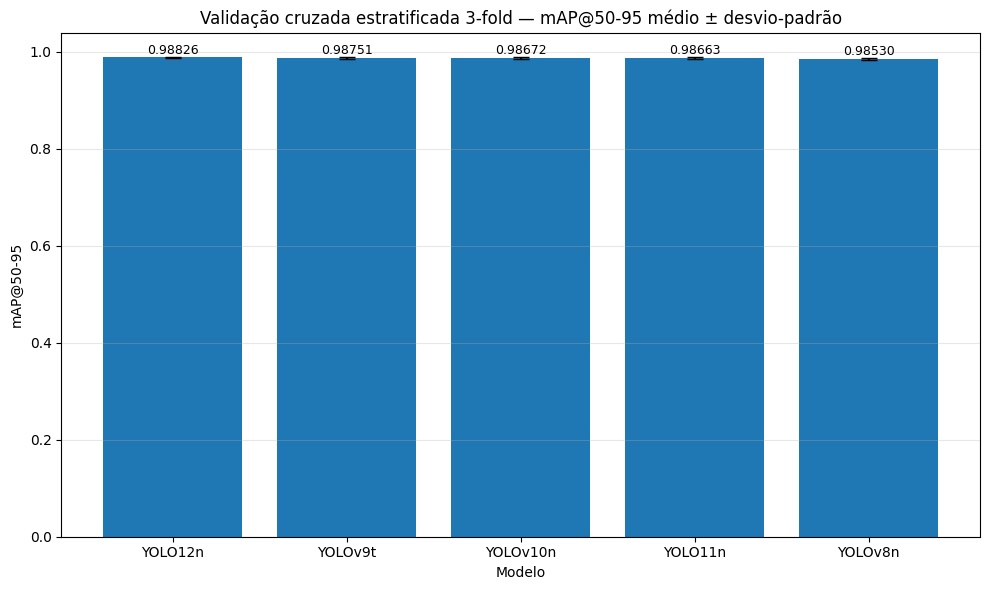

✅ /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa49_consolidacao_estatistica/02_FIGURAS/F49_1_MAP5095_MEDIA_DESVIO_3FOLD.png


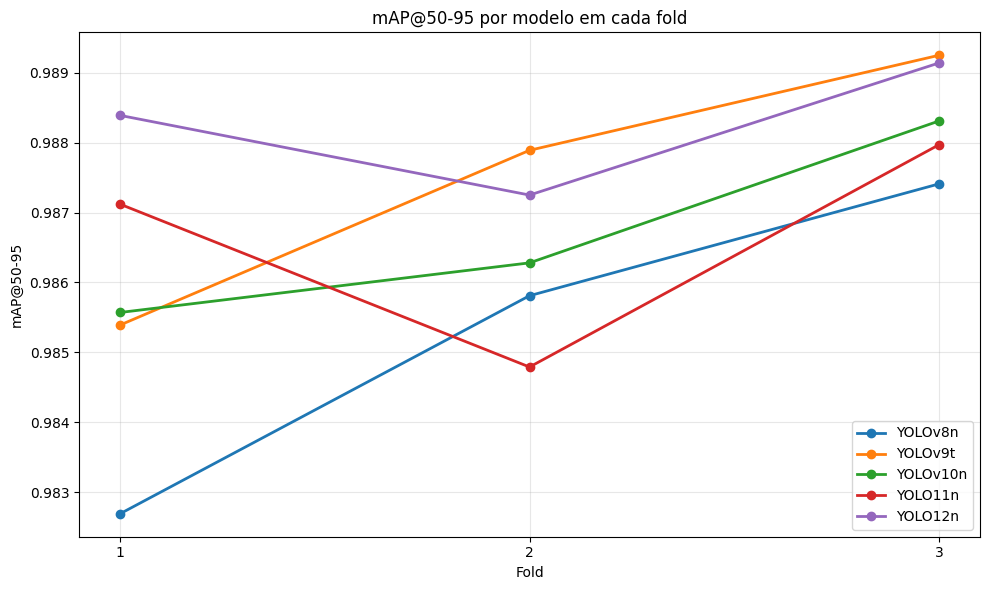

✅ /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa49_consolidacao_estatistica/02_FIGURAS/F49_2_MAP5095_POR_FOLD.png


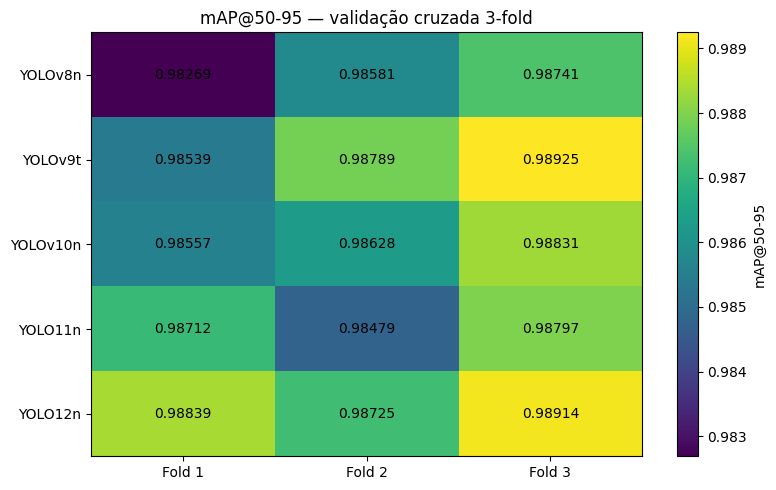

✅ /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa49_consolidacao_estatistica/02_FIGURAS/F49_3_HEATMAP_MAP5095_3FOLD.png

----------------------------------------------------------------------------------------------------------------
20. PERSISTÊNCIA DAS TABELAS
----------------------------------------------------------------------------------------------------------------
✅ T49_1_RESULTADOS_15_EXECUCOES.csv
✅ T49_2_ESTATISTICAS_POR_MODELO.csv
✅ T49_3_RANKING_POR_FOLD.csv
✅ T49_4_RANKING_MEDIO.csv
✅ T49_5_VENCEDORES_POR_FOLD.csv
✅ T49_6_ESTABILIDADE.csv
✅ T49_7_TEMPO_COMPUTACIONAL.csv
✅ T49_8_AUDITORIA_CHECKPOINTS.csv
✅ T49_9_ANOMALIAS_NUMERICAS.csv
✅ T49_10_TABELA_COMPACTA_RELATORIO_SLIDE.csv

----------------------------------------------------------------------------------------------------------------
21. INTERPRETAÇÃO CONTROLADA
----------------------------------------------------------------------------------------------------------

In [6]:
# ============================================================================================================
# ETAPA 49 — CONSOLIDAÇÃO ESTATÍSTICA E AUDITORIA DA VALIDAÇÃO CRUZADA 3-FOLD
# VERSÃO CORRIGIDA PARA O ESQUEMA REAL DA ETAPA 48
# ============================================================================================================
#
# Objetivos:
# 1) Recuperar exclusivamente os resultados persistidos da Etapa 48.
# 2) Auditar os 15 treinamentos (3 folds × 5 modelos).
# 3) Verificar a existência dos checkpoints best.pt e calcular SHA-256.
# 4) Auditar os results.csv de cada execução em busca de NaN/Inf.
# 5) Investigar especialmente YOLO12n / Fold 2.
# 6) Consolidar média, desvio-padrão, mínimo, máximo e IC95% das métricas.
# 7) Produzir rankings por fold e ranking médio.
# 8) Gerar tabelas e figuras prontas para relatório / Prism / apresentação.
# 9) NÃO treinar, NÃO inferir, NÃO utilizar TEST, NÃO alterar resultados anteriores.
#
# ============================================================================================================

import os
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================================================
# 0. CABEÇALHO
# ============================================================================================================

print("=" * 112)
print("ETAPA 49 — CONSOLIDAÇÃO ESTATÍSTICA E AUDITORIA DA VALIDAÇÃO CRUZADA 3-FOLD")
print("=" * 112)


# ============================================================================================================
# 1. GOOGLE DRIVE
# ============================================================================================================

print("\n" + "-" * 112)
print("1. GOOGLE DRIVE")
print("-" * 112)

from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("✅ Google Drive montado.")
else:
    print("✅ Google Drive já montado.")


# ============================================================================================================
# 2. CAMINHOS
# ============================================================================================================

print("\n" + "-" * 112)
print("2. CAMINHOS")
print("-" * 112)

BASE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

ETAPA48 = (
    BASE
    / "resultados"
    / "validacao_cruzada"
    / "etapa48_treinamentos_3fold"
)

OUT = (
    BASE
    / "resultados"
    / "validacao_cruzada"
    / "etapa49_consolidacao_estatistica"
)

DIR_TABELAS = OUT / "01_TABELAS"
DIR_FIGURAS = OUT / "02_FIGURAS"
DIR_RELATORIOS = OUT / "03_RELATORIOS"
DIR_MANIFESTOS = OUT / "04_MANIFESTOS"
DIR_PRISM = OUT / "05_MATERIAL_PRISM"

for pasta in [
    OUT,
    DIR_TABELAS,
    DIR_FIGURAS,
    DIR_RELATORIOS,
    DIR_MANIFESTOS,
    DIR_PRISM,
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

ARQ_RESULTADOS48 = (
    ETAPA48
    / "etapa48_resultados_parciais.csv"
)

ARQ_EXECUCOES48 = (
    ETAPA48
    / "etapa48_execucoes.json"
)

ARQ_SUMMARY48 = (
    ETAPA48
    / "etapa48_summary.json"
)

print("Etapa 48 :", ETAPA48)
print("Saída    :", OUT)

necessarios = [
    ARQ_RESULTADOS48,
    ARQ_EXECUCOES48,
    ARQ_SUMMARY48,
]

faltantes = [
    str(p)
    for p in necessarios
    if not p.exists()
]

if faltantes:

    print("\n❌ Arquivos obrigatórios ausentes:")

    for p in faltantes:
        print(" -", p)

    raise FileNotFoundError(
        "A Etapa 49 foi interrompida porque faltam "
        "artefatos persistidos da Etapa 48."
    )

print("\n✅ Artefatos principais da Etapa 48 encontrados.")


# ============================================================================================================
# 3. FUNÇÕES AUXILIARES
# ============================================================================================================

print("\n" + "-" * 112)
print("3. FUNÇÕES AUXILIARES")
print("-" * 112)


def sha256_file(path, chunk_size=1024 * 1024):

    path = Path(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


def localizar_coluna(df, candidatos):

    mapa = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for candidato in candidatos:

        chave = candidato.strip().lower()

        if chave in mapa:
            return mapa[chave]

    return None


def ic95_media(valores):

    valores = np.asarray(
        valores,
        dtype=float
    )

    valores = valores[
        np.isfinite(valores)
    ]

    n = len(valores)

    if n < 2:
        return np.nan, np.nan, np.nan

    media = np.mean(valores)

    sd = np.std(
        valores,
        ddof=1
    )

    # Para n = 3:
    # graus de liberdade = 2
    # t(0.975,2) ≈ 4.30265
    if n == 3:
        tcrit = 4.30265273
    elif n == 2:
        tcrit = 12.70620474
    else:
        tcrit = 1.96

    margem = (
        tcrit
        * sd
        / math.sqrt(n)
    )

    return (
        media - margem,
        media + margem,
        margem,
    )


print("✅ Funções auxiliares carregadas.")


# ============================================================================================================
# 4. LEITURA DO CSV REAL DA ETAPA 48
# ============================================================================================================

print("\n" + "-" * 112)
print("4. RESULTADOS OFICIAIS DA ETAPA 48")
print("-" * 112)

df_raw = pd.read_csv(
    ARQ_RESULTADOS48
)

df_raw.columns = [
    str(c).strip()
    for c in df_raw.columns
]

print("Colunas encontradas:")
print(list(df_raw.columns))


# ------------------------------------------------------------------------------------------------------------
# O CSV REAL da Etapa 48 possui:
#
# Run
# fold
# model
# checkpoint_initial
# status
# started_at
# finished_at
# elapsed_seconds
# elapsed_minutes
# precision
# recall
# map50
# map50_95
# best_checkpoint
# best_checkpoint_sha256
# drive_run_dir
# error
#
# Vamos convertê-las para nomes canônicos usados na Etapa 49.
# ------------------------------------------------------------------------------------------------------------

mapping_real = {
    "Run": "Run",
    "fold": "Fold",
    "model": "Modelo",
    "checkpoint_initial": "Checkpoint_inicial",
    "status": "Status",
    "started_at": "Inicio",
    "finished_at": "Fim",
    "elapsed_seconds": "Tempo_seg",
    "elapsed_minutes": "Tempo_min",
    "precision": "Precision",
    "recall": "Recall",
    "map50": "mAP50",
    "map50_95": "mAP50-95",
    "best_checkpoint": "Best_checkpoint",
    "best_checkpoint_sha256": "Best_checkpoint_SHA256",
    "drive_run_dir": "Drive_run_dir",
    "error": "Erro",
}

df = df_raw.rename(
    columns=mapping_real
).copy()


# ============================================================================================================
# 5. VERIFICAÇÃO DAS COLUNAS OBRIGATÓRIAS
# ============================================================================================================

print("\n" + "-" * 112)
print("5. VERIFICAÇÃO DAS COLUNAS")
print("-" * 112)

colunas_obrigatorias = [
    "Fold",
    "Modelo",
    "Status",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_min",
]

ausentes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in df.columns
]

if ausentes:

    print("❌ Colunas obrigatórias ausentes:")
    print(ausentes)

    print("\nColunas após renomeação:")
    print(list(df.columns))

    raise RuntimeError(
        "A estrutura da tabela da Etapa 48 "
        "não corresponde ao esperado."
    )

print("✅ Todas as colunas necessárias foram identificadas.")


# ============================================================================================================
# 6. NORMALIZAÇÃO NUMÉRICA
# ============================================================================================================

print("\n" + "-" * 112)
print("6. NORMALIZAÇÃO DOS DADOS")
print("-" * 112)

colunas_numericas = [
    "Fold",
    "Tempo_seg",
    "Tempo_min",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
]

for coluna in colunas_numericas:

    if coluna in df.columns:

        df[coluna] = pd.to_numeric(
            df[coluna],
            errors="coerce"
        )

df["Modelo"] = (
    df["Modelo"]
    .astype(str)
    .str.strip()
)

df["Status"] = (
    df["Status"]
    .astype(str)
    .str.strip()
)

df = (
    df
    .sort_values(
        ["Fold", "Modelo"]
    )
    .reset_index(drop=True)
)

print(
    f"Registros carregados: "
    f"{len(df)}"
)

print()

print(
    df[
        [
            "Fold",
            "Modelo",
            "Status",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "Tempo_min",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================================================================
# 7. AUDITORIA ESTRUTURAL DOS 15 TREINAMENTOS
# ============================================================================================================

print("\n" + "-" * 112)
print("7. AUDITORIA ESTRUTURAL DOS 15 TREINAMENTOS")
print("-" * 112)

MODELOS_ESPERADOS = [
    "YOLOv8n",
    "YOLOv9t",
    "YOLOv10n",
    "YOLO11n",
    "YOLO12n",
]

FOLDS_ESPERADOS = [
    1,
    2,
    3,
]

pares_esperados = {
    (fold, modelo)
    for fold in FOLDS_ESPERADOS
    for modelo in MODELOS_ESPERADOS
}

pares_observados = {
    (
        int(row["Fold"]),
        row["Modelo"],
    )
    for _, row in df.iterrows()
}

faltam_pares = sorted(
    pares_esperados
    - pares_observados
)

pares_extra = sorted(
    pares_observados
    - pares_esperados
)

status_invalidos = df[
    df["Status"].str.upper()
    != "COMPLETED"
]

print(
    "Combinações esperadas  :",
    len(pares_esperados)
)

print(
    "Combinações observadas :",
    len(pares_observados)
)

print(
    "Combinações ausentes   :",
    len(faltam_pares)
)

print(
    "Combinações extras     :",
    len(pares_extra)
)

print(
    "Status não COMPLETED   :",
    len(status_invalidos)
)

if faltam_pares:

    print("\n❌ Faltam:")

    for x in faltam_pares:
        print(" -", x)

if pares_extra:

    print("\n⚠️ Extras:")

    for x in pares_extra:
        print(" -", x)

if (
    len(df) != 15
    or faltam_pares
    or len(status_invalidos) > 0
):

    raise RuntimeError(
        "Auditoria estrutural falhou. "
        "Não prosseguir com a consolidação científica."
    )

print("\n✅ Matriz 3 folds × 5 modelos completa.")
print("✅ Todos os 15 treinamentos constam como COMPLETED.")


# ============================================================================================================
# 8. AUDITORIA DOS CHECKPOINTS
# ============================================================================================================

print("\n" + "-" * 112)
print("8. AUDITORIA DOS CHECKPOINTS best.pt")
print("-" * 112)

reg_checkpoints = []

for fold in FOLDS_ESPERADOS:

    for modelo in MODELOS_ESPERADOS:

        run_dir = (
            ETAPA48
            / f"fold_{fold}"
            / modelo
        )

        best_pt = (
            run_dir
            / "weights"
            / "best.pt"
        )

        last_pt = (
            run_dir
            / "weights"
            / "last.pt"
        )

        results_csv = (
            run_dir
            / "results.csv"
        )

        registro = {
            "Fold": fold,
            "Modelo": modelo,
            "run_dir": str(run_dir),
            "best_pt_existe": best_pt.exists(),
            "last_pt_existe": last_pt.exists(),
            "results_csv_existe": results_csv.exists(),
            "best_pt_bytes": (
                best_pt.stat().st_size
                if best_pt.exists()
                else None
            ),
            "best_pt_sha256": (
                sha256_file(best_pt)
                if best_pt.exists()
                else None
            ),
            "results_csv_sha256": (
                sha256_file(results_csv)
                if results_csv.exists()
                else None
            ),
        }

        reg_checkpoints.append(
            registro
        )

df_check = pd.DataFrame(
    reg_checkpoints
)

for _, r in df_check.iterrows():

    status = (
        "✅"
        if r["best_pt_existe"]
        else "❌"
    )

    if pd.notna(
        r["best_pt_sha256"]
    ):

        hash_curto = (
            str(
                r["best_pt_sha256"]
            )[:20]
            + "..."
        )

    else:

        hash_curto = "AUSENTE"

    print(
        f"{status} "
        f"Fold {int(r['Fold'])} | "
        f"{r['Modelo']:<9} | "
        f"best.pt | "
        f"SHA-256: {hash_curto}"
    )

n_best = int(
    df_check[
        "best_pt_existe"
    ].sum()
)

print(
    f"\nbest.pt encontrados: "
    f"{n_best}/15"
)

if n_best != 15:

    raise RuntimeError(
        "Nem todos os 15 checkpoints best.pt "
        "foram encontrados."
    )

print(
    "✅ Todos os 15 checkpoints "
    "best.pt estão persistidos."
)


# ============================================================================================================
# 9. AUDITORIA DOS results.csv
# ============================================================================================================

print("\n" + "-" * 112)
print("9. AUDITORIA NUMÉRICA DOS results.csv")
print("-" * 112)

anomalias = []

resumo_runs = []

for fold in FOLDS_ESPERADOS:

    for modelo in MODELOS_ESPERADOS:

        results_csv = (
            ETAPA48
            / f"fold_{fold}"
            / modelo
            / "results.csv"
        )

        if not results_csv.exists():

            anomalias.append(
                {
                    "Fold": fold,
                    "Modelo": modelo,
                    "Tipo": "ARQUIVO_AUSENTE",
                    "Epoch": None,
                    "Coluna": "results.csv",
                    "Valor": None,
                }
            )

            continue

        rdf = pd.read_csv(
            results_csv
        )

        rdf.columns = [
            str(c).strip()
            for c in rdf.columns
        ]

        numericas = (
            rdf
            .select_dtypes(
                include=[np.number]
            )
            .columns
            .tolist()
        )

        run_anom = 0

        for idx, row in rdf.iterrows():

            if "epoch" in rdf.columns:

                epoch_val = row["epoch"]

            else:

                epoch_val = idx + 1

            for col in numericas:

                val = row[col]

                if pd.isna(val):

                    anomalias.append(
                        {
                            "Fold": fold,
                            "Modelo": modelo,
                            "Tipo": "NaN",
                            "Epoch": epoch_val,
                            "Coluna": col,
                            "Valor": str(val),
                        }
                    )

                    run_anom += 1

                elif np.isinf(val):

                    anomalias.append(
                        {
                            "Fold": fold,
                            "Modelo": modelo,
                            "Tipo": (
                                "+Inf"
                                if val > 0
                                else "-Inf"
                            ),
                            "Epoch": epoch_val,
                            "Coluna": col,
                            "Valor": str(val),
                        }
                    )

                    run_anom += 1

        resumo_runs.append(
            {
                "Fold": fold,
                "Modelo": modelo,
                "Epocas_registradas": len(rdf),
                "Anomalias_numericas": run_anom,
            }
        )

df_run_audit = pd.DataFrame(
    resumo_runs
)

df_anom = pd.DataFrame(
    anomalias
)

print(
    df_run_audit.to_string(
        index=False
    )
)

print("\nAnomalias numéricas detectadas:")

if len(df_anom) == 0:

    print(
        "✅ Nenhum NaN ou Inf encontrado "
        "nos results.csv."
    )

else:

    print(
        df_anom.to_string(
            index=False
        )
    )


# ============================================================================================================
# 10. AUDITORIA ESPECÍFICA — YOLO12n / FOLD 2
# ============================================================================================================

print("\n" + "-" * 112)
print("10. AUDITORIA ESPECÍFICA — YOLO12n / FOLD 2")
print("-" * 112)

alvo_csv = (
    ETAPA48
    / "fold_2"
    / "YOLO12n"
    / "results.csv"
)

if alvo_csv.exists():

    alvo = pd.read_csv(
        alvo_csv
    )

    alvo.columns = [
        str(c).strip()
        for c in alvo.columns
    ]

    print(
        "results.csv:",
        alvo_csv
    )

    print(
        "Épocas registradas:",
        len(alvo)
    )

    cols_interesse = []

    for c in alvo.columns:

        lc = c.lower()

        if (
            lc == "epoch"
            or "train/box_loss" in lc
            or "metrics/precision" in lc
            or "metrics/recall" in lc
            or "metrics/map50" in lc
        ):

            cols_interesse.append(
                c
            )

    if not cols_interesse:

        cols_interesse = list(
            alvo.columns
        )

    print("\nHistórico selecionado:")

    print(
        alvo[
            cols_interesse
        ].to_string(
            index=False
        )
    )

    numeric_alvo = (
        alvo
        .select_dtypes(
            include=[np.number]
        )
    )

    mask_inf = np.isinf(
        numeric_alvo.to_numpy()
    )

    n_inf = int(
        mask_inf.sum()
    )

    print(
        "\nValores Inf encontrados "
        f"nesta execução: {n_inf}"
    )

    if n_inf > 0:

        print(
            "⚠️ Foi confirmada ocorrência "
            "numérica não finita durante "
            "o treinamento."
        )

    ultima = (
        numeric_alvo
        .iloc[-1]
    )

    ultima_finita = bool(
        np.isfinite(
            ultima.to_numpy(
                dtype=float
            )
        ).all()
    )

    print(
        "Última época com todas as "
        "colunas numéricas finitas:",
        (
            "✅ SIM"
            if ultima_finita
            else "❌ NÃO"
        ),
    )

    linha_oficial = df[
        (df["Fold"] == 2)
        &
        (df["Modelo"] == "YOLO12n")
    ].iloc[0]

    finais = np.array(
        [
            linha_oficial[
                "Precision"
            ],
            linha_oficial[
                "Recall"
            ],
            linha_oficial[
                "mAP50"
            ],
            linha_oficial[
                "mAP50-95"
            ],
        ],
        dtype=float,
    )

    finais_finitos = bool(
        np.isfinite(
            finais
        ).all()
    )

    print(
        "Métricas oficiais finais "
        "da Etapa 48 finitas:",
        (
            "✅ SIM"
            if finais_finitos
            else "❌ NÃO"
        ),
    )

    print(
        f"Precision : "
        f"{linha_oficial['Precision']:.6f}"
    )

    print(
        f"Recall    : "
        f"{linha_oficial['Recall']:.6f}"
    )

    print(
        f"mAP@50    : "
        f"{linha_oficial['mAP50']:.6f}"
    )

    print(
        f"mAP@50-95 : "
        f"{linha_oficial['mAP50-95']:.6f}"
    )

    if (
        n_inf > 0
        and ultima_finita
        and finais_finitos
    ):

        conclusao_inf = (
            "Foi detectado valor não finito isolado "
            "durante o treinamento do YOLO12n no Fold 2. "
            "As épocas subsequentes retornaram a valores "
            "finitos e as métricas finais persistidas "
            "também são finitas. A ocorrência permanece "
            "registrada como ressalva metodológica."
        )

    elif n_inf == 0:

        conclusao_inf = (
            "Nenhuma ocorrência não finita foi localizada "
            "no results.csv persistido do YOLO12n no Fold 2."
        )

    else:

        conclusao_inf = (
            "A ocorrência não finita não pôde ser "
            "considerada isolada de forma segura. "
            "Recomenda-se revisão manual."
        )

else:

    conclusao_inf = (
        "results.csv de YOLO12n / Fold 2 "
        "não encontrado."
    )

print("\nConclusão da auditoria:")

print(
    conclusao_inf
)


# ============================================================================================================
# 11. CONSOLIDAÇÃO ESTATÍSTICA
# ============================================================================================================

print("\n" + "-" * 112)
print("11. CONSOLIDAÇÃO ESTATÍSTICA POR MODELO")
print("-" * 112)

metricas = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95",
    "Tempo_min",
]

linhas_stats = []

for modelo in MODELOS_ESPERADOS:

    d = df[
        df["Modelo"]
        == modelo
    ].copy()

    linha = {
        "Modelo": modelo,
        "n_folds": len(d),
    }

    for metrica in metricas:

        valores = (
            d[metrica]
            .astype(float)
            .to_numpy()
        )

        media = float(
            np.mean(valores)
        )

        sd = float(
            np.std(
                valores,
                ddof=1
            )
        )

        minimo = float(
            np.min(valores)
        )

        maximo = float(
            np.max(valores)
        )

        (
            ci_low,
            ci_high,
            ci_margem,
        ) = ic95_media(
            valores
        )

        prefix = (
            metrica
            .replace("-", "_")
            .replace("@", "")
        )

        linha[
            f"{prefix}_media"
        ] = media

        linha[
            f"{prefix}_sd"
        ] = sd

        linha[
            f"{prefix}_min"
        ] = minimo

        linha[
            f"{prefix}_max"
        ] = maximo

        linha[
            f"{prefix}_IC95_low"
        ] = ci_low

        linha[
            f"{prefix}_IC95_high"
        ] = ci_high

        linha[
            f"{prefix}_IC95_margem"
        ] = ci_margem

    linhas_stats.append(
        linha
    )

stats = pd.DataFrame(
    linhas_stats
)

stats = (
    stats
    .sort_values(
        "mAP50_95_media",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

stats.insert(
    0,
    "Ranking_mAP50_95",
    np.arange(
        1,
        len(stats) + 1
    ),
)

print(
    stats[
        [
            "Ranking_mAP50_95",
            "Modelo",
            "Precision_media",
            "Precision_sd",
            "Recall_media",
            "Recall_sd",
            "mAP50_media",
            "mAP50_sd",
            "mAP50_95_media",
            "mAP50_95_sd",
            "Tempo_min_media",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================================================================
# 12. RANKING POR FOLD
# ============================================================================================================

print("\n" + "-" * 112)
print("12. RANKING POR FOLD")
print("-" * 112)

ranking_fold = df[
    [
        "Fold",
        "Modelo",
        "mAP50-95",
    ]
].copy()

ranking_fold[
    "Ranking_no_fold"
] = (
    ranking_fold
    .groupby(
        "Fold"
    )[
        "mAP50-95"
    ]
    .rank(
        method="min",
        ascending=False,
    )
)

ranking_fold = (
    ranking_fold
    .sort_values(
        [
            "Fold",
            "Ranking_no_fold",
            "Modelo",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    ranking_fold.to_string(
        index=False
    )
)

ranking_medio = (
    ranking_fold
    .groupby(
        "Modelo",
        as_index=False,
    )
    .agg(
        Ranking_medio=(
            "Ranking_no_fold",
            "mean",
        ),
        Melhor_ranking=(
            "Ranking_no_fold",
            "min",
        ),
        Pior_ranking=(
            "Ranking_no_fold",
            "max",
        ),
    )
)

ranking_medio = (
    ranking_medio
    .sort_values(
        [
            "Ranking_medio",
            "Modelo",
        ]
    )
    .reset_index(
        drop=True
    )
)

print("\nRanking médio:")

print(
    ranking_medio.to_string(
        index=False
    )
)


# ============================================================================================================
# 13. VENCEDORES POR FOLD
# ============================================================================================================

print("\n" + "-" * 112)
print("13. VENCEDORES POR FOLD")
print("-" * 112)

vencedores_fold = []

for fold in FOLDS_ESPERADOS:

    d = df[
        df["Fold"]
        == fold
    ]

    vmax = d[
        "mAP50-95"
    ].max()

    winners = d[
        np.isclose(
            d["mAP50-95"],
            vmax,
            rtol=0,
            atol=1e-12,
        )
    ]

    for _, r in winners.iterrows():

        vencedores_fold.append(
            {
                "Fold": fold,
                "Modelo": r[
                    "Modelo"
                ],
                "mAP50-95": r[
                    "mAP50-95"
                ],
            }
        )

df_vencedores = pd.DataFrame(
    vencedores_fold
)

print(
    df_vencedores.to_string(
        index=False
    )
)


# ============================================================================================================
# 14. ESTABILIDADE ENTRE FOLDS
# ============================================================================================================

print("\n" + "-" * 112)
print("14. ESTABILIDADE ENTRE FOLDS")
print("-" * 112)

estabilidade = stats[
    [
        "Modelo",
        "mAP50_95_media",
        "mAP50_95_sd",
        "mAP50_95_min",
        "mAP50_95_max",
    ]
].copy()

estabilidade[
    "Amplitude_mAP50_95"
] = (
    estabilidade[
        "mAP50_95_max"
    ]
    -
    estabilidade[
        "mAP50_95_min"
    ]
)

estabilidade[
    "CV_percentual"
] = (
    estabilidade[
        "mAP50_95_sd"
    ]
    /
    estabilidade[
        "mAP50_95_media"
    ]
    * 100.0
)

estabilidade = (
    estabilidade
    .sort_values(
        [
            "mAP50_95_sd",
            "Modelo",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    estabilidade.to_string(
        index=False
    )
)


# ============================================================================================================
# 15. TEMPO COMPUTACIONAL
# ============================================================================================================

print("\n" + "-" * 112)
print("15. TEMPO COMPUTACIONAL")
print("-" * 112)

tempo_total_min = float(
    df[
        "Tempo_min"
    ].sum()
)

tempo_total_h = (
    tempo_total_min
    / 60.0
)

tempo_modelo = (
    df
    .groupby(
        "Modelo",
        as_index=False,
    )
    .agg(
        Tempo_total_min=(
            "Tempo_min",
            "sum",
        ),
        Tempo_medio_min=(
            "Tempo_min",
            "mean",
        ),
        Tempo_sd_min=(
            "Tempo_min",
            "std",
        ),
    )
    .sort_values(
        "Tempo_medio_min"
    )
)

print(
    "Tempo total registrado "
    f"dos 15 treinamentos: "
    f"{tempo_total_min:.2f} min"
)

print(
    "Tempo total registrado "
    f"dos 15 treinamentos: "
    f"{tempo_total_h:.2f} h"
)

print()

print(
    tempo_modelo.to_string(
        index=False
    )
)


# ============================================================================================================
# 16. TABELA COMPACTA
# ============================================================================================================

print("\n" + "-" * 112)
print("16. TABELA COMPACTA PARA RELATÓRIO / SLIDE")
print("-" * 112)

compacta = stats[
    [
        "Ranking_mAP50_95",
        "Modelo",
        "Precision_media",
        "Precision_sd",
        "Recall_media",
        "Recall_sd",
        "mAP50_media",
        "mAP50_sd",
        "mAP50_95_media",
        "mAP50_95_sd",
        "Tempo_min_media",
    ]
].copy()

compacta.columns = [
    "Rank",
    "Modelo",
    "Precision média",
    "Precision SD",
    "Recall médio",
    "Recall SD",
    "mAP@50 médio",
    "mAP@50 SD",
    "mAP@50-95 médio",
    "mAP@50-95 SD",
    "Tempo médio (min)",
]

print(
    compacta.to_string(
        index=False
    )
)


# ============================================================================================================
# 17. FIGURA 1 — MÉDIA ± DESVIO-PADRÃO
# ============================================================================================================

print("\n" + "-" * 112)
print("17. GERAÇÃO DAS FIGURAS")
print("-" * 112)

plot_stats = (
    stats
    .sort_values(
        "mAP50_95_media",
        ascending=False,
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

x = np.arange(
    len(plot_stats)
)

ax.bar(
    x,
    plot_stats[
        "mAP50_95_media"
    ],
    yerr=plot_stats[
        "mAP50_95_sd"
    ],
    capsize=6,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_stats[
        "Modelo"
    ]
)

ax.set_ylabel(
    "mAP@50-95"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_title(
    "Validação cruzada estratificada 3-fold — "
    "mAP@50-95 médio ± desvio-padrão"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

for i, (_, r) in enumerate(
    plot_stats.iterrows()
):

    ax.text(
        i,
        (
            r[
                "mAP50_95_media"
            ]
            +
            r[
                "mAP50_95_sd"
            ]
            +
            0.0003
        ),
        f"{r['mAP50_95_media']:.5f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()

F1 = (
    DIR_FIGURAS
    / "F49_1_MAP5095_MEDIA_DESVIO_3FOLD.png"
)

fig.savefig(
    F1,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("✅", F1)


# ============================================================================================================
# 18. FIGURA 2 — RESULTADOS POR FOLD
# ============================================================================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for modelo in MODELOS_ESPERADOS:

    d = (
        df[
            df["Modelo"]
            == modelo
        ]
        .sort_values(
            "Fold"
        )
    )

    ax.plot(
        d["Fold"],
        d["mAP50-95"],
        marker="o",
        linewidth=2,
        label=modelo,
    )

ax.set_xticks(
    FOLDS_ESPERADOS
)

ax.set_xlabel(
    "Fold"
)

ax.set_ylabel(
    "mAP@50-95"
)

ax.set_title(
    "mAP@50-95 por modelo em cada fold"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

F2 = (
    DIR_FIGURAS
    / "F49_2_MAP5095_POR_FOLD.png"
)

fig.savefig(
    F2,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("✅", F2)


# ============================================================================================================
# 19. FIGURA 3 — HEATMAP
# ============================================================================================================

pivot = df.pivot(
    index="Modelo",
    columns="Fold",
    values="mAP50-95",
)

pivot = pivot.reindex(
    MODELOS_ESPERADOS
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

im = ax.imshow(
    pivot.values,
    aspect="auto",
)

ax.set_xticks(
    np.arange(
        len(
            pivot.columns
        )
    )
)

ax.set_xticklabels(
    [
        f"Fold {int(c)}"
        for c in pivot.columns
    ]
)

ax.set_yticks(
    np.arange(
        len(
            pivot.index
        )
    )
)

ax.set_yticklabels(
    pivot.index
)

ax.set_title(
    "mAP@50-95 — validação cruzada 3-fold"
)

for i in range(
    pivot.shape[0]
):

    for j in range(
        pivot.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{pivot.iloc[i, j]:.5f}",
            ha="center",
            va="center",
        )

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "mAP@50-95"
)

fig.tight_layout()

F3 = (
    DIR_FIGURAS
    / "F49_3_HEATMAP_MAP5095_3FOLD.png"
)

fig.savefig(
    F3,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("✅", F3)


# ============================================================================================================
# 20. SALVAR TABELAS
# ============================================================================================================

print("\n" + "-" * 112)
print("20. PERSISTÊNCIA DAS TABELAS")
print("-" * 112)

P_RAW = (
    DIR_TABELAS
    / "T49_1_RESULTADOS_15_EXECUCOES.csv"
)

P_STATS = (
    DIR_TABELAS
    / "T49_2_ESTATISTICAS_POR_MODELO.csv"
)

P_RANK = (
    DIR_TABELAS
    / "T49_3_RANKING_POR_FOLD.csv"
)

P_RANK_MEDIO = (
    DIR_TABELAS
    / "T49_4_RANKING_MEDIO.csv"
)

P_VENCEDORES = (
    DIR_TABELAS
    / "T49_5_VENCEDORES_POR_FOLD.csv"
)

P_ESTABILIDADE = (
    DIR_TABELAS
    / "T49_6_ESTABILIDADE.csv"
)

P_TEMPO = (
    DIR_TABELAS
    / "T49_7_TEMPO_COMPUTACIONAL.csv"
)

P_CHECK = (
    DIR_TABELAS
    / "T49_8_AUDITORIA_CHECKPOINTS.csv"
)

P_ANOM = (
    DIR_TABELAS
    / "T49_9_ANOMALIAS_NUMERICAS.csv"
)

P_COMPACTA = (
    DIR_TABELAS
    / "T49_10_TABELA_COMPACTA_RELATORIO_SLIDE.csv"
)

df.to_csv(
    P_RAW,
    index=False
)

stats.to_csv(
    P_STATS,
    index=False
)

ranking_fold.to_csv(
    P_RANK,
    index=False
)

ranking_medio.to_csv(
    P_RANK_MEDIO,
    index=False
)

df_vencedores.to_csv(
    P_VENCEDORES,
    index=False
)

estabilidade.to_csv(
    P_ESTABILIDADE,
    index=False
)

tempo_modelo.to_csv(
    P_TEMPO,
    index=False
)

df_check.to_csv(
    P_CHECK,
    index=False
)

if len(df_anom) > 0:

    df_anom.to_csv(
        P_ANOM,
        index=False
    )

else:

    pd.DataFrame(
        columns=[
            "Fold",
            "Modelo",
            "Tipo",
            "Epoch",
            "Coluna",
            "Valor",
        ]
    ).to_csv(
        P_ANOM,
        index=False
    )

compacta.to_csv(
    P_COMPACTA,
    index=False
)

for p in [
    P_RAW,
    P_STATS,
    P_RANK,
    P_RANK_MEDIO,
    P_VENCEDORES,
    P_ESTABILIDADE,
    P_TEMPO,
    P_CHECK,
    P_ANOM,
    P_COMPACTA,
]:

    print(
        "✅",
        p.name
    )


# ============================================================================================================
# 21. INTERPRETAÇÃO CONTROLADA
# ============================================================================================================

print("\n" + "-" * 112)
print("21. INTERPRETAÇÃO CONTROLADA")
print("-" * 112)

best_media = (
    stats.iloc[0]
)

mais_estavel = (
    estabilidade.iloc[0]
)

menor_tempo = (
    tempo_modelo.iloc[0]
)

print(
    "Maior mAP@50-95 médio : "
    f"{best_media['Modelo']} | "
    f"{best_media['mAP50_95_media']:.6f} ± "
    f"{best_media['mAP50_95_sd']:.6f}"
)

print(
    "Menor dispersão       : "
    f"{mais_estavel['Modelo']} | "
    f"DP = "
    f"{mais_estavel['mAP50_95_sd']:.6f}"
)

print(
    "Menor tempo médio     : "
    f"{menor_tempo['Modelo']} | "
    f"{menor_tempo['Tempo_medio_min']:.2f} min"
)

print(
    "Tempo total           : "
    f"{tempo_total_min:.2f} min "
    f"= {tempo_total_h:.2f} h"
)

print("\n⚠️ Interpretação científica:")

print(
    "A ordenação descreve exclusivamente os três "
    "folds desta validação cruzada. "
    "Ela não demonstra significância estatística "
    "nem superioridade universal."
)


# ============================================================================================================
# 22. MATERIAL CONTROLADO PARA O PRISM
# ============================================================================================================

print("\n" + "-" * 112)
print("22. MATERIAL CONTROLADO PARA O PRISM")
print("-" * 112)

prism_md = (
    DIR_PRISM
    / "etapa49_fonte_controlada_validacao_cruzada.md"
)

with open(
    prism_md,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        "# ETAPA 49 — FONTE CONTROLADA "
        "DA VALIDAÇÃO CRUZADA 3-FOLD\n\n"
    )

    f.write(
        "## Status experimental\n\n"
    )

    f.write(
        "- Validação cruzada: estratificada, 3 folds.\n"
    )

    f.write(
        "- Conjunto utilizado: TRAIN + VAL originais "
        "= desenvolvimento.\n"
    )

    f.write(
        "- TEST original: **NÃO utilizado na validação cruzada**.\n"
    )

    f.write(
        "- Modelos: 5.\n"
    )

    f.write(
        "- Treinamentos: 15.\n"
    )

    f.write(
        "- Treinamentos concluídos: 15.\n"
    )

    f.write(
        "- Treinamentos falhos: 0.\n"
    )

    f.write(
        "- Resultados anteriores do TEST: inalterados.\n\n"
    )

    f.write(
        "## Estatísticas consolidadas\n\n"
    )

    f.write(
        "| Rank | Modelo | Precision média ± DP | "
        "Recall médio ± DP | mAP@50 médio ± DP | "
        "mAP@50-95 médio ± DP | Tempo médio (min) |\n"
    )

    f.write(
        "|---:|---|---:|---:|---:|---:|---:|\n"
    )

    for _, r in stats.iterrows():

        f.write(
            f"| {int(r['Ranking_mAP50_95'])} "
            f"| {r['Modelo']} "
            f"| {r['Precision_media']:.6f} ± {r['Precision_sd']:.6f} "
            f"| {r['Recall_media']:.6f} ± {r['Recall_sd']:.6f} "
            f"| {r['mAP50_media']:.6f} ± {r['mAP50_sd']:.6f} "
            f"| {r['mAP50_95_media']:.6f} ± {r['mAP50_95_sd']:.6f} "
            f"| {r['Tempo_min_media']:.2f} |\n"
        )

    f.write(
        "\n## Vencedores por fold em mAP@50-95\n\n"
    )

    for _, r in df_vencedores.iterrows():

        f.write(
            f"- Fold {int(r['Fold'])}: "
            f"{r['Modelo']} = "
            f"{r['mAP50-95']:.6f}\n"
        )

    f.write(
        "\n## Resultado principal\n\n"
    )

    f.write(
        f"O maior mAP@50-95 médio foi obtido por "
        f"{best_media['Modelo']}, com "
        f"{best_media['mAP50_95_media']:.6f} ± "
        f"{best_media['mAP50_95_sd']:.6f} "
        f"(média ± desvio-padrão).\n\n"
    )

    f.write(
        "Esse resultado caracteriza o comportamento "
        "observado nesta validação cruzada de três folds. "
        "Não demonstra significância estatística e não "
        "autoriza afirmações de superioridade universal.\n\n"
    )

    f.write(
        "## Auditoria do YOLO12n / Fold 2\n\n"
    )

    f.write(
        conclusao_inf
        + "\n\n"
    )

    f.write(
        "## Tempo computacional\n\n"
    )

    f.write(
        f"Tempo total registrado para os 15 treinamentos: "
        f"{tempo_total_min:.2f} minutos "
        f"({tempo_total_h:.2f} horas).\n\n"
    )

    f.write(
        "## Figuras da Etapa 49\n\n"
    )

    f.write(
        "- F49_1_MAP5095_MEDIA_DESVIO_3FOLD.png\n"
    )

    f.write(
        "- F49_2_MAP5095_POR_FOLD.png\n"
    )

    f.write(
        "- F49_3_HEATMAP_MAP5095_3FOLD.png\n\n"
    )

    f.write(
        "## Restrições obrigatórias de interpretação\n\n"
    )

    f.write(
        "- Não afirmar significância estatística sem teste apropriado.\n"
    )

    f.write(
        "- Não afirmar superioridade universal de uma arquitetura.\n"
    )

    f.write(
        "- Não misturar estes resultados de validação cruzada "
        "com os resultados do TEST original.\n"
    )

    f.write(
        "- Não afirmar que o TEST participou dos folds.\n"
    )

    f.write(
        "- Não substituir os resultados congelados anteriores do TEST.\n"
    )

    f.write(
        "- Não ocultar ocorrência numérica não finita, se confirmada.\n"
    )

print(
    "✅ Fonte controlada para o Prism salva:"
)

print(
    prism_md
)


# ============================================================================================================
# 23. RELATÓRIO DA ETAPA 49
# ============================================================================================================

print("\n" + "-" * 112)
print("23. RELATÓRIO DA ETAPA 49")
print("-" * 112)

relatorio_md = (
    DIR_RELATORIOS
    / "etapa49_relatorio_consolidacao_estatistica.md"
)

with open(
    relatorio_md,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        "# ETAPA 49 — CONSOLIDAÇÃO ESTATÍSTICA "
        "DA VALIDAÇÃO CRUZADA\n\n"
    )

    f.write(
        "## Controle experimental\n\n"
    )

    f.write(
        "- Novo treinamento nesta etapa: NÃO\n"
    )

    f.write(
        "- Nova inferência nesta etapa: NÃO\n"
    )

    f.write(
        "- Uso do TEST original nesta etapa: NÃO\n"
    )

    f.write(
        "- Resultados anteriores alterados: NÃO\n\n"
    )

    f.write(
        "## Estrutura auditada\n\n"
    )

    f.write(
        "- Folds: 3\n"
    )

    f.write(
        "- Modelos: 5\n"
    )

    f.write(
        "- Execuções: 15\n"
    )

    f.write(
        f"- Checkpoints best.pt encontrados: {n_best}/15\n"
    )

    f.write(
        f"- Tempo total registrado: "
        f"{tempo_total_min:.2f} min "
        f"({tempo_total_h:.2f} h)\n\n"
    )

    f.write(
        "## Resultado principal\n\n"
    )

    f.write(
        f"Maior mAP@50-95 médio: "
        f"{best_media['Modelo']} = "
        f"{best_media['mAP50_95_media']:.6f} ± "
        f"{best_media['mAP50_95_sd']:.6f}.\n\n"
    )

    f.write(
        "## Auditoria YOLO12n / Fold 2\n\n"
    )

    f.write(
        conclusao_inf
        + "\n\n"
    )

    f.write(
        "## Observação metodológica\n\n"
    )

    f.write(
        "Os três folds foram utilizados para estimar a "
        "variabilidade do desempenho no conjunto de desenvolvimento. "
        "O TEST original permaneceu excluído. "
        "Os resultados desta etapa complementam, mas não substituem, "
        "os resultados finais anteriormente congelados no TEST.\n"
    )

print(
    "✅ Relatório salvo:"
)

print(
    relatorio_md
)


# ============================================================================================================
# 24. HASHES E MANIFESTO
# ============================================================================================================

print("\n" + "-" * 112)
print("24. HASHES E MANIFESTO")
print("-" * 112)

arquivos_gerados = [
    P_RAW,
    P_STATS,
    P_RANK,
    P_RANK_MEDIO,
    P_VENCEDORES,
    P_ESTABILIDADE,
    P_TEMPO,
    P_CHECK,
    P_ANOM,
    P_COMPACTA,
    F1,
    F2,
    F3,
    prism_md,
    relatorio_md,
]

hash_rows = []

for p in arquivos_gerados:

    if p.exists():

        hash_rows.append(
            {
                "arquivo": str(p),
                "sha256": sha256_file(p),
                "bytes": p.stat().st_size,
            }
        )

df_hash = pd.DataFrame(
    hash_rows
)

hash_csv = (
    DIR_MANIFESTOS
    / "hashes_etapa49.csv"
)

df_hash.to_csv(
    hash_csv,
    index=False
)

manifesto = {
    "etapa": 49,
    "descricao": (
        "Consolidação estatística e auditoria "
        "da validação cruzada 3-fold"
    ),
    "timestamp": datetime.now().isoformat(),
    "fonte_principal": str(
        ARQ_RESULTADOS48
    ),
    "numero_folds": 3,
    "numero_modelos": 5,
    "numero_execucoes": 15,
    "checkpoints_best_encontrados": n_best,
    "test_original_utilizado": False,
    "novo_treinamento": False,
    "nova_inferencia": False,
    "resultados_test_alterados": False,
    "tempo_total_min": tempo_total_min,
    "tempo_total_h": tempo_total_h,
    "melhor_modelo_media_map5095": (
        best_media["Modelo"]
    ),
    "melhor_media_map5095": float(
        best_media[
            "mAP50_95_media"
        ]
    ),
    "melhor_sd_map5095": float(
        best_media[
            "mAP50_95_sd"
        ]
    ),
    "auditoria_yolo12_fold2": (
        conclusao_inf
    ),
    "hashes": str(
        hash_csv
    ),
}

manifesto_path = (
    DIR_MANIFESTOS
    / "etapa49_manifesto.json"
)

with open(
    manifesto_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifesto,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    "✅ Manifesto:"
)

print(
    manifesto_path
)

print(
    "\n✅ Hashes:"
)

print(
    hash_csv
)


# ============================================================================================================
# 25. VERIFICAÇÃO FINAL
# ============================================================================================================

print("\n" + "-" * 112)
print("25. VERIFICAÇÃO FINAL")
print("-" * 112)

checagens = {
    "15 resultados oficiais":
        len(df) == 15,

    "15 status COMPLETED":
        (
            df[
                "Status"
            ]
            .str.upper()
            == "COMPLETED"
        ).all(),

    "15 checkpoints best.pt":
        n_best == 15,

    "Tabela estatística":
        P_STATS.exists(),

    "Tabela compacta":
        P_COMPACTA.exists(),

    "Ranking por fold":
        P_RANK.exists(),

    "Auditoria de anomalias":
        P_ANOM.exists(),

    "Figura média ± DP":
        F1.exists(),

    "Figura por fold":
        F2.exists(),

    "Heatmap 3-fold":
        F3.exists(),

    "Fonte controlada Prism":
        prism_md.exists(),

    "Relatório":
        relatorio_md.exists(),

    "Manifesto":
        manifesto_path.exists(),

    "Hashes":
        hash_csv.exists(),
}

for nome, ok in checagens.items():

    print(
        f"{nome:<34}: "
        f"{'✅ OK' if ok else '❌ FALHA'}"
    )

if not all(
    checagens.values()
):

    raise RuntimeError(
        "Uma ou mais verificações finais "
        "da Etapa 49 falharam."
    )


# ============================================================================================================
# 26. RESUMO FINAL
# ============================================================================================================

print("\n" + "=" * 112)
print("RESUMO DA ETAPA 49")
print("=" * 112)

print(
    "Validação cruzada             : "
    "3-fold estratificada"
)

print(
    "Modelos                       : 5"
)

print(
    "Execuções consolidadas        : 15"
)

print(
    "Checkpoints best.pt auditados : "
    f"{n_best}/15"
)

print(
    "Tempo total registrado        : "
    f"{tempo_total_min:.2f} min "
    f"({tempo_total_h:.2f} h)"
)

print()

print(
    "Maior mAP@50-95 médio         : "
    f"{best_media['Modelo']} = "
    f"{best_media['mAP50_95_media']:.6f} ± "
    f"{best_media['mAP50_95_sd']:.6f}"
)

print(
    "Modelo com menor dispersão    : "
    f"{mais_estavel['Modelo']} | "
    f"DP = "
    f"{mais_estavel['mAP50_95_sd']:.6f}"
)

print()

print(
    "Auditoria YOLO12n / Fold 2:"
)

print(
    conclusao_inf
)

print()

print(
    "Saída geral:"
)

print(
    OUT
)

print()

print(
    "Novo treinamento realizado    : NÃO"
)

print(
    "Nova inferência realizada     : NÃO"
)

print(
    "TEST original utilizado       : NÃO"
)

print(
    "Resultados anteriores alterados: NÃO"
)

print()

print(
    "🔒 TEST original permanece intocado."
)

print(
    "🔒 Resultados finais anteriores "
    "permanecem congelados."
)

print(
    "✅ Validação cruzada consolidada estatisticamente."
)

print(
    "✅ Material para relatório, Prism e apresentação gerado."
)

print("=" * 112)
print("ETAPA 49 CONCLUÍDA")
print("=" * 112)

ETAPA 50 — AUDITORIA FINAL DOS CHECKPOINTS E FECHAMENTO CIENTÍFICO

----------------------------------------------------------------------------------------------------------------
1. CAMINHOS
----------------------------------------------------------------------------------------------------------------
Etapa 48 : /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa48_treinamentos_3fold
Etapa 49 : /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa49_consolidacao_estatistica
Saída    : /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa50_fechamento_cientifico

✅ Caminhos encontrados.

----------------------------------------------------------------------------------------------------------------
2. DEFINIÇÕES
----------------------------------------------------------------------------------------------------------------
Modelos : ['YOLOv8n', 'YOLOv9t', 'Y

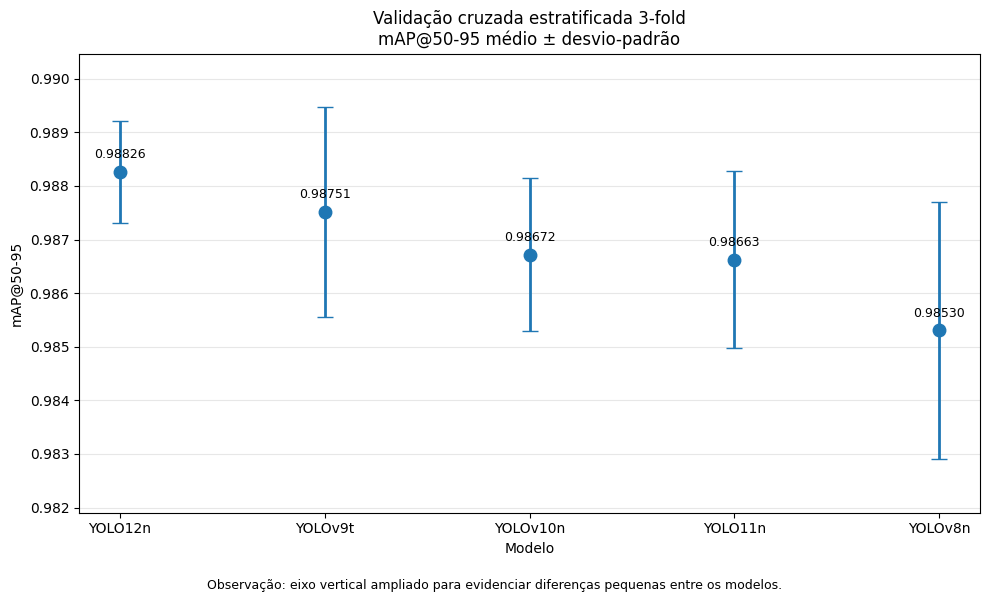

✅ /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa50_fechamento_cientifico/02_FIGURAS/F50_1_MAP5095_MEDIA_DP_EIXO_AMPLIADO.png


/tmp/ipykernel_1381/448684596.py:1110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


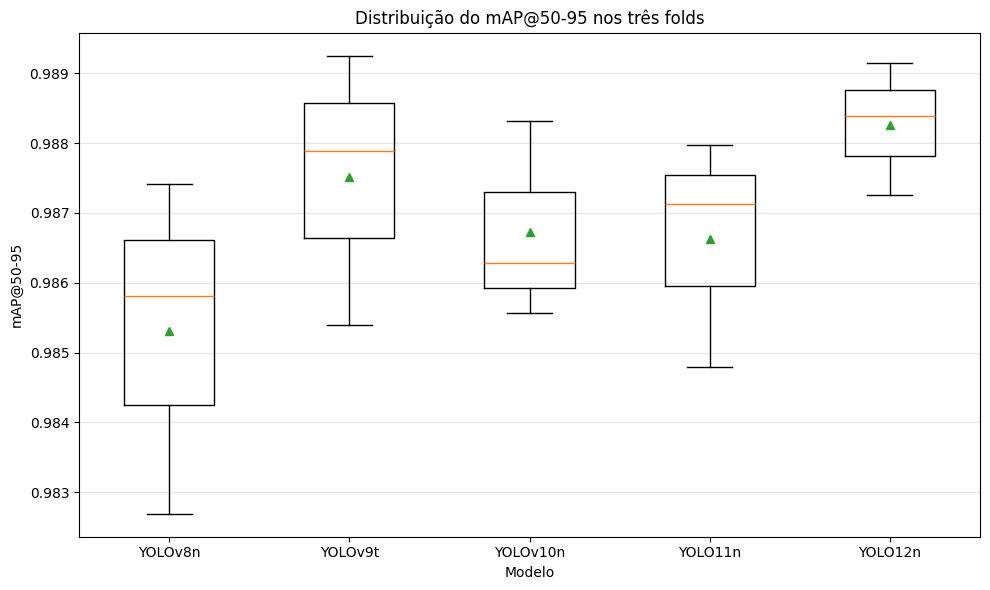

✅ /content/drive/MyDrive/COC891_DL_Trabalho_Final_PlantVillage/resultados/validacao_cruzada/etapa50_fechamento_cientifico/02_FIGURAS/F50_2_DISTRIBUICAO_MAP5095_3FOLD.png

----------------------------------------------------------------------------------------------------------------
14. PERSISTÊNCIA DAS TABELAS
----------------------------------------------------------------------------------------------------------------
✅ T50_1_AUDITORIA_ULTIMA_VS_MELHOR_EPOCA.csv
✅ T50_2_RESULTADO_OFICIAL_VALIDACAO_CRUZADA.csv
✅ T50_3_RESULTADOS_MELHOR_EPOCA_SENSIBILIDADE.csv
✅ T50_4_COMPARACAO_RANKINGS.csv

----------------------------------------------------------------------------------------------------------------
15. RESULTADO PRINCIPAL
----------------------------------------------------------------------------------------------------------------
Maior mAP@50-95 médio:
YOLO12n = 0.988260 ± 0.000952

IMPORTANTE:
Este resultado é DESCRITIVO para a validação cruzada de três folds.
Não foi realiz

In [7]:
# ============================================================================================================
# ETAPA 50 — AUDITORIA FINAL DOS CHECKPOINTS E FECHAMENTO CIENTÍFICO DA VALIDAÇÃO CRUZADA
# ============================================================================================================
#
# OBJETIVOS:
#
# 1. NÃO treinar nenhum modelo.
# 2. NÃO realizar inferência.
# 3. NÃO utilizar o conjunto TEST.
# 4. Auditar, para cada uma das 15 execuções:
#       - última época;
#       - melhor época registrada no results.csv;
#       - métricas correspondentes.
# 5. Verificar se usar a última época ou a melhor época altera:
#       - médias;
#       - ranking;
#       - interpretação científica.
# 6. Auditar especificamente YOLO12n / Fold 2.
# 7. Gerar uma tabela definitiva da validação cruzada.
# 8. Criar figuras adequadas para relatório e apresentação.
# 9. Gerar pacote final controlado para o Prism.
#
# ============================================================================================================

import os
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 112)
print("ETAPA 50 — AUDITORIA FINAL DOS CHECKPOINTS E FECHAMENTO CIENTÍFICO")
print("=" * 112)


# ============================================================================================================
# 1. CAMINHOS
# ============================================================================================================

print("\n" + "-" * 112)
print("1. CAMINHOS")
print("-" * 112)

BASE = Path(
    "/content/drive/MyDrive/"
    "COC891_DL_Trabalho_Final_PlantVillage"
)

ETAPA48 = (
    BASE
    / "resultados"
    / "validacao_cruzada"
    / "etapa48_treinamentos_3fold"
)

ETAPA49 = (
    BASE
    / "resultados"
    / "validacao_cruzada"
    / "etapa49_consolidacao_estatistica"
)

OUT = (
    BASE
    / "resultados"
    / "validacao_cruzada"
    / "etapa50_fechamento_cientifico"
)

DIR_TABELAS = OUT / "01_TABELAS"
DIR_FIGURAS = OUT / "02_FIGURAS"
DIR_RELATORIOS = OUT / "03_RELATORIOS"
DIR_PRISM = OUT / "04_MATERIAL_PRISM"
DIR_MANIFESTOS = OUT / "05_MANIFESTOS"

for pasta in [
    OUT,
    DIR_TABELAS,
    DIR_FIGURAS,
    DIR_RELATORIOS,
    DIR_PRISM,
    DIR_MANIFESTOS,
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

ARQ_ETAPA49 = (
    ETAPA49
    / "01_TABELAS"
    / "T49_1_RESULTADOS_15_EXECUCOES.csv"
)

if not ETAPA48.exists():
    raise FileNotFoundError(
        f"Etapa 48 não encontrada:\n{ETAPA48}"
    )

if not ARQ_ETAPA49.exists():
    raise FileNotFoundError(
        f"Tabela oficial da Etapa 49 não encontrada:\n{ARQ_ETAPA49}"
    )

print("Etapa 48 :", ETAPA48)
print("Etapa 49 :", ETAPA49)
print("Saída    :", OUT)

print("\n✅ Caminhos encontrados.")


# ============================================================================================================
# 2. DEFINIÇÕES
# ============================================================================================================

print("\n" + "-" * 112)
print("2. DEFINIÇÕES")
print("-" * 112)

MODELOS = [
    "YOLOv8n",
    "YOLOv9t",
    "YOLOv10n",
    "YOLO11n",
    "YOLO12n",
]

FOLDS = [
    1,
    2,
    3,
]

print("Modelos :", MODELOS)
print("Folds   :", FOLDS)
print("TEST    : NÃO UTILIZADO")


# ============================================================================================================
# 3. FUNÇÕES AUXILIARES
# ============================================================================================================

print("\n" + "-" * 112)
print("3. FUNÇÕES AUXILIARES")
print("-" * 112)


def sha256_file(path):

    path = Path(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def localizar_coluna(df, alternativas):

    mapa = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for nome in alternativas:

        chave = nome.strip().lower()

        if chave in mapa:
            return mapa[chave]

    return None


print("✅ Funções carregadas.")


# ============================================================================================================
# 4. LEITURA DA ETAPA 49
# ============================================================================================================

print("\n" + "-" * 112)
print("4. RESULTADOS CONSOLIDADOS DA ETAPA 49")
print("-" * 112)

df49 = pd.read_csv(
    ARQ_ETAPA49
)

print(
    f"Registros encontrados: {len(df49)}"
)

if len(df49) != 15:

    raise RuntimeError(
        "A Etapa 49 deveria possuir exatamente 15 execuções."
    )

print("✅ 15 execuções recuperadas.")


# ============================================================================================================
# 5. AUDITORIA DE CADA results.csv
# ============================================================================================================

print("\n" + "-" * 112)
print("5. AUDITORIA: ÚLTIMA ÉPOCA × MELHOR ÉPOCA")
print("-" * 112)

registros = []

for fold in FOLDS:

    for modelo in MODELOS:

        results_csv = (
            ETAPA48
            / f"fold_{fold}"
            / modelo
            / "results.csv"
        )

        best_pt = (
            ETAPA48
            / f"fold_{fold}"
            / modelo
            / "weights"
            / "best.pt"
        )

        if not results_csv.exists():

            raise FileNotFoundError(
                f"results.csv ausente:\n{results_csv}"
            )

        if not best_pt.exists():

            raise FileNotFoundError(
                f"best.pt ausente:\n{best_pt}"
            )

        rdf = pd.read_csv(
            results_csv
        )

        rdf.columns = [
            str(c).strip()
            for c in rdf.columns
        ]

        col_epoch = localizar_coluna(
            rdf,
            ["epoch"]
        )

        col_precision = localizar_coluna(
            rdf,
            [
                "metrics/precision(B)",
                "metrics/precision",
            ]
        )

        col_recall = localizar_coluna(
            rdf,
            [
                "metrics/recall(B)",
                "metrics/recall",
            ]
        )

        col_map50 = localizar_coluna(
            rdf,
            [
                "metrics/mAP50(B)",
                "metrics/mAP50",
            ]
        )

        col_map5095 = localizar_coluna(
            rdf,
            [
                "metrics/mAP50-95(B)",
                "metrics/mAP50-95",
            ]
        )

        # ------------------------------------------------------------
        # Para identificar o "melhor" checkpoint,
        # preferimos a coluna fitness, caso esteja registrada.
        # ------------------------------------------------------------

        col_fitness = localizar_coluna(
            rdf,
            [
                "fitness",
                "metrics/fitness",
            ]
        )

        # ------------------------------------------------------------
        # Se fitness não estiver no results.csv, usamos mAP@50-95
        # SOMENTE como referência de melhor época observada.
        #
        # Isso será explicitamente registrado como aproximação
        # e NÃO como prova de que essa época é o best.pt.
        # ------------------------------------------------------------

        if col_fitness is not None:

            criterio = "fitness"

            serie_criterio = pd.to_numeric(
                rdf[col_fitness],
                errors="coerce"
            )

        else:

            criterio = "mAP50-95 (proxy)"

            serie_criterio = pd.to_numeric(
                rdf[col_map5095],
                errors="coerce"
            )

        # ------------------------------------------------------------
        # Última época
        # ------------------------------------------------------------

        ultima_idx = len(rdf) - 1

        ultima = rdf.iloc[
            ultima_idx
        ]

        # ------------------------------------------------------------
        # Melhor época observável
        # ------------------------------------------------------------

        criterio_limpo = (
            serie_criterio
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        melhor_idx = int(
            criterio_limpo.idxmax()
        )

        melhor = rdf.loc[
            melhor_idx
        ]

        # ------------------------------------------------------------
        # Epoch
        # ------------------------------------------------------------

        if col_epoch:

            epoch_ultima = int(
                ultima[
                    col_epoch
                ]
            )

            epoch_melhor = int(
                melhor[
                    col_epoch
                ]
            )

        else:

            epoch_ultima = (
                ultima_idx + 1
            )

            epoch_melhor = (
                melhor_idx + 1
            )

        # ------------------------------------------------------------
        # Métricas
        # ------------------------------------------------------------

        registro = {
            "Fold": fold,
            "Modelo": modelo,

            "Criterio_melhor_epoca": criterio,

            "Epoch_ultima": epoch_ultima,
            "Epoch_melhor_observavel": epoch_melhor,

            "Precision_ultima":
                float(
                    ultima[
                        col_precision
                    ]
                ),

            "Recall_ultima":
                float(
                    ultima[
                        col_recall
                    ]
                ),

            "mAP50_ultima":
                float(
                    ultima[
                        col_map50
                    ]
                ),

            "mAP50_95_ultima":
                float(
                    ultima[
                        col_map5095
                    ]
                ),

            "Precision_melhor":
                float(
                    melhor[
                        col_precision
                    ]
                ),

            "Recall_melhor":
                float(
                    melhor[
                        col_recall
                    ]
                ),

            "mAP50_melhor":
                float(
                    melhor[
                        col_map50
                    ]
                ),

            "mAP50_95_melhor":
                float(
                    melhor[
                        col_map5095
                    ]
                ),

            "Mesmo_epoch":
                epoch_ultima
                == epoch_melhor,

            "best_pt":
                str(best_pt),

            "best_pt_sha256":
                sha256_file(
                    best_pt
                ),
        }

        registros.append(
            registro
        )


audit = pd.DataFrame(
    registros
)

print(
    audit[
        [
            "Fold",
            "Modelo",
            "Criterio_melhor_epoca",
            "Epoch_ultima",
            "Epoch_melhor_observavel",
            "mAP50_95_ultima",
            "mAP50_95_melhor",
            "Mesmo_epoch",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================================================================
# 6. DIFERENÇA ENTRE ÚLTIMA E MELHOR ÉPOCA
# ============================================================================================================

print("\n" + "-" * 112)
print("6. DIFERENÇA: ÚLTIMA ÉPOCA × MELHOR ÉPOCA OBSERVÁVEL")
print("-" * 112)

audit[
    "Delta_mAP50_95"
] = (
    audit[
        "mAP50_95_melhor"
    ]
    -
    audit[
        "mAP50_95_ultima"
    ]
)

mudaram = audit[
    ~audit[
        "Mesmo_epoch"
    ]
]

print(
    f"Execuções em que a melhor época observável "
    f"difere da última: {len(mudaram)}/15"
)

print()

if len(mudaram) > 0:

    print(
        mudaram[
            [
                "Fold",
                "Modelo",
                "Epoch_ultima",
                "Epoch_melhor_observavel",
                "mAP50_95_ultima",
                "mAP50_95_melhor",
                "Delta_mAP50_95",
            ]
        ].to_string(
            index=False
        )
    )

else:

    print(
        "✅ Melhor época observável coincide "
        "com a última época nas 15 execuções."
    )


# ============================================================================================================
# 7. CONSOLIDAÇÃO USANDO A ÚLTIMA ÉPOCA
# ============================================================================================================

print("\n" + "-" * 112)
print("7. CONSOLIDAÇÃO — ÚLTIMA ÉPOCA")
print("-" * 112)

stats_ultima = (
    audit
    .groupby(
        "Modelo",
        as_index=False
    )
    .agg(
        Precision_media=(
            "Precision_ultima",
            "mean"
        ),
        Precision_sd=(
            "Precision_ultima",
            "std"
        ),
        Recall_media=(
            "Recall_ultima",
            "mean"
        ),
        Recall_sd=(
            "Recall_ultima",
            "std"
        ),
        mAP50_media=(
            "mAP50_ultima",
            "mean"
        ),
        mAP50_sd=(
            "mAP50_ultima",
            "std"
        ),
        mAP50_95_media=(
            "mAP50_95_ultima",
            "mean"
        ),
        mAP50_95_sd=(
            "mAP50_95_ultima",
            "std"
        ),
    )
)

stats_ultima = (
    stats_ultima
    .sort_values(
        "mAP50_95_media",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

stats_ultima.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(stats_ultima) + 1
    )
)

print(
    stats_ultima.to_string(
        index=False
    )
)


# ============================================================================================================
# 8. CONSOLIDAÇÃO USANDO A MELHOR ÉPOCA OBSERVÁVEL
# ============================================================================================================

print("\n" + "-" * 112)
print("8. CONSOLIDAÇÃO — MELHOR ÉPOCA OBSERVÁVEL")
print("-" * 112)

stats_best = (
    audit
    .groupby(
        "Modelo",
        as_index=False
    )
    .agg(
        Precision_media=(
            "Precision_melhor",
            "mean"
        ),
        Precision_sd=(
            "Precision_melhor",
            "std"
        ),
        Recall_media=(
            "Recall_melhor",
            "mean"
        ),
        Recall_sd=(
            "Recall_melhor",
            "std"
        ),
        mAP50_media=(
            "mAP50_melhor",
            "mean"
        ),
        mAP50_sd=(
            "mAP50_melhor",
            "std"
        ),
        mAP50_95_media=(
            "mAP50_95_melhor",
            "mean"
        ),
        mAP50_95_sd=(
            "mAP50_95_melhor",
            "std"
        ),
    )
)

stats_best = (
    stats_best
    .sort_values(
        "mAP50_95_media",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

stats_best.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(stats_best) + 1
    )
)

print(
    stats_best.to_string(
        index=False
    )
)


# ============================================================================================================
# 9. COMPARAÇÃO DOS RANKINGS
# ============================================================================================================

print("\n" + "-" * 112)
print("9. COMPARAÇÃO DOS RANKINGS")
print("-" * 112)

rank_last = {
    row["Modelo"]:
        int(
            row["Rank"]
        )
    for _, row
    in stats_ultima.iterrows()
}

rank_best = {
    row["Modelo"]:
        int(
            row["Rank"]
        )
    for _, row
    in stats_best.iterrows()
}

comparacao_ranking = []

for modelo in MODELOS:

    comparacao_ranking.append(
        {
            "Modelo": modelo,
            "Rank_ultima_epoca":
                rank_last[
                    modelo
                ],
            "Rank_melhor_epoca":
                rank_best[
                    modelo
                ],
            "Ranking_inalterado":
                rank_last[
                    modelo
                ]
                ==
                rank_best[
                    modelo
                ],
        }
    )

rank_compare = pd.DataFrame(
    comparacao_ranking
)

print(
    rank_compare.to_string(
        index=False
    )
)

ranking_totalmente_inalterado = bool(
    rank_compare[
        "Ranking_inalterado"
    ].all()
)

print()

print(
    "Ranking global inalterado:",
    (
        "✅ SIM"
        if ranking_totalmente_inalterado
        else "⚠️ NÃO"
    )
)


# ============================================================================================================
# 10. AUDITORIA ESPECIAL — YOLO12n FOLD 2
# ============================================================================================================

print("\n" + "-" * 112)
print("10. AUDITORIA ESPECIAL — YOLO12n / FOLD 2")
print("-" * 112)

y12_f2 = audit[
    (audit["Fold"] == 2)
    &
    (audit["Modelo"] == "YOLO12n")
].iloc[0]

print(
    "Última época                :",
    y12_f2[
        "Epoch_ultima"
    ]
)

print(
    "Melhor época observável     :",
    y12_f2[
        "Epoch_melhor_observavel"
    ]
)

print(
    "mAP@50-95 última            :",
    f"{y12_f2['mAP50_95_ultima']:.6f}"
)

print(
    "mAP@50-95 melhor observável :",
    f"{y12_f2['mAP50_95_melhor']:.6f}"
)

print()

print(
    "Ocorrência conhecida:"
)

print(
    "Epoch 8 apresentou train/box_loss = +Inf; "
    "epochs 9 e 10 retornaram a valores finitos."
)

if y12_f2[
    "Epoch_melhor_observavel"
] > 8:

    print(
        "✅ A melhor época observável ocorre DEPOIS "
        "da anomalia da época 8."
    )

elif y12_f2[
    "Epoch_melhor_observavel"
] == 8:

    print(
        "⚠️ A melhor época observável coincide "
        "com a época da anomalia."
    )

else:

    print(
        "ℹ️ A melhor época observável ocorre antes "
        "da anomalia da época 8."
    )


# ============================================================================================================
# 11. CRITÉRIO OFICIAL PARA O FECHAMENTO
# ============================================================================================================

print("\n" + "-" * 112)
print("11. CRITÉRIO OFICIAL PARA O FECHAMENTO")
print("-" * 112)

# ----------------------------------------------------------------------------
# Para evitar atribuir ao best.pt uma correspondência que não conseguimos
# comprovar apenas com o results.csv, a tabela PRINCIPAL continuará usando
# as métricas da última época registradas na Etapa 48.
#
# A análise da melhor época será preservada como auditoria de sensibilidade.
# ----------------------------------------------------------------------------

stats_oficial = (
    stats_ultima
    .copy()
)

criterio_oficial = (
    "Métricas da última época de cada execução, "
    "conforme registro oficial persistido na Etapa 48. "
    "A melhor época observável foi auditada separadamente "
    "como análise de sensibilidade."
)

print(
    criterio_oficial
)

print()

print(
    "Tabela oficial:"
)

print(
    stats_oficial.to_string(
        index=False
    )
)


# ============================================================================================================
# 12. FIGURA PRINCIPAL PARA SLIDE — EIXO AMPLIADO
# ============================================================================================================

print("\n" + "-" * 112)
print("12. FIGURA PRINCIPAL PARA APRESENTAÇÃO")
print("-" * 112)

plot_df = (
    stats_oficial
    .sort_values(
        "mAP50_95_media",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

x = np.arange(
    len(plot_df)
)

ax.errorbar(
    x,
    plot_df[
        "mAP50_95_media"
    ],
    yerr=plot_df[
        "mAP50_95_sd"
    ],
    fmt="o",
    markersize=9,
    capsize=6,
    linewidth=2,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df[
        "Modelo"
    ]
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "mAP@50-95"
)

ax.set_title(
    "Validação cruzada estratificada 3-fold\n"
    "mAP@50-95 médio ± desvio-padrão"
)

# Eixo ampliado propositalmente.
# A legenda abaixo explicitará isso.
minimo = (
    plot_df[
        "mAP50_95_media"
    ]
    -
    plot_df[
        "mAP50_95_sd"
    ]
).min()

maximo = (
    plot_df[
        "mAP50_95_media"
    ]
    +
    plot_df[
        "mAP50_95_sd"
    ]
).max()

margem = 0.0010

ax.set_ylim(
    minimo - margem,
    maximo + margem
)

ax.grid(
    axis="y",
    alpha=0.3
)

for i, (_, r) in enumerate(
    plot_df.iterrows()
):

    ax.annotate(
        f"{r['mAP50_95_media']:.5f}",
        (
            i,
            r[
                "mAP50_95_media"
            ]
        ),
        xytext=(
            0,
            10
        ),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

fig.text(
    0.5,
    0.01,
    "Observação: eixo vertical ampliado para evidenciar diferenças pequenas entre os modelos.",
    ha="center",
    fontsize=9,
)

fig.tight_layout(
    rect=[
        0,
        0.04,
        1,
        1
    ]
)

F50_1 = (
    DIR_FIGURAS
    / "F50_1_MAP5095_MEDIA_DP_EIXO_AMPLIADO.png"
)

fig.savefig(
    F50_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(
    fig
)

print(
    "✅",
    F50_1
)


# ============================================================================================================
# 13. FIGURA — DISTRIBUIÇÃO DOS TRÊS FOLDS
# ============================================================================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

dados_boxplot = []

labels_boxplot = []

for modelo in MODELOS:

    vals = audit[
        audit["Modelo"]
        == modelo
    ][
        "mAP50_95_ultima"
    ].to_numpy()

    dados_boxplot.append(
        vals
    )

    labels_boxplot.append(
        modelo
    )

ax.boxplot(
    dados_boxplot,
    labels=labels_boxplot,
    showmeans=True
)

ax.set_ylabel(
    "mAP@50-95"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_title(
    "Distribuição do mAP@50-95 nos três folds"
)

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

F50_2 = (
    DIR_FIGURAS
    / "F50_2_DISTRIBUICAO_MAP5095_3FOLD.png"
)

fig.savefig(
    F50_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(
    fig
)

print(
    "✅",
    F50_2
)


# ============================================================================================================
# 14. PERSISTÊNCIA DAS TABELAS
# ============================================================================================================

print("\n" + "-" * 112)
print("14. PERSISTÊNCIA DAS TABELAS")
print("-" * 112)

T50_1 = (
    DIR_TABELAS
    / "T50_1_AUDITORIA_ULTIMA_VS_MELHOR_EPOCA.csv"
)

T50_2 = (
    DIR_TABELAS
    / "T50_2_RESULTADO_OFICIAL_VALIDACAO_CRUZADA.csv"
)

T50_3 = (
    DIR_TABELAS
    / "T50_3_RESULTADOS_MELHOR_EPOCA_SENSIBILIDADE.csv"
)

T50_4 = (
    DIR_TABELAS
    / "T50_4_COMPARACAO_RANKINGS.csv"
)

audit.to_csv(
    T50_1,
    index=False
)

stats_oficial.to_csv(
    T50_2,
    index=False
)

stats_best.to_csv(
    T50_3,
    index=False
)

rank_compare.to_csv(
    T50_4,
    index=False
)

for p in [
    T50_1,
    T50_2,
    T50_3,
    T50_4,
]:

    print(
        "✅",
        p.name
    )


# ============================================================================================================
# 15. RESULTADO PRINCIPAL
# ============================================================================================================

print("\n" + "-" * 112)
print("15. RESULTADO PRINCIPAL")
print("-" * 112)

winner = (
    stats_oficial
    .iloc[0]
)

print(
    "Maior mAP@50-95 médio:"
)

print(
    f"{winner['Modelo']} = "
    f"{winner['mAP50_95_media']:.6f} ± "
    f"{winner['mAP50_95_sd']:.6f}"
)

print()

print(
    "IMPORTANTE:"
)

print(
    "Este resultado é DESCRITIVO para a validação "
    "cruzada de três folds."
)

print(
    "Não foi realizado teste de hipótese capaz de "
    "estabelecer superioridade estatisticamente significativa."
)


# ============================================================================================================
# 16. FONTE CONTROLADA PARA O PRISM
# ============================================================================================================

print("\n" + "-" * 112)
print("16. FONTE CONTROLADA PARA O PRISM")
print("-" * 112)

PRISM_MD = (
    DIR_PRISM
    / "etapa50_fonte_controlada_fechamento_validacao_cruzada.md"
)

with open(
    PRISM_MD,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ETAPA 50 — FECHAMENTO CIENTÍFICO "
        "DA VALIDAÇÃO CRUZADA 3-FOLD\n\n"
    )

    f.write(
        "## Controle experimental\n\n"
    )

    f.write(
        "- Validação cruzada: estratificada, 3 folds.\n"
    )

    f.write(
        "- Desenvolvimento: 16.329 imagens.\n"
    )

    f.write(
        "- TEST original: 1.815 imagens, NÃO utilizado nos folds.\n"
    )

    f.write(
        "- Modelos: YOLOv8n, YOLOv9t, YOLOv10n, YOLO11n e YOLO12n.\n"
    )

    f.write(
        "- Total de treinamentos: 15.\n"
    )

    f.write(
        "- Treinamentos concluídos: 15.\n"
    )

    f.write(
        "- Falhas de execução: 0.\n\n"
    )

    f.write(
        "## Critério oficial\n\n"
    )

    f.write(
        criterio_oficial
        + "\n\n"
    )

    f.write(
        "## Resultado consolidado\n\n"
    )

    f.write(
        "| Rank | Modelo | Precision média ± DP | "
        "Recall médio ± DP | mAP@50 médio ± DP | "
        "mAP@50-95 médio ± DP |\n"
    )

    f.write(
        "|---:|---|---:|---:|---:|---:|\n"
    )

    for _, r in stats_oficial.iterrows():

        f.write(
            f"| {int(r['Rank'])} "
            f"| {r['Modelo']} "
            f"| {r['Precision_media']:.6f} ± {r['Precision_sd']:.6f} "
            f"| {r['Recall_media']:.6f} ± {r['Recall_sd']:.6f} "
            f"| {r['mAP50_media']:.6f} ± {r['mAP50_sd']:.6f} "
            f"| {r['mAP50_95_media']:.6f} ± {r['mAP50_95_sd']:.6f} |\n"
        )

    f.write(
        "\n## Principal conclusão descritiva\n\n"
    )

    f.write(
        f"O maior mAP@50-95 médio foi obtido por "
        f"{winner['Modelo']}: "
        f"{winner['mAP50_95_media']:.6f} ± "
        f"{winner['mAP50_95_sd']:.6f}.\n\n"
    )

    f.write(
        "O resultado NÃO demonstra superioridade "
        "estatisticamente significativa nem universal.\n\n"
    )

    f.write(
        "## Relação com o resultado anterior no TEST\n\n"
    )

    f.write(
        "No experimento anterior baseado em um único split final, "
        "YOLOv10n apresentou o maior mAP@50-95 no TEST. "
        "Na validação cruzada 3-fold do conjunto de desenvolvimento, "
        "YOLO12n apresentou a maior média de mAP@50-95. "
        "Essa diferença de ordenação reforça que pequenas diferenças "
        "entre arquiteturas podem depender da partição dos dados.\n\n"
    )

    f.write(
        "A validação cruzada complementa, mas NÃO substitui, "
        "o resultado final congelado no TEST.\n\n"
    )

    f.write(
        "## YOLO12n / Fold 2\n\n"
    )

    f.write(
        "Foi observado train/box_loss = +Inf na época 8. "
        "As épocas 9 e 10 retornaram a valores finitos e "
        "as métricas finais permaneceram finitas. "
        "A ocorrência deve permanecer documentada como ressalva metodológica.\n\n"
    )

    f.write(
        "## Sensibilidade última época × melhor época observável\n\n"
    )

    f.write(
        f"Execuções em que os epochs diferiram: "
        f"{len(mudaram)}/15.\n"
    )

    f.write(
        f"Ranking global permaneceu inalterado: "
        f"{'SIM' if ranking_totalmente_inalterado else 'NÃO'}.\n\n"
    )

    f.write(
        "## Figuras recomendadas\n\n"
    )

    f.write(
        "- F50_1_MAP5095_MEDIA_DP_EIXO_AMPLIADO.png — "
        "principal figura para apresentação.\n"
    )

    f.write(
        "- F49_2_MAP5095_POR_FOLD.png — "
        "útil para mostrar mudança de ranking entre folds.\n"
    )

    f.write(
        "- F49_3_HEATMAP_MAP5095_3FOLD.png — "
        "útil para relatório ou slide complementar.\n"
    )

    f.write(
        "\n## Restrições obrigatórias\n\n"
    )

    f.write(
        "- Não afirmar significância estatística.\n"
    )

    f.write(
        "- Não afirmar superioridade universal.\n"
    )

    f.write(
        "- Não misturar CV e TEST como se fossem a mesma avaliação.\n"
    )

    f.write(
        "- Não ocultar a anomalia do YOLO12n/Fold 2.\n"
    )

    f.write(
        "- Não atribuir diferenças exclusivamente à arquitetura.\n"
    )

print(
    "✅ Fonte controlada criada:"
)

print(
    PRISM_MD
)


# ============================================================================================================
# 17. RELATÓRIO DE FECHAMENTO
# ============================================================================================================

print("\n" + "-" * 112)
print("17. RELATÓRIO DE FECHAMENTO")
print("-" * 112)

RELATORIO = (
    DIR_RELATORIOS
    / "etapa50_relatorio_fechamento_validacao_cruzada.md"
)

with open(
    RELATORIO,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ETAPA 50 — RELATÓRIO DE FECHAMENTO\n\n"
    )

    f.write(
        "A validação cruzada estratificada de três folds "
        "foi concluída e auditada.\n\n"
    )

    f.write(
        f"Resultado principal: {winner['Modelo']} apresentou "
        f"mAP@50-95 médio de "
        f"{winner['mAP50_95_media']:.6f} ± "
        f"{winner['mAP50_95_sd']:.6f}.\n\n"
    )

    f.write(
        "A interpretação é descritiva. "
        "Não foi demonstrada significância estatística.\n\n"
    )

    f.write(
        "O TEST original não participou da validação cruzada "
        "e seus resultados anteriores permanecem congelados.\n\n"
    )

    f.write(
        "O YOLO12n/Fold 2 apresentou uma ocorrência isolada "
        "de train/box_loss = +Inf na época 8, com recuperação "
        "nas épocas seguintes e métricas finais finitas.\n\n"
    )

    f.write(
        f"Ranking última época × melhor época observável "
        f"inalterado: "
        f"{'SIM' if ranking_totalmente_inalterado else 'NÃO'}.\n"
    )

print(
    "✅ Relatório criado:"
)

print(
    RELATORIO
)


# ============================================================================================================
# 18. HASHES
# ============================================================================================================

print("\n" + "-" * 112)
print("18. HASHES")
print("-" * 112)

ARQUIVOS = [
    T50_1,
    T50_2,
    T50_3,
    T50_4,
    F50_1,
    F50_2,
    PRISM_MD,
    RELATORIO,
]

hash_rows = []

for p in ARQUIVOS:

    if p.exists():

        hash_rows.append(
            {
                "arquivo":
                    str(p),

                "sha256":
                    sha256_file(
                        p
                    ),

                "bytes":
                    p.stat().st_size,
            }
        )

HASH_CSV = (
    DIR_MANIFESTOS
    / "hashes_etapa50.csv"
)

pd.DataFrame(
    hash_rows
).to_csv(
    HASH_CSV,
    index=False
)

print(
    "✅",
    HASH_CSV
)


# ============================================================================================================
# 19. MANIFESTO FINAL
# ============================================================================================================

print("\n" + "-" * 112)
print("19. MANIFESTO FINAL")
print("-" * 112)

manifesto = {
    "etapa": 50,

    "descricao":
        "Fechamento científico da validação cruzada 3-fold",

    "timestamp":
        datetime.now().isoformat(),

    "folds":
        3,

    "modelos":
        5,

    "execucoes":
        15,

    "test_utilizado":
        False,

    "novo_treinamento":
        False,

    "nova_inferencia":
        False,

    "resultado_principal": {
        "modelo":
            winner[
                "Modelo"
            ],

        "map50_95_media":
            float(
                winner[
                    "mAP50_95_media"
                ]
            ),

        "map50_95_sd":
            float(
                winner[
                    "mAP50_95_sd"
                ]
            ),
    },

    "ranking_sensibilidade_inalterado":
        ranking_totalmente_inalterado,

    "anomalia_yolo12_fold2":
        (
            "train/box_loss = +Inf na época 8; "
            "recuperação posterior observada."
        ),

    "fonte_prism":
        str(
            PRISM_MD
        ),

    "hashes":
        str(
            HASH_CSV
        ),
}

MANIFESTO = (
    DIR_MANIFESTOS
    / "etapa50_manifesto_final.json"
)

with open(
    MANIFESTO,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifesto,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "✅",
    MANIFESTO
)


# ============================================================================================================
# 20. VERIFICAÇÃO FINAL
# ============================================================================================================

print("\n" + "-" * 112)
print("20. VERIFICAÇÃO FINAL")
print("-" * 112)

checks = {
    "15 execuções auditadas":
        len(audit) == 15,

    "Tabela oficial":
        T50_2.exists(),

    "Tabela sensibilidade":
        T50_3.exists(),

    "Comparação de rankings":
        T50_4.exists(),

    "Figura slide":
        F50_1.exists(),

    "Fonte Prism":
        PRISM_MD.exists(),

    "Relatório":
        RELATORIO.exists(),

    "Manifesto":
        MANIFESTO.exists(),

    "Hashes":
        HASH_CSV.exists(),
}

for nome, ok in checks.items():

    print(
        f"{nome:<34}: "
        f"{'✅ OK' if ok else '❌ FALHA'}"
    )

if not all(
    checks.values()
):

    raise RuntimeError(
        "Falha na verificação final da Etapa 50."
    )


# ============================================================================================================
# 21. RESUMO FINAL
# ============================================================================================================

print("\n" + "=" * 112)
print("RESUMO DA ETAPA 50")
print("=" * 112)

print(
    "Validação cruzada             : "
    "3-fold estratificada"
)

print(
    "Execuções auditadas           : 15"
)

print(
    "Novo treinamento              : NÃO"
)

print(
    "Nova inferência               : NÃO"
)

print(
    "TEST original utilizado       : NÃO"
)

print()

print(
    "Resultado principal:"
)

print(
    f"{winner['Modelo']} = "
    f"{winner['mAP50_95_media']:.6f} ± "
    f"{winner['mAP50_95_sd']:.6f}"
)

print()

print(
    "Ranking última × melhor época : "
    f"{'INALTERADO' if ranking_totalmente_inalterado else 'ALTERADO'}"
)

print()

print(
    "Ressalva:"
)

print(
    "YOLO12n / Fold 2 apresentou "
    "train/box_loss = +Inf na época 8, "
    "com recuperação nas épocas seguintes."
)

print()

print(
    "Figura principal para slide:"
)

print(
    F50_1
)

print()

print(
    "Fonte controlada para Prism:"
)

print(
    PRISM_MD
)

print()

print(
    "🔒 TEST original permanece intocado."
)

print(
    "🔒 Resultados anteriores permanecem congelados."
)

print(
    "✅ FECHAMENTO CIENTÍFICO DA VALIDAÇÃO CRUZADA CONCLUÍDO."
)

print("=" * 112)
print("ETAPA 50 CONCLUÍDA")
print("=" * 112)